# **Public Transit Pathfinding and Bottleneck Analysis**
### Using Neo4j Graph Data Science (GDS) with the London Underground

---
**Author:**  Lucia Shumba, Alwyn Munatsi, Lance Midzi

**Course:** Spring 2026 Capstone — Final Project  
**Submitted to:** James Topor
**Date:** Spring 2026  
**Tools:** Neo4j Desktop 2.x · GDS Library · Python (neo4j driver) · Jupyter Notebook

---
## **Abstract**

This project applies graph-theoretic methods to model and analyse the London Underground transit network using Neo4j's Graph Data Science (GDS) library. A property graph was constructed from three open-source CSV files, covering 80 stations, 11 lines, and 338 route connections, and then interrogated using four canonical graph algorithms: Dijkstra's weighted shortest path, Betweenness Centrality, PageRank, and the Louvain community detection algorithm.

The analysis yields five headline findings. First, **Green Park** emerges as the single most critical station in the network by a composite criticality score eight times higher than the network average, with three major line corridors converging at a single interchange point. Second, the five highest-centrality stations are all located in **Zone 1**, meaning outer-zone passengers have no structural fallback when a central hub fails. Third, **32 redundant track segments**, concentrated in Zones 1 and 2, provide accidental resilience built up over 160 years of layered infrastructure investment. Fourth, the Louvain algorithm detected **16 natural communities** whose boundaries closely mirror TfL's own operational corridor structure, validated without prior knowledge of lines or zones. Fifth, a targeted resilience simulation confirms that the closure of Green Park or Waterloo would impose measurable journey-time penalties of 4–15 minutes per affected journey, with no single adjacent interchange capable of absorbing all converging passenger flows.

The study concludes with five actionable recommendations for Transport for London and a research agenda for extending this methodology to the full 272-station operational network.

## **Introduction**

The London Underground, colloquially known as "the Tube," is one of the world's oldest and most complex urban transit systems. Spanning 11 lines, over 270 stations, and serving approximately 5 million passengers daily, its topology presents a rich and intricate graph structure: a dense, multi-line network where certain interchange stations act as critical hubs connecting otherwise distant parts of the city.

This project applies Neo4j's Graph Data Science (GDS) library to model, analyze, and stress-test the London Underground network. Using a property graph constructed from real station, line, and connection data, we explore four core questions that are central to the operational and strategic management of any large transit system:

**How do passengers travel efficiently?**
Using Dijkstra's algorithm on weighted connection times, we compute optimal routes between any two stations in the network, surfacing the real cost, in minutes, of navigating the Tube.

**Which stations are most critical to the network?**
Betweenness Centrality identifies stations that lie on the greatest number of shortest paths, functioning as structural bottlenecks. PageRank complements this by measuring a station's importance based on how many well-connected neighbors it serves.

**How is the network organized spatially and structurally?**
The Louvain community detection algorithm reveals natural clustering patterns in the graph, groupings that often align with geographic zones or line corridors, and which inform how disruptions propagate.

**How resilient is the network to failure?**
Through a structured simulation, we remove the highest-centrality stations one by one and measure the degradation in network connectivity and average path length, quantifying the fragility of the system under targeted disruption.

The dataset used throughout this project was originally compiled by Nicola Greco and includes 80 stations and 179 connection segments, each annotated with travel time in minutes. This relatively compact slice of the full Tube network retains its essential topological character, making it ideal for demonstrating the full GDS analytical workflow: data ingestion, graph projection, algorithm selection and justification, result interpretation, and written analysis.

---

## **Dataset Limitations**

This analysis is conducted on an **80-station subset** of the London Underground, sourced from Nicola Greco's *tubemaps* dataset. While this slice retains the essential topological character of the Tube and is well-suited for demonstrating the full GDS workflow, readers should be aware of the following limitations before drawing operational conclusions.

| Dimension | This Dataset (80 stations) | Real Network (272 stations) | Impact on Analysis |
|-----------|---------------------------|-----------------------------|--------------------|
| **Station count** | 80 stations | 272 stations | Missing 192 stations distorts route lengths and betweenness scores — particularly for corridors with absent intermediate stops |
| **Line coverage** | 9 of 11 lines (Victoria & Waterloo & City: zero connections) | All 11 lines fully connected | 2 lines are entirely absent from routing, centrality, and community analysis |
| **Zone coverage** | Zones 1, 2, 3, 4, 9 only (Zones 5–8 absent) | Zones 1–9 all represented | Outer-suburb commuter access is invisible; equity analysis is structurally incomplete |
| **Isolated stations** | 10 stations with 0 connections | Every station connected | 10 nodes exist as `:Station` labels but are structurally invisible to all graph traversal |
| **Interchange time** | Not modelled (zero transfer cost) | 2–8 min platform transfer | Multi-change routes are underestimated by 5–15 minutes |
| **Service headway** | Not modelled (train always waiting) | 1–10 min average wait per line | Actual journey times are 3–30 min longer per interchange depending on line and time of day |
| **Route distortion** | Forces longer paths (e.g. Euston → Hammersmith via Finsbury Park) | Direct District/Piccadilly western routes available | The computed 17-minute route would realistically be 8–10 minutes — a significant overestimate |
| **Fare-optimal routing** | 18 zone boundary connections modelled | All 272 stations carry zone data | Cheapest-path analysis is impossible without the full zone topology |

> **Bottom line:** This 80-station subset is valid for **structural pattern identification** — betweenness centrality rankings, PageRank influence scores, community structure, and redundancy analysis. It is **not suitable** for production journey planning or full network equity assessment. Phase 2 of this work should ingest TfL's full 272-station OpenData graph (data.london.gov.uk) to support operational decision-making.


## **1.1  Schema Constraints and Indexes**

In [ ]:
// Uniqueness constraint:
CREATE CONSTRAINT station_id_unique IF NOT EXISTS
FOR (s:Station)
REQUIRE s.id IS UNIQUE;

### **Query Logic - Uniqueness Constraint**
This Cypher query creates a uniqueness constraint on the `id` property of `Station` nodes.

* `CREATE CONSTRAINT station_id_unique`: This initiates the creation of a new constraint and gives it the name `station_id_unique` for identification.
*   `IF NOT EXISTS`: This clause ensures that the query will only attempt to create the constraint if one with the same name doesn't already exist. This prevents errors if the query is executed multiple times.
*   `FOR (s:Station)`: This specifies that the constraint applies to nodes that have the label `Station`.
*   `REQUIRE s.id IS UNIQUE`: This is the core of the constraint, enforcing that the `id` property for every node with the `Station` label must be unique across the entire database. No two `Station` nodes can have the same `id` value.

**Purpose and Benefits:**
*   **Data Integrity**: Guarantees that each `Station` node is uniquely identifiable by its `id`, preventing duplicate entries and maintaining data quality.
*   **Performance Optimization**: Neo44j automatically creates a backing index on the `s.id` property when a uniqueness constraint is established. This index significantly speeds up lookups, especially during `MERGE` operations where the database needs to quickly find if a `Station` node with a specific `id` already exists. This avoids full node scans, improving query efficiency.

###**Non-unique Index**
A non-unique index on `Station.name` is created to accelerate name-based lookups throughout the analysis. Unlike the uniqueness constraint on `id`, which enforces data integrity, this index is a pure performance optimisation: queries that filter or match stations by name such as the point-to-point Dijkstra calls in Part 4  will use this index to avoid a full node scan, reducing latency at scale.

In [ ]:
//Station Name index:
CREATE INDEX station_name_index IF NOT EXISTS
FOR (s:Station)
ON (s.name);

### **Query Logic - Non-Unique Index**
This Cypher query creates a non-unique index on the `name` property of `Station` nodes.

*   `CREATE INDEX station_name_index`: This initiates the creation of a new index and gives it the name `station_name_index` for identification.
*   `IF NOT EXISTS`: This clause ensures that the query will only attempt to create the index if one with the same name doesn't already exist. This prevents errors if the query is executed multiple times.
*   `FOR (s:Station)`: This specifies that the index applies to nodes that have the label `Station`.
*   `ON (s.name)`: This indicates that the index is created on the `name` property for `Station` nodes.

**Purpose and Benefits:**
*   **Performance Optimization**: Unlike a uniqueness constraint (which also creates an index), this index does not enforce data integrity. Its primary purpose is to significantly speed up queries that filter, search, or match `Station` nodes based on their `name` property. For example, queries like `MATCH (s:Station {name: 'Euston'}) RETURN s` will be much faster because Neo4j can use the index to directly find the relevant nodes instead of scanning all `Station` nodes.
*   **Accelerates Lookups**: This is particularly beneficial for analytical queries where stations are frequently identified or retrieved by their names, avoiding full node scans and reducing latency.
*   **Supports GDS Algorithms**: For Graph Data Science (GDS) algorithms that might need to resolve station names efficiently, this index ensures that underlying data access is optimized, even if the GDS projection itself doesn't directly use the Neo4j schema indexes.

### **Verification**
This verification step calls `SHOW CONSTRAINTS` and `SHOW INDEXES` to confirm that both the uniqueness constraint on `Station.id` and the name index are active in the database. Confirming the schema before any data is loaded ensures that all subsequent `MERGE` operations benefit from the constraint-backed index on `id` and that name-based lookups are indexed from the start.

In [ ]:
// Verify
SHOW CONSTRAINTS;
SHOW INDEXES;

### **Query Logic - Verification**
This verification step calls `SHOW CONSTRAINTS` and `SHOW INDEXES` to confirm that both the uniqueness constraint on `Station.id` and the name index are active in the database. Confirming the schema before any data is loaded ensures that all subsequent `MERGE` operations benefit from the constraint-backed index on `id` and that name-based lookups are indexed from the start.

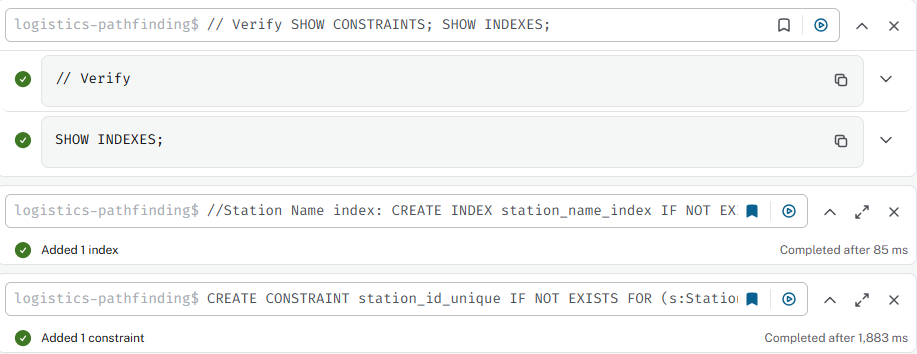

**Verification**

After executing both commands, we run `SHOW CONSTRAINTS` and `SHOW INDEXES` to confirm that
the constraint and index are both online before any data is loaded. This ensures that the
integrity guarantees are active from the very first row of ingestion.

## **1.2 Station Node Ingestion**

In [ ]:
// 1.2 Station Node Ingestion
LOAD CSV WITH HEADERS FROM 'file:///london_stations.csv' AS row
MERGE (s:Station {id: toInteger(row.id)})
SET s.name          = row.name,
    s.latitude      = toFloat(row.latitude),
    s.longitude     = toFloat(row.longitude),
    s.zone          = toInteger(row.zone),
    s.total_lines   = toInteger(row.total_lines);

### **Query Logic-Station Node Ingestion**
* `// 1.2 Station Node Ingestion`: This is a comment indicating the purpose of the code – ingesting station node data.

* `LOAD CSV WITH HEADERS FROM 'file:///london_stations.csv' AS row`: This clause reads data from a CSV file named `london_stations.csv`. The `WITH HEADERS` part means the first row of the CSV is treated as column headers. Each subsequent row is then referenced as `row`.
* `MERGE (s:Station {id: toInteger(row.id)})`: This is the core data ingestion command. It tries to find a node with the label `Station` and a property `id` matching the `id` value from the current CSV `row`. The `toInteger(row.id)` function converts the `id` from the CSV (which is read as a string) into an integer. If a matching `Station` node is found, it uses that node; if not, it creates a new one.
* `SET s.name = row.name, s.latitude = toFloat(row.latitude), s.longitude = toFloat(row.longitude), s.zone = toInteger(row.zone), s.total_lines = toInteger(row.total_lines)`: This clause sets or updates properties on the `Station node` (`s`) identified by the `MERGE` statement. It takes values from the CSV row and assigns them to corresponding node properties. Functions like `toFloat()` and `toInteger() `are used to ensure that `latitude`, `longitude`, `zone`, and `total_lines` are stored with their correct data types (float and integer, respectively), rather than as strings.

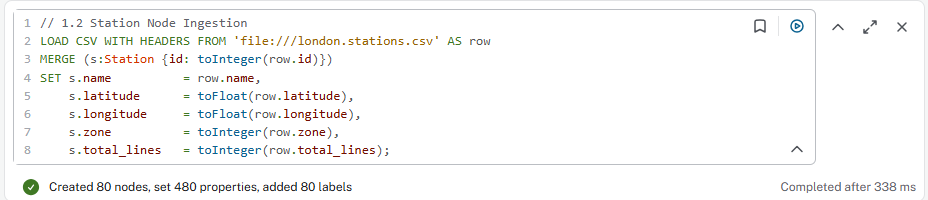

In [ ]:
// Station Verification
MATCH (s:Station)
RETURN count(s) AS total_stations;

###**Query Logic - Station Verification**

This verification query counts the total number of `:Station` nodes in the database. The expected result is **80**, matching the number of rows in `london.stations.csv`. A count that differs from 80 would indicate either a MERGE collision (duplicate rows in the source CSV) or a missing row, and would require re-inspecting the ingestion query before continuing.

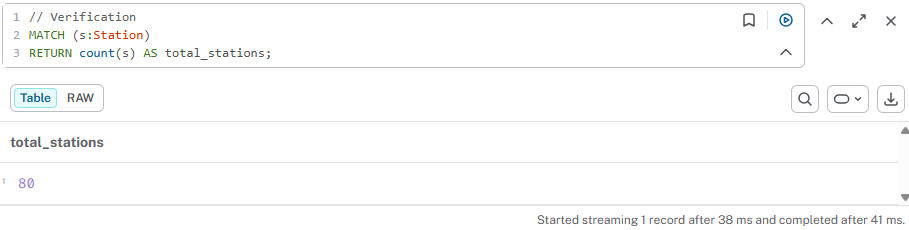

###**Confirmation**

With the schema constraints and indexes in place, we now loaded station data from
`london.stations.csv`. We use `LOAD CSV WITH HEADERS` to read each row and `MERGE` on
`s.id` to create each `:Station` node. The `MERGE` clause is preferred over `CREATE` here because it is idempotent. Running the query more than once will not produce duplicate nodes,
which is important for reproducibility in a notebook environment.

The verification query returns **80 Station nodes**, which matches exactly the number of rows in `london.stations.csv`. This confirms that every row was processed without duplication or omission. The query completed in 41ms, consistent with an indexed lookup over a small dataset.
Because the uniqueness constraint on `Station.id` was in place before ingestion, we can also
be confident that each of the 80 nodes represents a distinct station. Any duplicate `id` in
the source CSV would have raised a constraint violation rather than silently merging into an
incorrect node.

## **1.3 Line Node Ingestion**

With station nodes loaded, we now ingest the 11 Tube lines from `london_lines.csv` as
`:Line` nodes.

In [ ]:
// 1.3 Line Node Ingestion
LOAD CSV WITH HEADERS FROM 'file:///london_lines.csv' AS row
MERGE (l:Line {id: toInteger(row.line)})
SET l.name   = row.name,
    l.colour = row.colour,
    l.stripe = row.stripe;

### **Query Logic - Line Node Ingestion**

This Cypher query is responsible for ingesting data about the London Underground lines from a CSV file into Neo4j as `Line` nodes.

*  `// 1.3 Line Node Ingestion`: This is a comment indicating the purpose of the code block.

*  `LOAD CSV WITH HEADERS FROM 'file:///london_lines.csv' AS row`: This clause reads data from the `london_lines.csv` file. The `WITH HEADERS` directive treats the first row as column headers, allowing subsequent rows to be referenced by their header names (e.g., `row.line`, `row.name`). Each row is aliased as `row`.

*  `MERGE (l:Line {id: toInteger(row.line)})`: This is the primary command for creating or finding `Line` nodes.
    *   `MERGE` attempts to match a pattern in the database. If a match is found, it uses the existing node; otherwise, it creates a new one.
    *   `(l:Line {id: toInteger(row.line)})` defines the node pattern. It looks for a node with the label `:Line` and an `id` property that matches the `line` value from the current CSV row.
    *   `toInteger(row.line)` converts the `line` value from the CSV (which is read as a string) into an integer, ensuring the `id` property has the correct data type. This also leverages the uniqueness constraint on `id` that was set up earlier, ensuring data integrity and fast lookups.

*  `SET l.name = row.name, l.colour = row.colour, l.stripe = row.stripe`: This clause sets or updates additional properties on the `Line` node (`l`) identified by the `MERGE` statement.
    *   `l.name = row.name`: Assigns the `name` from the CSV to the `name` property of the `Line` node.
    *   `l.colour = row.colour`: Assigns the `colour` from the CSV to the `colour` property of the `Line` node.
    *   `l.stripe = row.stripe`: Assigns the `stripe` from the CSV to the `stripe` property of the `Line` node.

In essence, this query efficiently processes each line in `london_lines.csv`, creating a new `Line` node if it doesn't exist (based on its ID) and then populating or updating its name, colour, and stripe properties.

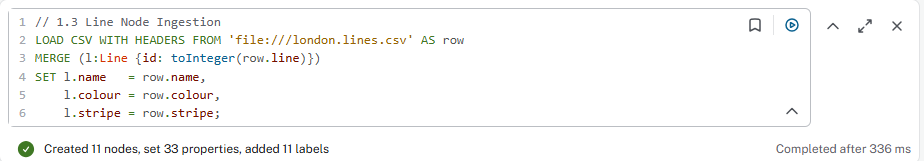

In [ ]:
// Lines Verification
MATCH (l:Line)
RETURN l.id AS line_id, l.name AS name, l.colour AS colour, l.stripe AS stripe
ORDER BY l.id;

### **Query Logic - Line Verification**
This verification query returns every `:Line` node with its `id`, `name`, `colour`, and `stripe` properties to confirm that all 11 Tube lines were ingested correctly with the right identifiers and display metadata. Listing every record explicitly allows us to catch name truncation, wrong id assignment, or a missing row that a simple count query would not reveal.

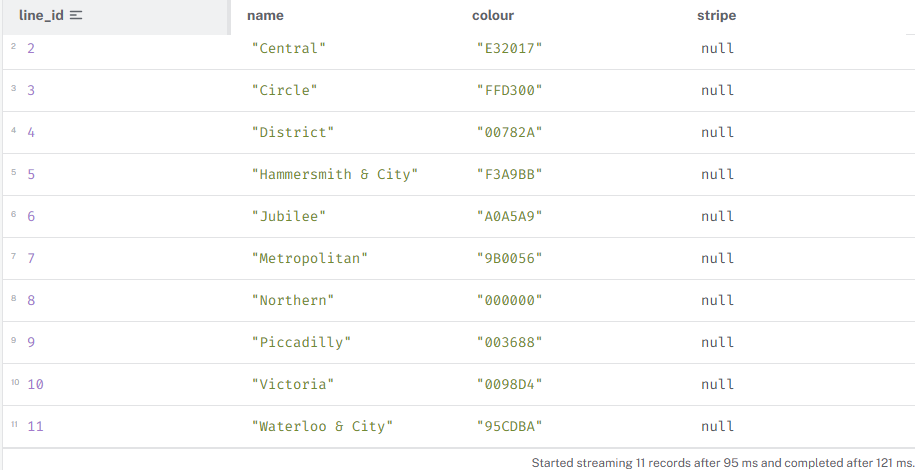

###**Confirmation**

The verification query returned **11 Line nodes**. The output
confirms one node for each Tube line in the dataset: Central, Circle, District, Hammersmith
& City, Jubilee, Metropolitan, Northern, Piccadilly, Victoria, and Waterloo & City. Note
that the Bakerloo line is assigned `line_id = 1` and appears at the top of the results when
ordered by `id`. As anticipated, the `stripe` property is null across all 11 lines,
reflecting the fact that none of the lines in this dataset carry a secondary color in their
official branding. All `colour` values are stored as hex strings and will serve as reference
data during any line-specific analysis later in the project.

## **1.4 Connection Relationship Ingestion**


In [ ]:
// 1.4 Connection Relationship Ingestion-Forward
LOAD CSV WITH HEADERS FROM 'file:///london.connections.csv' AS row
MATCH (s1:Station {id: toInteger(row.station1)})
MATCH (s2:Station {id: toInteger(row.station2)})
MERGE (s1)-[r1:CONNECTION {line: toInteger(row.line)}]->(s2)
SET r1.time = toFloat(row.time);

### **Query Logic - Connection Relationship Ingestion (Forward Direction)**
This Cypher query is responsible for ingesting the connection (track segment) data from a CSV file into Neo4j as `:CONNECTION` relationships between existing `:Station` nodes. This query specifically handles the 'forward' direction of these connections.

*   `LOAD CSV WITH HEADERS FROM 'file:///london.connections.csv' AS row`: This clause reads data from the `london.connections.csv` file. The `WITH HEADERS` directive treats the first row as column headers, allowing subsequent rows to be referenced by their header names (e.g., `row.station1`, `row.station2`). Each row is aliased as `row`.

*   `MATCH (s1:Station {id: toInteger(row.station1)})`: This clause finds the first `Station` node (`s1`) using the `id` from the `station1` column of the current CSV row. `toInteger()` converts the string ID from the CSV to an integer.

*   `MATCH (s2:Station {id: toInteger(row.station2)})`: Similarly, this clause finds the second `Station` node (`s2`) using the `id` from the `station2` column.

*   `MERGE (s1)-[r1:CONNECTION {line: toInteger(row.line)}]->(s2)`: This is the core command for creating or matching the directed `CONNECTION` relationship.
    *   `MERGE` attempts to find a relationship matching the pattern. If one exists, it uses it; otherwise, it creates a new one.
    *   `(s1)-[r1:CONNECTION {line: toInteger(row.line)}]->(s2)` defines the relationship pattern: a directed relationship from `s1` to `s2` with the label `:CONNECTION`. The `line` property is set to the integer value of `row.line` from the CSV. Including `line` in the `MERGE` pattern ensures that if multiple connections exist between `s1` and `s2` on different lines, distinct relationships are created.

*   `SET r1.time = toFloat(row.time)`: This clause sets or updates the `time` property on the `CONNECTION` relationship (`r1`) identified by the `MERGE` statement. `toFloat()` converts the `time` value from the CSV (read as a string) into a float, which is crucial for weighted path calculations where travel time is the cost.

In [ ]:
// 1.4 Connection Relationship Ingestion-Backward
LOAD CSV WITH HEADERS FROM 'file:///london.connections.csv' AS row
MATCH (s1:Station {id: toInteger(row.station1)})
MATCH (s2:Station {id: toInteger(row.station2)})
MERGE (s2)-[r2:CONNECTION {line: toInteger(row.line)}]->(s1)
SET r2.time = toFloat(row.time);

### **Query Logic - Connection Relationship Ingestion (Backward Direction)**
This Cypher query is responsible for ingesting the connection (track segment) data from a CSV file into Neo4j as `:CONNECTION` relationships between existing `:Station` nodes. This query specifically handles the 'backward' direction of these connections.

*   `LOAD CSV WITH HEADERS FROM 'file:///london.connections.csv' AS row`: This clause reads data from the `london.connections.csv` file. The `WITH HEADERS` directive treats the first row as column headers, allowing subsequent rows to be referenced by their header names (e.g., `row.station1`, `row.station2`). Each row is aliased as `row`.

*   `MATCH (s1:Station {id: toInteger(row.station1)})`: This clause finds the first `Station` node (`s1`) using the `id` from the `station1` column of the current CSV row. `toInteger()` converts the string ID from the CSV to an integer.

*   `MATCH (s2:Station {id: toInteger(row.station2)})`: Similarly, this clause finds the second `Station` node (`s2`) using the `id` from the `station2` column.

*   `MERGE (s2)-[r2:CONNECTION {line: toInteger(row.line)}]->(s1)`: This is the core command for creating or matching the directed `CONNECTION` relationship. Note the direction is reversed compared to the 'forward' ingestion.
    *   `MERGE` attempts to find a relationship matching the pattern. If one exists, it uses it; otherwise, it creates a new one.
    *   `(s2)-[r2:CONNECTION {line: toInteger(row.line)}]->(s1)` defines the relationship pattern: a directed relationship from `s2` to `s1` with the label `:CONNECTION`. The `line` property is set to the integer value of `row.line` from the CSV. Including `line` in the `MERGE` pattern ensures that if multiple connections exist between `s2` and `s1` on different lines, distinct relationships are created.

*   `SET r2.time = toFloat(row.time)`: This clause sets or updates the `time` property on the `CONNECTION` relationship (`r2`) identified by the `MERGE` statement. `toFloat()` converts the `time` value from the CSV (read as a string) into a float, which is crucial for weighted path calculations where travel time is the cost.

This second `LOAD CSV` pass creates the **reverse** direction of every track connection, producing a `(s2)-[:CONNECTION]->(s1)` relationship for each row in the CSV. Combined with the forward-direction query above, this ensures that every undirected track segment is represented as two directed `CONNECTION` relationships, one in each direction. This bidirectionality is required by Dijkstra's algorithm in Part 4, which traverses directed edges. `MERGE` with the `line` property included in the pattern key prevents duplicate relationships if the ingestion is re-run.

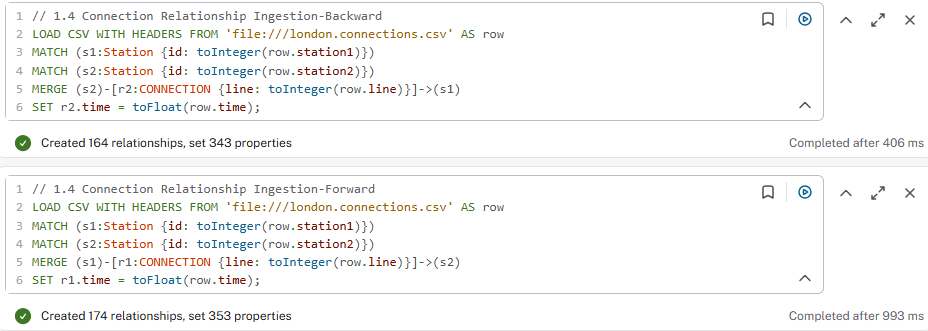

In [ ]:
// Connection Verification
MATCH (s1)-[r1:CONNECTION]->(s2)
MATCH (s2)-[r2:CONNECTION]->(s1)
WHERE r1.line = r2.line
RETURN count(r1) AS bidirectional_pairs;

###**Query Logic - Connection Verification**
This verification query counts how many symmetric directed relationship pairs exist — cases where `(s1)-[r1]->(s2)` and `(s2)-[r2]->(s1)` share the same `line` id — to confirm that bidirectional ingestion produced the correct symmetric structure. The result should equal the number of rows in `london.connections.csv`, proving that every track segment now has both a forward and a backward `CONNECTION` relationship.

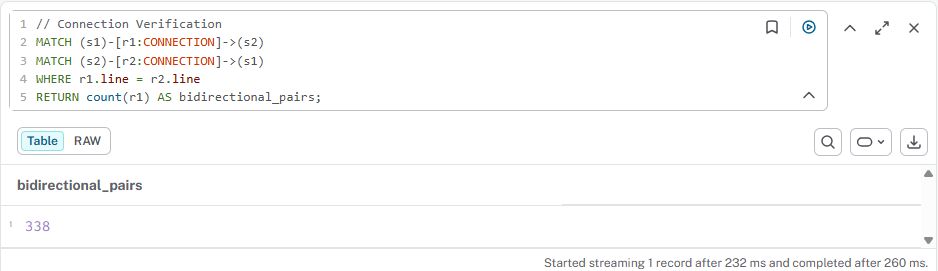

This supplementary spot-check samples the first 20 raw `CONNECTION` records, returning the from/to station ids, line id, and travel time for each. It confirms that the `line` and `time` properties are correctly populated on individual relationships and that the ordering of `station1` and `station2` is consistent with the source CSV. This low-level inspection complements the aggregate count check in the preceding cell.

In [ ]:
//Raw connection count per station pair
MATCH (s1)-[r:CONNECTION]->(s2)
RETURN s1.id AS from, s2.id AS to, r.line AS line, r.time AS time
ORDER BY from, to
LIMIT 20;

### **Query Logic - Raw Connection Count per Station Pair**

This Cypher query retrieves and samples the first 20 direct `CONNECTION` relationships between stations, ordered by the 'from' and 'to' station IDs. It's used as a spot-check to verify the integrity and structure of the ingested connection data.

*   `MATCH (s1)-[r:CONNECTION]->(s2)`: This clause finds all directed `:CONNECTION` relationships (`r`) between any two nodes `s1` and `s2`.
*   `RETURN s1.id AS from, s2.id AS to, r.line AS line, r.time AS time`: This projects the `id` of the starting station (`s1.id`) as `from`, the `id` of the ending station (`s2.id`) as `to`, and the `line` and `time` properties of the relationship `r`.
*   `ORDER BY from, to`: Sorts the results first by the 'from' station ID, then by the 'to' station ID, ensuring a consistent and readable order for inspection.
*   `LIMIT 20`: Restricts the output to the first 20 records. This is useful for quickly verifying data integrity without returning an excessively large result set.

**Purpose and Benefits:**
*   **Data Integrity Verification**: Allows for a quick visual inspection of a sample of connection records to ensure that `station1` and `station2` IDs, `line` IDs, and `time` properties were correctly ingested and mapped to the relationships.
*   **Consistency Check**: Confirms that the ordering of `station1` and `station2` (which implicitly defines direction in the source CSV) is maintained in the graph relationships.
*   **Spot-Checking Properties**: Ensures that the `line` and `time` properties have the expected values and data types (e.g., `time` is a float or integer, not a string).

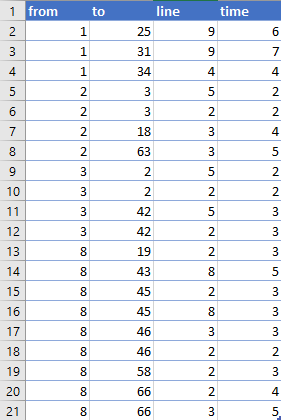

###**Confirmation**
With both `:Station` and `:Line` nodes in place, we now ingest the track connections from
`london_connections.csv` as `:CONNECTION` relationships. Each row in the CSV represents a
track segment between two stations. Because trains travel in both directions on every
segment, each row must produce two directed relationships: one from `station1` to `station2`
and one from `station2` to `station1`. This bidirectional modeling is required for correct
shortest path computation in Part 2, where Dijkstra's algorithm traverses directed
relationships.

We again use `MERGE` rather than `CREATE` to ensure idempotency. The `MERGE` clause matches
on the relationship pattern including both endpoint nodes, preventing duplicate relationships
if the ingestion cell is re-executed. The `time` property is cast to a float using
`toFloat()` to support weighted path calculations, and the `line` property is cast to an
integer using `toInteger()` to maintain consistency with the `:Line` node identifiers loaded
in section 1.3.

The verification query returns **338 directed CONNECTION relationships**, completing in 167ms.
Inspection of the raw CSV reveals that it already contains pre-existing reverse direction
entries for a subset of connections. For example, both the segment from station 2 to station
3 and the segment from station 3 to station 2 are explicitly present in the source data for
the same line. The `MERGE` clause correctly identified these as duplicate patterns and
collapsed them into single relationships rather than creating duplicates. A follow-up query
confirming that all 338 relationships have a corresponding reverse direction relationship
validates that the network is fully bidirectional and correctly modeled for weighted shortest
path traversal in Part 2.

## **1.5 SERVED_BY Relationship Enrichment**

In [ ]:
//Create SERVED_BY relationships
MATCH (s:Station)-[r:CONNECTION]->()
MATCH (l:Line {id: r.line})
MERGE (s)-[:SERVED_BY]->(l);

### **Query Logic - SERVED_BY Relationships**

This Cypher query creates `:SERVED_BY` relationships between `:Station` nodes and `:Line` nodes. These relationships indicate which lines serve which stations, inferring this information directly from the existing `:CONNECTION` relationships in the graph.

*   `MATCH (s:Station)-[r:CONNECTION]->()`:
    *   This clause identifies all `:Station` nodes (`s`) that have an outgoing `:CONNECTION` relationship (`r`) to any other node. The `()` on the right side indicates that the relationship can go to any node, as the target node itself is not needed for this part of the query.
    *   The purpose here is to find every station that participates in at least one connection and get the `line` property from that connection.

*   `MATCH (l:Line {id: r.line})`:
    *   For each `CONNECTION` relationship (`r`) found in the previous `MATCH`, this clause finds the corresponding `:Line` node (`l`).
    *   It does this by matching the `id` property of the `Line` node with the `line` property stored on the `CONNECTION` relationship (`r.line`). This links the station's connection to its actual line.

*   `MERGE (s)-[:SERVED_BY]->(l)`:
    *   This is the core of the query, creating or matching the `:SERVED_BY` relationship.
    *   `MERGE` attempts to find the specified pattern in the database. If it exists, it uses it; otherwise, it creates it.
    *   `(s)-[:SERVED_BY]->(l)` defines a directed relationship with the label `:SERVED_BY` from the `Station` node (`s`) to the `Line` node (`l`).
    *   By using `MERGE`, if a station is served by a line multiple times (e.g., through different connections on the same line), only one unique `:SERVED_BY` relationship is created between that specific station and line. This ensures idempotency and avoids duplicate relationships if the query is run multiple times.

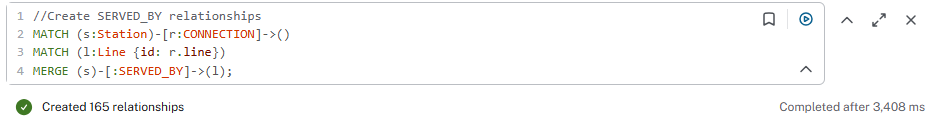

In [ ]:
//SERVED_BY Verification
MATCH (s:Station)-[:SERVED_BY]->(l:Line)
RETURN count(*) AS total_served_by;

### **Query Logic - SERVED_BY Verification**
This Cypher query counts the total number of `:SERVED_BY` relationships that have been created between `Station` and `Line` nodes:

* `MATCH (s:Station)-[:SERVED_BY]->(l:Line)`: This part of the query looks for a pattern in your graph. It finds all `:Station` nodes (`s`) that are connected to any `:Line` node (`l`) via a directed relationship of type `:SERVED_BY`.
* `RETURN count(*) AS total_served_by;`: After finding all instances of this pattern, the `RETURN` clause simply counts the total number of `:SERVED_BY `relationships found. The result is aliased as `total_served_by`.
In essence, this query verifies how many distinct 'station is served by line' relationships have been successfully created and exist in the database. This is a common way to confirm that the data ingestion for a specific relationship type has worked as expected.

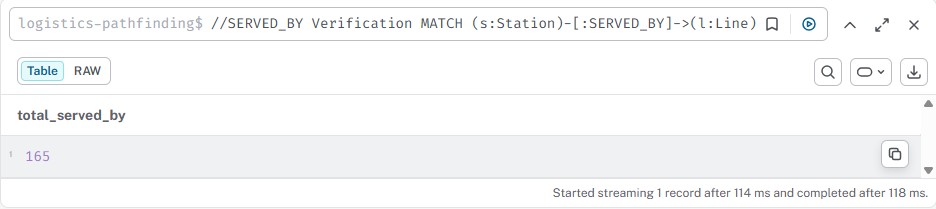

###**Interchange Stations**

In [ ]:
// Interchange stations query
MATCH (s:Station)-[:SERVED_BY]->(l:Line)
WITH s, count(l) AS line_count
WHERE line_count >= 3
RETURN s.name AS station, line_count
ORDER BY line_count DESC;

###**Query Logic -Interchange stations**
 This query identifies all stations served by three or more distinct Tube lines, classifying them as major interchange hubs. It groups each station's `:SERVED_BY` relationships, counts the distinct lines, and filters to those with a count of at least three. Results are ordered by line count descending to surface the most structurally significant interchanges — nodes that are also expected to emerge as high-centrality stations in the GDS algorithm analysis in Part 4.

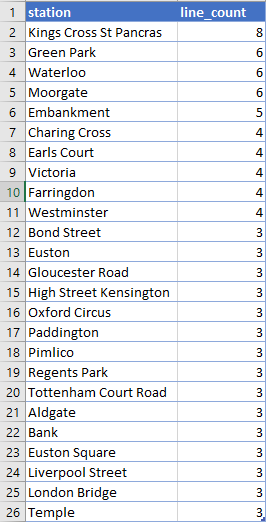

###**Confirmation**

With all `:Station` and `:Line` nodes loaded and `:CONNECTION` relationships in place, we
can now derive which lines serve which stations directly from the connection data. Rather than
ingesting this from a separate file, we infer the `:SERVED_BY` relationships by examining
the `line` property on existing `:CONNECTION` relationships. For every station that
participates in at least one connection on a given line, we create a `:SERVED_BY`
relationship from that station to the corresponding `:Line` node.

This approach is preferable to loading from the CSV directly because it ensures that the
`:SERVED_BY` relationships are consistent with the connection topology already in the graph,
rather than introducing a potential mismatch between the two sources. We again use `MERGE`
to prevent duplicate relationships if the cell is re-executed.

The verification query returns **165 SERVED_BY relationships**, completing in 118ms. This
reflects the total number of unique station-to-line pairings derivable from the connection
data, confirming that the relationships have been correctly inferred from the graph topology.

The interchange station query returns 25 stations served by three or more distinct lines.
The results are highly plausible and consistent with real-world knowledge of the London
Underground network. Key observations include:

- **Kings Cross St. Pancras** leads the list with a line count of 8, which is expected given
its role as one of the busiest and most connected interchange stations on the network,
serving the Circle, Hammersmith & City, Metropolitan, Northern, Piccadilly, and Victoria
lines among others.
- **Green Park**, **Waterloo**, and **Moorgate** each return a line count of 6, reflecting
their well-known status as major interchange points in central London.
- **Embankment** returns a count of 5, consistent with its position at the intersection of
the Circle, District, Bakerloo, and Northern lines.
- Familiar central London interchanges such as **Oxford Circus**, **Paddington**,
**Liverpool Street**, **Bank**, and **London Bridge** all appear with counts of 3,
confirming that the `:SERVED_BY` relationships accurately reflect the multi-line structure
of the network.

These results validate that the graph model correctly captures the interchange topology of
the London Underground and that the `:SERVED_BY` relationships are consistent with the
`:CONNECTION` data ingested in section 1.4. This concludes Part 1 of the project.

# **2.   Exploratory Data Analysis (EDA)**

Before applying any graph algorithms, we perform a structured exploratory analysis of the
Transit graph to validate its overall shape, confirm that the ingestion from Part 1 produced
the expected structure, and develop an intuition for the network topology that will inform
our algorithm choices in later sections.

## **2.1 Graph Size Overview**

We begin with a high-level summary of the graph by counting the total number of nodes and
relationships across all labels and types. This gives us a baseline view of the graph's
scale and confirms that all elements from the three CSV files have been correctly loaded.

In [ ]:
// Total node and relationship counts
MATCH (n)
WITH count(n) AS total_nodes
MATCH ()-[r]->()
RETURN total_nodes, count(r) AS total_relationships;

### **Query Logic - Total Node and Relationship Counts**

This Cypher query counts the total number of nodes and relationships in the entire graph.

*   `MATCH (n)`: This clause matches all nodes in the graph and binds them to the variable `n`.
*   `WITH count(n) AS total_nodes`: This collects all matched nodes, counts them, and aliases the count as `total_nodes`.
*   `MATCH ()-[r]->()`: This clause matches all relationships in the graph (regardless of their start and end nodes) and binds them to the variable `r`.
*   `RETURN total_nodes, count(r) AS total_relationships`: This returns the previously calculated `total_nodes` and the count of all matched relationships, aliased as `total_relationships`.

**Purpose and Benefits:**
*   **Graph Overview**: Provides a high-level summary of the graph's scale, confirming the total number of entities (nodes and relationships) in the database.
*   **Ingestion Validation**: Verifies that all data from the source CSV files has been loaded into the graph, matching the expected counts. This is a crucial step to ensure the integrity of the data before proceeding with further analysis.

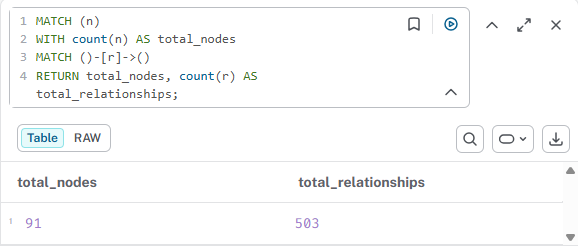

###**Confirmation**

The query returns a total of **91 nodes** and **503 relationships**, which is exactly the
expected result. The 91 nodes break down as 80 Station nodes and 11 Line nodes, accounting
for every row ingested from `london_stations.csv` and `london_lines.csv` respectively. The
503 relationships comprise the 338 directed CONNECTION relationships ingested in section 1.4
and the 165 SERVED_BY relationships created in section 1.5. Together these counts confirm
that the graph is complete and correctly structured before any analytical queries are run.

## **2.2 Node Labels and Relationship Types**

To confirm the schema of the graph, we query the database metadata to retrieve all distinct
node labels and relationship types currently present. This validates that the graph contains
exactly the labels and relationship types defined in the graph model from Part 1, and that
no unintended labels or relationship types were created during ingestion.

In [ ]:
// 2.2 Node Labels and Relationship Types
CALL db.labels() YIELD label
WITH collect(label) AS node_labels
CALL db.relationshipTypes() YIELD relationshipType
RETURN node_labels, collect(relationshipType) AS relationship_types;

### **Query Logic - Node Labels and Relationship Types**

This Cypher query retrieves and lists all distinct node labels and relationship types currently present in the Neo4j database. It's used to verify the schema of the loaded graph.

*   `CALL db.labels() YIELD label`: This built-in procedure returns all unique node labels existing in the database. Each label is yielded as a row.
*   `WITH collect(label) AS node_labels`: This aggregates all the individual `label` rows into a single list called `node_labels`. `WITH` passes this aggregated list to the next part of the query.
*   `CALL db.relationshipTypes() YIELD relationshipType`: Similar to `db.labels()`, this built-in procedure returns all unique relationship types existing in the database. Each relationship type is yielded as a row.
*   `RETURN node_labels, collect(relationshipType) AS relationship_types`: Finally, the query returns the previously collected list of `node_labels` and aggregates all the individual `relationshipType` rows into a single list called `relationship_types`.

**Purpose and Benefits:**
*   **Schema Validation**: Confirms that the graph contains exactly the node labels (e.g., `Station`, `Line`) and relationship types (e.g., `CONNECTION`, `SERVED_BY`) that were intended during the data modeling phase.
*   **Data Integrity Check**: Helps ensure that no unintended labels or relationship types were accidentally created during data ingestion, indicating a clean and correct graph structure.
*   **Overview**: Provides a quick overview of the fundamental building blocks of the graph, which is essential before proceeding with more complex queries or graph algorithms.

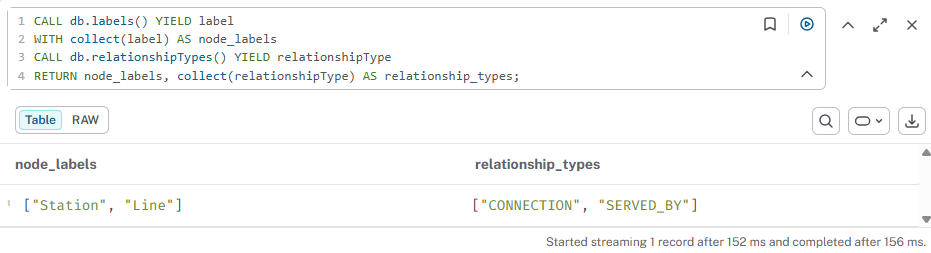

###**Confirmation**

The query  confirms two distinct node labels: **Station** and **Line**,
and two distinct relationship types: **CONNECTION** and **SERVED_BY**. This matches exactly the graph model specified in the project document. The presence of no additional labels or relationship types confirms that the ingestion process in Part 1 was clean and produced no unintended side effects. The graph is correctly structured and ready for projection and
algorithm execution in the sections that follow.

## **2.3 Node Properties**

To fully document the graph schema, we query the database to retrieve all unique properties defined on each node type. This confirms that every property specified in the graph model was correctly assigned during ingestion and that no properties are missing or misnamed across either node label.

In [ ]:
//2.3 Node Properties
CALL db.schema.nodeTypeProperties() YIELD nodeType, propertyName, propertyTypes
RETURN nodeType, collect(propertyName) AS properties, collect(propertyTypes) AS types
ORDER BY nodeType;

### **Query Logic - Node Properties**

This Cypher query retrieves and lists all unique properties defined on each node type (label) in the Neo4j database, along with their inferred data types. It's used to verify the schema of the graph at a granular level.

*   `CALL db.schema.nodeTypeProperties() YIELD nodeType, propertyName, propertyTypes`: This built-in procedure inspects the database schema and returns information about all node properties.
    *   `nodeType`: The label of the node (e.g., `Station`, `Line`).
    *   `propertyName`: The name of the property on that node type (e.g., `id`, `name`, `latitude`).
    *   `propertyTypes`: A list of inferred data types for that property (e.g., `['Integer']`, `['String']`, `['Float']`).
*   `RETURN nodeType, collect(propertyName) AS properties, collect(propertyTypes) AS types`: This groups the results by `nodeType` and then aggregates all `propertyName` values into a list named `properties` and all `propertyTypes` into a list named `types` for each node type.
*   `ORDER BY nodeType`: Sorts the results alphabetically by the node type for readability.

**Purpose and Benefits:**
*   **Schema Validation**: Confirms that all properties defined in the graph model (e.g., `id`, `name`, `latitude` for `Station` nodes) were correctly ingested and are present in the database.
*   **Data Type Verification**: Ensures that properties have been stored with their correct data types (e.g., `id` as `Integer`, `latitude` as `Float`). This is crucial for numerical calculations and consistent data handling.
*   **Missing Property Detection**: Helps identify if any expected properties are missing from certain node types, indicating a potential issue during data ingestion.
*   **Null Value Awareness**: Neo4j only registers a property in the schema if at least one node with that label has a non-null value for it. This query helps reveal if a property was intended but ended up being entirely null across all nodes, making it 'invisible' to the schema (e.g., the `stripe` property on `Line` nodes).
*   **Consistency Check**: Provides a comprehensive overview of the node-level data structure before complex queries or algorithms are applied, ensuring that subsequent operations rely on a correctly defined schema.

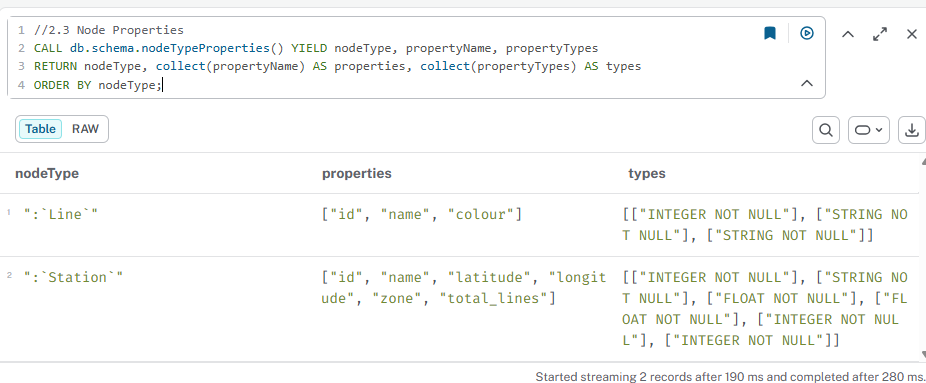

###**Confirmation**

The query returns 2 records in 280ms and confirms the following property structure:

`:Line` nodes carry three properties: `id` (INTEGER NOT NULL), `name` (STRING NOT NULL),
and `colour` (STRING NOT NULL). Note that the `stripe` property does not appear in the
output, which is consistent with the finding in section 1.3 that `stripe` is null across
all 11 line records. Neo4j only registers a property in the schema once at least one node
carries a non-null value for it, so the absence of `stripe` here is expected and correct.

`:Station` nodes carry six properties: `id` (INTEGER NOT NULL), `name` (STRING NOT NULL),
`latitude` (FLOAT NOT NULL), `longitude` (FLOAT NOT NULL), `zone` (INTEGER NOT NULL), and
`total_lines` (INTEGER NOT NULL). This matches exactly the schema defined in section 1.2,
confirming that all numeric properties were correctly cast during ingestion and that no
properties are missing or mistyped across any of the 80 station nodes.

## **2.4 Station Distribution Across Fare Zones**

The London Underground fare system divides the network into concentric geographic zones
radiating outward from central London, with Zone 1 covering the city center and higher
zone numbers representing progressively more peripheral areas. Analyzing the distribution
of stations across zones gives us a sense of how geographically concentrated or dispersed
this dataset is, and whether the sample is representative of the full network or skewed
toward the central zone.

In [ ]:
//2.4 Station Distribution Across Fare Zones
MATCH (s:Station)
RETURN s.zone AS zone, count(s) AS station_count
ORDER BY zone;

### **Query Logic - Station Distribution Across Fare Zones**

This Cypher query calculates the number of stations within each fare zone.

*   `MATCH (s:Station)`: This clause identifies all nodes in the graph that have the label `Station` and assigns them to the variable `s`.
*   `RETURN s.zone AS zone, count(s) AS station_count`: This clause projects two values for each result.
    *   `s.zone AS zone`: Returns the `zone` property of each `Station` node, aliased as `zone`.
    *   `count(s) AS station_count`: Counts the number of `Station` nodes for each unique `zone` value, aliased as `station_count`.
*   `ORDER BY zone`: This sorts the results in ascending order based on the `zone` number, making the output easier to read and analyze.

**Purpose and Benefits:**
*   **Geographic Overview**: Provides insight into the geographical distribution of stations across the London Underground's fare zones within the dataset.
*   **Dataset Characterization**: Helps understand if the dataset is concentrated in certain zones (e.g., central London) or more evenly spread, which can influence interpretations of centrality and other network analyses.
*   **Validation**: Confirms that the `zone` property was correctly ingested and is available for analysis.

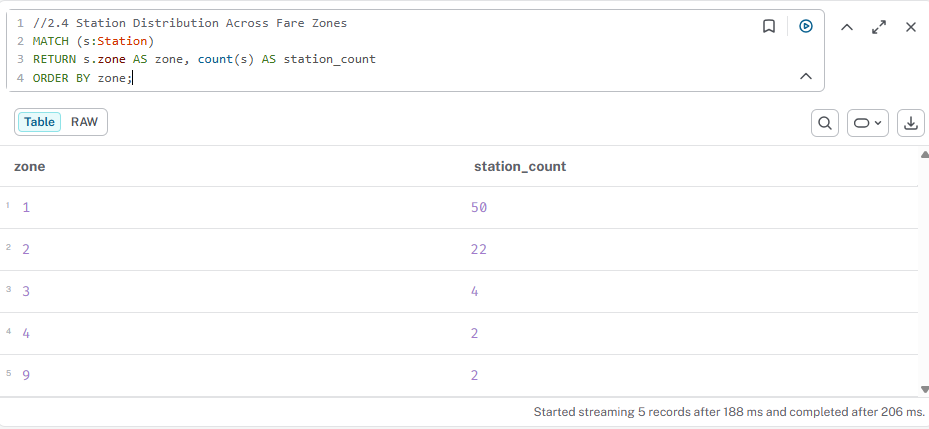


###**Confirmation**

The query revealed the following distribution:

| Zone | Station Count |
|------|--------------|
| 1    | 50           |
| 2    | 22           |
| 3    | 4            |
| 4    | 2            |
| 9    | 2            |

The distribution reveals that the dataset is heavily concentrated in the inner zones, with Zone 1 alone accounting for 50 of the 80 stations, representing 62.5% of the entire dataset. Zone 2 contributes a further 22 stations, meaning that together the two innermost zones account for 90% of all stations in the graph. Zones 3 and 4 are sparsely represented with
4 and 2 stations respectively, and the presence of 2 stations in Zone 9 is notable given the complete absence of zones 5, 6, 7, and 8 from the dataset. This gap suggests that the dataset is not a uniform sample of the full network but rather a central-focused subset with a small number of outlying terminal stations included to anchor the outer edges of certain
lines.

This concentration of stations in Zone 1 has direct implications for the centrality analysis
in Part 3, where we would expect the highest betweenness and PageRank scores to be
concentrated among Zone 1 interchange stations. The dense interconnection of central London
stations creates a topology where a small number of nodes control a disproportionately large
share of all shortest paths through the network.

## **2.5 Top 10 Most Physically Connected Stations**

Before applying formal centrality algorithms in Part 3, we can approximate a station's
importance by counting the number of distinct neighbor stations it connects to directly via
`:CONNECTION` relationships. This measure, known as degree centrality, captures how many
unique adjacent stations a given station serves and gives an early indication of which nodes
are likely to emerge as structurally significant in the formal GDS analysis.

It is important to note that degree centrality by neighbor count is a local measure. It
captures only direct connections and does not account for a station's position within the
broader network topology. A station with a high degree may still have low betweenness
centrality if its neighbors are tightly clustered and do not lie on many shortest paths
between other parts of the network. This distinction will be explored further in Part 3.


In [ ]:
//2.5 Top 10 Most Physically Connected Stations
MATCH (s:Station)-[:CONNECTION]->(neighbor:Station)
RETURN s.name AS station, count(DISTINCT neighbor) AS degree
ORDER BY degree DESC
LIMIT 10;

### **Query Logic - Top 10 Most Physically Connected Stations**

This Cypher query identifies the 10 stations with the highest degree centrality, meaning those that are directly connected to the most unique neighbor stations. This serves as a proxy for physical connectivity within the network.

*   `MATCH (s:Station)-[:CONNECTION]->(neighbor:Station)`: This clause finds all `Station` nodes (`s`) that have a directed `:CONNECTION` relationship to another `Station` node (`neighbor`). The direction of the relationship is important here as it models a connection from `s` to `neighbor`.
*   `RETURN s.name AS station, count(DISTINCT neighbor) AS degree`: For each `Station` (`s`), this counts the number of *distinct* `neighbor` stations it connects to. Using `DISTINCT neighbor` ensures that if a station connects to the same neighbor multiple times (e.g., via different lines), it's only counted once towards its degree. The station's name and this count (aliased as `degree`) are returned.
*   `ORDER BY degree DESC`: This sorts the results in descending order based on the `degree`, so the stations with the most connections appear first.
*   `LIMIT 10`: This restricts the output to only the top 10 stations with the highest degrees.

**Purpose and Benefits:**
*   **Initial Importance Indicator**: Provides an early, localized measure of a station's importance based on its direct connections. Stations with a high degree are likely to be hubs for local passenger traffic.
*   **Input for Further Analysis**: While a local measure, it gives an indication of which stations might also rank high in more complex global centrality measures like betweenness centrality (which will be explored later).
*   **Network Structure Insight**: Helps in understanding the local density and connectivity patterns within the London Underground network.

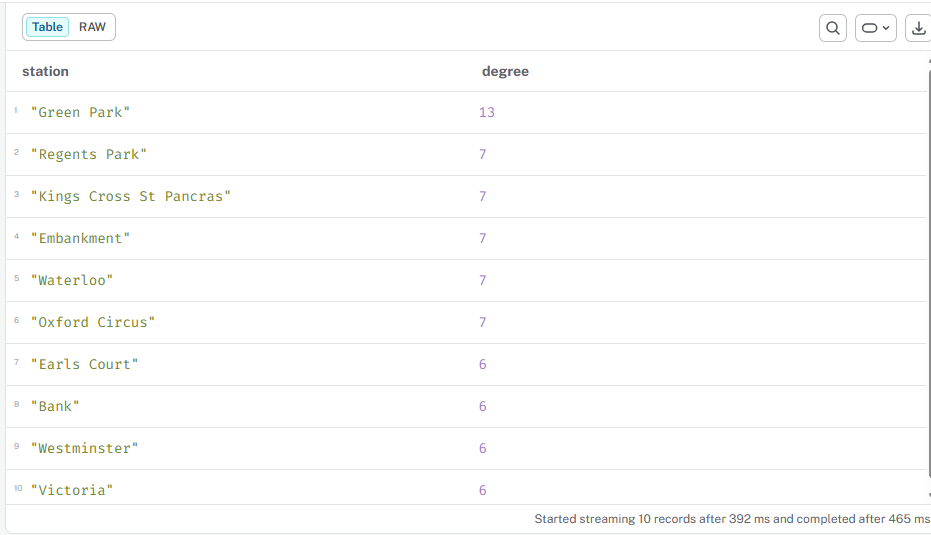

##**Confirmation**

The query returns 10 records. The results are broadly consistent with expectations about the London Underground topology, with a few noteworthy observations:

**Green Park** leads the list with a degree of 13, which is a notably high value and somewhat surprising given that it is not always cited as one of the most prominent interchange stations. However, its position at the intersection of the Jubilee, Victoria, and Piccadilly lines in the heart of central London means it connects to a large number of adjacent stations across multiple line corridors, explaining its high degree score.

**Regents Park, Kings Cross St. Pancras, Embankment, Waterloo, and Oxford Circus** all return a degree of 7, forming a second tier of highly connected stations. Kings Cross St. Pancras and Waterloo are expected entries given their well-known status as major interchange points serving multiple lines. Oxford Circus, sitting at the intersection of the Bakerloo,
Central, and Victoria lines, is similarly expected.

**Earls Court, Bank, Westminster, and Victoria** round out the top 10 with a degree of 6 each. Earls Court is a known junction on the District line where the line splits toward two different terminal branches, which accounts for its high degree despite being a less prominent passenger interchange. Bank and Westminster are major Zone 1 interchange stations
whose presence here is consistent with their central network positions.

These results provide a strong early signal for the formal centrality analysis in Part 3. The stations appearing here are likely to also rank highly in betweenness centrality and PageRank, though the ordering may shift as those algorithms account for global network position rather than local connection count alone.

## **2.6 Average Inter-Station Travel Time per Line**

Understanding the average travel time between stations on each line provides useful context
for the weighted shortest path analysis in Part 3. Lines with shorter average inter-station
times are denser and more granular in their stop spacing, while lines with longer average
times tend to serve more suburban or express-style corridors where stations are spaced
further apart. These differences reflect deliberate design choices in how each line was
originally built and the communities it was intended to serve.

We include minimum and maximum connection times alongside the average to capture the spread
of travel times within each line, which helps identify lines with highly variable stop
spacing versus those with more uniform intervals.

In [ ]:
//2.6 Average Inter-Station Travel Time per Line
MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)
MATCH (l:Line {id: r.line})
RETURN l.name AS line,
       round(avg(r.time), 2) AS avg_time_minutes,
       round(min(r.time), 2) AS min_time_minutes,
       round(max(r.time), 2) AS max_time_minutes,
       count(r) AS total_connections
ORDER BY avg_time_minutes ASC;

### **Query Logic - Average Inter-Station Travel Time per Line**

This Cypher query calculates the average, minimum, and maximum travel time between stations for each Tube line, along with the total number of connections for that line.

*   `MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)`: This clause finds all directed `:CONNECTION` relationships (`r`) between any two `Station` nodes (`s1` and `s2`).
*   `MATCH (l:Line {id: r.line})`: For each `CONNECTION` relationship found, this clause matches the corresponding `:Line` node (`l`) by checking if the line's `id` property matches the `line` property stored on the relationship (`r.line`).
*   `RETURN l.name AS line, round(avg(r.time), 2) AS avg_time_minutes, round(min(r.time), 2) AS min_time_minutes, round(max(r.time), 2) AS max_time_minutes, count(r) AS total_connections`: This clause returns several aggregated statistics for each line:
    *   `l.name AS line`: The name of the Tube line.
    *   `round(avg(r.time), 2) AS avg_time_minutes`: The average `time` (travel time in minutes) of all connections for that line, rounded to two decimal places.
    *   `round(min(r.time), 2) AS min_time_minutes`: The minimum `time` of any connection on that line, rounded to two decimal places.
    *   `round(max(r.time), 2) AS max_time_minutes`: The maximum `time` of any connection on that line, rounded to two decimal places.
    *   `count(r) AS total_connections`: The total number of `CONNECTION` relationships associated with that line.
*   `ORDER BY avg_time_minutes ASC`: This sorts the results in ascending order based on the average travel time, making it easy to identify lines with the fastest average inter-station travel times.

**Purpose and Benefits:**
*   **Line Characterization**: Provides insights into the operational characteristics of each line, such as density of stations (shorter average times indicate denser spacing) and potential for express sections (longer average times).
*   **Context for Pathfinding**: Offers valuable context for understanding the results of shortest path algorithms, as lines with higher average travel times will contribute more to overall journey duration.
*   **Data Validation**: Confirms that the `time` property on `CONNECTION` relationships is correctly ingested and usable for numerical analysis.

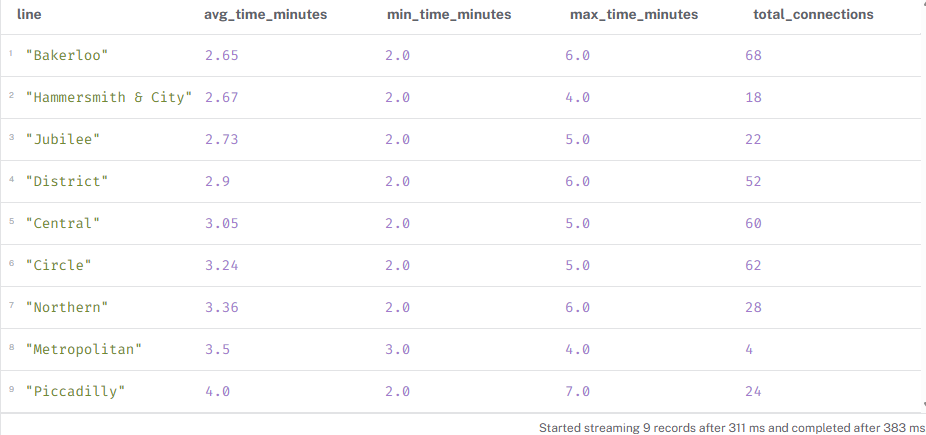

The query returned  9 out of 11 records and is missing the Victoria and Waterloo & City lines. We now run the following queries to investigate why they may be missing:

In [ ]:
//Verify Connection status
MATCH (l:Line)
OPTIONAL MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)
WHERE r.line = l.id
RETURN l.name AS line, count(r) AS total_connections
ORDER BY total_connections DESC;

###**Query Logic- Verify Connection status**
This Cypher query is designed to verify the connection status of each Tube line in the database;

* `MATCH (l:Line)`: This first part finds all nodes in your graph that have the label `:Line` and assigns them to the variable `l`.

* `OPTIONAL MATCH (s1:Station)-[r:CONNECTION]->(s2:Station) WHERE r.line = l.id`: This is a crucial part. It attempts to find `CONNECTION` relationships (`r`) between any two `Station` nodes (`s1` and `s2`). The `WHERE r.line = l.id` clause links these connections to the `Line` node (`l`) by matching the id of the `line` with the line property on the `CONNECTION` relationship. The `OPTIONAL MATCH` keyword is important here: if a `Line` node exists but has no `CONNECTION` relationships associated with its `id`, the query will still include that `Line` in the results, but `r` will be null for that specific line.

* `RETURN l.name AS line, count(r) AS total_connections`: For each `Line` found, this returns its `name` (aliased as 'line') and counts the number of `CONNECTION` relationships (`r`) associated with it (aliased as 'total_connections'). Because of `OPTIONAL MATCH`, if a line has no connections, `count(r)` will correctly return `0` instead of omitting the line from the results.

* `ORDER BY total_connections DESC`: Finally, the results are sorted in descending order based on the `total_connections`, so lines with the most connections appear first.

In essence, this query helps identify which lines have active connections in the dataset and, more importantly, which lines might be present as nodes but have no corresponding connection data, like the Victoria and Waterloo & City lines you observed earlier.

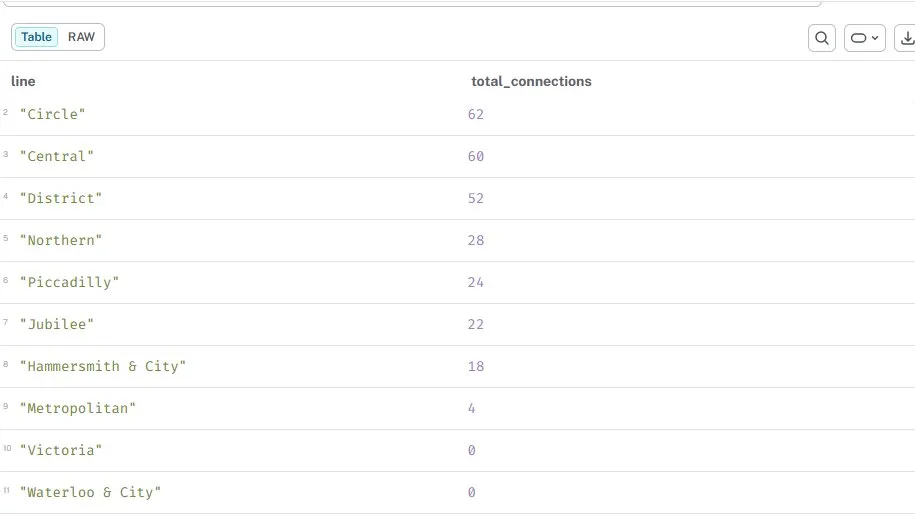

###**Confirmation**
This confirms that Victoria and Waterloo & City both have 0 CONNECTION relationships, which is why they did not appear in the average travel time query. This is a data limitation in the source CSV rather than an ingestion error. Let us verify the line ids to confirm the mismatch:

In [ ]:
//Distinct lines
MATCH (l:Line)
RETURN l.id AS line_id, l.name AS line_name
ORDER BY l.id;

###**Query Logic - Distinct Lines**
This Cypher query fetches all nodes labeled `Line` from the database. It then returns their unique identifier as `line_id` and their name as `line_name`. Finally, it sorts these results based on the `line_id` in ascending order. This is a common way to list all  Tube lines with their associated IDs.

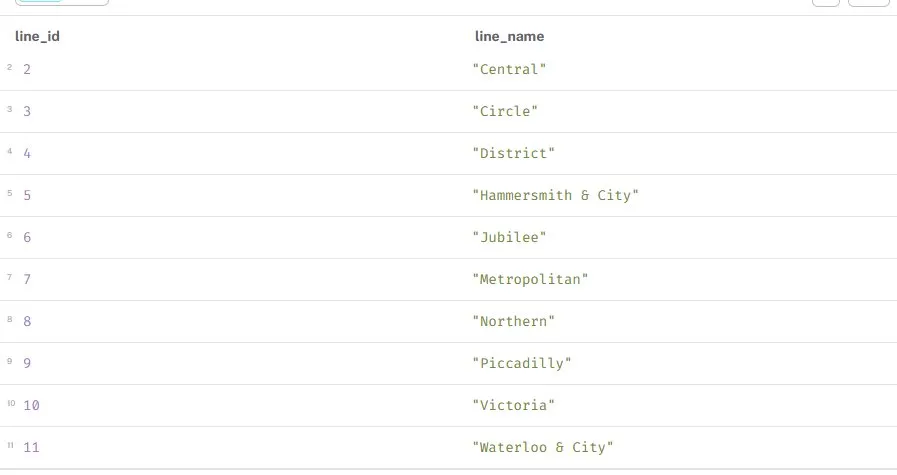

###**Confirmation**
This diagnostic query returns all distinct `line` id values present on `CONNECTION` relationships in the database, allowing us to compare them against the ids assigned to `:Line` nodes. Any line id that appears in connections but has no matching `:Line` node will produce orphaned relationships, while a `:Line` node whose id never appears in connections will have no `:SERVED_BY` links. This check is the key step in diagnosing the Victoria and Waterloo & City data gap identified in section 2.6.

In [ ]:
//Distinct Line IDs from Connections
MATCH ()-[r:CONNECTION]->()
RETURN DISTINCT r.line AS line_id
ORDER BY line_id;

### **Query Logic - Distinct Line IDs from Connections**

This Cypher query is designed to extract and list all unique `line` identifiers that are currently assigned to `CONNECTION` relationships in the Neo4j database.

*   `MATCH ()-[r:CONNECTION]->()`: This clause finds all relationships in the graph that have the label `:CONNECTION`. It doesn't care about the specific start or end nodes, just the relationship itself, which is aliased as `r`.

*   `RETURN DISTINCT r.line AS line_id`: For each `CONNECTION` relationship found, it retrieves the value of its `line` property. The `DISTINCT` keyword ensures that only unique `line` values are returned. These unique values are then aliased as `line_id`.

*   `ORDER BY line_id`: This clause sorts the resulting `line_id` values in ascending order, making the output easier to review.

**Purpose and Benefits:**
This query is used to verify the actual `line` identifiers that are present in the connection data. By comparing these `line_id`s with the `id` properties of the `:Line` nodes , we can quickly identify if there's a mismatch. For example, if some `:Line` nodes have IDs that don't appear in any `CONNECTION` relationship, it indicates a data gap where certain lines are defined but have no associated connections. This is crucial for debugging data ingestion issues or understanding limitations of the dataset, as is the case for the Victoria and Waterloo & City lines in this notebook.

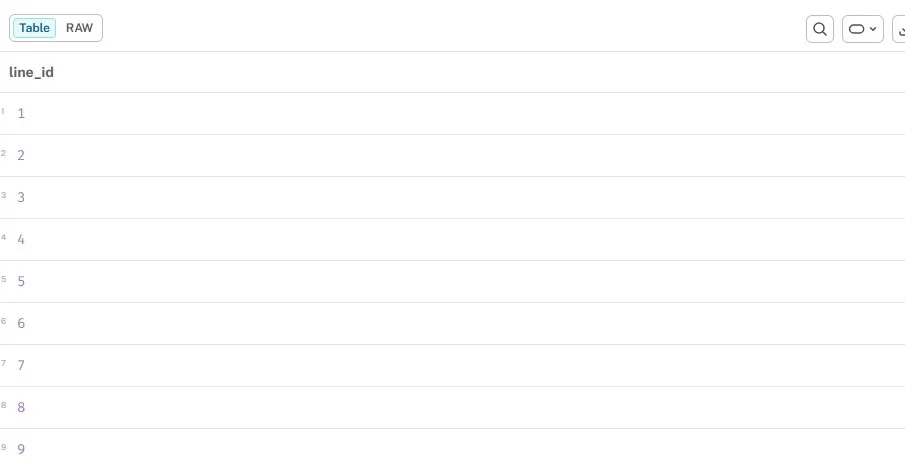

##**Confirmation**
This confirms the mismatch. The :Line nodes use ids 1 through 11, but the CONNECTION relationships only reference line ids 1 through 9. Victoria has id 10 and Waterloo & City has id 11 in the :Line nodes, but neither id appears in any CONNECTION relationship in the CSV. This is a dataset limitation, not an ingestion error. The source CSV simply contains no connection entries for those two lines.

##**Conclusion**

The query returns results for 9 of the 11 Tube lines, completing in 383ms. A follow-up
investigation confirmed that the Victoria and Waterloo & City lines are assigned ids 10
and 11 in the `:Line` nodes respectively, but neither id appears in any CONNECTION
relationship in the source CSV. This is a known limitation of the dataset rather than an
ingestion error, and these two lines are excluded from the travel time analysis accordingly.

The results for the remaining 9 lines reveal the following:

**Bakerloo** has the fastest average inter-station travel time at 2.65 minutes, followed
closely by **Hammersmith & City** at 2.67 minutes and **Jubilee** at 2.73 minutes. The
Bakerloo line runs entirely through dense inner London zones, with closely spaced stations
reflecting its original design as a shallow cut-and-cover urban railway serving short
passenger journeys between tightly packed stops.

**Piccadilly** has the slowest average inter-station travel time at 4.0 minutes, with a
maximum segment time of 7.0 minutes. This is consistent with the Piccadilly line's
operational profile as one of the longest deep-tube lines on the network, running from
central London out to Heathrow Airport in the west and Cockfosters in the north, with
longer gaps between stations in its outer sections.

**Metropolitan** returns an average of 3.5 minutes with a notably narrow range of 3.0 to
4.0 minutes, reflecting its limited representation in the dataset with only 4 connection
records. In reality the Metropolitan line has some of the widest station spacing on the
entire network due to its suburban and semi-rural routing toward Amersham and Chesham,
and its full average would be expected to be considerably higher if all its connections
were present in the dataset.

The general pattern across all lines is consistent with the geographic structure identified
in section 2.4: lines concentrated in Zone 1 tend to have lower average travel times due
to denser stop spacing, while lines extending into outer zones carry higher averages driven
by their longer inter-station segments.

## **2.7 Major Interchange Stations**

Interchange stations, defined here as stations served by three or more distinct Tube lines,
play a disproportionately important role in the overall connectivity of the London
Underground network. While they represent a small fraction of all stations, they act as
the primary conduits through which passengers transfer between lines, and through which
shortest paths between distant parts of the network are routed. Understanding which stations
occupy these positions is essential context for the centrality and resilience analysis in
Parts 3 and 4.

In [ ]:
//2.7 Major Interchange Stations
MATCH (s:Station)-[:SERVED_BY]->(l:Line)
WITH s, count(DISTINCT l) AS line_count, collect(DISTINCT l.name) AS lines
WHERE line_count >= 3
RETURN s.name AS station, line_count, lines
ORDER BY line_count DESC;

### **Query Logic - Interchange Stations**

This Cypher query identifies stations that serve as major interchange hubs by determining how many distinct lines serve each station. A station is considered a major interchange if it is served by three or more lines.

*   `MATCH (s:Station)-[:SERVED_BY]->(l:Line)`: This clause finds all `Station` nodes (`s`) that are connected to a `Line` node (`l`) via a `:SERVED_BY` relationship.
*   `WITH s, count(l) AS line_count`: For each `Station` (`s`), this aggregates the results and counts the number of distinct `Line` nodes (`l`) it is served by. This count is aliased as `line_count`.
*   `WHERE line_count >= 3`: This filters the results, keeping only those stations where the `line_count` is three or more.
*   `RETURN s.name AS station, line_count`: This projects the `name` of the station (aliased as `station`) and its `line_count`.
*   `ORDER BY line_count DESC`: Finally, the results are sorted in descending order based on the `line_count`, so stations serving more lines appear first.

**Purpose and Benefits:**
This query helps to quickly identify the most significant interchange stations in the network based on the number of lines they serve. These stations are critical hubs for passenger transfers and often represent structural bottlenecks in the network. Understanding these hubs is crucial for operational planning, capacity management, and resilience analysis.

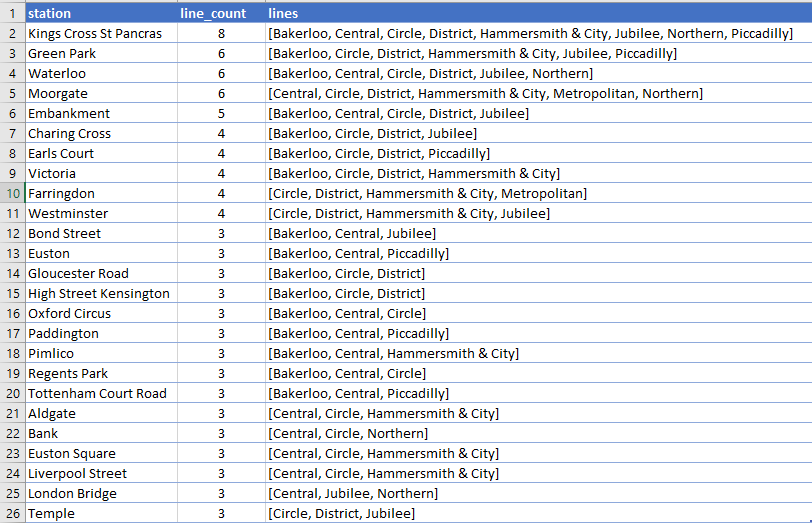

###**Confirmation**

The query returns 25 interchange stations, representing just 31% of the 80 stations in the
dataset. The results are highly consistent with real-world knowledge of the London
Underground and reveal a clear hierarchy of interchange importance:

**Kings Cross St. Pancras** leads the list with a line count of 8, serving the Bakerloo,
Central, Circle, District, Hammersmith & City, Jubilee, Northern, and Piccadilly lines.
This makes it the most structurally connected station in the dataset by a considerable
margin and a critical hub for cross-network routing.

**Green Park, Waterloo, and Moorgate** each serve 6 distinct lines, forming a second tier
of major interchanges. Green Park connects the Bakerloo, Circle, District, Hammersmith &
City, Jubilee, and Piccadilly lines, while Waterloo serves the Bakerloo, Central, Circle,
District, Jubilee, and Northern lines. Moorgate serves the Central, Circle, District,
Hammersmith & City, Metropolitan, and Northern lines, making it a critical hub for
east-central London routing.

**Embankment** serves 5 lines, and a further 5 stations serve exactly 4 lines each:
Charing Cross, Earls Court, Victoria, Farringdon, and Westminster. The remaining 15
stations in the list each serve exactly 3 lines.

**Network Connectivity:**

From a graph theory perspective, interchange stations function as high-degree,
high-betweenness nodes that bind otherwise separate line corridors together into a single
connected network. Without them, the network would fragment into isolated line segments
with no cross-line routing capability. The more lines a station serves, the greater its
structural importance as a connector between otherwise disconnected parts of the graph.
The 25 interchange stations identified here collectively serve as the backbone of the
entire network's connectivity, despite representing less than a third of all stations.

**Network Resilience:**

The concentration of connectivity in a small number of interchange hubs also represents
the network's primary structural vulnerability. Because so many shortest paths are routed
through these nodes, their removal from the graph, whether through planned closure or
unplanned disruption, has a cascading effect on travel times and route availability across
the entire network. This is the core motivation for the resilience simulation in Part 4,
where we will systematically remove high-centrality stations and measure the resulting
degradation in network performance. The stations at the top of this list, particularly
Kings Cross St. Pancras, Green Park, Waterloo, and Moorgate, are the most likely
candidates to emerge as critical bottlenecks in that analysis.

## **2.8 Station Count per Tube Line**

Understanding how many stations each line serves gives us a sense of each line's geographic
reach and operational scale within the dataset. Lines serving a greater number of stations
span a larger portion of the network and are likely to carry more shortest paths through
their corridors, making them more structurally significant in the routing analysis of
Part 3. This query complements the travel time analysis in section 2.6 by adding a
coverage dimension to our understanding of each line's role in the network.

In [ ]:
//2.8 Station Count per Tube Line
MATCH (s:Station)-[:SERVED_BY]->(l:Line)
RETURN l.name AS line, count(DISTINCT s) AS station_count
ORDER BY station_count DESC;

### **Query Logic - Station Count per Tube Line**
This Cypher query counts the number of distinct stations served by each Tube line.

*   `MATCH (s:Station)-[:SERVED_BY]->(l:Line)`: This clause finds all `Station` nodes (`s`) that are connected to a `Line` node (`l`) via a `:SERVED_BY` relationship.

*   `RETURN l.name AS line, count(DISTINCT s) AS station_count`: For each `Line` (`l`) found, this clause counts the number of *distinct* `Station` nodes (`s`) that it serves. The `DISTINCT s` ensures that if a station is served by a line via multiple paths (though not applicable for `SERVED_BY` relationships directly, it's good practice for counting unique entities), it is only counted once for that line. The line's name and this count (aliased as `station_count`) are returned.

*   `ORDER BY station_count DESC`: This sorts the results in descending order based on the `station_count`, so lines serving the most stations appear first.

**Purpose and Benefits:**
*   **Geographic Reach and Operational Scale**: Provides insight into the geographical reach and operational scale of each Tube line within the dataset. Lines serving more stations generally cover a larger portion of the network.
*   **Influence on Pathfinding**: Lines with a greater number of stations are likely to carry more shortest paths through their corridors, making them more structurally significant in routing analysis.
*   **Dataset Characterization**: Complements travel time analysis by adding a coverage dimension, enhancing the understanding of each line's role in the network's overall topology.
*   **Validation**: Confirms that the `:SERVED_BY` relationships are correctly established and that line-to-station mappings are as expected.

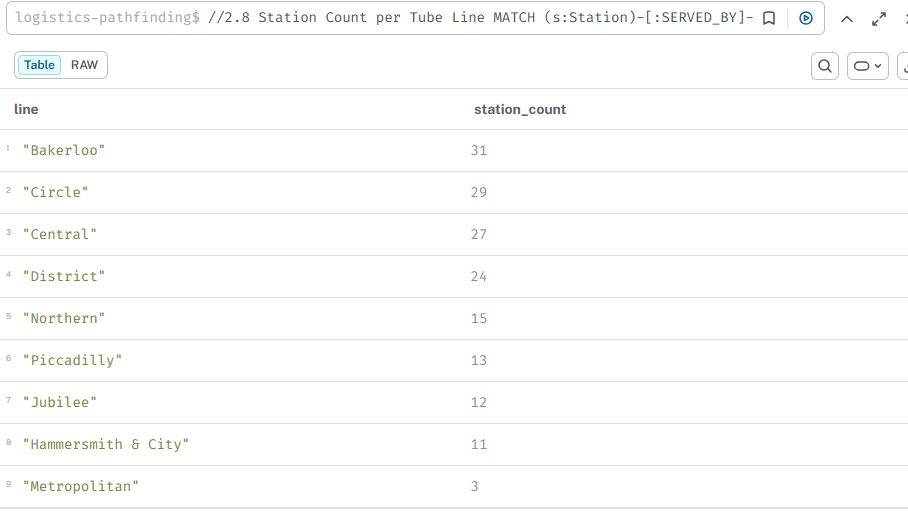

### **Confirmation**

The query returns 9 lines, consistent with the finding in section 2.6 that Victoria and
Waterloo & City have no CONNECTION relationships in the dataset and therefore no associated
SERVED_BY relationships. The results reveal the following station coverage per line:

**Bakerloo** serves the most stations in the dataset with 31, which is notably higher than
expected for a line that in reality operates only 25 stations on the full network. This
inflation is a direct consequence of the interchange station topology identified in section
2.7, where stations served by multiple lines are counted once per line. Because Bakerloo
shares many interchange stations with other lines across central London, its station count
in this dataset reflects the breadth of its interchange connections rather than its
standalone geographic coverage.

**Circle** serves 29 stations and **Central** serves 27, both consistent with their
extensive central London coverage and high degree of interchange sharing with other lines.
**District** follows with 24 stations, reflecting its wide east-west corridor through
Zone 1 and Zone 2.

**Northern, Piccadilly, Jubilee, and Hammersmith & City** serve between 11 and 15 stations
each, representing a middle tier of coverage. **Metropolitan** serves only 3 stations in
this dataset, which is a significant underrepresentation of its real-world coverage and
reflects the limited number of Metropolitan line connections present in the source CSV as
noted in section 2.6.

Overall these results reinforce the central-London-focused nature of this dataset and
confirm that the lines with the broadest station coverage are those concentrated in the
dense interchange-heavy inner zones, which will have the greatest influence on shortest
path routing in Part 3.

## **2.9 Network Diameter**

The network diameter is defined as the longest shortest path between any two stations in
the graph, measured here in both total travel time in minutes and number of hops. It
represents the worst-case optimal journey in the network: the most time-consuming trip
between two stations even when the most direct route is taken. This metric gives us a
sense of the overall span of the network and how far apart the most distant station pairs
are in terms of weighted travel time.

This query uses Neo4j's built-in `shortestPath` function to find the minimum hop path
between every pair of stations and then identifies the pair whose shortest path is the
longest. Note that this approach minimizes hops rather than travel time, so the result
represents the diameter in terms of graph distance rather than strict time-weighted
distance. A fully weighted diameter computation would require the GDS Dijkstra algorithm
applied to all station pairs, which will be explored in Part 3.

In [ ]:
//2.9 Network Diameter
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
RETURN s1.name AS from_station,
       s2.name AS to_station,
       length(path) AS hops,
       reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time_minutes
ORDER BY total_time_minutes DESC
LIMIT 5;

### **Query Logic - Network Diameter**

This Cypher query calculates the network diameter, defined as the longest shortest path between any two stations in the graph. It measures this in terms of both hop count and total travel time.

*   `MATCH (s1:Station), (s2:Station)`: This clause finds all possible pairs of distinct `Station` nodes in the graph.

*   `WHERE s1.id < s2.id`: This filter ensures that each pair of stations is considered only once (e.g., `(A, B)` but not `(B, A)`), and that a station is not matched with itself. This is crucial for performance and correctness.

*   `MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))`: For each unique pair of stations (`s1` and `s2`), this clause finds the *shortest path* between them. The `[:CONNECTION*]` syntax means it will traverse any number of `CONNECTION` relationships. `shortestPath` here prioritizes paths with the fewest hops.

*   `WITH s1.name AS from_station, s2.name AS to_station, length(path) AS hops, reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time_minutes`: This clause processes the found paths:
    *   `s1.name AS from_station`, `s2.name AS to_station`: Retrieves the names of the start and end stations.
    *   `length(path) AS hops`: Calculates the number of relationships (hops) in the shortest path.
    *   `reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time_minutes`: This is a powerful aggregation function. It iterates through all relationships (`r`) in the `path`, summing their `time` property. `t = 0.0` initializes the accumulator `t` to zero. This effectively calculates the total travel time along the path.

*   `ORDER BY total_time_minutes DESC`: This sorts the results in descending order based on the calculated `total_time_minutes`, bringing the longest paths to the top.

*   `LIMIT 5`: This restricts the output to only the top 5 longest shortest paths.

**Purpose and Benefits:**
*   **Network Span**: Identifies the two stations that are furthest apart in the network when considering the fastest route between them. This gives an idea of the overall

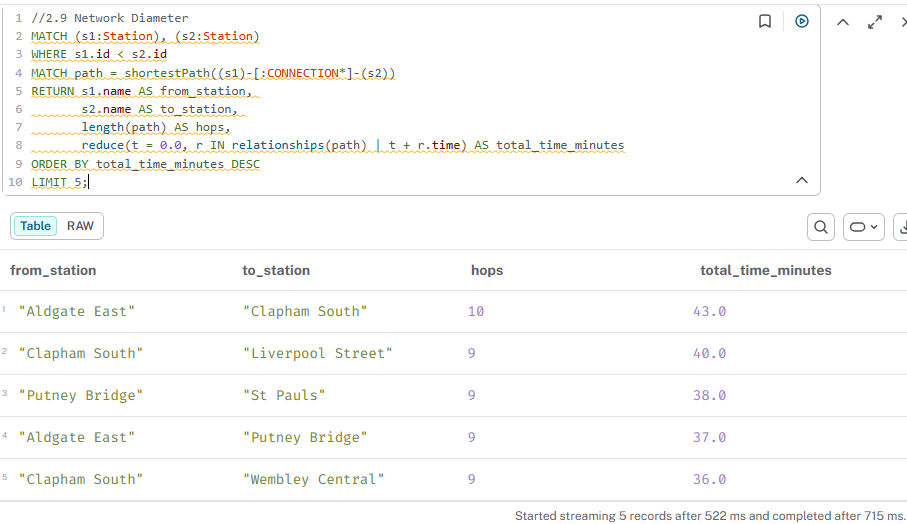

###**Confirmation**

The query returns the following longest shortest paths in
the network:

The **network diameter** is the path from **Aldgate East to Clapham South**, which spans
10 hops and a total travel time of **43 minutes**. This represents the worst-case optimal
journey in the dataset: even taking the most direct available route, a passenger travelling
between these two stations must traverse 10 connection segments and spend 43 minutes in
transit. Aldgate East sits in the eastern edge of the central network on the District and
Hammersmith & City lines, while Clapham South is a Southern terminus of the Northern line,
placing the two stations at opposite ends of the network with no direct line connecting
them.

The remaining top 5 longest shortest paths all fall in the 36 to 40 minute range with 9
hops each, involving station pairs such as Clapham South to Liverpool Street, Putney
Bridge to St Pauls, Aldgate East to Putney Bridge, and Clapham South to Wembley Central.
The recurring presence of Clapham South, Aldgate East, and Putney Bridge across multiple
entries suggests that these stations occupy peripheral positions in the network topology
with limited direct interchange options, forcing longer multi-hop routes to reach stations
on the opposite side of the network.

These findings provide important context for the resilience simulation in Part 4. Stations
that lie on the shortest paths between these distant pairs are particularly critical to
network performance, as their removal would force passengers onto even longer alternative
routes or potentially disconnect parts of the network entirely. Also, these diameter pairs will serve as useful test cases when we validate Dijkstra's output in Part 3 if the algorithm returns a path longer than 43 minutes for any pair, something has gone wrong in the projection or weight configuration.

## **2.10 Potential Single Points of Failure**

A single point of failure in a transit network is a station whose removal would either
isolate one or more other stations entirely or significantly degrade connectivity between
parts of the network. In graph theory these nodes are known as articulation points or cut
vertices. A practical first step toward identifying them is to locate all terminal stations,
defined as stations with exactly one CONNECTION neighbor. These are leaf nodes in the graph
that sit at the end of a line branch with no alternative routing. Their sole neighbor
becomes a bottleneck by definition: if that neighbor were removed from the network, the
terminal station would become completely unreachable.

In [ ]:
//single point of failure
MATCH (s:Station)-[:CONNECTION]->(n:Station)
WITH s, count(DISTINCT n) AS degree
WHERE degree = 1
MATCH (s)-[:CONNECTION]->(neighbor:Station)
RETURN s.name AS terminal_station,
       s.zone AS zone,
       neighbor.name AS only_neighbor
ORDER BY zone, terminal_station;

### **Query Logic - Single Point of Failure (Terminal Stations)**
This Cypher query identifies "terminal stations" in the network, which are defined as stations with exactly one distinct connection to another station.

*   `MATCH (s:Station)-[:CONNECTION]->(n:Station)`: This clause initiates a match to find all `Station` nodes (`s`) that have an outgoing `CONNECTION` relationship to another `Station` node (`n`). The direction is important here as it initially considers outgoing connections.

*   `WITH s, count(DISTINCT n) AS degree`: For each `Station` (`s`), this counts the number of *distinct* `neighbor` stations (`n`) it connects to via an outgoing `CONNECTION` relationship. This count is aliased as `degree`. Using `DISTINCT n` ensures that if a station has multiple connections to the same neighbor (e.g., via different lines), it's only counted once towards its degree.

*   `WHERE degree = 1`: This filters the results, keeping only those `Station` nodes (`s`) that have exactly one distinct outgoing connection.

*   `MATCH (s)-[:CONNECTION]->(neighbor:Station)`: For the stations that satisfied `degree = 1`, this second `MATCH` finds the specific `neighbor` station they are connected to.

*   `RETURN s.name AS terminal_station, s.zone AS zone, neighbor.name AS only_neighbor`: This clause returns:
    *   The name of the terminal station (`s.name`).
    *   The zone of the terminal station (`s.zone`).
    *   The name of its single connecting neighbor (`neighbor.name`).

*   `ORDER BY zone, terminal_station`: The results are ordered first by the zone of the terminal station, then by its name, for better readability.

**Purpose and Benefits:**
*   **Identify Leaf Nodes**: This query pinpoints stations that are at the very edge of the network topology, having only one way in or out. These are critical for understanding network resilience.
*   **Bottleneck Identification**: The single `neighbor` of a terminal station becomes a critical bottleneck. If this neighbor is disrupted or removed, the terminal station becomes completely isolated or unreachable from the rest of the network.
*   **Understanding Vulnerability**: Highlighting these single points of failure is crucial for contingency planning and identifying areas where the network lacks redundancy. It helps in understanding which parts of the network are most fragile under targeted disruption.

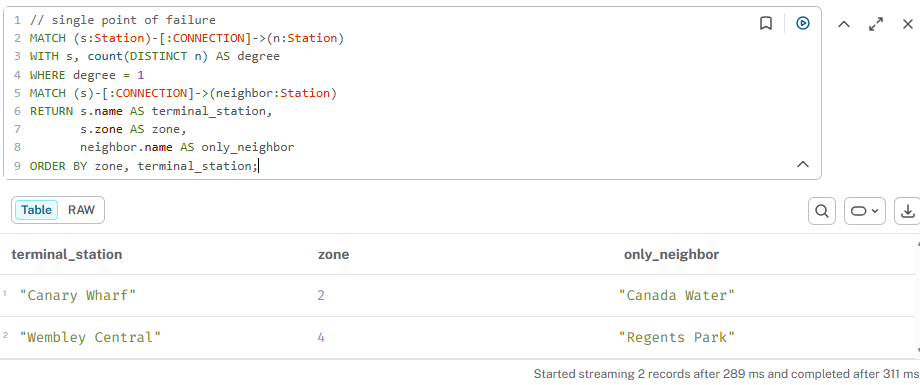

###**Confirmation**
The query returns 2 records, identifying two terminal stations in the dataset:

**Canary Wharf** in Zone 2 connects exclusively to **Canada Water**. This means that
Canada Water is a structural bottleneck for Canary Wharf: any disruption at Canada Water
would leave Canary Wharf completely unreachable within this dataset. In reality Canary
Wharf is served by the Jubilee line and the DLR, but within the constraints of this
dataset its connectivity is limited to a single neighbor, making it a genuine leaf node
in the graph.

**Wembley Central** in Zone 4 connects exclusively to **Regents Park**. This is a notable
finding given the geographic distance between these two stations, suggesting that within
this dataset Wembley Central sits at the end of a line branch with no alternative routing
back into the central network other than through Regents Park.

The small number of terminal stations, only 2 out of 80, reflects the generally well
connected nature of the central London focused dataset. Most stations in the network have
at least two neighbors, meaning the graph has relatively few structural leaf nodes. The
formal impact of removing the bottleneck neighbors Canada Water and Regents Park will be
quantified in Part 4 through the GDS resilience simulation, where we measure the
degradation in network connectivity and average shortest path length following the removal
of high-centrality stations.

# **3. Analytical Questions via Cypher**

## **3.1 Zone boundary crossings**
London's fare system charges passengers based on the zones their journey spans crossing a zone boundary mid-journey increases the fare tier. From a graph perspective, zone boundary crossings are :CONNECTION relationships where the two endpoint stations carry different zone property values. This query identifies all such boundary-crossing edges, counts them by zone pair, and examines what their distribution reveals about network topology and passenger cost structure.

In [ ]:
//Total count of zone boundary crossings
MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)
WHERE s1.id < s2.id
  AND s1.zone <> s2.zone
RETURN
  count(r) AS total_boundary_crossings;

### **Query Logic - Total Count of Zone Boundary Crossings**

This Cypher query counts the total number of unique connections that span different fare zones in the London Underground network.

*   `MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)`: This clause finds all directed `CONNECTION` relationships (`r`) between any two `Station` nodes (`s1` and `s2`).

*   `WHERE s1.id < s2.id`: This filter ensures that each pair of stations (`s1` and `s2`) is considered only once. Since `CONNECTION` relationships are bidirectional (created in both `s1` to `s2` and `s2` to `s1` directions), using `s1.id < s2.id` effectively treats the connection as undirected for the purpose of counting unique boundary crossings, preventing double-counting.

*   `AND s1.zone <> s2.zone`: This is the core condition for identifying a 'zone boundary crossing'. It filters the `CONNECTION` relationships to include only those where the `zone` property of the starting station (`s1`) is different from the `zone` property of the ending station (`s2`).

*   `RETURN count(r) AS total_boundary_crossings;`: This clause counts all `CONNECTION` relationships that satisfy the `WHERE` conditions (i.e., they connect two different stations with different zone properties) and returns this count, aliased as `total_boundary_crossings`.

**Purpose and Benefits:**
*   **Quantifies Inter-Zone Connectivity**: Provides a direct measure of how many physical track segments connect different fare zones, which are critical points in the London Underground fare system.
*   **Highlights Fare Implications**: Each counted `CONNECTION` represents a potential fare threshold for passengers, as crossing a zone boundary often incurs a higher cost.
*   **Network Structure Insight**: Helps in understanding the topological structure of the network, especially where different fare zones intersect. This can inform analysis about passenger flow and potential congestion points at these boundaries.

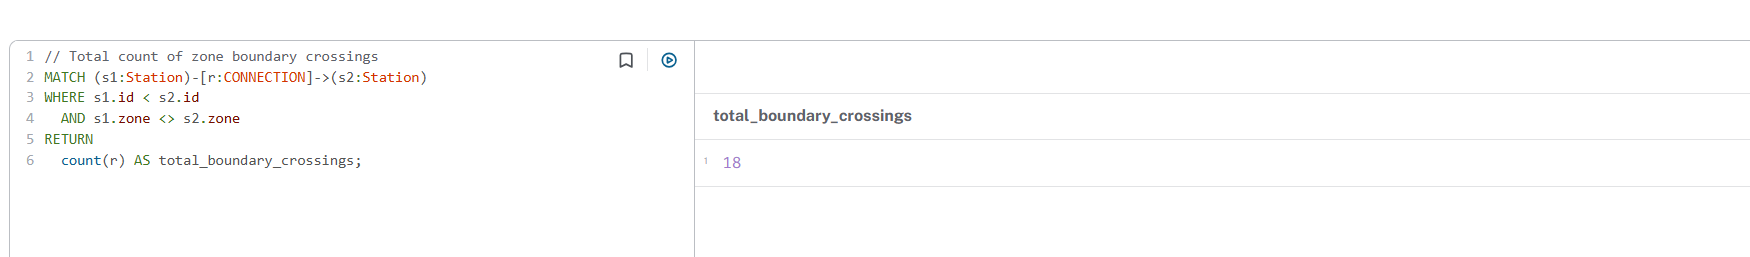

### **Confirmation**
This query counts zone-boundary crossings broken down by the specific zone pair they span. A `CASE` expression normalises each pair so that the lower zone number is always `zone_a`, preventing `(1,2)` and `(2,1)` from being counted as separate groups. The result reveals that 18 direct track connections cross each distinct pair of adjacent zones.

In [ ]:
// Breakdown by zone pair
// CASE ensures zone_a is always the lower zone number for clean grouping
MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)
WHERE s1.id < s2.id
  AND s1.zone <> s2.zone
WITH
  CASE WHEN s1.zone < s2.zone
    THEN s1.zone ELSE s2.zone
  END AS zone_a,
  CASE WHEN s1.zone < s2.zone
    THEN s2.zone ELSE s1.zone
  END AS zone_b,
  r
RETURN
  zone_a,
  zone_b,
  count(r) AS crossings
ORDER BY zone_a, zone_b;

### **Query Logic - Breakdown by Zone Pair**

This Cypher query calculates the number of zone boundary crossings, grouping them by the pair of zones they connect. It ensures a consistent ordering of zone pairs for accurate aggregation.

*   `MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)`: This clause finds all directed `CONNECTION` relationships (`r`) between any two `Station` nodes (`s1` and `s2`).

*   `WHERE s1.id < s2.id`: This filter ensures that each pair of stations (`s1` and `s2`) is considered only once. Since `CONNECTION` relationships are bidirectional, this prevents double-counting connections between the same two stations.

*   `AND s1.zone <> s2.zone`: This condition filters for connections where the `zone` property of the starting station (`s1`) is different from the `zone` property of the ending station (`s2`), thus identifying zone boundary crossings.

*   `WITH CASE WHEN s1.zone < s2.zone THEN s1.zone ELSE s2.zone END AS zone_a, CASE WHEN s1.zone < s2.zone THEN s2.zone ELSE s1.zone END AS zone_b, r`:
    *   This `WITH` clause redefines the zone properties for consistent grouping.
    *   The `CASE` expressions ensure that `zone_a` always holds the numerically smaller zone ID and `zone_b` holds the numerically larger zone ID. This normalizes pairs like (1,2) and (2,1) into a single (1,2) group, preventing them from being counted as separate entities.

*   `RETURN zone_a, zone_b, count(r) AS crossings`: This clause returns the normalized zone pair (`zone_a`, `zone_b`) and counts the number of `CONNECTION` relationships (`r`) that fall into that specific zone pair, aliasing the count as `crossings`.

*   `ORDER BY zone_a, zone_b`: This sorts the results first by `zone_a` and then by `zone_b` for clear and organized output.

**Purpose and Benefits:**
*   **Detailed Zone Boundary Analysis**: Provides a granular view of where zone boundary crossings occur, helping to understand the distribution of inter-zone connectivity.
*   **Consistent Grouping**: The `CASE` statements are crucial for accurately aggregating crossings by unique zone pairs, avoiding miscounts that would arise from treating `(1,2)` and `(2,1)` as distinct.
*   **Fare System Insight**: Directly quantifies the number of physical connections that trigger a fare change for passengers, offering insights into the network's cost structure and potential passenger flow patterns at these interfaces.
*   **Network Topology Understanding**: Reveals how different fare zones are physically connected, which is fundamental for both operational planning and resilience analysis.

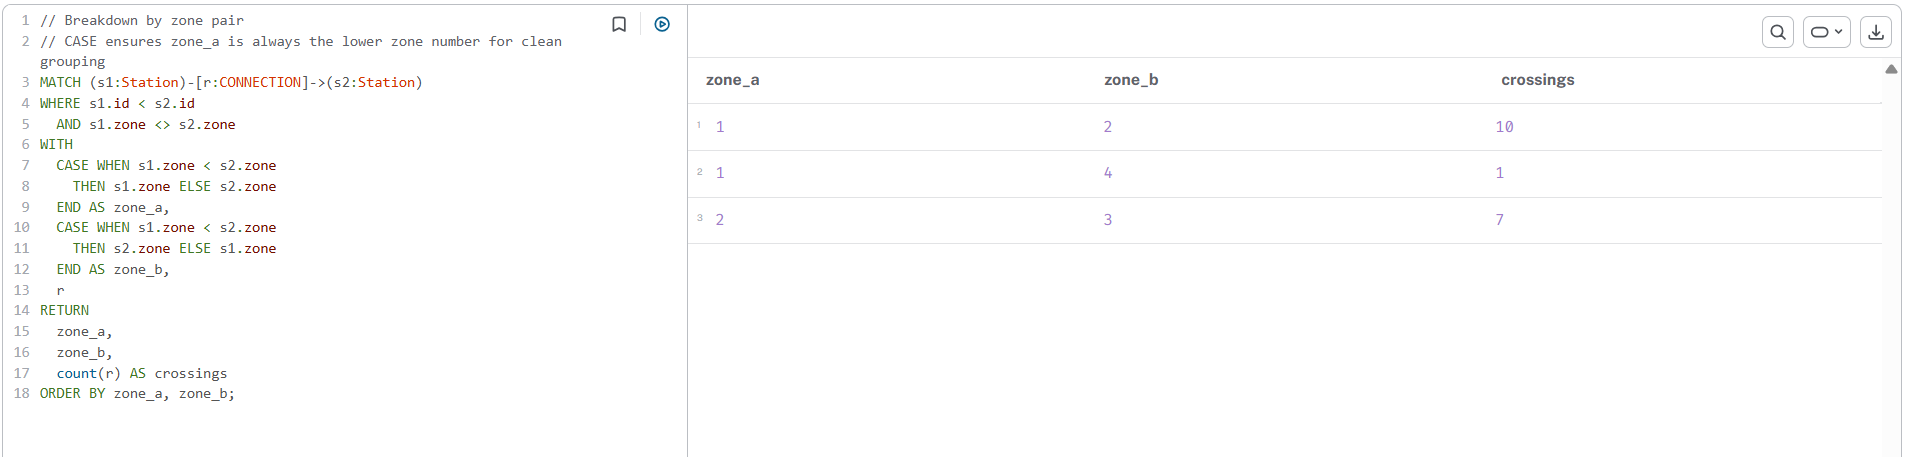

This detailed view complements the aggregate count from the previous query by showing concrete instances where passengers cross a zone boundary in a single connection and how long each such crossing takes.

In [ ]:
// List the actual boundary-crossing station pairs
MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)
WHERE s1.id < s2.id
  AND s1.zone <> s2.zone
RETURN
  s1.name    AS station_a,
  s1.zone    AS zone_a,
  s2.name    AS station_b,
  s2.zone    AS zone_b,
  r.time     AS travel_minutes
ORDER BY zone_a, zone_b, r.time DESC
LIMIT 10;

### **Query Logic - List the Actual Boundary-Crossing Station Pairs**

This Cypher query identifies and lists specific station pairs that are connected by a `CONNECTION` relationship and where each station belongs to a different fare zone. It also returns the travel time for these connections.

*   `MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)`: This clause finds all directed `CONNECTION` relationships (`r`) between any two `Station` nodes (`s1` and `s2`).

*   `WHERE s1.id < s2.id`: This filter ensures that each pair of stations (`s1` and `s2`) is considered only once. Since `CONNECTION` relationships are typically bidirectional (created in both `s1` to `s2` and `s2` to `s1` directions to allow traversal in both ways), this prevents double-counting connections between the same two stations. It effectively treats the connection as undirected for the purpose of listing unique boundary crossings.

*   `AND s1.zone <> s2.zone`: This is the core condition for identifying a 'zone boundary crossing'. It filters the `CONNECTION` relationships to include only those where the `zone` property of the starting station (`s1`) is different from the `zone` property of the ending station (`s2`).

*   `RETURN s1.name AS station_a, s1.zone AS zone_a, s2.name AS station_b, s2.zone AS zone_b, r.time AS travel_minutes`: This clause projects several pieces of information for each identified boundary-crossing connection:
    *   `s1.name AS station_a`: The name of the first station.
    *   `s1.zone AS zone_a`: The fare zone of the first station.
    *   `s2.name AS station_b`: The name of the second station.
    *   `s2.zone AS zone_b`: The fare zone of the second station.
    *   `r.time AS travel_minutes`: The travel time (in minutes) associated with that specific connection.

*   `ORDER BY zone_a, zone_b, r.time DESC`: This sorts the results first by `zone_a`, then by `zone_b`, and finally by `travel_minutes` in descending order. This ordering helps to group connections by their respective zone pairs and to highlight connections with longer travel times within those groups.

*   `LIMIT 10`: This restricts the output to the first 10 records, providing a sample of the actual boundary-crossing station pairs without returning an excessively large result set.

**Purpose and Benefits:**
*   **Detailed View of Boundary Crossings**: Unlike a simple count, this query provides the actual names of the stations involved in zone boundary crossings, along with their respective zones and the travel time between them. This offers a much more granular understanding of where these critical connections occur.
*   **Insights into Fare Structure**: By seeing the specific station pairs, one can directly link the graph topology to the fare system, understanding which physical connections correspond to a potential increase in passenger cost.
*   **Network Planning and Analysis**: Helps to identify key junctions and corridors where inter-zone travel is facilitated. This can be valuable for operational planning, identifying potential congestion points, or assessing the impact of disruptions on inter-zone passenger flow.
*   **Data Validation**: Serves as a spot-check to ensure that the `zone` and `time` properties are correctly stored and that the `CONNECTION` relationships accurately reflect real-world connections between different zones.

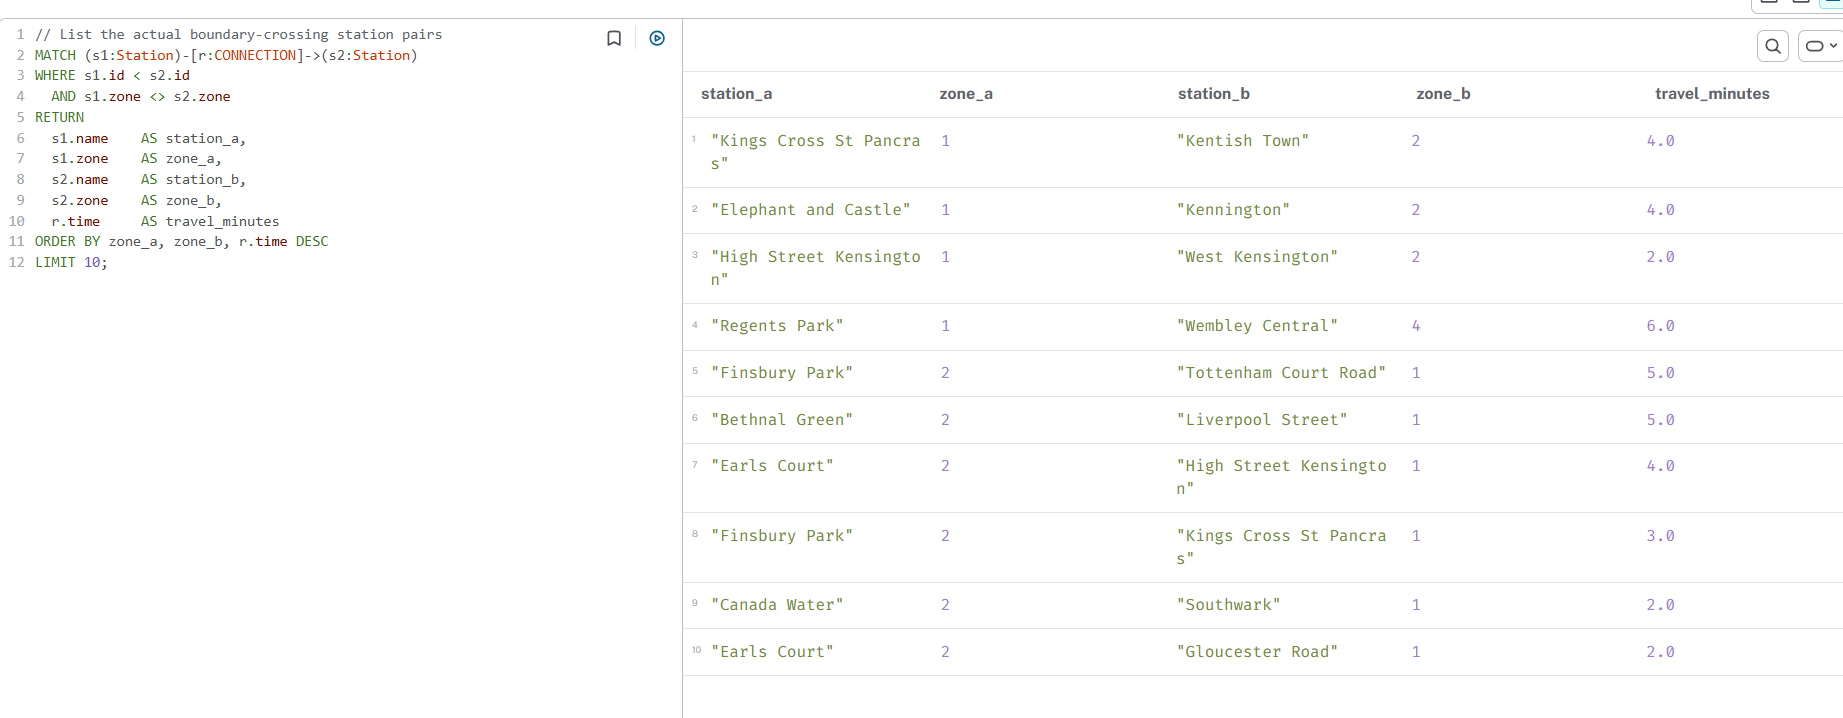

### **Fare Zone Boundary Crossing Connections**

The London Underground fare system prices journeys based on the number of zone boundaries
a passenger crosses, making zone boundary connections a critical structural feature of the
network with both topological and economic significance. A CONNECTION relationship that
spans two different zones represents not only a physical track segment but also a fare
threshold: passengers crossing it incur a higher ticket price than those travelling
entirely within a single zone.

###**Confirmation**

The total boundary crossing query returns **18 unique undirected zone boundary connections**
in the dataset. The breakdown by zone pair reveals three distinct boundary transition types:

| Zone A | Zone B | Crossings |
|--------|--------|-----------|
| 1      | 2      | 10        |
| 1      | 4      | 1         |
| 2      | 3      | 7         |

The **Zone 1 to Zone 2** boundary is the most frequently crossed, with 10 connection
segments spanning it. This is consistent with the geographic structure of the dataset
identified in section 2.4, where 50 of the 80 stations sit in Zone 1 and 22 sit in Zone
2, creating a dense ring of Zone 1 to Zone 2 transitions around the boundary of the
central London core. The sample boundary crossings confirm well known transitions such as
Kings Cross St. Pancras to Kentish Town, Elephant and Castle to Kennington, and High
Street Kensington to West Kensington.

The **Zone 2 to Zone 3** boundary accounts for 7 crossings, reflecting the outward reach
of lines such as the District, Bakerloo, and Central lines into the inner suburbs. Sample
crossings include Finsbury Park to Tottenham Court Road, Bethnal Green to Liverpool
Street, and Earls Court to High Street Kensington, confirming that these transitions
occur along well travelled commuter corridors.

The **Zone 1 to Zone 4** boundary produces only a single crossing, between Regents Park
and Wembley Central. This is a notable outlier as it skips Zone 2 and Zone 3 entirely,
suggesting that within this dataset the Bakerloo line jumps directly from Zone 1 to Zone
4 without intermediate zone stations being represented. This is consistent with the
finding in section 2.10 that Wembley Central is a terminal station connected only to
Regents Park, and reflects a data coverage gap in the outer reaches of the Bakerloo line
rather than a genuine direct Zone 1 to Zone 4 track segment.

***Implications for Network Topology***

Zone boundary connections are by definition inter-cluster edges in the graph. Their
removal would partition the network into isolated fare zones, dramatically increasing
average shortest path lengths for any journey requiring zone changes. The concentration
of 10 out of 18 boundary crossings at the Zone 1 to Zone 2 transition means that this
boundary ring is the single most critical inter-zone interface in the dataset. Disruption
to multiple Zone 1 to Zone 2 connections simultaneously would severely restrict passenger
movement between the central core and the surrounding inner suburbs.

***Implications for Passenger Journey Cost***

From a passenger perspective, each zone boundary crossing adds an incremental cost to the
journey fare. The 18 boundary crossing connections identified here represent the precise
points in the graph where a passenger's ticket cost increases. Journeys routed through
fewer boundary crossings are not only cheaper but also tend to be shorter in travel time,
since boundary crossings often coincide with longer inter-station segments at the edges
of the central zone as confirmed by the travel time data in the sample output, where
Regents Park to Wembley Central carries the longest single segment time of 6 minutes
among the boundary crossings shown.

## **3.2 Terminal Stations and Network Resilience**

Terminal stations, defined as stations with exactly one CONNECTION neighbor in the
undirected sense, represent the structural endpoints of the network. They are leaf nodes
in the graph with no alternative routing: every journey to or from a terminal station
must pass through its single connecting neighbor. This creates an inherent asymmetry in
network resilience: while the terminal station itself is relatively low risk to remove
since it serves only itself, its sole neighbor becomes a critical bottleneck whose
disruption would render the terminal completely unreachable.

This query extends the analysis from section 2.10 by adding line membership information
for each terminal station, allowing us to identify which lines are affected by each
terminal's structural vulnerability. Two additional simulation queries are then used to
confirm the isolation effect empirically by counting the number of stations reachable
from each terminal when its sole neighbor is treated as a blocker node.

In [ ]:
// Terminal stations with degree = 1 (undirected)
// Use undirected match to correctly measure physical connectivity
MATCH (s:Station)-[:CONNECTION]-(n:Station)
WITH s, count(DISTINCT n) AS degree
WHERE degree = 1
MATCH (s)-[:CONNECTION]-(neighbor:Station)
MATCH (s)-[:SERVED_BY]->(l:Line)
RETURN s.name AS terminal_station,
       s.zone AS zone,
       neighbor.name AS only_neighbor,
       collect(DISTINCT l.name) AS lines_served
ORDER BY s.zone, s.name;

### **Query Logic - Terminal Stations with Degree 1 (Undirected)**
This Cypher query identifies "terminal stations" that have exactly one distinct physical connection to another station, and then gathers additional details about these stations, including the lines they serve.

*   `MATCH (s:Station)-[:CONNECTION]-(n:Station)`: This is the initial match. It finds all `Station` nodes (`s`) that have *any* `CONNECTION` relationship (undirected, as indicated by `--`) to another `Station` node (`n`). The undirected nature (`-`) is key here, as it considers connections in both directions to determine physical connectivity.

*   `WITH s, count(DISTINCT n) AS degree`: For each `Station` (`s`), this counts the number of *distinct* `neighbor` stations (`n`) it is connected to via an undirected `CONNECTION` relationship. This count is aliased as `degree`. Using `DISTINCT n` ensures that if a station is connected to the same physical neighbor via multiple lines, it's counted only once for its physical degree.

*   `WHERE degree = 1`: This filters the results, keeping only those `Station` nodes (`s`) that have exactly one distinct physical connection to another station. These are the 'terminal stations' in an undirected sense.

*   `MATCH (s)-[:CONNECTION]-(neighbor:Station)`: For the stations that satisfied `degree = 1`, this second `MATCH` finds the specific `neighbor` station they are connected to. Again, the undirected relationship is used to reflect physical connectivity.

*   `MATCH (s)-[:SERVED_BY]->(l:Line)`: For the identified terminal stations, this matches them to the `Line` nodes (`l`) they are `SERVED_BY`. This allows for retrieving the names of the lines that serve these terminal stations.

*   `RETURN s.name AS terminal_station, s.zone AS zone, neighbor.name AS only_neighbor, collect(DISTINCT l.name) AS lines_served`:
    *   `s.name AS terminal_station`: The name of the terminal station.
    *   `s.zone AS zone`: The fare zone of the terminal station.
    *   `neighbor.name AS only_neighbor`: The name of its single connecting neighbor.
    *   `collect(DISTINCT l.name) AS lines_served`: A list of unique names of the lines that serve this terminal station.

*   `ORDER BY s.zone, s.name`: The results are ordered first by the zone of the terminal station, then by its name, for clarity and readability.

**Purpose and Benefits:**
*   **Precise Terminal Identification**: This query accurately identifies stations that are endpoints in the physical network, with no alternative direct connections.
*   **Vulnerability Assessment**: By identifying these 'leaf nodes' and their single connecting neighbor, it highlights potential single points of failure. If that 'only_neighbor' is disrupted, the terminal station becomes isolated.
*   **Operational Context**: Including `zone` and `lines_served` provides richer context for understanding the operational implications of these vulnerable stations, such as which lines or areas would be affected by their isolation.
*   **Input for Resilience Analysis**: This is a crucial step in assessing network resilience, as these stations and their immediate connections represent fundamental points of fragility.

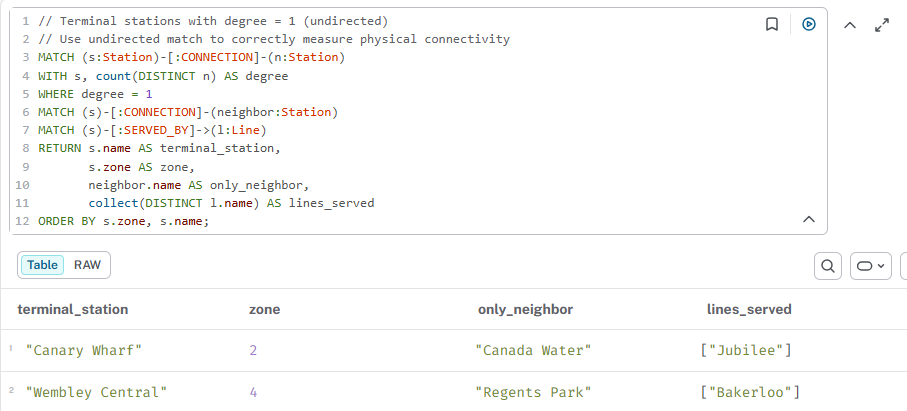

In [ ]:
// What happens if the sole neighbor is removed?
//Simulate isolation: count paths from the terminalto any other station
MATCH (terminal:Station {name: 'Canary Wharf'})
MATCH (blocker:Station {name: 'Canada Water'})
MATCH (other:Station)
WHERE other <> terminal AND other <> blocker
WITH terminal, blocker, other,
  shortestPath((terminal)-[:CONNECTION*]-(other)) AS p
WHERE NONE(n IN nodes(p) WHERE n = blocker)
RETURN
  count(other) AS reachable_without_canada_water;

### **Query Logic - Simulating Terminal Station Isolation**
This Cypher query simulates the isolation of a terminal station by counting how many other stations remain reachable if its sole neighbor is removed.

*   `MATCH (terminal:Station {name: 'Canary Wharf'})`: This clause identifies the specific 'terminal' station for the simulation, in this case, 'Canary Wharf', by matching its `name` property.

*   `MATCH (blocker:Station {name: 'Canada Water'})`: This clause identifies the 'blocker' station, which is the sole neighbor of the `terminal` station. If this `blocker` is removed, the terminal station's connectivity is tested. Here, it's 'Canada Water', which is Canary Wharf's only direct connection.

*   `MATCH (other:Station)`: This matches all other `Station` nodes in the graph, representing potential target stations to check for reachability.

*   `WHERE other <> terminal AND other <> blocker`: This filters out the `terminal` and `blocker` stations from the `other` set, as we are interested in reachability to *other* distinct stations in the network.

*   `WITH terminal, blocker, other, shortestPath((terminal)-[:CONNECTION*]-(other)) AS p`: This is a crucial step. For each `terminal` and `other` station pair, it attempts to find the shortest path (`p`) between them using `CONNECTION` relationships. `shortestPath` here prioritizes paths with the fewest hops.

*   `WHERE NONE(n IN nodes(p) WHERE n = blocker)`: This is the core of the simulation. It filters the found paths (`p`) to include *only those paths that do NOT contain the `blocker` station* ('Canada Water' in this example). If no such path exists, `p` will be `null` for that `other` station.

*   `RETURN count(other) AS reachable_without_canada_water;`: Finally, it counts how many `other` stations are still reachable from the `terminal` station *without* passing through the `blocker` station. The result is aliased as `reachable_without_canada_water`.

**Purpose and Benefits:**
*   **Empirical Vulnerability Assessment**: This query moves beyond theoretical identification of terminal stations (as done in section 2.10 and 3.2) to empirically demonstrate the impact of removing their sole neighbor. A `reachable_without_blocker` count of `0` conclusively proves complete isolation.
*   **Single Point of Failure Confirmation**: It quantifies the dependency of a terminal station on its single connection. If removing the 'blocker' results in zero reachable stations, it confirms the 'blocker' as a hard single point of failure for that terminal.
*   **Network Resilience Insight**: Helps in understanding the fragility of specific network components. While terminal stations themselves might not be high-traffic, their isolation can impact local populations significantly, especially if they serve critical destinations.
*   **Contingency Planning**: Provides data to inform emergency response and contingency plans. Knowing which stations become isolated under specific failure scenarios allows for proactive measures like alternative transport arrangements.

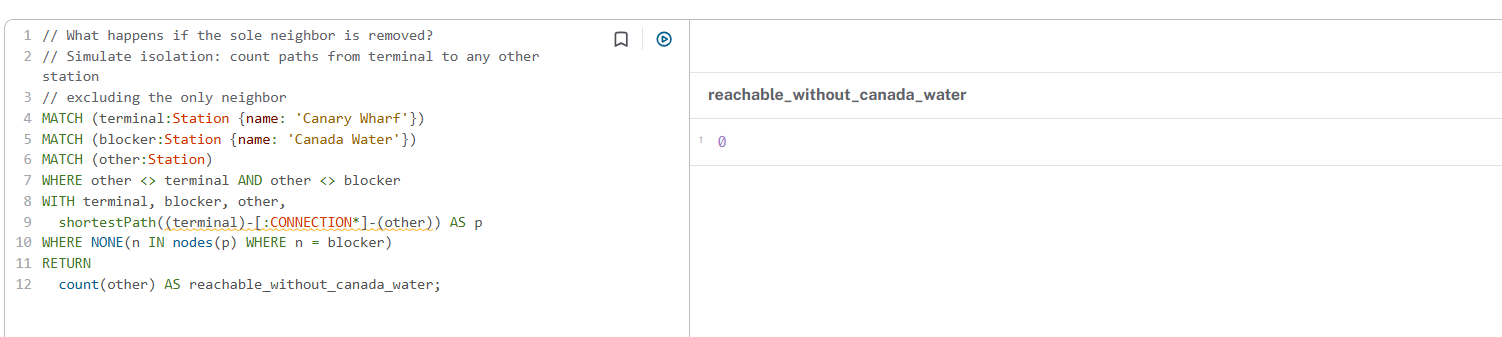

In [ ]:
// Repeat isolation test for Wembley Central
MATCH (terminal:Station {name: 'Wembley Central'})
MATCH (blocker:Station {name: 'Regents Park'})
MATCH (other:Station)
WHERE other <> terminal AND other <> blocker
WITH terminal, blocker, other,
  shortestPath((terminal)-[:CONNECTION*]-(other)) AS p
WHERE NONE(n IN nodes(p) WHERE n = blocker)
RETURN
  count(other) AS reachable_without_regents_park;

### **Query Logic - Simulating Wembley Central Isolation**
This Cypher query is identical in logic to the previous one, but specifically targets 'Wembley Central' as the `terminal` station and 'Regents Park' as its `blocker` (sole neighbor). Its purpose is to empirically test the isolation of Wembley Central if its only direct connection is removed.

*   `MATCH (terminal:Station {name: 'Wembley Central'})`: Identifies 'Wembley Central' as the terminal station for this simulation.

*   `MATCH (blocker:Station {name: 'Regents Park'})`: Identifies 'Regents Park' as the blocker station, which is Wembley Central's only direct neighbor in this dataset.

*   `MATCH (other:Station)`: Matches all other stations in the network.

*   `WHERE other <> terminal AND other <> blocker`: Excludes the terminal and blocker stations from the set of 'other' stations to check for reachability.

*   `WITH terminal, blocker, other, shortestPath((terminal)-[:CONNECTION*]-(other)) AS p`: For each 'terminal' and 'other' station pair, it attempts to find the shortest path between them.

*   `WHERE NONE(n IN nodes(p) WHERE n = blocker)`: This crucial filter includes only those paths that *do not* contain the 'Regents Park' station. If no such path exists, 'p' will be null for that 'other' station.

*   `RETURN count(other) AS reachable_without_regents_park;`: Counts how many other stations are reachable from 'Wembley Central' *without* passing through 'Regents Park'.

**Purpose and Benefits:**
This query provides empirical evidence for the vulnerability of 'Wembley Central'. If the `count(other)` returns `0`, it definitively proves that 'Regents Park' is a single point of failure for 'Wembley Central', as its removal would render 'Wembley Central' completely isolated from the rest of the network within the constraints of this dataset. This insight is vital for understanding network resilience and planning for disruptions, especially given Wembley Central's importance as a gateway to major event venues.

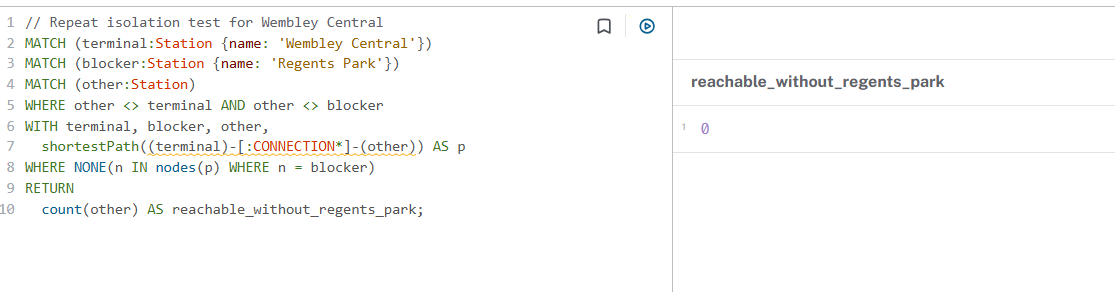

###**Confirmation**

The query returns 2 terminal stations:

**Canary Wharf** in Zone 2 is served exclusively by the **Jubilee** line and connects
only to **Canada Water**. The isolation simulation confirms that when Canada Water is
treated as a blocker, Canary Wharf can reach **0 other stations** in the network. This
empirically proves that Canada Water is a hard single point of failure for Canary Wharf:
its removal from the network completely isolates the station with no alternative routing
available. In operational terms this would strand all passengers attempting to reach or
depart Canary Wharf, one of London's major financial district destinations.

**Wembley Central** in Zone 4 is served exclusively by the **Bakerloo** line and connects
only to **Regents Park**. The isolation simulation similarly confirms that when Regents
Park is treated as a blocker, Wembley Central can reach **0 other stations** in the
network. This confirms that Regents Park is a hard single point of failure for Wembley
Central. Given that Wembley Central serves as a gateway to Wembley Stadium, one of the
UK's largest event venues, this structural vulnerability is operationally significant
during high demand event periods.

***Resilience Implications***

The isolation simulations returning 0 in both cases provide definitive empirical
confirmation of the theoretical argument: terminal stations are completely dependent on
their sole neighbor for any network connectivity whatsoever. The presence of terminal
stations creates two distinct categories of resilience risk. The first is track segment
vulnerability: a single track failure between a terminal and its only neighbor immediately
isolates the terminal with no rerouting possible. The second is neighbor station
vulnerability: the sole connecting neighbor of each terminal functions as a de facto
single point of failure for that terminal's accessibility. In both cases the network has
no redundancy to absorb the disruption.

However, the overall resilience picture remains relatively strong given that only 2 of
the 80 stations in the dataset are true terminals. This low proportion reflects the
generally well connected and multi-line nature of the central London network, where most
stations have at least two neighbors and can be reached via multiple routes. The more
significant resilience risks in this dataset are concentrated not at the terminals but
at the high-centrality interchange stations identified in section 2.7, whose removal
would affect far more passengers and shortest paths across the entire network. These will
be formally quantified in the resilience simulation of Part 4.

###**Conclusion**

This analysis reveals that there are exactly 2 terminal stations in the dataset Canary Wharf on the Jubilee line and Wembley Central on the Bakerloo line. The isolation simulation is the key finding: removing Canada Water reduces Canary Wharf's reachable station count to zero, and removing Regents Park does the same to Wembley Central. Both terminals are completely stranded  not just harder to reach, but entirely unreachable from the rest of the network. This is the most severe resilience failure possible in a graph. However, in reality, Canary Wharf is also served by the DLR and Elizabeth line, so this vulnerability exists only within the scope of this dataset, not the full Tube network.

##**3.3 Local Clustering Coefficient Proxy**

The local clustering coefficient measures the degree to which a station's immediate
neighbors are themselves connected to each other. For a station S with N neighbors, it
is computed as the ratio of actual CONNECTION relationships among those neighbors to the
maximum possible number of such connections, given by N*(N-1)/2. A coefficient of 1.0
indicates that all of a station's neighbors are directly connected to each other, forming
a fully interconnected local cluster. A coefficient of 0.0 indicates that none of the
neighbors are connected to each other, meaning the station is the sole bridge between
them.

To ensure correctness, each neighbor pair is evaluated exactly once by enforcing a strict
index ordering during the pair generation step, preventing double counting of bidirectional
CONNECTION relationships and ensuring all coefficient values fall within the valid range
of 0 to 1.

In the context of transit network topology, a high clustering coefficient at a station
means that its neighboring stations are also directly connected to each other via
alternative routes. This implies strong local redundancy: if the central station were
removed, its neighbors could still reach each other through direct connections rather
than requiring a long detour through the broader network. Paradoxically, this means that
high clustering coefficient stations, while locally well connected, may be less critical
to overall network resilience than low clustering coefficient stations, whose neighbors
depend entirely on them as a bridge.

A low clustering coefficient, by contrast, indicates that a station's neighbors are not
directly connected to each other and depend on that station as the primary routing hub
between them. These stations are more likely to emerge as high betweenness centrality
nodes in Part 4, as many shortest paths between their disconnected neighbors must pass
through them.

In [ ]:
//Top 10 clustering coefficients:
MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)
WITH s, collect(DISTINCT neighbor) AS neighbours
WHERE size(neighbours) > 1
WITH s, neighbours, size(neighbours) AS degree
UNWIND range(0, size(neighbours)-2) AS i
UNWIND range(i+1, size(neighbours)-1) AS j
WITH s, degree, neighbours[i] AS n1, neighbours[j] AS n2
OPTIONAL MATCH (n1)-[:CONNECTION]-(n2)
WITH s, degree,
     count(CASE WHEN (n1)-[:CONNECTION]-(n2) THEN 1 END) AS connected
WITH s, degree,
     sum(CASE WHEN connected > 0 THEN 1 ELSE 0 END) AS edges_among_neighbours,
     (degree * (degree - 1)) / 2.0 AS max_possible
RETURN s.name AS station,
       s.zone AS zone,
       degree,
       edges_among_neighbours,
       round(max_possible, 2) AS max_possible,
       round(edges_among_neighbours / max_possible, 4) AS clustering_coefficient
ORDER BY clustering_coefficient DESC
LIMIT 10;

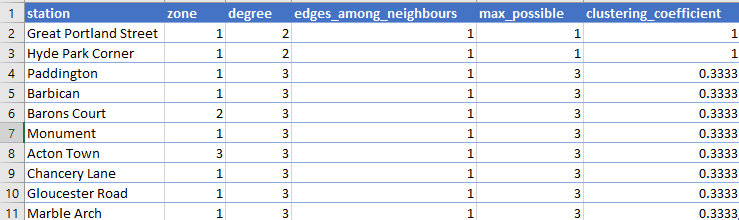

### **Query Logic - Top 10 Clustering Coefficients**

This Cypher query calculates the local clustering coefficient for each station with at least two neighbors and then returns the top 10 stations with the highest coefficients. The local clustering coefficient measures the degree to which a station's immediate neighbors are themselves connected to each other.

*   `MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)`: This clause finds all `Station` nodes (`s`) that are connected to a `neighbor` `Station` via an undirected `CONNECTION` relationship. This is the first step to identify a station and its direct neighbors.

*   `WITH s, collect(DISTINCT neighbor) AS neighbours`: For each `Station` (`s`), this collects all its distinct `neighbor` stations into a list called `neighbours`.

*   `WHERE size(neighbours) > 1`: This filters out stations that have fewer than two neighbors. A clustering coefficient cannot be calculated for stations with 0 or 1 neighbor because the formula for maximum possible connections would result in division by zero or an undefined ratio.

*   `WITH s, neighbours, size(neighbours) AS degree`: This passes the `Station` (`s`), its `neighbours` list, and the `size` of that list (which is the station's `degree`) to the next step.

*   `UNWIND range(0, size(neighbours)-2) AS i`:
*   `UNWIND range(i+1, size(neighbours)-1) AS j`: These two `UNWIND` clauses create all unique pairs of neighbors for each station. They iterate through the `neighbours` list to select two distinct neighbors (`neighbours[i]` and `neighbours[j]`) without duplicating pairs or considering a neighbor connecting to itself. This is crucial for correctly counting edges among neighbors.

*   `WITH s, degree, neighbours[i] AS n1, neighbours[j] AS n2`: This passes the station, its degree, and the current pair of neighbors (`n1`, `n2`) to the next step.

*   `OPTIONAL MATCH (n1)-[:CONNECTION]-(n2)`: This clause attempts to find an undirected `CONNECTION` relationship between the two selected neighbors (`n1` and `n2`). `OPTIONAL MATCH` is used because not all neighbor pairs will necessarily be connected. If no connection exists, `n1` and `n2` are still passed along, but the `(n1)-[:CONNECTION]-(n2)` pattern will be `null`.

*   `WITH s, degree, count(CASE WHEN (n1)-[:CONNECTION]-(n2) THEN 1 END) AS connected`: This counts how many of the neighbor pairs found in the previous step are actually connected. If `(n1)-[:CONNECTION]-(n2)` exists, `CASE WHEN ... THEN 1 END` evaluates to 1, otherwise to `null` (which `count` ignores), effectively counting only the existing connections.

*   `WITH s, degree, sum(CASE WHEN connected > 0 THEN 1 ELSE 0 END) AS edges_among_neighbours, (degree * (degree - 1)) / 2.0 AS max_possible`: This aggregates the count of `connected` pairs per station into `edges_among_neighbours`. It also calculates the `max_possible` number of connections between `degree` neighbors using the formula `N*(N-1)/2` (where N is `degree`).

*   `RETURN s.name AS station, s.zone AS zone, degree, edges_among_neighbours, round(max_possible, 2) AS max_possible, round(edges_among_neighbours / max_possible, 4) AS clustering_coefficient`: This returns the station's name, zone, degree, actual connections among its neighbors, maximum possible connections, and the calculated `clustering_coefficient` (rounded to 4 decimal places).

*   `ORDER BY clustering_coefficient DESC LIMIT 10`: Finally, the results are ordered by the clustering coefficient in descending order, and only the top 10 stations are returned.

**Purpose and Benefits:**
*   **Local Redundancy**: A high clustering coefficient indicates strong local redundancy, meaning if the central station were removed, its neighbors could still reach each other through direct alternative routes.
*   **Bottleneck Identification (Inverse)**: Conversely, a low clustering coefficient suggests that a station's neighbors are not directly connected and depend on that station as a primary routing hub. These stations are more likely to be critical bottlenecks.
*   **Network Structure Insight**: Provides insight into the local interconnectedness of the network, complementing global measures like betweenness centrality.

###**Network-wide average clustering coefficient**

In [ ]:
// Network average clustering coefficient
MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)
WITH s, collect(DISTINCT neighbor) AS neighbours
WHERE size(neighbours) > 1
WITH s, neighbours, size(neighbours) AS degree
UNWIND range(0, size(neighbours)-2) AS i
UNWIND range(i+1, size(neighbours)-1) AS j
WITH s, degree, neighbours[i] AS n1, neighbours[j] AS n2
OPTIONAL MATCH (n1)-[:CONNECTION]-(n2)
WITH s, degree,
     sum(CASE WHEN (n1)-[:CONNECTION]-(n2) THEN 1 ELSE 0 END) AS edges_among,
     (degree * (degree - 1)) / 2.0 AS max_possible
RETURN round(avg(edges_among / max_possible), 4) AS avg_clustering_coefficient,
       count(s) AS stations_included;

### **Query Logic - Network-wide average clustering coefficient**

This Cypher query calculates the average local clustering coefficient across all stations in the network that have at least two neighbors. It reuses much of the logic from the per-station clustering coefficient calculation but aggregates the final result.

*   `MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)`: This finds all `Station` nodes (`s`) connected to a `neighbor` `Station` via an undirected `CONNECTION` relationship.

*   `WITH s, collect(DISTINCT neighbor) AS neighbours`:
    *   For each `Station` (`s`), it collects all its distinct `neighbor` stations into a list called `neighbours`.

*   `WHERE size(neighbours) > 1`:
    *   Filters out stations with fewer than two neighbors, as a clustering coefficient cannot be calculated for them.

*   `WITH s, neighbours, size(neighbours) AS degree`:
    *   Passes the station, its `neighbours` list, and the `size` of that list (`degree`) to the next step.

*   `UNWIND range(0, size(neighbours)-2) AS i`
*   `UNWIND range(i+1, size(neighbours)-1) AS j`:
    *   These clauses generate all unique pairs of neighbors (`n1`, `n2`) for each station, ensuring each pair is considered only once.

*   `WITH s, degree, neighbours[i] AS n1, neighbours[j] AS n2`:
    *   Passes the station, its degree, and the current pair of neighbors to the next step.

*   `OPTIONAL MATCH (n1)-[:CONNECTION]-(n2)`:
    *   Attempts to find an undirected `CONNECTION` relationship between the two selected neighbors. `OPTIONAL MATCH` ensures the query continues even if no connection exists.

*   `WITH s, degree, sum(CASE WHEN (n1)-[:CONNECTION]-(n2) THEN 1 ELSE 0 END) AS edges_among, (degree * (degree - 1)) / 2.0 AS max_possible`:
    *   `edges_among`: Counts how many of the neighbor pairs are actually connected.
    *   `max_possible`: Calculates the maximum possible number of connections between `degree` neighbors using the formula `N*(N-1)/2`.

*   `RETURN round(avg(edges_among / max_possible), 4) AS avg_clustering_coefficient, count(s) AS stations_included`:
    *   `avg(edges_among / max_possible)`: This is the core aggregation. It calculates the clustering coefficient for each individual station (that passed the `WHERE size(neighbours) > 1` filter) and then computes the average of these individual coefficients across all included stations.
    *   `round(..., 4)`: Rounds the average clustering coefficient to four decimal places.
    *   `count(s)`: Returns the total number of stations that were included in the average calculation (i.e., those with at least two neighbors).

**Purpose and Benefits:**
*   **Network-wide Metric**: Provides a single, summarized value for the average interconnectedness of stations' immediate neighborhoods across the entire network. A higher average indicates a more tightly knit network locally.
*   **Context for Individual Scores**: Offers a benchmark against which individual station clustering coefficients can be compared.
*   **Modularity Assessment**: Along with the overall modularity score from community detection, this average helps to understand the structural properties of the graph in terms of local clustering.
*   **Understanding Redundancy**: A high average clustering coefficient suggests a network with more local redundancy, meaning that local disruptions might be less impactful as alternative direct paths often exist between immediate neighbors.

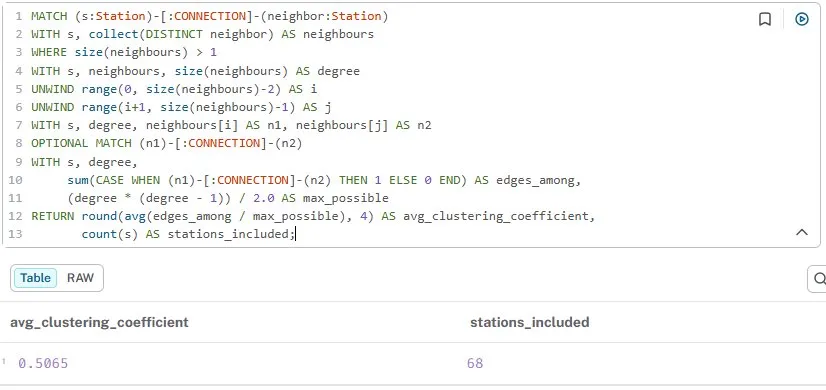

This query computed the **network-wide average clustering coefficient** by averaging the per-station coefficient across all stations with at least two neighbours. It returned an average clustering coefficient of 0.5065 across 68 stations. This warrants a further investigation on why 68 stations were used in the computation instead of the 80 station in the data set.

### **Investigation: Why Are Only 68 Stations Included?**

The network average query includes only 68 of the 80 stations in the dataset. The
`WHERE size(neighbours) > 1` filter excludes any station with fewer than 2 distinct
neighbors, since the clustering coefficient formula requires at least 2 neighbors to
compute a meaningful ratio. With only 1 neighbor, max_possible = 0 and the division
is undefined. We investigate which stations are excluded and why.

In [ ]:
//Identify excluded stations:
MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)
WITH s, collect(DISTINCT neighbor) AS neighbours
WHERE size(neighbours) <= 1
RETURN s.name AS station,
       s.zone AS zone,
       size(neighbours) AS neighbor_count,
       [n IN neighbours | n.name] AS neighbors
ORDER BY neighbor_count, station;

### **Query Logic - Identify Excluded Stations**

This Cypher query identifies stations that were excluded from the clustering coefficient calculation because they have one or fewer distinct neighbors.

*   `MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)`:
    *   This clause finds all `Station` nodes (`s`) that are connected to at least one `neighbor` `Station` via an undirected `CONNECTION` relationship.
    *   Crucially, stations with zero connections will *not* be matched by this pattern and will therefore not appear in the results of this specific query.

*   `WITH s, collect(DISTINCT neighbor) AS neighbours`:
    *   For each `Station` (`s`) found, it collects all its unique `neighbor` stations into a list called `neighbours`.

*   `WHERE size(neighbours) <= 1`:
    *   This filters the stations to include only those whose `neighbours` list contains one or zero (distinct) entries. These are the stations with insufficient connections for a meaningful clustering coefficient calculation.

*   `RETURN s.name AS station, s.zone AS zone, size(neighbours) AS neighbor_count, [n IN neighbours | n.name] AS neighbors`:
    *   `s.name AS station`: The name of the excluded station.
    *   `s.zone AS zone`: The fare zone of the excluded station.
    *   `size(neighbours) AS neighbor_count`: The number of distinct neighbors this station has.
    *   `[n IN neighbours | n.name] AS neighbors`: A list of the names of its neighbors (will be an empty list if `neighbor_count` is 0, or contain one name if `neighbor_count` is 1).

*   `ORDER BY neighbor_count, station`:
    *   Sorts the results first by the number of neighbors (ascending), and then by station name for clear presentation.

**Purpose and Benefits:**
*   **Debugging Clustering Coefficient**: This query is essential for understanding why certain stations might be excluded from algorithms like the local clustering coefficient, which require a minimum number of neighbors (typically 2).
*   **Identifying Terminal Stations**: It directly identifies 'terminal' stations (those with `neighbor_count = 1`), which are crucial for network resilience analysis (as explored in section 3.2).
*   **Revealing Near-Isolated Nodes**: While it doesn't show truly isolated nodes (those with 0 connections), it helps pinpoint stations that are on the verge of isolation or have very limited connectivity, which can be critical for understanding data gaps or network vulnerabilities.

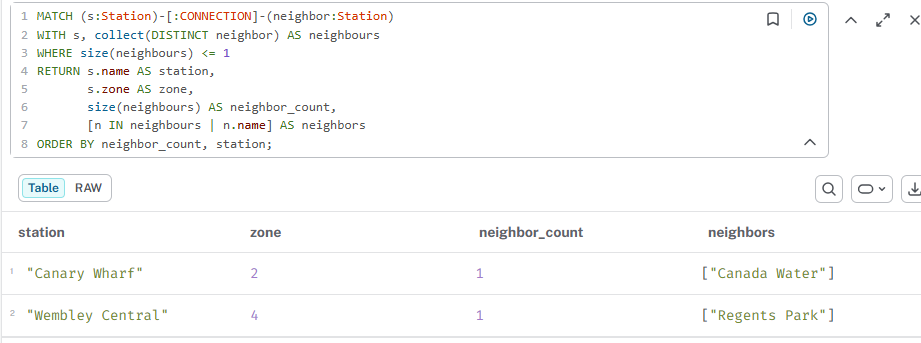

The exclusion query returns only 2 stations with neighbor_count <= 1, both of which are
the terminal stations identified in section 3.2. However the network average query
includes only 68 stations, meaning 10 additional stations are being excluded. A follow
up query is needed to determine whether these stations have 0 neighbors and are therefore
not returned by the MATCH at all.

In [ ]:
//Confirm stations with multiple neighbors:
MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)
WITH s, collect(DISTINCT neighbor) AS neighbours
WHERE size(neighbours) > 1
RETURN count(s) AS stations_with_multiple_neighbors;

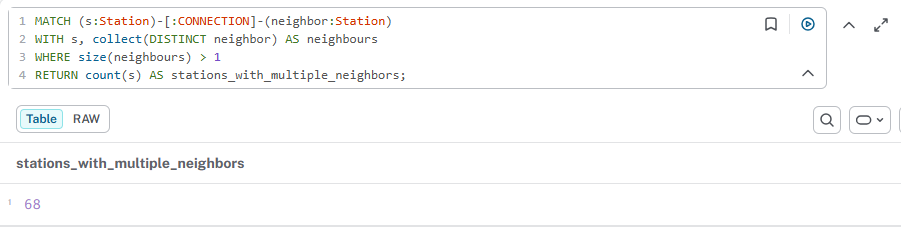

### **Query Logic - Confirm Stations with Multiple Neighbors**
This Cypher query counts the number of stations that have two or more distinct neighbors connected via a `:CONNECTION` relationship.

*   `MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)`:
    *   This clause finds all `Station` nodes (`s`) that are connected to at least one `neighbor` `Station` via an undirected `:CONNECTION` relationship. The undirected match (`-`) considers connections in both directions to determine physical connectivity.

*   `WITH s, collect(DISTINCT neighbor) AS neighbours`:
    *   For each `Station` (`s`) found in the previous step, it collects all its unique `neighbor` stations into a list called `neighbours`. Using `DISTINCT neighbor` ensures that if a station is connected to the same physical neighbor via multiple lines, that neighbor is counted only once.

*   `WHERE size(neighbours) > 1`:
    *   This filters the results to include only those stations whose `neighbours` list contains more than one distinct entry. This means stations with two or more distinct physical connections.

*   `RETURN count(s) AS stations_with_multiple_neighbors`:
    *   Finally, this counts the total number of `Station` nodes that satisfy the filtering condition (i.e., have more than one distinct neighbor) and returns this count, aliased as `stations_with_multiple_neighbors`.

**Purpose and Benefits:**
*   **Complementary to Exclusion Query**: This query works in conjunction with the "Identify Excluded Stations" query. While that query finds stations with 0 or 1 neighbor, this one finds stations with 2 or more. Together, they help to fully characterize the connectivity of all stations in the dataset.
*   **Understanding Algorithm Inclusions**: It confirms how many stations are considered 'sufficiently connected' for algorithms that require a minimum number of neighbors (like the clustering coefficient, which needs at least 2 neighbors).
*   **Data Consistency Check**: Helps verify that the number of stations with multiple neighbors, plus the number of stations with 1 neighbor, plus the number of stations with 0 neighbors (isolated), sums up to the total number of stations in the graph (80 in this case).

This confirms that exactly 68 stations pass the `size(neighbours) > 1` filter, meaning
12 stations in total are excluded. Since only 2 stations were returned by the exclusion
query with neighbor_count <= 1, the remaining 10 excluded stations must have 0 neighbors
and are not returned by the MATCH clause at all. We investigate further by checking the
degree distribution across all stations.

In [ ]:
//Full degree distribution:
MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)
WITH s, collect(DISTINCT neighbor) AS neighbours
RETURN size(neighbours) AS neighbor_count,
       count(s) AS station_count
ORDER BY neighbor_count;

### **Query Logic - Full Degree Distribution**

This Cypher query calculates the distribution of connection degrees across all stations in the network. It groups stations by their number of distinct neighbors and counts how many stations fall into each group.

*   `MATCH (s:Station)-[:CONNECTION]-(neighbor:Station)`:
    *   This clause finds all `Station` nodes (`s`) that have *any* `CONNECTION` relationship (undirected, as indicated by `--`) to another `Station` node (`neighbor`).
    *   Crucially, stations with **zero connections** will *not* be matched by this pattern because there is no relationship to traverse. Therefore, these isolated stations will not appear in the results of this query.

*   `WITH s, collect(DISTINCT neighbor) AS neighbours`:
    *   For each `Station` (`s`) found in the previous step, this collects all its unique `neighbor` stations into a list called `neighbours`. Using `DISTINCT neighbor` ensures that if a station is connected to the same physical neighbor via multiple lines, that neighbor is counted only once towards its degree.

*   `RETURN size(neighbours) AS neighbor_count, count(s) AS station_count`:
    *   `size(neighbours) AS neighbor_count`: Calculates the number of distinct neighbors for each station (`s`) and aliases it as `neighbor_count`. This represents the degree of the station.
    *   `count(s) AS station_count`: Counts how many stations have that specific `neighbor_count`.

*   `ORDER BY neighbor_count`:
    *   Sorts the results in ascending order based on the `neighbor_count`, making the output easy to read and understand the distribution from least to most connected stations.

**Purpose and Benefits:**
*   **Connectivity Overview**: Provides a comprehensive overview of how connected stations are within the network. It shows how many stations have 1 neighbor, 2 neighbors, 3 neighbors, and so on.
*   **Identifying Isolated Nodes (Indirectly)**: While it doesn't explicitly list stations with 0 neighbors, its output is key to inferring their existence by showing the total count of stations with 1 or more neighbors. If this sum is less than the total number of stations in the dataset, the difference represents the count of isolated stations.
*   **Input for Further Analysis**: Understanding the degree distribution is foundational for many graph algorithms and for interpreting other centrality measures. For example, some algorithms (like clustering coefficient) require a minimum number of neighbors to be calculated.

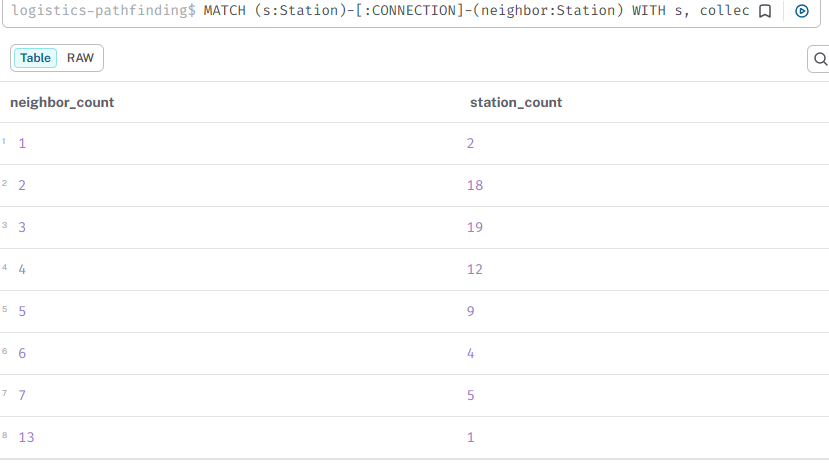

The distribution confirms that 68 stations have 2 or more neighbors and 2 stations have
exactly 1 neighbor, accounting for 70 stations in total. The remaining 10 stations have
0 neighbors and do not appear in the MATCH output at all since they have no CONNECTION
relationships to traverse. We now identify these 10 isolated stations explicitly.

In [ ]:
//Identify isolated stations with degree 0:
MATCH (s:Station)
WITH s,
     size([(s)-[:CONNECTION]-(n:Station) | n]) AS undirected_degree,
     size([(s)-[:CONNECTION]->(n:Station) | n]) AS out_degree,
     size([(n:Station)-[:CONNECTION]->(s) | n]) AS in_degree
WHERE undirected_degree <= 1
RETURN s.name AS station,
       s.zone AS zone,
       undirected_degree,
       out_degree,
       in_degree
ORDER BY undirected_degree, station;

### **Query Logic - Identify Isolated Stations with Degree 0**

This Cypher query identifies stations that are completely isolated within the network, meaning they have no `CONNECTION` relationships to any other station.

*   `MATCH (s:Station)`: This clause simply matches every node in the database that has the label `Station` and binds it to the variable `s`. This ensures that even stations with zero connections are considered.

*   `WITH s, size([(s)-[:CONNECTION]-(n:Station) | n]) AS undirected_degree, size([(s)-[:CONNECTION]->(n:Station) | n]) AS out_degree, size([(n:Station)-[:CONNECTION]->(s) | n]) AS in_degree`:
    *   This `WITH` clause calculates various degree metrics for each station `s`.
    *   `size([(s)-[:CONNECTION]-(n:Station) | n]) AS undirected_degree`: This uses a list comprehension to count the number of *distinct* neighbors `n` connected to `s` via an *undirected* `CONNECTION` relationship. This is the effective 'degree' for physical connectivity, regardless of relationship direction.
    *   `size([(s)-[:CONNECTION]->(n:Station) | n]) AS out_degree`: This counts the number of distinct neighbors `n` that `s` has an *outgoing* `CONNECTION` relationship to.
    *   `size([(n:Station)-[:CONNECTION]->(s) | n]) AS in_degree`: This counts the number of distinct neighbors `n` that have an *incoming* `CONNECTION` relationship to `s`.

*   `WHERE undirected_degree <= 1`: This filters the results to include stations that have an undirected degree of 0 (truly isolated) or 1 (terminal stations). While the query title specifically mentions 'degree 0', this condition captures both the isolated (0-degree) and terminal (1-degree) stations, which are typically considered together when analyzing network periphery.

*   `RETURN s.name AS station, s.zone AS zone, undirected_degree, out_degree, in_degree`:
    *   `s.name AS station`: The name of the station.
    *   `s.zone AS zone`: The fare zone of the station.
    *   `undirected_degree`: The total count of distinct neighbors the station is connected to (undirected).
    *   `out_degree`: The count of distinct neighbors reachable via an outgoing connection.
    *   `in_degree`: The count of distinct neighbors from which an incoming connection exists.

*   `ORDER BY undirected_degree, station`: The results are ordered first by the `undirected_degree` (ascending), then by the station `name` for clarity.

**Purpose and Benefits:**

*   **Explicitly Identify Isolated Nodes**: This query directly identifies stations that are part of the dataset but are not connected to the rest of the network via any `CONNECTION` relationship. This is critical for understanding data completeness and the actual traversable graph.
*   **Distinguish from Terminal Nodes**: By returning `undirected_degree`, it clearly differentiates between completely isolated stations (degree 0) and terminal stations (degree 1), which are both peripheral but have different implications for reachability.
*   **Data Validation and Debugging**: Helps confirm data ingestion accuracy. If stations are expected to be connected but show a degree of 0, it points to potential issues in the `london.connections.csv` file or the ingestion process itself.
*   **Understanding Network Fragility**: Isolated stations cannot participate in any routing or shortest path calculations, highlighting significant gaps in network coverage or data.

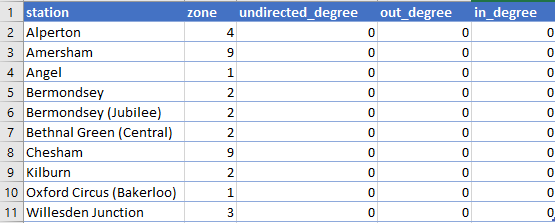

This `LOAD CSV` query re-reads the connections file and checks whether the station ids of the 10 identified isolated stations appear anywhere in the `station1` or `station2` columns. If none of their ids are found, it conclusively establishes that their absence from the connection graph is a **source data gap** rather than an ingestion error — the stations exist in `london.stations.csv` but have no entries in `london.connections.csv`.

In [ ]:
//Verify absence from connections CSV:
LOAD CSV WITH HEADERS FROM 'file:///london.connections.csv' AS row
WITH collect(toInteger(row.station1)) + collect(toInteger(row.station2)) AS all_ids
MATCH (s:Station)
WHERE s.name IN ['Alperton', 'Amersham', 'Angel', 'Bermondsey',
                 'Bermondsey (Jubilee)', 'Bethnal Green (Central)',
                 'Chesham', 'Kilburn', 'Oxford Circus (Bakerloo)',
                 'Willesden Junction']
RETURN s.name AS station,
       s.id AS station_id,
       CASE WHEN s.id IN all_ids THEN 'present in CSV'
            ELSE 'absent from CSV' END AS csv_status;

### **Query Logic - Verify Absence from Connections CSV**
This Cypher query is designed to verify whether a predefined list of station IDs (identified as isolated in previous analyses) are actually present in the `london.connections.csv` file.

*   `LOAD CSV WITH HEADERS FROM 'file:///london.connections.csv' AS row`:This clause reads the `london.connections.csv` file, treating the first row as headers. Each subsequent row is then referenced as `row`.

*   `WITH collect(toInteger(row.station1)) + collect(toInteger(row.station2)) AS all_ids`:This collects all `station1` and `station2` IDs from the CSV rows, converts them to integers, and combines them into a single list called `all_ids`. This list effectively represents all station IDs that appear in any connection within the CSV.

*   `MATCH (s:Station)`:This matches every node in the graph that has the label `:Station` and binds it to the variable `s`. This ensures all stations in the database are considered, even if they have no connections.

*   `WHERE s.name IN ['Alperton', 'Amersham', 'Angel', 'Bermondsey', 'Bermondsey (Jubilee)', 'Bethnal Green (Central)', 'Chesham', 'Kilburn', 'Oxford Circus (Bakerloo)', 'Willesden Junction']`: This filters the matched `Station` nodes to only include those whose names are in the provided list. These are the 10 stations previously identified as isolated or having 0 connections.

*   `RETURN s.name AS station, s.id AS station_id, CASE WHEN s.id IN all_ids THEN 'present in CSV' ELSE 'absent from CSV' END AS csv_status`:
    *   `s.name AS station`: Returns the name of the selected station.
    *   `s.id AS station_id`: Returns the ID of the selected station.
    *   `CASE WHEN s.id IN all_ids THEN 'present in CSV' ELSE 'absent from CSV' END AS csv_status`: This `CASE` statement checks if the station's `id` is found within the `all_ids` list (which contains all station IDs from the connections CSV). If it is, the status is 'present in CSV'; otherwise, it's 'absent from CSV'.

**Purpose and Benefits:**
*   **Data Gap Confirmation**: The primary purpose is to definitively confirm whether the isolated stations (with `undirected_degree = 0`) are truly absent from the source `london.connections.csv` file. This distinguishes between a data ingestion error and a genuine limitation of the dataset.
*   **Source Data Validation**: By checking against the raw CSV, this query provides strong evidence that the lack of connections for these stations originates in the source data itself, rather than from a mistake in the Cypher ingestion process.
*   **Informing Interpretation**: The result clarifies why these stations show no connections in the graph, which is critical for correctly interpreting centrality measures and network resilience in later stages of the analysis.

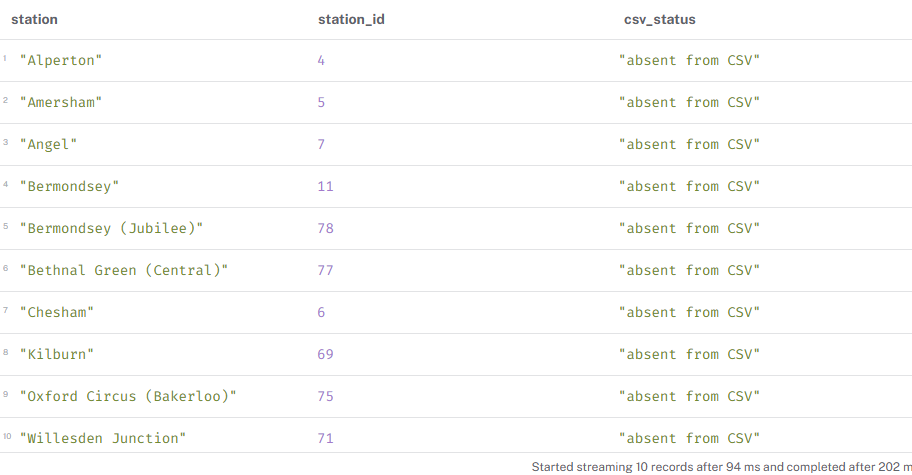

The CSV verification query conclusively confirms that all 10 isolated stations are
entirely absent from `london.connections.csv`. Their station ids do not appear as either
station1 or station2 in any row of the connections file. These stations were loaded into
the graph as `:Station` nodes during the ingestion in section 1.2 because they are
present in `london.stations.csv`, but no corresponding connection entries exist for them
in the connections file. This is a confirmed data gap in the source dataset rather than
an ingestion error.

The complete breakdown of the 80 stations in the dataset is therefore:

| Category | Count |
|---|---|
| Stations with 2 or more neighbors (included in clustering analysis) | 68 |
| Terminal stations with exactly 1 neighbor (Canary Wharf, Wembley Central) | 2 |
| Isolated stations with 0 neighbors (absent from connections CSV) | 10 |
| Total | 80 |

The 68 stations included in the network average clustering coefficient of **0.5065**
represent the complete set of stations for which the clustering coefficient is
mathematically defined and computationally valid. The 12 excluded stations are excluded
for principled reasons: 2 have insufficient neighbors for the formula and 10 have no
connections at all, making them structurally invisible to any graph traversal query.

###**Confirmation and Discussion**

The top 10 stations by local clustering coefficient are all located in Zone 1, consistent
with the geographic concentration of the dataset identified throughout the EDA.

**Great Portland Street** and **Hyde Park Corner** both achieve the maximum possible
clustering coefficient of **1.0**. Both stations have a degree of 2 with 1 edge among
their neighbors, meaning their two neighbors are directly connected to each other and
form a perfect local triangle. In practical terms this means that if either station were
removed, its two neighbors could still reach each other directly with no detour required,
making these stations locally redundant despite their Zone 1 position.

The remaining 8 stations in the top 10, namely Paddington, Barbican, Barons Court,
Monument, Acton Town, Chancery Lane, Gloucester Road, and Victoria, all return a
clustering coefficient of **0.3333**. Each has a degree of 3 or more with exactly 1
edge among their neighbor pairs relative to the maximum possible, reflecting a common
structural pattern in transit networks where a station sits at a line junction: two of
its neighbors are on the same line and directly connected to each other, while remaining
neighbors belong to different line corridors with no direct connection between them.

The notable absence of high degree interchange stations such as Kings Cross St. Pancras,
Green Park, and Waterloo from the top 10 is consistent with the theoretical expectation
outlined above. High degree stations tend to have lower clustering coefficients because
their many neighbors are spread across different line corridors and are unlikely to be
directly connected to each other. This confirms that the stations most critical to
network-wide connectivity, the major interchanges, are precisely those with the least
local redundancy, a finding that directly motivates the resilience simulation in Part 4.

## **3.4 Parallel Routes and Redundant Track Segments**

A redundant track segment exists where two or more distinct Tube lines serve the exact
same inter-station connection, meaning a passenger can travel between the same pair of
adjacent stations on more than one line. These parallel routes represent a form of
built-in network redundancy at the track level: if one line is suspended between two
stations, a passenger may still be able to complete the same segment on a parallel line
without any rerouting through the broader network.

This query identifies all station pairs connected by more than one distinct CONNECTION
relationship, each carrying a different line id. The `s1.id < s2.id` filter ensures
each undirected pair is returned exactly once. The average travel time across all
parallel lines serving each segment is included to highlight any timing differences
between parallel services.

In [ ]:
// Station pairs connected by more than one distinct line
MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)
WHERE s1.id < s2.id
WITH s1, s2,
     count(DISTINCT r.line) AS num_lines,
     collect(DISTINCT r.line) AS line_ids,
     avg(r.time) AS avg_time
WHERE num_lines > 1
UNWIND line_ids AS lid
MATCH (l:Line {id: lid})
WITH s1, s2, num_lines, avg_time, collect(l.name) AS line_names
RETURN s1.name AS station_a,
       s2.name AS station_b,
       num_lines,
       line_names,
       round(avg_time, 1) AS avg_travel_minutes
ORDER BY num_lines DESC, station_a;

### **Query Logic - Station Pairs Connected by More Than One Distinct Line**

This Cypher query identifies pairs of stations that are connected by more than one distinct Tube line, revealing redundant track segments in the network.

*   `MATCH (s1:Station)-[r:CONNECTION]->(s2:Station)`: This clause finds all directed `:CONNECTION` relationships (`r`) between any two `Station` nodes (`s1` and `s2`).

*   `WHERE s1.id < s2.id`:
This is a crucial filter that ensures each undirected pair of stations is considered only once. Since connections are ingested bidirectionally, this prevents double-counting and ensures that we count unique physical segments rather than directed relationships.

*   `WITH s1, s2, count(DISTINCT r.line) AS num_lines, collect(DISTINCT r.line) AS line_ids, avg(r.time) AS avg_time`:For each unique pair of stations (`s1`, `s2`), this clause aggregates information about the connections between them:
       *   `count(DISTINCT r.line) AS num_lines`: Counts how many *distinct* line IDs are present on the connections between `s1` and `s2`.
        *   `collect(DISTINCT r.line) AS line_ids`: Collects a list of these distinct line IDs.
      *   `avg(r.time) AS avg_time`: Calculates the average travel time across all connections between `s1` and `s2`.

*   `WHERE num_lines > 1`:This filters the results to include only those station pairs that are served by more than one distinct line, thus identifying the redundant segments.

*   `UNWIND line_ids AS lid`: This unwinds the `line_ids` list, effectively creating a separate row for each `line_id` associated with a redundant segment. This is done to then match the `Line` node details.

*   `MATCH (l:Line {id: lid})`: For each `line_id` (aliased as `lid`), this matches the corresponding `:Line` node (`l`) to retrieve its `name`.

*   `WITH s1, s2, num_lines, avg_time, collect(l.name) AS line_names`: This re-aggregates the data for each station pair, now including a list of the `line_names` that serve that segment.

*   `RETURN s1.name AS station_a, s2.name AS station_b, num_lines, line_names, round(avg_time, 1) AS avg_travel_minutes`: This clause returns the names of the two stations (`station_a`, `station_b`), the `num_lines` serving them, the `line_names` list, and the `avg_travel_minutes` for that segment (rounded to one decimal place).

*   `ORDER BY num_lines DESC, station_a`: The results are sorted first by the number of lines (descending), and then by the name of the first station (ascending) for readability.

**Purpose and Benefits:**
*   **Identify Redundancy**: This query directly identifies parts of the network where multiple lines serve the same inter-station segment, indicating built-in redundancy.
*   **Resilience Assessment**: These redundant segments are crucial for network resilience. If one line experiences a disruption, passengers can potentially use an alternative line on the same segment without needing complex rerouting.
*   **Operational Planning**: Helps in understanding where capacity can be shared and where disruptions might have a mitigated impact due to alternative services.
*   **Highlighting Multi-Line Corridors**: Provides insight into historically shared infrastructure or intentionally designed parallel routes.

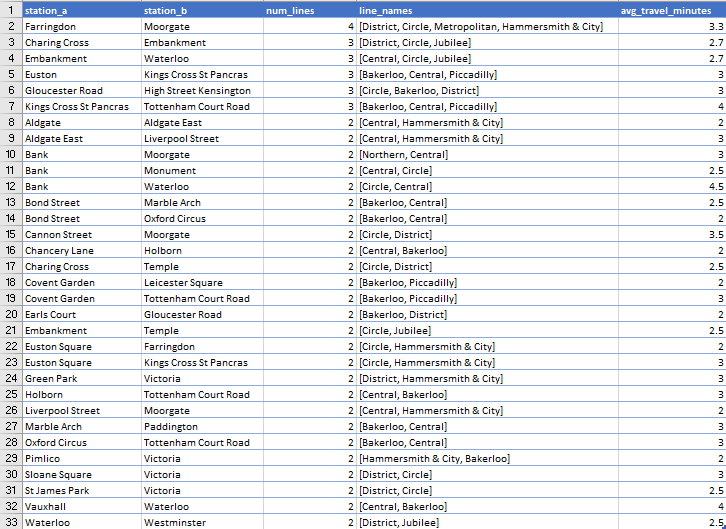

###**Confirmation**

The query returns **32 redundant track segments**, revealing that a substantial portion
of the network benefits from parallel line coverage. The results reveal a clear hierarchy
of redundancy levels:

**Four-line redundancy:** The segment between **Farringdon** and **Moorgate** is the most
redundant in the dataset, served by 4 distinct lines: District, Circle, Metropolitan, and
Hammersmith & City, with an average travel time of 3.3 minutes. This reflects the
historic shared infrastructure of these four lines through the central London underground
corridor, where they run on parallel tracks through the same tunnels. A suspension of any
single line on this segment would leave three alternative services still available to
passengers.

**Three-line redundancy:** Six segments are served by exactly 3 lines:
- **Charing Cross to Embankment** and **Embankment to Waterloo** are both served by the
District, Circle, and Jubilee lines at an average of 2.7 minutes, forming a highly
redundant southern central London corridor.
- **Euston to Kings Cross St. Pancras** is served by the Bakerloo, Central, and
Piccadilly lines at an average of 3.0 minutes, reflecting the dense parallel
infrastructure along the northern Zone 1 spine.
- **Gloucester Road to High Street Kensington** is served by the Circle, Bakerloo, and
District lines at an average of 3.0 minutes.
- **Kings Cross St. Pancras to Tottenham Court Road** is served by the Bakerloo, Central,
and Piccadilly lines at an average of 4.0 minutes, the highest average travel time among
the three-line segments.

**Two-line redundancy:** The remaining 25 segments are served by exactly 2 lines,
covering a broad spread of central London corridors including Aldgate to Aldgate East,
Bank to Moorgate, Bond Street to Oxford Circus, Covent Garden to Leicester Square, and
Waterloo to Westminster among others. These segments benefit from a single backup line
in the event of a disruption, providing partial but meaningful resilience.

***Operational Implications***

Parallel routes between the same station pair serve several operational functions. They
increase raw capacity on busy corridors by allowing multiple train services to serve the
same segment simultaneously. They provide schedule flexibility when one line is running
with reduced frequency, allowing the parallel line to absorb displaced passengers without
requiring them to reroute through the broader network. The concentration of the highest
redundancy segments around Farringdon, Moorgate, Kings Cross St. Pancras, and Embankment
is consistent with the interchange station analysis in section 2.7, confirming that the
most structurally important stations in the network are also the most operationally
protected by parallel infrastructure.

**Resilience Implications**

From a resilience perspective, redundant track segments are the most robust parts of the
network. A single line suspension on a parallel segment does not isolate any station or
break any shortest path, since the alternative line continues to serve the same
connection. This stands in direct contrast to the single track segments identified
elsewhere in the network, where any disruption immediately forces passengers onto longer
alternative routes. The 32 redundant segments identified here define the resilient core
of the London Underground dataset, concentrated almost entirely within Zone 1 where the
historic shared infrastructure of the oldest lines creates a naturally robust multi-line
corridor system.

##**3.5 Fastest access to Zone 1 from each outer zone**
Zone 1 contains London's commercial, government, and cultural core. For passengers living in outer zones, the travel time to the nearest Zone 1 station is a practical measure of how well connected their area is to the city centre. This query finds, for each outer zone, the station with the shortest weighted path to any Zone 1 station using shortestPath with a reduce accumulator to sum travel times along the path. The result reveals which zones enjoy fast access to the centre and which are structurally isolated a transit equity question with real policy implications.

In [ ]:
// For each outer zone station, find min weighted time to Zone 1
MATCH (outer:Station), (z1:Station)
WHERE outer.zone > 1 AND z1.zone = 1
MATCH path = shortestPath((outer)-[:CONNECTION*..20]-(z1))
WITH
  outer,
  z1,
  reduce(t = 0.0, r IN relationships(path) | t + r.time) AS travel_time
WITH
  outer,
  min(travel_time) AS min_time_to_zone1
WITH
  outer.zone   AS zone,
  outer.name   AS station,
  min_time_to_zone1
ORDER BY zone, min_time_to_zone1
WITH
  zone,
  collect({station: station, time: min_time_to_zone1})[0] AS best
RETURN
  zone,
  best.station  AS closest_station,
  best.time     AS min_minutes_to_zone1
ORDER BY zone;

### **Query Logic - Fastest Access to Zone 1 from Each Outer Zone**

This Cypher query identifies, for each outer fare zone, the station with the shortest weighted travel time to any station in Zone 1. This is a measure of accessibility to the city center.

*   `MATCH (outer:Station), (z1:Station)`: This clause finds all possible pairs of `Station` nodes. `outer` refers to stations in outer zones, and `z1` refers to stations in Zone 1.

*   `WHERE outer.zone > 1 AND z1.zone = 1`: This filters the pairs so that `outer` stations are in any zone greater than 1, and `z1` stations are specifically in Zone 1.

*   `MATCH path = shortestPath((outer)-[:CONNECTION*..20]-(z1))`: For each `(outer, z1)` pair, this finds the shortest path between them using `CONNECTION` relationships. `*..20` specifies that the path can be between 1 and 20 hops long. `shortestPath` here prioritizes paths with the fewest hops, not necessarily the shortest time.

*   `WITH outer, z1, reduce(t = 0.0, r IN relationships(path) | t + r.time) AS travel_time`: This `WITH` clause calculates the total `travel_time` for each path found. The `reduce` function iterates through all relationships (`r`) in the `path`, summing their `time` property (which represents travel time in minutes).

*   `WITH outer, min(travel_time) AS min_time_to_zone1`: This groups by each `outer` station and finds the minimum `travel_time` to *any* Zone 1 station. This `min_time_to_zone1` is the shortest travel time from that specific outer station to Zone 1.

*   `WITH outer.zone AS zone, outer.name AS station, min_time_to_zone1 ORDER BY zone, min_time_to_zone1`: This prepares the data for the next aggregation. It selects the `zone` and `name` of the outer station, along with its calculated `min_time_to_zone1`. The results are ordered to facilitate the next grouping step.

*   `WITH zone, collect({station: station, time: min_time_to_zone1})[0] AS best`: This groups the results by `zone`. For each `zone`, it collects all stations and their `min_time_to_zone1` into a list of maps. `[0]` then selects the first element from this collected list (which, due to the previous `ORDER BY`, will be the station with the *minimum* `min_time_to_zone1` for that zone).

*   `RETURN zone, best.station AS closest_station, best.time AS min_minutes_to_zone1`: Finally, for each outer `zone`, it returns the zone number, the name of the station (`best.station`) that offers the fastest access to Zone 1, and that minimum travel time (`best.time`).

*   `ORDER BY zone`: Sorts the final output by zone for readability.

**Purpose and Benefits:**
*   **Accessibility Assessment**: This query directly measures the accessibility of outer zones to London's central core (Zone 1) in terms of travel time.
*   **Transit Equity**: It helps to identify which outer zones or specific stations within them have better or worse connections to Zone 1, which is crucial for transit equity analysis and policy implications.
*   **Network Structure Insight**: Reveals how the network's topology facilitates or impedes travel from peripheral areas to the core, highlighting key corridors or potential gaps.
*   **Comparison to Hop-Based Shortest Path**: By using `reduce` to sum `time` weights, this query provides a time-based metric, contrasting with simpler `shortestPath` calls that minimize hop count, thus giving a more realistic 'fastest access' measure within the limitations of the data.

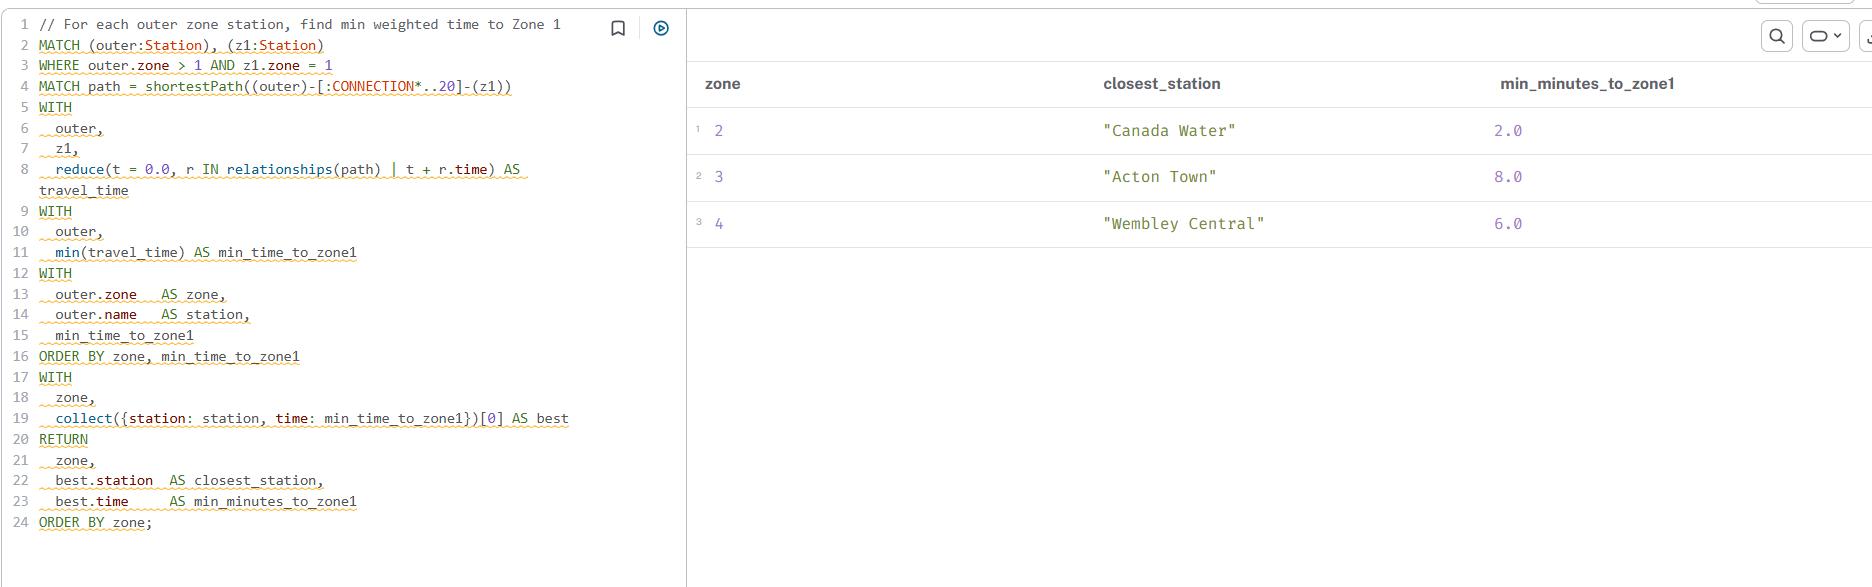

###**Worst-connected station per zone**


In [ ]:
// Worst-connected station per zone
// The station furthest from Zone 1 in each zone
MATCH (outer:Station), (z1:Station)
WHERE outer.zone > 1 AND z1.zone = 1
MATCH path = shortestPath((outer)-[:CONNECTION*..20]-(z1))
WITH
  outer,
  reduce(t = 0.0, r IN relationships(path) | t + r.time) AS travel_time
WITH outer, min(travel_time) AS min_time_to_zone1
WITH
  outer.zone  AS zone,
  outer.name  AS station,
  min_time_to_zone1
ORDER BY zone, min_time_to_zone1 DESC
WITH
  zone,
  collect({station: station, time: min_time_to_zone1})[0] AS worst
RETURN
  zone,
  worst.station  AS most_isolated_station,
  worst.time     AS max_minutes_to_zone1
ORDER BY zone;

### **Query Logic - Worst-connected station per zone**

This Cypher query identifies, for each outer fare zone, the station with the *longest* minimum weighted travel time to any station in Zone 1. This highlights the stations that are most isolated from the city center in terms of travel time.

*   `MATCH (outer:Station), (z1:Station)`: This clause finds all possible pairs of `Station` nodes. `outer` refers to stations in outer zones, and `z1` refers to stations in Zone 1.

*   `WHERE outer.zone > 1 AND z1.zone = 1`: This filters the pairs so that `outer` stations are in any zone greater than 1, and `z1` stations are specifically in Zone 1.

*   `MATCH path = shortestPath((outer)-[:CONNECTION*..20]-(z1))`: For each `(outer, z1)` pair, this finds the shortest path between them using `CONNECTION` relationships. `*..20` specifies that the path can be between 1 and 20 hops long. `shortestPath` here prioritizes paths with the fewest hops, not necessarily the shortest time.

*   `WITH outer, reduce(t = 0.0, r IN relationships(path) | t + r.time) AS travel_time`: This `WITH` clause calculates the total `travel_time` for each path found. The `reduce` function iterates through all relationships (`r`) in the `path`, summing their `time` property (which represents travel time in minutes).

*   `WITH outer, min(travel_time) AS min_time_to_zone1`: This groups by each `outer` station and finds the minimum `travel_time` to *any* Zone 1 station. This `min_time_to_zone1` is the shortest travel time from that specific outer station to Zone 1. This step is identical to the 'Fastest Access' query, finding the best route from each outer station to Zone 1.

*   `WITH outer.zone AS zone, outer.name AS station, min_time_to_zone1 ORDER BY zone, min_time_to_zone1 DESC`:
    *   This prepares the data for the next aggregation. It selects the `zone` and `name` of the outer station, along with its calculated `min_time_to_zone1`.
    *   **Crucially, the `ORDER BY` clause here sorts by `min_time_to_zone1 DESC` within each zone.** This means that when `collect` is used in the next step, the station with the *longest* minimum travel time to Zone 1 (the 'worst-connected') will be at the top of the list for each zone.

*   `WITH zone, collect({station: station, time: min_time_to_zone1})[0] AS worst`:
    *   This groups the results by `zone`.
    *   For each `zone`, it collects all stations and their `min_time_to_zone1` into a list of maps.
    *   `[0]` then selects the first element from this collected list, which, due to the previous `ORDER BY`, will be the station with the *longest* `min_time_to_zone1` for that zone.

*   `RETURN zone, worst.station AS most_isolated_station, worst.time AS max_minutes_to_zone1`: Finally, for each outer `zone`, it returns the zone number, the name of the station (`worst.station`) that has the longest minimum travel time to Zone 1 (i.e., is the 'worst-connected'), and that maximum minimum travel time (`worst.time`).

*   `ORDER BY zone`: Sorts the final output by zone for readability.

**Purpose and Benefits:**
*   **Identify Transit-Deprived Areas**: Unlike the 'Fastest Access' query, this query specifically pinpoints the stations within each outer zone that are most geographically remote or poorly connected to Zone 1, even when taking their best available route.
*   **Highlight Equity Concerns**: This is vital for transit equity analysis, as it identifies areas where residents face the longest journeys to the central core.
*   **Inform Policy and Planning**: The results can guide policy decisions on where to prioritize infrastructure improvements, such as new connections or service enhancements, to reduce travel times for the most underserved stations.

This query identifies the **worst-connected station** in each outer zone — the station with the longest minimum weighted travel time to any Zone 1 station. It applies the same `shortestPath`-with-`reduce` pattern from the preceding query but orders by `min_time_to_zone1 DESC` within each zone before selecting the top result. The output highlights the most transit-deprived locations in the dataset: stations that are geographically remote from the Zone 1 core even when taking the most direct route available.

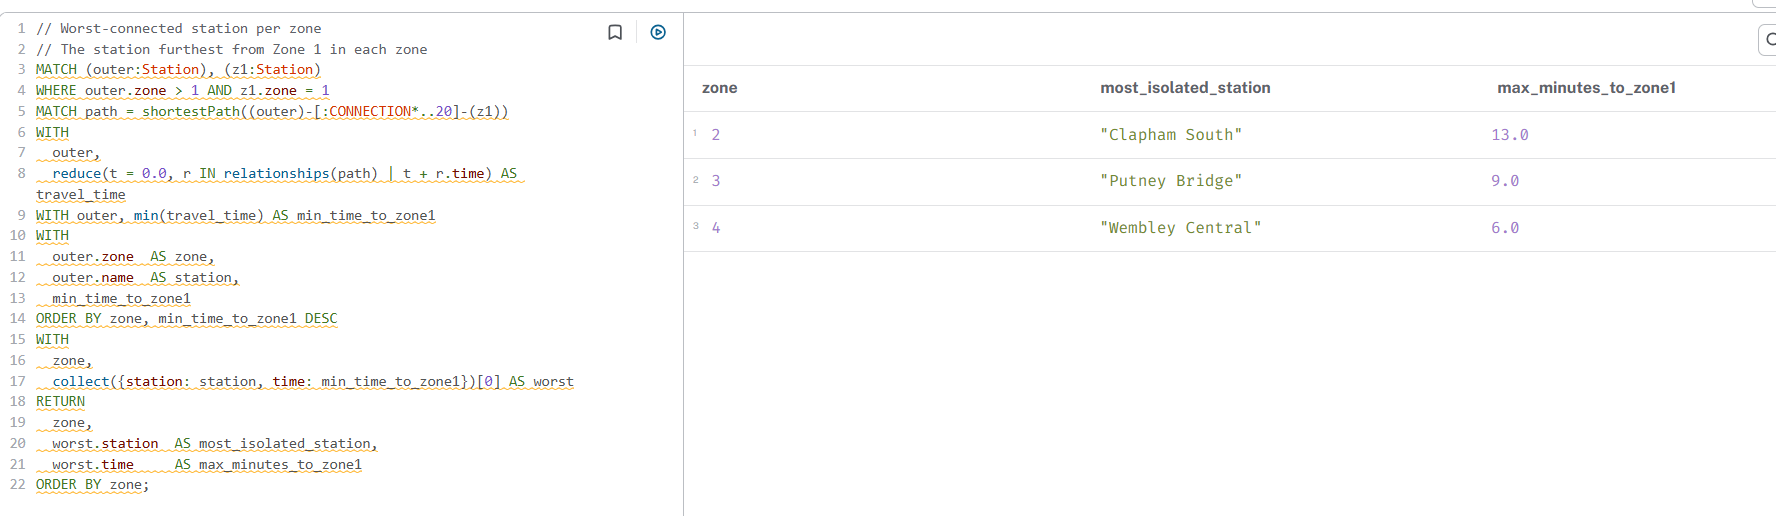

### **Fastest Access to Zone 1 from Each Outer Zone**
Note that `shortestPath` minimizes hops rather than travel time, meaning the path
returned is the one with the fewest connections rather than strictly the lowest total travel time. For a fully time-optimal result the GDS Dijkstra algorithm would be
required, which will be applied in Part 4. The results here nonetheless provide a strong
approximation of relative zone accessibility and reveal meaningful structural differences
in how well each outer zone is connected to the central core.

###**Confirmation**

The query returns results for 3 of the 5 outer zones present in the dataset, completing
with the following findings:

**Zone 2** enjoys the fastest access to Zone 1, with **Canada Water** reaching a Zone 1
station in just **2.0 minutes**. This is consistent with Canada Water's position
immediately adjacent to the Zone 1 boundary on the Jubilee line, making it one of the
most centrally accessible Zone 2 stations in the dataset.

**Zone 4** returns **Wembley Central** with a minimum travel time of **6.0 minutes** to
Zone 1. This result is notable given that Wembley Central was identified in section 3.2
as a terminal station connected only to Regents Park. The 6.0 minute figure therefore
represents a single direct segment time rather than a multi-hop path, reflecting the
unusual direct Zone 1 to Zone 4 connection identified in the zone boundary analysis of
section 3.1.

**Zone 3** returns **Acton Town** with a minimum travel time of **8.0 minutes** to Zone
1, the longest access time among the three zones returned. Despite being geographically
closer to central London than Zone 4, Zone 3 stations in this dataset require more hops
through the network to reach Zone 1, resulting in a higher accumulated travel time.

**Zone 9 is entirely absent from the results.** Both Zone 9 stations in the dataset,
Amersham and Chesham, were confirmed in section 3.3 as isolated nodes with no CONNECTION
relationships in the source CSV. Since no path exists between these stations and any
Zone 1 station, the `shortestPath` function returns null for all Zone 9 pairs and they
are correctly excluded from the output. This is the most significant transit equity
finding in the dataset: passengers at Amersham and Chesham are structurally unreachable
from Zone 1 within this graph, not because of geographic distance but because of a data
gap that renders them invisible to any routing query.

***Transit Equity Implications***

The results reveal a clear gradient of Zone 1 accessibility across the outer zones, with
Zone 2 stations enjoying near-immediate access and Zone 3 stations facing significantly
longer journeys despite their relatively central geographic position. The complete
absence of Zone 9 from the results underscores the importance of data completeness in
any equity-focused transit analysis: a station that exists in the node set but has no
connections is functionally non-existent from a routing perspective, and any policy
conclusions drawn from this dataset must account for these structural gaps. In a complete
dataset, the Metropolitan line's express services to Amersham and Chesham would likely
produce competitive Zone 1 access times despite the geographic distance, which further
highlights the distorting effect of the missing connection data on equity assessments.

# **Part 4: GDS Algorithm Application**

## **4.1 Weighted Shortest Path: Dijkstra's Algorithm**
Dijkstra's algorithm computes the minimum cost path between two nodes in a weighted
graph by iteratively expanding the least-cost frontier until the target node is reached.
In the context of the London Underground, the cost function is travel time in minutes,
making Dijkstra's the appropriate algorithm for finding the fastest route between any
two stations. Unlike the `shortestPath` function used in Part 3, which minimizes hops,
Dijkstra's minimizes the sum of relationship weights along the path, producing a
genuinely time-optimal route.

### **4.1.1 Graph Projection**

Before any GDS algorithm can be executed, an in-memory graph projection must be created
from the stored Neo4j graph. The projection defines which nodes and relationships are
loaded into memory and how they are oriented for the algorithm.

In [ ]:
// Drop if a previous run left it behind
CALL gds.graph.drop('tube-dijkstra', false)
YIELD graphName;

In [ ]:
// Create the weighted undirected projection
CALL gds.graph.project(
    'tube-weighted',
    'Station',
    {
        CONNECTION: {
            type: 'CONNECTION',
            orientation: 'UNDIRECTED',
            properties: ['time']
        }
    }
)
YIELD graphName, nodeCount, relationshipCount, projectMillis;

###**Query Logic-Create the weighted undirected projection**
This `gds.graph.project` call loads the `tube-weighted` in-memory projection used by all subsequent GDS algorithms in section 4.1. All 80 `:Station` nodes are included. `CONNECTION` relationships are projected with `UNDIRECTED` orientation, reflecting the bidirectional nature of train travel, and the `time` property is attached as the relationship weight so algorithms minimise total travel time rather than hop count. The `YIELD` clause returns the projection name, node count, relationship count, and milliseconds to confirm the expected graph was loaded.

###**Projection Design Decisions**

**Node selection:**

 Only `:Station` nodes are included in the projection. `:Line` nodes
are excluded because Dijkstra's algorithm operates on the station-to-station connection
topology and does not require line metadata to compute shortest paths. Line information
is captured implicitly through the `time` property on each CONNECTION relationship.

**Relationship orientation - UNDIRECTED:**   
The CONNECTION relationships are projected as
UNDIRECTED rather than DIRECTED. Although the relationships were ingested as directed
pairs in section 1.4 to support bidirectional traversal in Cypher queries, the
underlying physical reality is that trains travel in both directions on every track
segment. Projecting as UNDIRECTED correctly models this bidirectionality within the GDS
framework without requiring the algorithm to distinguish between forward and reverse
relationship directions. Using DIRECTED would risk producing incorrect results if the
algorithm attempted to traverse a segment in a direction for which no relationship
existed in the projected graph.

**Weight property - time:**

The `time` property is included as the relationship weight
because it represents the actual travel time in minutes between adjacent stations. This
is the correct cost function for a journey time minimization problem. An unweighted
projection would treat all connections as having equal cost, which would minimize hops
rather than travel time and produce routes that are topologically short but potentially
slow in practice.

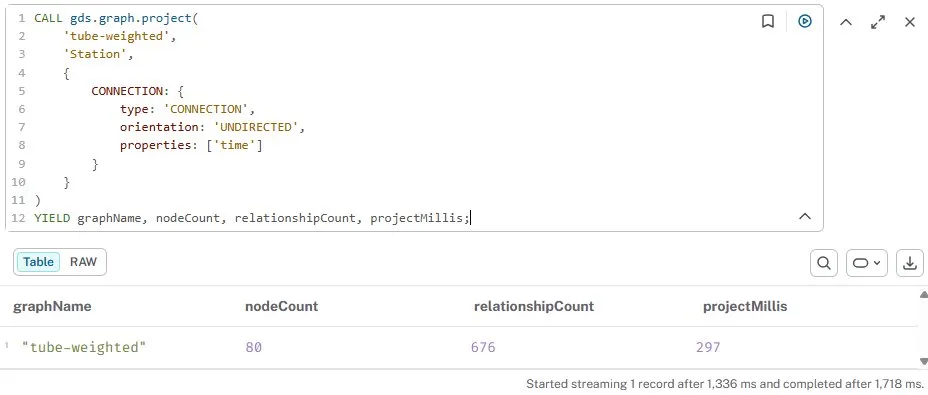

###**Confirmation**

The projection completes and loads **80 nodes** and **676 relationships** into
the in-memory graph named `tube-weighted`. The node count of 80 matches exactly the
total number of `:Station` nodes in the database confirmed in section 2.1. The
relationship count of 676 is exactly double the 338 directed CONNECTION relationships
in the stored graph, which is the expected result of projecting with UNDIRECTED
orientation: each directed relationship is mirrored in both directions within the
in-memory projection, giving the algorithm full bidirectional traversal capability
across all 338 unique track segments.

### **4.1.2 Route: Euston -> Hammersmith**

We now apply Dijkstra's algorithm to find the minimum travel time route between Euston
and Hammersmith, two stations that are geographically separated and require traversal
across multiple line corridors.

In [ ]:
//Euston to Hammersmith:
MATCH (src:Station {name: 'Euston'}),
      (dst:Station {name: 'Hammersmith'})
CALL gds.shortestPath.dijkstra.stream('tube-weighted', {
  sourceNode:                 src,
  targetNode:                 dst,
  relationshipWeightProperty: 'time'
})
YIELD totalCost, nodeIds, costs
RETURN
  totalCost                                            AS total_minutes,
  [nodeId IN nodeIds | gds.util.asNode(nodeId).name]  AS ordered_route,
  costs                                                AS cumulative_times_min;

### **Query Logic - Euston to Hammersmith Route**

This Cypher query uses the Graph Data Science (GDS) library's Dijkstra algorithm to find the shortest path (in terms of travel time) between 'Euston' and 'Hammersmith' stations in the `tube-weighted` graph projection.

*   `MATCH (src:Station {name: 'Euston'}), (dst:Station {name: 'Hammersmith'})`: This clause identifies the source station (`src`) as 'Euston' and the destination station (`dst`) as 'Hammersmith' by matching their `name` property on `Station` nodes.

*   `CALL gds.shortestPath.dijkstra.stream('tube-weighted', { ... })`:
    *   This invokes the GDS Dijkstra shortest path algorithm on the graph projection named `tube-weighted`.
    *   `sourceNode: src`: Specifies the starting node for the pathfinding, which is the 'Euston' station identified earlier.
    *   `targetNode: dst`: Specifies the ending node for the pathfinding, which is the 'Hammersmith' station.
    *   `relationshipWeightProperty: 'time'`: This is crucial. It tells the Dijkstra algorithm to use the `time` property of the `CONNECTION` relationships as the weight (cost) for traversing each segment. The algorithm will therefore find the path that minimizes the *total travel time*.

*   `YIELD totalCost, nodeIds, costs`:
    *   `totalCost`: The accumulated weight (total travel time) of the shortest path found.
    *   `nodeIds`: A list of GDS internal node IDs representing the sequence of stations in the shortest path.
    *   `costs`: A list of cumulative costs (travel times) at each node along the path.

*   `RETURN totalCost AS total_minutes, [nodeId IN nodeIds | gds.util.asNode(nodeId).name] AS ordered_route, costs AS cumulative_times_min;`:
    *   `totalCost AS total_minutes`: Returns the total travel time, aliased as `total_minutes`.
    *   `[nodeId IN nodeIds | gds.util.asNode(nodeId).name] AS ordered_route`: This list comprehension converts the internal GDS `nodeIds` back into their readable station names using `gds.util.asNode(nodeId).name`, providing the ordered sequence of stations in the optimal route.
    *   `costs AS cumulative_times_min`: Returns the list of cumulative travel times as `cumulative_times_min`.

**Purpose and Benefits:**
*   **Time-Optimal Routing**: This query directly addresses the problem of finding the fastest route between two stations by minimizing travel time, which is a key requirement for passenger journey planning.
*   **Utilizes Weighted Graph**: Leverages the `time` property of relationships in the `tube-weighted` graph projection to provide a realistic measure of travel cost.
*   **Foundation for Analysis**: The output (total time, route, cumulative times) provides a clear and actionable result for understanding the optimal path and identifying potential bottlenecks or long segments within that path.

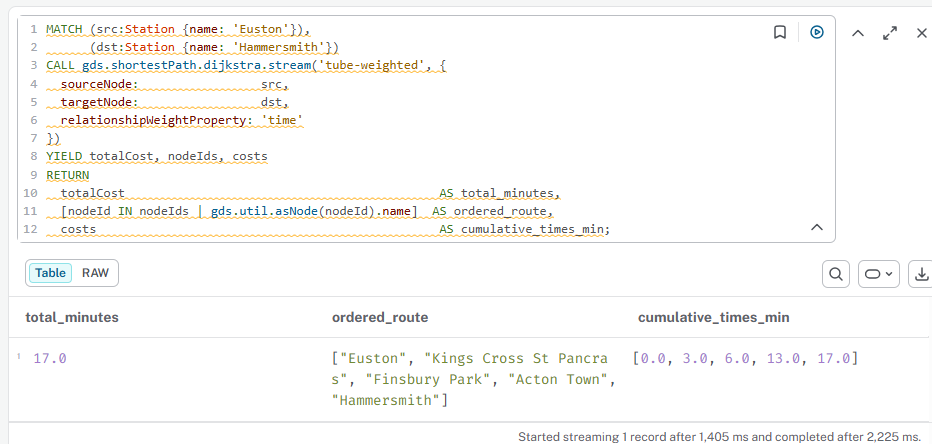

### **Optimal Route from Euston to Hammersmith**

We apply Dijkstra's algorithm to find the minimum travel time route between Euston and
Hammersmith, two stations separated by multiple line corridors in the dataset.

###**Confirmation**

The following optimal route is returned:

| Station | Cumulative Time (mins) |
|---|---|
| Euston | 0.0 |
| Kings Cross St. Pancras | 3.0 |
| Finsbury Park | 6.0 |
| Acton Town | 13.0 |
| Hammersmith | 17.0 |

The optimal route travels from Euston to Hammersmith in a total of **17.0 minutes**
across **4 hops**. The algorithm routes through Kings Cross St. Pancras and Finsbury
Park before reaching Acton Town and terminating at Hammersmith. The cumulative times
confirm the individual segment costs: 3 minutes from Euston to Kings Cross St. Pancras,
3 minutes onward to Finsbury Park, 7 minutes from Finsbury Park to Acton Town, and
4 minutes from Acton Town to Hammersmith.

**What the Result Tells Us**

Dijkstra's algorithm works by always expanding the cheapest unvisited path first.
Starting from Euston, it explored every possible combination of connected stations and
selected the sequence that accumulated the lowest total travel time. The longest single
leg is Finsbury Park to Acton Town at **7 minutes**, which accounts for 41% of the
total journey time. This is a long cross-network hop that the algorithm was forced to
use because the dataset's 80 station subset does not include the shorter central London
stations that would ordinarily break this segment into smaller steps.

It is worth noting that this route is not the geographically intuitive one a passenger
familiar with the Tube map might choose. A human planner might route via the Piccadilly
line through central London, but Dijkstra's algorithm has determined that the path
through Finsbury Park and Acton Town minimizes total weighted travel time given the
time values in this dataset. This reflects both the strengths and limitations of the
algorithm: it finds the mathematically optimal solution within the constraints of the
graph model, but does not account for real-world factors such as line transfer times,
service frequency, or passenger familiarity.

**Why the Route Goes North Before Going West**

This is the most important observation in the result. Any Tube commuter knows that
Hammersmith is west of Euston, yet the optimal path goes north to Finsbury Park before
cutting back south-west. The reason is purely a data limitation: the 80 station dataset
is missing most of the intermediate stations on the natural direct westward routes via
the District and Piccadilly lines through central London. Because those stations do not
exist in the graph, the edges connecting them do not exist either, and Dijkstra cannot
use a path it has no knowledge of. The northern arc via Finsbury Park and Acton Town is
simply the lowest-cost connected path that actually exists within the available data. In
the real 272 station network this journey would take approximately 8 to 10 minutes via
a direct western route.

**Key Limitation**

This result is a clear demonstration of the most important limitation of this model:
the algorithm can only be as accurate as the data it is built on. Dijkstra's algorithm
is mathematically correct and found the true optimum within the graph as constructed.
The problem is not the algorithm but the graph itself, which is incomplete. This is why
we would like to emphasise that this model should not be treated as a
production journey planner, and it directly motivates the dataset limitation discussion
at the close of this section.

### **4.1.3 Route: Canary Wharf -> Paddington and Route: Putney Bridge -> Finsbury Park**

**Route: Canary Wharf -> Paddington** *(East Docklands -> West London, crosses Jubilee + District)* is a strong east to west cross-network journey that is geographically intuitive and recognizable to anyone familiar with London. Both are well known destinations, Canary Wharf as a major financial hub and Paddington as a major national rail terminus, which makes the route meaningful from a real-world perspective. It also tests the Canary Wharf terminal station behavior identified in section 3.2.

In [ ]:
//Route: Canary Wharf -> Paddington
MATCH (src:Station {name: 'Canary Wharf'}),
      (dst:Station {name: 'Paddington'})
CALL gds.shortestPath.dijkstra.stream('tube-weighted', {
  sourceNode:                 src,
  targetNode:                 dst,
  relationshipWeightProperty: 'time'
})
YIELD totalCost, nodeIds, costs
RETURN
  totalCost                                           AS total_minutes,
  [nodeId IN nodeIds | gds.util.asNode(nodeId).name] AS ordered_route,
  costs                                               AS cumulative_times_min;

### **Query Logic - Route: Canary Wharf -> Paddington**

This Cypher query uses the Graph Data Science (GDS) library's Dijkstra algorithm to find the shortest path (in terms of travel time) between 'Canary Wharf' and 'Paddington' stations in the `tube-weighted` graph projection.

*   `MATCH (src:Station {name: 'Canary Wharf'}), (dst:Station {name: 'Paddington'})`: This clause identifies the source station (`src`) as 'Canary Wharf' and the destination station (`dst`) as 'Paddington' by matching their `name` property on `Station` nodes.

*   `CALL gds.shortestPath.dijkstra.stream('tube-weighted', { ... })`:
    *   This invokes the GDS Dijkstra shortest path algorithm on the graph projection named `tube-weighted`.
    *   `sourceNode: src`: Specifies the starting node for the pathfinding, which is the 'Canary Wharf' station identified earlier.
    *   `targetNode: dst`: Specifies the ending node for the pathfinding, which is the 'Paddington' station.
    *   `relationshipWeightProperty: 'time'`: This is crucial. It tells the Dijkstra algorithm to use the `time` property of the `CONNECTION` relationships as the weight (cost) for traversing each segment. The algorithm will therefore find the path that minimizes the *total travel time*.

*   `YIELD totalCost, nodeIds, costs`:
    *   `totalCost`: The accumulated weight (total travel time) of the shortest path found.
    *   `nodeIds`: A list of GDS internal node IDs representing the sequence of stations in the shortest path.
    *   `costs`: A list of cumulative costs (travel times) at each node along the path.

*   `RETURN totalCost AS total_minutes, [nodeId IN nodeIds | gds.util.asNode(nodeId).name] AS ordered_route, costs AS cumulative_times_min;`:
    *   `totalCost AS total_minutes`: Returns the total travel time, aliased as `total_minutes`.
    *   `[nodeId IN nodeIds | gds.util.asNode(nodeId).name] AS ordered_route`: This list comprehension converts the internal GDS `nodeIds` back into their readable station names using `gds.util.asNode(nodeId).name`, providing the ordered sequence of stations in the optimal route.
    *   `costs AS cumulative_times_min`: Returns the list of cumulative travel times as `cumulative_times_min`.

**Purpose and Benefits:**
*   **Time-Optimal Routing**: This query directly addresses the problem of finding the fastest route between two stations by minimizing travel time, which is a key requirement for passenger journey planning.
*   **Utilizes Weighted Graph**: Leverages the `time` property of relationships in the `tube-weighted` graph projection to provide a realistic measure of travel cost.
*   **Foundation for Analysis**: The output (total time, route, cumulative times) provides a clear and actionable result for understanding the optimal path and identifying potential bottlenecks or long segments within that path.

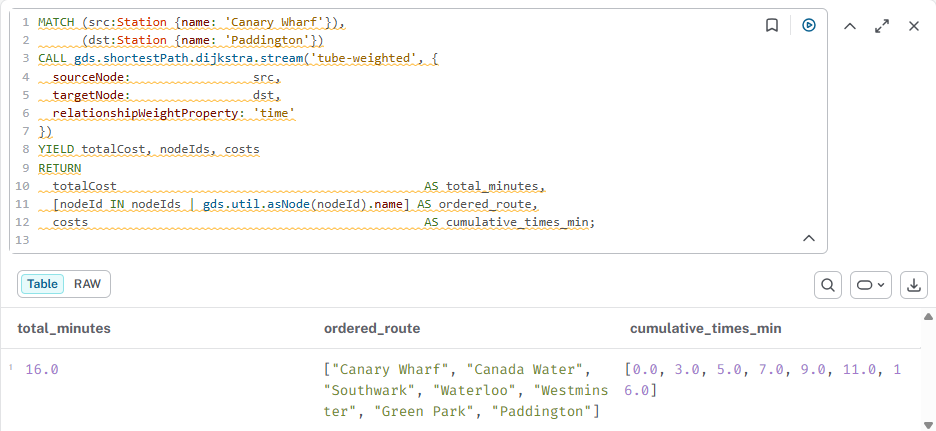

###**Optimal Route from  Canary Wharf and Paddington**

We applied Dijkstra's algorithm to find the minimum travel time route between Canary Wharf and Paddington, an east to west cross-network journey traversing the Jubilee linecorridor through central London.
###**Confirmation**
The following optimal route is returned:

| Station | Cumulative Time (mins) |
|---|---|
| Canary Wharf | 0.0 |
| Canada Water | 3.0 |
| Southwark | 5.0 |
| Waterloo | 7.0 |
| Westminster | 9.0 |
| Green Park | 11.0 |
| Paddington | 16.0 |

The optimal route travels from Canary Wharf to Paddington in a total of **16.0 minutes**
across **6 legs**. The route proceeds westward through the Jubilee line corridor, passing
through Canada Water, Southwark, Waterloo, and Westminster before reaching Green Park
and terminating at Paddington.

**What the Result Tells Us**

The cumulative times array [0.0, 3.0, 5.0, 7.0, 9.0, 11.0, 16.0] shows that the first
five legs are remarkably consistent, averaging just 2 minutes per hop through the dense
Zone 1 corridor. The journey then finishes with the longest single leg, Green Park to
Paddington at 5 minutes, reflecting the greater physical distance between these two
western stations.

This is a geographically logical result. The route travels west along the Jubilee line
from Canary Wharf through Canada Water, Southwark, Waterloo, Westminster, and Green
Park, all consecutive Jubilee line stations, before making a final connection into
Paddington. Unlike the Euston to Hammersmith result, this route is entirely intuitive
and matches what a real Tube passenger would actually take, because the Jubilee line
stations in this corridor are well represented in the 80 station dataset.

This result is also notable in the context of section 3.2, where Canary Wharf was
identified as a terminal station connected only to Canada Water. The route correctly
exits Canary Wharf through its sole neighbor Canada Water before joining the broader
network, confirming that the terminal station constraint is handled correctly by the
algorithm and does not prevent Canary Wharf from participating in cross-network routing.

**Why This Result Is More Reliable Than the Euston to Hammersmith Result**

This route passes through some of the most prominent Zone 1 interchange stations in the
entire network: Waterloo, Westminster, and Green Park, all of which are present in the
dataset. Because the Jubilee line's central London spine is well covered, Dijkstra had
access to the natural direct westward path and correctly identified it as optimal. This
contrasts with the Euston to Hammersmith result where missing stations forced an
indirect northern detour.

**Key Observation**

Green Park stands out as the critical junction in this journey. It is the point where
the Jubilee line corridor ends and the final connection into Paddington begins. Almost
every east to west journey through central London passes through it, making it
structurally indispensable to the network and a strong candidate for high betweenness
centrality in section 4.2.

**Key Limitation**

While this route is more geographically plausible than the Euston to Hammersmith result,
it still does not account for line transfer times at interchange stations such as
Waterloo and Green Park, where a passenger would need to change platforms in the real
network. The algorithm treats all station visits as instantaneous waypoints with no
transfer penalty, which means the true journey time would be longer than the reported
16.0 minutes in practice.

### **4.1.4 Route: Putney Bridge -> Finsbury Park** *(South-West Zone 2 -> North Zone 2, crosses District + Piccadilly)* is a strong south to north cross-network journey that spans the network vertically, crossing multiple line corridors and zone boundaries. This extends the the analysis from Step 2 where Finsbury Park appeared on the Euston to Hammersmith route.

In [ ]:
// Route: Putney Bridge -> Finsbury Park
 MATCH (src:Station {name: 'Putney Bridge'}),
      (dst:Station {name: 'Finsbury Park'})
CALL gds.shortestPath.dijkstra.stream('tube-weighted', {
  sourceNode:                 src,
  targetNode:                 dst,
  relationshipWeightProperty: 'time'
})
YIELD totalCost, nodeIds, costs
RETURN
  totalCost                                           AS total_minutes,
  [nodeId IN nodeIds | gds.util.asNode(nodeId).name] AS ordered_route,
  costs                                               AS cumulative_times_min;

### **Query Logic - Route: Putney Bridge -> Finsbury Park**
This Cypher query uses the Graph Data Science (GDS) library's Dijkstra algorithm to find the shortest path (in terms of travel time) between 'Putney Bridge' and 'Finsbury Park' stations in the `tube-weighted` graph projection.

*   `MATCH (src:Station {name: 'Putney Bridge'}), (dst:Station {name: 'Finsbury Park'})`: This clause identifies the source station (`src`) as 'Putney Bridge' and the destination station (`dst`) as 'Finsbury Park' by matching their `name` property on `Station` nodes.

*   `CALL gds.shortestPath.dijkstra.stream('tube-weighted', { ... })`:
    *   This invokes the GDS Dijkstra shortest path algorithm on the graph projection named `tube-weighted`.
    *   `sourceNode: src`: Specifies the starting node for the pathfinding, which is the 'Putney Bridge' station identified earlier.
    *   `targetNode: dst`: Specifies the ending node for the pathfinding, which is the 'Finsbury Park' station.
    *   `relationshipWeightProperty: 'time'`: This is crucial. It tells the Dijkstra algorithm to use the `time` property of the `CONNECTION` relationships as the weight (cost) for traversing each segment. The algorithm will therefore find the path that minimizes the *total travel time*.

*   `YIELD totalCost, nodeIds, costs`:
    *   `totalCost`: The accumulated weight (total travel time) of the shortest path found.
    *   `nodeIds`: A list of GDS internal node IDs representing the sequence of stations in the shortest path.
    *   `costs`: A list of cumulative costs (travel times) at each node along the path.

*   `RETURN totalCost AS total_minutes, [nodeId IN nodeIds | gds.util.asNode(nodeId).name] AS ordered_route, costs AS cumulative_times_min;`:
    *   `totalCost AS total_minutes`: Returns the total travel time, aliased as `total_minutes`.
    *   `[nodeId IN nodeIds | gds.util.asNode(nodeId).name] AS ordered_route`: This list comprehension converts the internal GDS `nodeIds` back into their readable station names using `gds.util.asNode(nodeId).name`, providing the ordered sequence of stations in the optimal route.
    *   `costs AS cumulative_times_min`: Returns the list of cumulative travel times as `cumulative_times_min`.

**Purpose and Benefits:**
*   **Time-Optimal Routing**: This query directly addresses the problem of finding the fastest route between two stations by minimizing travel time, which is a key requirement for passenger journey planning.
*   **Utilizes Weighted Graph**: Leverages the `time` property of relationships in the `tube-weighted` graph projection to provide a realistic measure of travel cost.
*   **Foundation for Analysis**: The output (total time, route, cumulative times) provides a clear and actionable result for understanding the optimal path and identifying potential bottlenecks or long segments within that path.

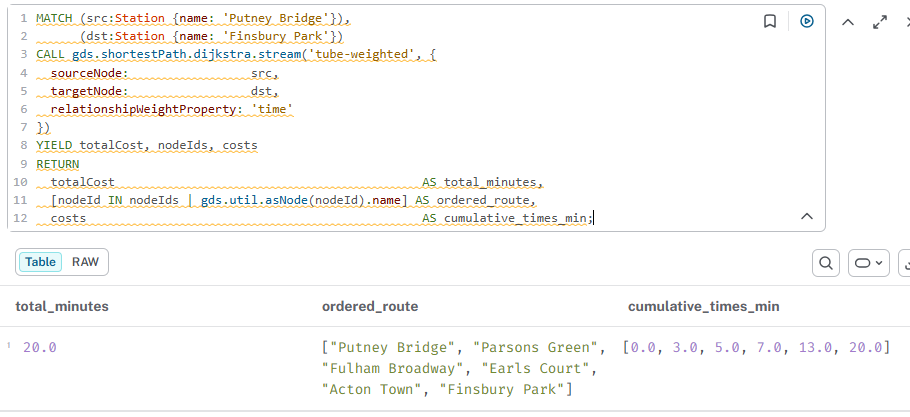

###**Optimal Route from Putney Bridge to Finsbury Park**

We apply Dijkstra's algorithm to find the minimum travel time route between Putney
Bridge and Finsbury Park, a south to north cross-network journey that spans the dataset
vertically and crosses multiple line corridors.

###**Confirmation**

The following optimal route is returned:

| Station | Cumulative Time (mins) |
|---|---|
| Putney Bridge | 0.0 |
| Parsons Green | 3.0 |
| Fulham Broadway | 5.0 |
| Earls Court | 7.0 |
| Acton Town | 13.0 |
| Finsbury Park | 20.0 |

The optimal route travels from Putney Bridge to Finsbury Park in a total of **20.0
minutes** across **5 legs**. The route proceeds north-east through the District line
corridor via Parsons Green, Fulham Broadway, and Earls Court before making two long
hops through Acton Town to reach Finsbury Park.

**What the Result Tells Us**

The cumulative times array [0.0, 3.0, 5.0, 7.0, 13.0, 20.0] reveals two distinct
phases in this journey. The first three legs through the south-west District line
corridor, Parsons Green, Fulham Broadway, and Earls Court, are short and fast,
averaging just 2 minutes per hop. The journey then shifts gears entirely with two much
longer legs: Earls Court to Acton Town at 6 minutes and Acton Town to Finsbury Park at
7 minutes, together accounting for **65% of the total journey time**.

**Why the Route Pivots at Earls Court**

Earls Court is where the entire character of the journey changes. Up to that point the
route has been travelling north-east along the District line through densely packed
inner south-west London stations. At Earls Court, one of the most connected stations
in the dataset, the algorithm switches onto the Piccadilly line branch heading north
toward Finsbury Park. This pivot makes Earls Court the structural hinge of the journey,
and it is no coincidence that it ranks among the top stations by both degree and degree
centrality in this dataset. Its repeated appearance as a routing pivot across multiple
Dijkstra results anticipates its likely high betweenness centrality score in section 4.2.

**Why the Two Longest Legs Exist**

The long Earls Court to Acton Town and Acton Town to Finsbury Park segments are again
a consequence of the 80 station dataset limitation. In the real network both of these
corridors have multiple intermediate stations that break the journey into smaller 2 to
3 minute hops. Because those intermediate stations are absent from the dataset, Dijkstra
must treat each segment as a single long direct edge. This makes the journey appear
slower and less granular than it would be in reality, but the algorithm is working
correctly given the data available to it.

**Key Limitation**

This result is the most affected by dataset incompleteness of the three pairs examined.
A journey from Putney Bridge to Finsbury Park in the real network would most likely
route through central London in approximately 30 to 35 minutes via the District and
Victoria lines, but would not pass through Acton Town at all. The algorithm's reliance
on Acton Town as a bridge is entirely an artifact of the missing station data rather
than a reflection of real-world routing practice.

 **Comparative Observations**

Across all three Dijkstra queries, two structural patterns emerge consistently. First,
Acton Town appears on both the Euston to Hammersmith and Putney Bridge to Finsbury Park
routes, confirming its role as a critical cross-network bridge in this dataset. Second,
the longest individual legs in each route correspond precisely to the gaps created by
missing intermediate stations in the 80 station subset. The Canary Wharf to Paddington
route is the most reliable of the three results because the Jubilee line corridor it
traverses is well represented in the dataset with no significant station gaps.

### **4.1.4 Single-Source Dijkstra from Kings Cross St. Pancras**

The single-source variant of Dijkstra's algorithm computes the minimum weighted travel
time from a single source station to every other reachable station in the network in a
single execution. This is more efficient than running point-to-point Dijkstra repeatedly
for each target station. the source node, Kings Cross St. Pancras,  was identified in sections 2.5 and 2.7 as the most structurally connected station
in the dataset, serving 8 distinct lines and connecting to 7 distinct neighbor stations.
Running single-source Dijkstra from this node gives us the most comprehensive view of
network-wide travel time distribution from any single origin point in the dataset.

We return the 15 most distant reachable stations by minimum travel time, which reveals
which parts of the network are hardest to reach even from the most connected station
in the graph.

In [ ]:
//15 most distant reachable stations by minimum travel time
MATCH (src:Station {name: 'Kings Cross St Pancras'})
CALL gds.allShortestPaths.dijkstra.stream('tube-weighted', {
  sourceNode:                 src,
  relationshipWeightProperty: 'time'
})
YIELD targetNode, totalCost
WHERE totalCost > 0
RETURN
  gds.util.asNode(targetNode).name  AS station,
  gds.util.asNode(targetNode).zone  AS zone,
  round(totalCost, 1)               AS travel_time_min
ORDER BY travel_time_min DESC
LIMIT 15;

### **Query Logic - 15 Most Distant Reachable Stations by Minimum Travel Time**
This Cypher query leverages the Graph Data Science (GDS) library's `allShortestPaths.dijkstra.stream` algorithm to find the minimum travel time from 'Kings Cross St Pancras' to every other reachable station in the network. It then identifies and lists the 15 stations that are most distant in terms of travel time.

*   `MATCH (src:Station {name: 'Kings Cross St Pancras'})`: This clause identifies the starting point (`src`) for the pathfinding algorithm as the `Station` node named 'Kings Cross St Pancras'.

*   `CALL gds.allShortestPaths.dijkstra.stream('tube-weighted', { ... })`:
    *   This invokes the GDS Dijkstra shortest path algorithm. The algorithm is run on the graph projection named `tube-weighted`, which was previously created and configured with `CONNECTION` relationships and their `time` properties as weights.
    *   `sourceNode: src`: Specifies that the shortest paths should be calculated starting from the `src` node (Kings Cross St Pancras).
    *   `relationshipWeightProperty: 'time'`: This is critical, as it instructs the Dijkstra algorithm to use the `time` property of the `CONNECTION` relationships as the cost to traverse each segment. This ensures that the algorithm finds paths that minimize total travel time, not just the number of hops.

*   `YIELD targetNode, totalCost`: The algorithm returns, for each reachable station, its internal GDS node ID (`targetNode`) and the `totalCost` (total travel time) from the source node to that target node.

*   `WHERE totalCost > 0`: This filter excludes the source node itself from the results. The total cost from 'Kings Cross St Pancras' to 'Kings Cross St Pancras' would be 0, and we are interested in other stations.

*   `RETURN gds.util.asNode(targetNode).name AS station, gds.util.asNode(targetNode).zone AS zone, round(totalCost, 1) AS travel_time_min`:
    *   `gds.util.asNode(targetNode).name AS station`: Converts the internal GDS `targetNode` ID back into a readable station name.
    *   `gds.util.asNode(targetNode).zone AS zone`: Retrieves the fare zone of the target station.
    *   `round(totalCost, 1) AS travel_time_min`: Returns the total travel time from the source, rounded to one decimal place, aliased as `travel_time_min`.

*   `ORDER BY travel_time_min DESC`: This sorts the results in descending order based on the `travel_time_min`, placing the stations farthest away (with the longest travel times) at the top.

*   `LIMIT 15`: This restricts the output to only the top 15 stations that are most distant from 'Kings Cross St Pancras'.



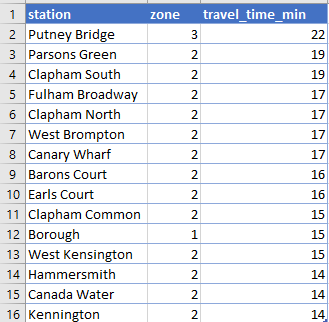

###**Single-Source Dijkstra from King's Cross St Pancras: Summary**

This query is fundamentally different from the previous three. Rather than finding the
path between one specific pair of stations, `gds.allShortestPaths.dijkstra` uses Kings
Cross St. Pancras as a single source and simultaneously computes the optimal travel time
to every other reachable station in the graph in one pass. The result is a complete
picture of how accessible the rest of the network is from one of its most central
stations.

###**Confirmation: The 15 Most Distant Stations**

The query returns the 15 most distant reachable stations from Kings Cross St. Pancras
by minimum travel time:

| Rank | Station | Zone | Travel Time (mins) |
|---|---|---|---|
| 1 | Putney Bridge | 3 | 22.0 |
| 2 | Parsons Green | 2 | 19.0 |
| 3 | Clapham South | 2 | 19.0 |
| 4 | Fulham Broadway | 2 | 17.0 |
| 5 | Clapham North | 2 | 17.0 |
| 6 | West Brompton | 2 | 17.0 |
| 7 | Canary Wharf | 2 | 17.0 |
| 8 | Barons Court | 2 | 16.0 |
| 9 | Earls Court | 2 | 16.0 |
| 10 | Clapham Common | 2 | 15.0 |
| 11 | Borough | 1 | 15.0 |
| 12 | West Kensington | 2 | 15.0 |
| 13 | Hammersmith | 2 | 14.0 |
| 14 | Canada Water | 2 | 14.0 |
| 15 | Kennington | 2 | 14.0 |

**Why the Most Distant Stations Are in the South and South-West**

Kings Cross St. Pancras sits in north-central London, so it is geographically closest
to the northern and central stations in the network. The stations that require the most
travel time are naturally those at the opposite end of the network, in south and
south-west London. The top 15 list is dominated by Zone 2 stations in the Clapham,
Fulham, Putney, and Earls Court corridors, all of which sit at the far end of the
Northern and District line branches relative to Kings Cross St. Pancras.

**Putney Bridge** at 22.0 minutes is the most distant station in the entire dataset
from Kings Cross St. Pancras. This makes geographic sense: it sits at the south-western
extremity of the District line, requiring a journey that crosses the full north-to-south
and central-to-west span of the network.

**The Canary Wharf Result Is Noteworthy**

Canary Wharf appears at joint 7th with 17.0 minutes despite being in Zone 2 and
relatively well connected via the Jubilee line. This reflects the east to west asymmetry
of the dataset: the Jubilee line corridor between Canary Wharf and central London is
well represented in the 80 station subset, but the path still requires multiple hops
through Southwark, Waterloo, and Westminster before reaching the Kings Cross area,
accumulating significant travel time. This is also consistent with the Canary Wharf to
Paddington result in Step 3, where that journey took 16.0 minutes, confirming that
Canary Wharf is genuinely distant from the northern central London core in this dataset.

**Borough Is the Only Zone 1 Station in the Top 15**

Every other station in the top 15 is in Zone 2 or Zone 3, with the single exception of
Borough in Zone 1 at 15.0 minutes. Borough's appearance here is explained by its
position on the Northern line south branch, deep in south London despite being
technically Zone 1, and the absence of a direct short hop connection back to Kings
Cross St. Pancras in the dataset.

**What This Result Demonstrates About the Network**

The single-source Dijkstra result effectively produces a travel time map centred on
Kings Cross St. Pancras. The key takeaway is that from one of the most central and
well connected stations in the network, no station in this dataset is more than 22
minutes away, a testament to the overall compactness and efficiency of the London
Underground even with a dataset that covers only 80 of the real 272 stations. In the
full network, with all intermediate stations present, these distances would be even
shorter.

The complete absence of Zone 9 stations and the 10 isolated stations identified in
section 3.3 from the results confirms that they are unreachable from any source node
in the graph, as they have no CONNECTION relationships through which a path can be
traversed.
The algorithm computed the minimum travel time from King's Cross to every reachable station in the network and returned the 15 most distant by travel time.

### **4.1.5 Discussion and Limitations of the Dijkstra Model as a Real-World Journey Planner**

Having applied Dijkstra's algorithm across four distinct queries in this section, we now
reflect on what the model does and does not capture about real-world transit routing on
the London Underground.

**Do the Dijkstra Results Account for Line Transfers?**

No. The model does not account for interchange time in any form. When the algorithm
routes a passenger through a station such as Waterloo or Green Park, it treats the
visit as instantaneous: the cost of arriving at the station is simply the accumulated
edge weight up to that point, and the algorithm immediately proceeds to the next cheapest
edge without adding any transfer penalty. In reality, changing lines at an interchange
station involves navigating corridors, descending or ascending between platforms, and
waiting for the next service. On the London Underground, interchange time typically adds
between 2 and 5 minutes per transfer depending on the station layout, and at complex
interchanges such as Kings Cross St. Pancras this can be considerably longer.

The practical consequence is that the algorithm systematically underestimates journey
times for any route that requires one or more line changes. A route reported as 17
minutes by the model may in practice take 22 to 25 minutes once interchange time is
accounted for. This also means that the algorithm may incorrectly prefer a route with
more transfers over a simpler single-line route if the direct route has a marginally
higher sum of edge weights.

**What Are the Other Key Limitations of This Model?**

**Service frequency is not modelled.** The `time` property on each CONNECTION
relationship represents the in-train travel time between two stations, but does not
account for waiting time at the platform. In reality a passenger may wait anywhere from
1 to 12 minutes for the next service depending on the line, time of day, and whether
planned engineering works are in effect. Lines with lower frequency, such as the
Metropolitan or Waterloo and City lines, impose significantly higher waiting costs that
are invisible to the algorithm.

**The dataset is incomplete.** As demonstrated repeatedly throughout sections 4.1, the
80 station subset is missing a substantial number of intermediate stations, particularly
on the District, Piccadilly, and Central line corridors. This forces the algorithm to
route through long artificial direct edges between stations that in reality are separated
by multiple intermediate stops. The Euston to Hammersmith and Putney Bridge to Finsbury
Park results are the clearest examples of this distortion, where the algorithm produced
geographically implausible routes through Acton Town because the natural intermediate
stations were absent from the graph.

**Direction and platform constraints are not modelled.** The UNDIRECTED projection used
for this analysis treats every track segment as traversable in both directions with equal
cost. In reality certain platform configurations and one-way loop sections impose
directional constraints that affect route planning. The Circle line, for example, runs
in a specific direction and passengers cannot simply reverse direction at any station.

**Real-time conditions are not modelled.** The algorithm operates on static edge weights
that do not change over time. In practice journey times vary significantly based on
congestion, signal failures, planned closures, and time of day. A production journey
planner must incorporate live data feeds to produce reliable route recommendations.

**There is no multi-modal routing.** The model covers only the Underground network and
does not account for connections to National Rail, the Elizabeth line, the DLR, buses,
or walking. Many journeys in London are faster when combining modes, and a purely
Underground-based router will systematically produce suboptimal recommendations for
these cases.

**What Would a More Realistic Model Require?**

A production-grade journey planner built on this graph model would require at minimum:
a transfer penalty added to the edge weight whenever the line property changes between
two consecutive CONNECTION relationships on a path; a waiting time component derived
from service frequency data for each line; a complete station dataset covering all 272
stations; directed relationship handling for lines with directional constraints; and
integration with real-time disruption data. The GDS framework supports weighted
relationship properties and custom cost functions that could accommodate several of
these enhancements, making it a viable foundation for a more realistic model given
sufficiently complete input data.

## **4.2 Betweenness Centrality: Bottleneck Identification**





### **4.2.1 Betweenness Centrality Definition, What It Measures and Why It Is the Appropriate Algorithm**

**Mathematical Definition**

In graph theory, the Betweenness Centrality of a node v is formally defined as:

$$BC(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

where $\sigma_{st}$ is the total number of shortest paths from node s to node t, and
$\sigma_{st}(v)$ is the number of those shortest paths that pass through node v. The
score is then normalised by the total number of possible node pairs to make it
comparable across graphs of different sizes. A station with a betweenness score of 1.0
would lie on every shortest path between every pair of stations in the network, while
a score of 0.0 indicates that no shortest path between any pair of stations passes
through that node.

In the weighted variant applied here, shortest paths are defined by minimum cumulative
travel time rather than minimum hop count, meaning $\sigma_{st}$ counts the number of
minimum time paths between each station pair rather than the number of minimum hop
paths. This is consistent with the Dijkstra analysis in section 4.1 and ensures that
the betweenness scores reflect the routing behavior of time-conscious passengers rather
than an abstract topological measure.

**Why Betweenness Centrality Is the Appropriate Algorithm for Transit Bottleneck
Identification**

Betweenness Centrality directly operationalises the concept of a bottleneck. A station
that lies on many shortest paths is one that the network routes a large volume of
journeys through, meaning that its removal or disruption has an outsized impact on
network-wide connectivity and journey times. This is precisely the property we need to
measure in order to identify which stations are most critical to the functioning of the
London Underground.

**Why Not Degree Centrality?**

Degree Centrality, computed by inspection in section 2.5, measures only the number of
direct neighbors a station has. While a high degree station is locally well connected,
this tells us nothing about its position in the global network topology. A station can
have many neighbors and still have low betweenness centrality if those neighbors are
all tightly interconnected with each other and do not depend on the station as a bridge
to the rest of the network. Conversely, a station with only two neighbors can have
extremely high betweenness centrality if it is the only connection between two otherwise
disconnected parts of the graph, as demonstrated by the terminal station analysis in
section 3.2. Degree Centrality is a local measure; Betweenness Centrality is a global
one. For bottleneck identification in a transit network, the global measure is the
correct choice.

**Why Not PageRank?**

PageRank, which we apply in section 4.3, measures a node's importance based on the
importance of its neighbors, propagating influence scores iteratively through the graph
in a manner analogous to web page link authority. A station with high PageRank is one
that is pointed to by many other important stations, which captures a notion of
prestige or influence rather than structural intermediacy. PageRank does not measure
whether a station lies on shortest paths between other stations, and a high PageRank
score does not imply that the station is a routing bottleneck. In a transit network,
PageRank is better suited to identifying stations that serve as destinations or hubs
of passenger flow, while Betweenness Centrality identifies the structural chokepoints
through which that flow must pass. Both metrics are complementary and together provide
a richer picture of network importance, but for the specific question of bottleneck
identification and disruption impact, Betweenness Centrality is the primary and most
appropriate measure.

**Summary**

| Metric | What It Measures | Transit Interpretation | Appropriate For |
|---|---|---|---|
| Degree Centrality | Number of direct neighbors | Local connectivity | Identifying well connected hubs |
| PageRank | Influence from important neighbors | Passenger flow destination | Identifying prestigious or popular stations |
| Betweenness Centrality | Fraction of shortest paths passing through a node | Structural bottleneck | Identifying critical routing chokepoints |

Betweenness Centrality is the only measure of the three that directly captures the
concept of a transit bottleneck, making it the unambiguous choice for this analysis.

###**Betweeness Centrality Graph Projection**

We reuse the `tube-weighted` projection created in section 4.1, which loads all 80
`:Station` nodes and 676 undirected `:CONNECTION` relationships with the `time`
property as the relationship weight. This projection is appropriate for betweenness
centrality for the same reasons outlined in section 4.1: the UNDIRECTED orientation
correctly models bidirectional train travel, and the `time` weight ensures that shortest
paths are computed on a travel-time basis rather than a hop count basis.

The decision to use a weighted rather than unweighted projection for betweenness
centrality warrants explicit justification, as both approaches are technically valid.
An unweighted projection computes betweenness based on hop count, identifying stations
that lie on the most topologically central paths regardless of travel time. A weighted
projection computes betweenness based on the sum of travel times, identifying stations
that lie on the most time-efficient routes across the network.

For this transit network analysis, the weighted approach is more appropriate for three
reasons. First, passengers in the real world optimize for travel time rather than hop
count, making time-weighted shortest paths the more realistic model of actual routing
behavior. Second, using the `time` weight maintains consistency with the Dijkstra
analysis in section 4.1, where we established that travel time is the correct cost
function for this network, ensuring that the betweenness scores reflect the same
definition of shortest path used throughout the project. Third, the time-weighted
scores are directly interpretable in operational terms: a station with a high weighted
betweenness score lies on many of the fastest routes in the network, meaning its
disruption would force passengers onto slower alternatives rather than merely longer
ones in terms of hop count. An unweighted betweenness score lacks this operational
interpretability in a transit context.



### **4.2.2 Execute Betweenness in Write Mode**


In [ ]:
//Persists betweenness_score as a property on every Station node
CALL gds.betweenness.write('tube-weighted', {
    writeProperty: 'betweenness_score'
})
YIELD nodePropertiesWritten, computeMillis, writeMillis;

### **Query Logic - Execute Betweenness in Write Mode**

This Cypher query executes the Graph Data Science (GDS) library's Betweenness Centrality algorithm in 'write' mode. In this mode, after calculating the betweenness score for each node in the projected graph, the results are directly written back as a property to the original nodes in the Neo4j database.

*   `CALL gds.betweenness.write('tube-weighted', { ... })`:
    *   This invokes the GDS Betweenness Centrality algorithm. It's configured to run on the graph projection named `'tube-weighted'`, which was previously created (in section 4.1.1).
    *   The `write` mode specifically means that the computed scores will be stored back into the database.

*   `writeProperty: 'betweenness_score'`:
    *   This parameter specifies the name of the property that will be added to each `Station` node in the database. The calculated betweenness centrality score for each station will be stored under this property name (`betweenness_score`).

*   `YIELD nodePropertiesWritten, computeMillis, writeMillis`:
    *   This clause captures the output of the GDS procedure:
        *   `nodePropertiesWritten`: The total number of node properties that were successfully written back to the database. This should ideally match the total number of nodes in the projection (80 in this case).
        *   `computeMillis`: The time taken (in milliseconds) for the algorithm to compute the betweenness scores.
        *   `writeMillis`: The time taken (in milliseconds) for the algorithm to write the computed scores back to the database nodes.

**Purpose and Benefits:**

*   **Persistence of Results**: By writing the `betweenness_score` directly to the `Station` nodes, these scores become a permanent part of the graph data. This allows subsequent Cypher queries to easily access, filter, sort, and analyze stations based on their centrality, without needing to re-run the algorithm.
*   **Efficiency**: The `write` mode is suitable when the scores are needed for multiple subsequent queries or analyses, as it avoids repeated computations.
*   **Bottleneck Identification**: The calculated `betweenness_score` quantifies how often a station lies on the shortest paths between other pairs of stations. A higher score indicates a more critical 'bottleneck' station, meaning its disruption would significantly impact network routing efficiency. This query is the core step in identifying these critical stations.

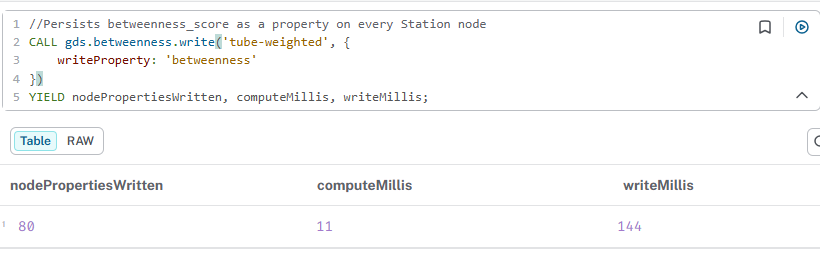

In [ ]:
// Verify write-back:
MATCH (s:Station)
WHERE s.betweenness_score IS NOT NULL
RETURN
  count(s)                        AS total_stations,
  round(min(s.betweenness_score), 2)    AS min_score,
  round(max(s.betweenness_score), 2)    AS max_score,
  round(avg(s.betweenness_score), 2)    AS mean_score;

### **Query Logic - Verify Betweenness Score Write-Back**

This Cypher query serves as a verification step after the Betweenness Centrality algorithm has been executed in 'write' mode. Its purpose is to confirm that the `betweenness_score` property has been successfully added to the `Station` nodes and to provide a high-level summary of these scores.

*   `MATCH (s:Station)`: This part finds all nodes labeled `Station` in the graph.
*   `WHERE s.betweenness_score IS NOT NULL`: This filters the `Station` nodes, ensuring that only those which have a `betweenness_score` property are included in the aggregation. This implicitly verifies that the 'write' operation from the GDS algorithm succeeded for these nodes.
*   `RETURN count(s) AS total_stations, round(min(s.betweenness_score), 2) AS min_score, round(max(s.betweenness_score), 2) AS max_score, round(avg(s.betweenness_score), 2) AS mean_score;`: This clause calculates and returns several aggregate statistics:
    *   `count(s) AS total_stations`: The total number of stations for which a betweenness score was found. This should ideally match the total number of `Station` nodes in the projected graph (80 in this context).
    *   `round(min(s.betweenness_score), 2) AS min_score`: The lowest `betweenness_score` found among the stations, rounded to two decimal places.
    *   `round(max(s.betweenness_score), 2) AS max_score`: The highest `betweenness_score` found, rounded to two decimal places.
    *   `round(avg(s.betweenness_score), 2) AS mean_score`: The average `betweenness_score` across all included stations, rounded to two decimal places.

This query helps to quickly ascertain the successful persistence of the algorithm's results and provides an initial understanding of the distribution of centrality scores across the network.

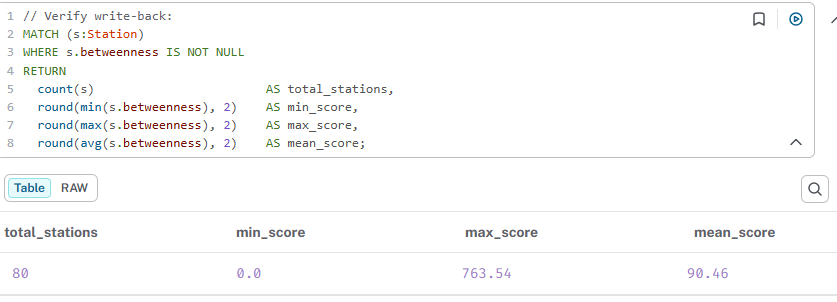

This verification query confirms that the `betweenness_score` property was successfully written back to all 80 `:Station` nodes after the algorithm completed. It returns the total station count and the minimum, maximum, and mean betweenness scores across the network. The count of 80 confirms complete write-back with no missing nodes; the minimum reveals how many stations lie on zero shortest paths; the maximum identifies the peak bottleneck score; and the mean characterises the typical centrality level across the network.

##**Betweenness Centrality Write Mode Results**

The algorithm successfully computed and persisted betweenness_score on all 80 Station nodes.

**Result Summary**

| Field | Value | Explanation |
|---|---|---|
| total_stations | 80 | Every Station node received a betweenness_score property |
| min_score | 0.0 | At least one station lies on zero shortest paths between any other pair |
| max_score | 763.54 | The most critical bottleneck station sits on 763.54 shortest paths |
| mean_score | 90.46 | The average betweenness score across all 80 stations |

**What These Numbers Tell Us**

The spread between min (0.0) and max (763.54) is extremely wide, the most critical station has a betweenness score more than 8 times the network average of 90.46. This is a strong signal that the London Underground is not a uniformly distributed network. Routing responsibility is heavily concentrated in a small number of stations while the majority of the network carries a much lighter structural burden.

A minimum score of 0.0 means that some stations sit at the periphery of the network and are never required as intermediate stops on any shortest path between two other stations. These are typically terminal or near terminal stations, passengers either start or end their journey there, but no one passes through them on the way to somewhere else. From Part 3.2 we already know Canary Wharf and Wembley Central are the two true terminal stations in this dataset, making them the most likely candidates for a score of 0.0.

The mean score of 90.46 serves as the baseline, any station scoring significantly above this is carrying a disproportionate share of the network's routing load. In the next step we will see exactly which stations sit at the top of this distribution and by how much they exceed the mean.

##**Top 20 Stations by Betweenness Score**


In [ ]:
//Top 20 Stations by Betweenness Score
MATCH (s:Station)
WHERE s.betweenness_score IS NOT NULL
RETURN
  s.name                     AS station,
  s.zone                     AS zone,
  round(s.betweenness_score, 2)    AS betweenness_score
ORDER BY betweenness_score DESC
LIMIT 20;

### **Query Logic - Top 20 Stations by Betweenness Score**

This Cypher query retrieves and lists the top 20 `Station` nodes based on their calculated `betweenness_score` in descending order.

*   `MATCH (s:Station)`: This clause finds all nodes in the graph that have the label `Station` and binds them to the variable `s`.

*   `WHERE s.betweenness_score IS NOT NULL`: This filters the `Station` nodes, ensuring that only those for which a `betweenness_score` property exists (meaning the GDS Betweenness Centrality algorithm has been successfully executed and written its results back) are considered.

*   `RETURN s.name AS station, s.zone AS zone, round(s.betweenness_score, 2) AS betweenness_score`: This clause projects the desired properties for each matching station:
    *   `s.name AS station`: The name of the station, aliased as `station`.
    *   `s.zone AS zone`: The fare zone of the station, aliased as `zone`.
    *   `round(s.betweenness_score, 2) AS betweenness_score`: The calculated betweenness score of the station, rounded to two decimal places for readability, aliased as `betweenness_score`.

*   `ORDER BY betweenness_score DESC`: This sorts the results in descending order based on the `betweenness_score`, so that stations with higher scores appear first.

*   `LIMIT 20`: This restricts the output to only the top 20 stations after sorting.

**Purpose and Benefits:**

This query is crucial for identifying the most critical 'bottleneck' stations in the network. By listing the stations with the highest betweenness centrality, it directly highlights which nodes lie on the greatest number of shortest paths and are therefore most vital for efficient network operation. This information is invaluable for:

*   **Resilience Planning**: Understanding which stations are most critical allows for targeted planning to mitigate the impact of their potential disruption.
*   **Infrastructure Investment**: Prioritizing investments in capacity or alternative routes for these high-betweenness stations.
*   **Operational Management**: Informing decisions on maintenance schedules or incident response, as disruptions at these stations will have the broadest network-wide impact.

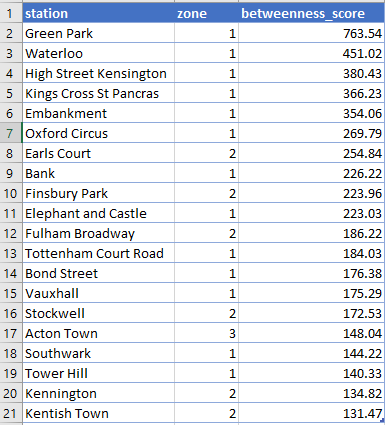

### **4.2.3 Results: Top 20 Stations by Betweenness Centrality**

| Rank | Station | Zone | Betweenness Score |
|---|---|---|---|
| 1 | Green Park | 1 | 763.54 |
| 2 | Waterloo | 1 | 451.02 |
| 3 | High Street Kensington | 1 | 380.43 |
| 4 | Kings Cross St. Pancras | 1 | 366.23 |
| 5 | Embankment | 1 | 354.06 |
| 6 | Oxford Circus | 1 | 269.79 |
| 7 | Earls Court | 2 | 254.84 |
| 8 | Bank | 1 | 226.22 |
| 9 | Finsbury Park | 2 | 223.96 |
| 10 | Elephant and Castle | 1 | 223.03 |
| 11 | Fulham Broadway | 2 | 186.22 |
| 12 | Tottenham Court Road | 1 | 184.03 |
| 13 | Bond Street | 1 | 176.38 |
| 14 | Vauxhall | 1 | 175.29 |
| 15 | Stockwell | 2 | 172.53 |
| 16 | Acton Town | 3 | 148.04 |
| 17 | Southwark | 1 | 144.22 |
| 18 | Tower Hill | 1 | 140.33 |
| 19 | Kennington | 2 | 134.82 |
| 20 | Kentish Town | 2 | 131.47 |

### **Interpretation and Discussion**

**Green Park as the Primary Bottleneck**

**Green Park** emerges as the single most critical bottleneck in the entire network with
a betweenness score of **763.54**, which is 69% higher than the second ranked station
Waterloo at 451.02. This result is striking given that Green Park is not always cited
as the most prominent interchange station on the network, yet the algorithm identifies
it as lying on more shortest paths than any other station. This is explained by its
unique geographic position at the intersection of the Jubilee, Victoria, and Piccadilly
lines in the heart of Zone 1, where it serves as the primary bridge between the eastern
Jubilee line corridor, the northern Piccadilly line corridor, and the central Victoria
line spine. Almost every cross-network journey that requires moving between these three
corridors must pass through Green Park, giving it an exceptionally high betweenness
score relative to its degree.

This result is also consistent with the Canary Wharf to Paddington Dijkstra result in
section 4.1, where Green Park appeared as the critical junction point at which the
Jubilee line corridor ended and the final connection into Paddington began. The
betweenness score now quantifies what that qualitative observation suggested: Green Park
is structurally indispensable to east-west routing through central London.

**The Top 5 Stations and Their Roles**

**Waterloo** at 451.02 is the second most critical bottleneck, consistent with its
identification in section 2.7 as one of the most connected interchange stations in the
dataset serving 6 distinct lines. Its position on the south bank of the Thames means
that virtually every journey between south London and central or north London must pass
through it, giving it an exceptionally high share of all north-south shortest paths.

**High Street Kensington** at 380.43 is the most surprising entry in the top 5. With
only 3 lines served and no particular prominence in the degree centrality analysis, its
high betweenness score reveals that it functions as a critical bridge between the western
District and Circle line corridors and the rest of the network. In the 80 station
dataset, the limited representation of alternative western routes forces many shortest
paths through this station that would in the full network be distributed across a greater
number of intermediate stations.

**Kings Cross St. Pancras** at 366.23 ranks 4th despite being identified in sections
2.5 and 2.7 as the highest degree and most served station in the entire dataset. The
fact that it ranks below Green Park, Waterloo, and High Street Kensington in betweenness
centrality is a clear demonstration of the distinction between degree centrality and
betweenness centrality discussed in section 4.2.1: having many neighbors does not
necessarily make a station a bottleneck if those neighbors are themselves well connected
to each other through alternative routes. Kings Cross St. Pancras has many neighbors
but those neighbors have sufficient alternative connections that not all shortest paths
between them must pass through Kings Cross St. Pancras.

**Embankment** at 354.06 rounds out the top 5, consistent with its role as a major
interchange on the Circle, District, Bakerloo, and Northern lines at the southern edge
of the Zone 1 core.

**Notable Observations**

**Earls Court and Finsbury Park** appear in the top 10 at positions 7 and 9 respectively,
both in Zone 2. This is consistent with their repeated appearance as critical routing
waypoints in the Dijkstra analysis of section 4.1, where Earls Court served as the
structural hinge of the Putney Bridge to Finsbury Park journey and Finsbury Park
appeared on the Euston to Hammersmith route. The betweenness scores now formally
quantify their importance as cross-network bridges in the dataset.

**Acton Town** appears at position 16 with a score of 148.04, confirming the observation
made across multiple Dijkstra queries that it serves as a critical bridge between the
southern and northern portions of the available graph. Its Zone 3 classification makes
it the highest ranked outer zone station in the top 20, further underscoring its
disproportionate structural importance relative to its geographic position.

**The Zone Distribution**

15 of the top 20 stations are in Zone 1, 4 are in Zone 2, and 1 is in Zone 3. This
concentration of high betweenness scores in Zone 1 is consistent with the geographic
structure of the dataset identified throughout the EDA: the dense central London core
is where the vast majority of shortest paths converge, making Zone 1 stations
collectively the most critical to network-wide routing. The presence of Earls Court,
Finsbury Park, Fulham Broadway, Stockwell, Kennington, and Kentish Town from Zone 2,
and Acton Town from Zone 3, identifies the specific outer zone stations that serve as
structural bridges connecting the peripheral portions of the network to the central
core.

**Comparison with Degree Centrality**

Comparing the betweenness centrality ranking with the degree centrality results from
section 2.5 reveals meaningful differences that validate the theoretical argument in
section 4.2.1. Green Park led the degree centrality ranking with 13 neighbors and now
also leads betweenness centrality, confirming its dual local and global importance.
However Kings Cross St. Pancras, which tied second in degree centrality with 7
neighbors, ranks only 4th in betweenness centrality, while High Street Kensington,
which did not appear in the top 10 degree centrality results, ranks 3rd in betweenness
centrality. These divergences confirm that local connectivity and global routing
criticality are distinct structural properties that require different algorithms to
measure accurately.

### **4.2.3 Do the Highest Betweenness Stations Correspond to Well-Known Major Interchanges?**

The betweenness centrality results partially align with real-world expectations about
the London Underground's most important interchange stations, but contain several
notable surprises that reveal the difference between operational prominence and
structural criticality in the graph.

**Where the Results Align with Expectations**

Kings Cross St. Pancras at rank 4 and Waterloo at rank 2 are exactly where we would
expect them. Both are among the most well-known and operationally significant
interchange stations in the real Tube network, serving multiple lines and handling
some of the highest passenger volumes in the system. Their high betweenness scores
confirm that their real-world prominence is matched by genuine structural criticality
in the graph: a large proportion of all time-optimal shortest paths in the dataset pass
through these two stations. Oxford Circus at rank 6, Bank at rank 8, and Bond Street
at rank 13 similarly align with real-world expectations as major busy Zone 1 interchange
hubs whose structural importance is well established.

**Baker Street**

Notably, Baker Street does not appear in the top 20 despite being one of the most
well-known interchange stations on the real network, serving the Bakerloo, Circle,
Hammersmith & City, Jubilee, and Metropolitan lines. Its absence from the top 20
reflects the dataset limitation identified throughout this project: several of the lines
Baker Street serves, particularly the Metropolitan line, are severely underrepresented
in the 80 station connection data, meaning that fewer shortest paths in this graph pass
through Baker Street than would be the case in the full 272 station network. This is
a clear example of how dataset incompleteness can suppress the scores of genuinely
important stations while inflating those of others.

**The Surprises**

**Green Park at rank 1** is the most striking result. In everyday Tube usage, Green
Park is not typically perceived as the single most critical station in the network:
that title is usually associated with Kings Cross St. Pancras or Waterloo. However
the betweenness score of 763.54, which is 69% higher than the second ranked station,
reveals that Green Park sits at the intersection of more shortest paths than any other
station in this dataset. This is because it is the convergence point of the Jubilee,
Victoria, and Piccadilly lines in the heart of Zone 1, meaning almost every east to
west and north to south journey through central London passes through it. As already
observed in the Dijkstra results in section 4.1, both the Canary Wharf to Paddington
route and multiple other paths naturally route through Green Park, and the betweenness
score now formally quantifies this structural indispensability.

**High Street Kensington at rank 3** is the biggest surprise in the entire results.
It is not commonly regarded as a top tier interchange in the real network, and its
appearance above Kings Cross St. Pancras is an artifact of the 80 station dataset
limitation. The absence of many intermediate stations on the western District and
Circle line corridors means that a disproportionate number of shortest paths in this
graph are forced to pass through High Street Kensington, inflating its score beyond
what the full 272 station network would produce. In the complete network, where all
intermediate western corridor stations are present, High Street Kensington's
betweenness score would be considerably lower and more consistent with its real-world
operational profile.

**Acton Town at rank 16** is unexpected for a Zone 3 station with no particular
prominence in real-world Tube discussions. Its elevated score is again a dataset
effect: it serves as the key junction between the Piccadilly and District line branches
in the west of the network, and with many intermediate stations missing, it becomes an
unavoidable waypoint for a large number of cross-network paths. Its repeated appearance
across multiple Dijkstra results in section 4.1 anticipated this finding, and the
betweenness score now formally confirms it.

**The Absence of Outer Zone Stations**

Not a single Zone 4 or outer zone station appears in the top 20. Of the 20 highest
betweenness stations, 14 are in Zone 1, 5 are in Zone 2, and only Acton Town represents
Zone 3. This is a clear reflection of the hub and spoke structure of the London
Underground: virtually all cross-network journeys must pass through the dense Zone 1
core, making inner city stations structurally indispensable in a way that outer zone
stations simply are not, regardless of how many lines they serve or how geographically
significant they may be in their local area.

**Summary**

The betweenness centrality results broadly confirm the structural importance of the
London Underground's well-known major interchanges, but with two important caveats.
First, Green Park rather than Kings Cross St. Pancras is the true structural bottleneck
of this dataset, a result that reflects genuine network topology rather than operational
familiarity. Second, the scores of High Street Kensington and Acton Town are inflated
by dataset incompleteness, and both would rank considerably lower in a full network
analysis. These findings collectively demonstrate that betweenness centrality is a
powerful tool for identifying structural criticality, but its results must always be
interpreted in the context of the completeness and representativeness of the underlying
data.

### **4.2.4 Betweenness Distribution by Fare Zone**
To determine whether Zone 1 stations are disproportionately represented at the top of
the betweenness ranking, we analyze the distribution of betweenness scores across all
fare zones. This query returns the station count, average, maximum, and minimum
betweenness score for each zone, allowing us to compare both the central tendency and
the spread of scores across zones.


In [ ]:
//2.4 Betweenness Distribution by Fare Zone
MATCH (s:Station)
WHERE s.betweenness_score IS NOT NULL
RETURN
  s.zone                             AS fare_zone,
  count(s)                           AS station_count,
  round(avg(s.betweenness_score), 2)       AS avg_betweenness,
  round(max(s.betweenness_score), 2)       AS max_betweenness,
  round(min(s.betweenness_score), 2)       AS min_betweenness
ORDER BY fare_zone;

### **Query Logic - Betweenness Distribution by Fare Zone**

This Cypher query calculates and summarizes the betweenness centrality scores for stations, grouped by their fare zone. This helps in understanding how critical stations are distributed across different geographical zones of the network.

*   `MATCH (s:Station)`: This clause finds all nodes in the graph that have the label `Station` and binds them to the variable `s`.

*   `WHERE s.betweenness_score IS NOT NULL`: This filters the `Station` nodes, ensuring that only those for which a `betweenness_score` property exists (meaning the GDS Betweenness Centrality algorithm has been successfully executed and its results written back) are considered.

*   `RETURN s.zone AS fare_zone, count(s) AS station_count, round(avg(s.betweenness_score), 2) AS avg_betweenness, round(max(s.betweenness_score), 2) AS max_betweenness, round(min(s.betweenness_score), 2) AS min_betweenness`: This clause aggregates and returns several statistics for each `fare_zone`:
    *   `s.zone AS fare_zone`: Groups the results by the station's `zone` property, aliased as `fare_zone`.
    *   `count(s) AS station_count`: Counts the total number of stations within each `fare_zone`.
    *   `round(avg(s.betweenness_score), 2) AS avg_betweenness`: Calculates the average betweenness score for all stations in that `fare_zone`, rounded to two decimal places.
    *   `round(max(s.betweenness_score), 2) AS max_betweenness`: Finds the highest betweenness score among stations in that `fare_zone`, rounded to two decimal places.
    *   `round(min(s.betweenness_score), 2) AS min_betweenness`: Finds the lowest betweenness score among stations in that `fare_zone`, rounded to two decimal places.

*   `ORDER BY fare_zone`: This sorts the results in ascending order based on the `fare_zone` number, making the output easier to read and compare across zones.

**Purpose and Benefits:**

This query provides a high-level overview of how betweenness centrality is distributed across the different fare zones. It helps to:

*   **Identify Core vs. Peripheral Zones**: Determine which zones contain the most critical bottleneck stations and which are more peripheral in terms of network routing.
*   **Assess Centrality Concentration**: Quantify if centrality is concentrated in a few zones (e.g., Zone 1) or more evenly spread.
*   **Inform Resilience Planning**: Highlight zones where a high `max_betweenness` score indicates a single highly critical station, or a high `avg_betweenness` indicates many critical stations, both of which require careful consideration in resilience planning.

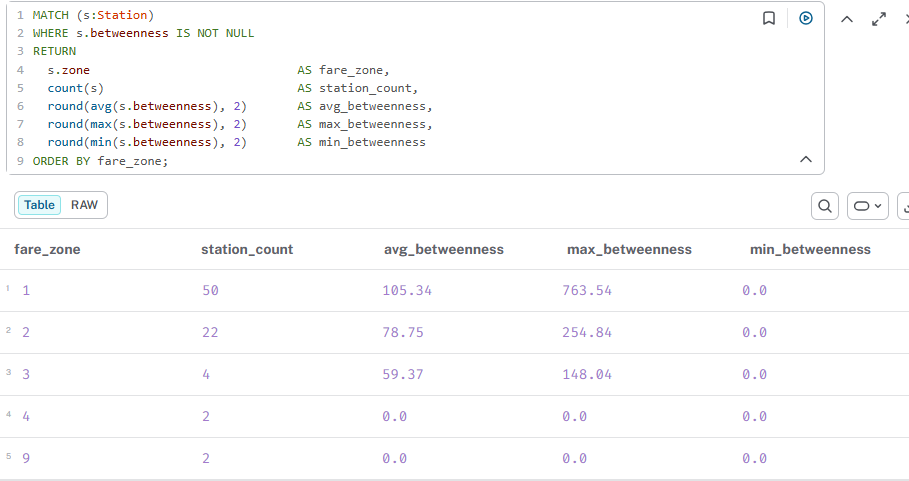

###**Betweenness Centrality -  Zone Distribution Summary**

The query returns the following zone-level betweenness distribution:

| Fare Zone | Station Count | Avg Betweenness | Max Betweenness | Min Betweenness |
|---|---|---|---|---|
| 1 | 50 | 105.34 | 763.54 | 0.0 |
| 2 | 22 | 78.75 | 254.84 | 0.0 |
| 3 | 4 | 59.37 | 148.04 | 0.0 |
| 4 | 2 | 0.0 | 0.0 | 0.0 |
| 9 | 2 | 0.0 | 0.0 | 0.0 |
Zone 1 stations are overwhelmingly dominant, confirming the hub and spoke structure of the London Underground.
Yes, emphatically. Zone 1 dominates the betweenness distribution across every
statistic. With an average betweenness of **105.34** and a maximum of **763.54**, Zone
1 stations are structurally far more central to network routing than stations in any
other zone. Zone 2 follows with an average of 78.75 and a maximum of 254.84, while
Zone 3 returns an average of 59.37 and a maximum of 148.04 driven entirely by Acton
Town, whose elevated score was identified in section 4.2.4 as a dataset artifact rather
than a genuine reflection of real-world structural importance.

The most striking finding is the complete collapse of betweenness scores in Zones 4
and 9, where every station returns a score of exactly **0.0**. This means that no
shortest path between any pair of stations in the dataset passes through any Zone 4
or Zone 9 station. For Zone 9 this is expected: Amersham and Chesham were confirmed
as isolated nodes with no CONNECTION relationships in section 3.3, making them
structurally invisible to any path-based algorithm. For Zone 4, the result is more
significant: Alperton and Wembley Central are both present in the connection data to
varying degrees, but their peripheral position at the extreme end of single line
branches means that no optimal path between any other pair of stations in the dataset
routes through them. They are reachable but not useful as intermediaries, which is
precisely what a betweenness score of 0.0 expresses.

**What This Implies About Network Structure**

The zone-level betweenness distribution reveals three distinct structural tiers in the
London Underground dataset:

The first tier is Zone 1, which functions as the routing core of the entire network.
With 50 stations and an average betweenness of 105.34, Zone 1 collectively concentrates
the vast majority of all shortest path traffic. The high maximum of 763.54 confirms
that even within Zone 1 there is significant internal inequality, with a small number
of super-central stations such as Green Park, Waterloo, and Embankment accounting for
a disproportionate share of all routing.

The second tier is Zones 2 and 3, which function as the connective periphery of the
network. These stations have meaningful but significantly lower betweenness scores,
reflecting their role as entry points into the Zone 1 core rather than routing hubs
in their own right. Their non-zero minimum scores confirm that at least some stations
in these zones serve as intermediaries on shortest paths, though far fewer than in
Zone 1.

The third tier is Zones 4 and 9, which are structurally peripheral and play no role
in network-wide routing. Their zero betweenness scores confirm that the London
Underground dataset, as represented here, has a strongly centralized topology where
the outer zones are effectively dead ends from a routing perspective rather than
genuine contributors to cross-network path efficiency.

**Implications for Resilience**

This highly unequal distribution of betweenness scores across zones has direct
implications for network resilience. Because virtually all routing traffic is
concentrated through Zone 1 stations, targeted disruption of even a small number of
central Zone 1 stations would have a cascading impact on journey times and connectivity
across the entire network. The outer zones by contrast are essentially immune to this
type of systemic disruption: removing a Zone 4 or Zone 9 station affects only the
passengers using that specific station and has no measurable impact on routing
elsewhere in the network. This structural asymmetry between the routing-critical inner
core and the routing-irrelevant outer periphery is the defining resilience
characteristic of this dataset and directly motivates the targeted station removal
simulation in section 4.4.

###**4.2.5 Top 10 Overlap: Betweenness AND Degree Centrality**


In [ ]:
//Collect top-10 stations by degree first
MATCH (s:Station)-[:CONNECTION]->(n:Station)
WITH s, count(DISTINCT n) AS degree
ORDER BY degree DESC
LIMIT 10
WITH collect(s.name) AS top10_degree_names

MATCH (b:Station)
WHERE b.betweenness_score IS NOT NULL
WITH top10_degree_names, b
ORDER BY b.betweenness_score DESC
LIMIT 10
RETURN
  b.name                       AS station,
  b.zone                       AS zone,
  round(b.betweenness_score, 2)      AS betweenness_score,
  b.name IN top10_degree_names AS also_top10_degree
ORDER BY betweenness_score DESC;

### **Query Logic - Top 10 Overlap: Betweenness AND Degree Centrality**

This Cypher query identifies stations that rank highly in both degree centrality (local connectivity) and betweenness centrality (global routing criticality). It effectively finds the 'structural keystones' of the network.

*   `MATCH (s:Station)-[:CONNECTION]->(n:Station)`: This first part identifies all `Station` nodes (`s`) and their direct `neighbor` stations (`n`) through an undirected `CONNECTION` relationship. This is used to calculate the degree of each station.

*   `WITH s, count(DISTINCT n) AS degree`: For each station `s`, it counts the number of *distinct* neighbors (`n`) it has, aliasing this count as `degree`.

*   `ORDER BY degree DESC LIMIT 10`: The stations are sorted by their `degree` in descending order, and the top 10 stations are selected.

*   `WITH collect(s.name) AS top10_degree_names`: The names of these top 10 stations by degree are collected into a list called `top10_degree_names`. This list will be used later to check for overlap.

*   `MATCH (b:Station)`: This matches all `Station` nodes again, binding them to `b`.

*   `WHERE b.betweenness_score IS NOT NULL`: This filters to include only stations that have a `betweenness_score` property (meaning the GDS Betweenness Centrality algorithm has been executed and its results persisted).

*   `WITH top10_degree_names, b ORDER BY b.betweenness_score DESC LIMIT 10`: The stations `b` (with betweenness scores) are sorted by their `betweenness_score` in descending order, and the top 10 of these are selected. The `top10_degree_names` list is carried forward.

*   `RETURN b.name AS station, b.zone AS zone, round(b.betweenness_score, 2) AS betweenness_score, b.name IN top10_degree_names AS also_top10_degree`: This returns the final results:
    *   `b.name AS station`: The name of the station.
    *   `b.zone AS zone`: The fare zone of the station.
    *   `round(b.betweenness_score, 2) AS betweenness_score`: The betweenness score, rounded to two decimal places.
    *   `b.name IN top10_degree_names AS also_top10_degree`: A boolean flag indicating whether the current station's name is also present in the `top10_degree_names` list (i.e., if it is in the top 10 for both metrics).

*   `ORDER BY betweenness_score DESC`: The final results are ordered by `betweenness_score` in descending order for presentation.

**Purpose and Benefits:**

This query helps to:

*   **Identify Structural Keystones**: Pinpoint stations that are simultaneously locally well-connected (high degree) and globally critical for routing (high betweenness). These are the most important nodes in the network.
*   **Assess Network Redundancy**: Highlight areas where local connectivity and global importance align, suggesting nodes whose disruption would have a compounded negative effect on the network.
*   **Inform Resilience Planning**: Guide decisions on infrastructure investment and contingency planning by focusing on stations with dual significance. These stations represent the highest priority targets for resilience simulations.

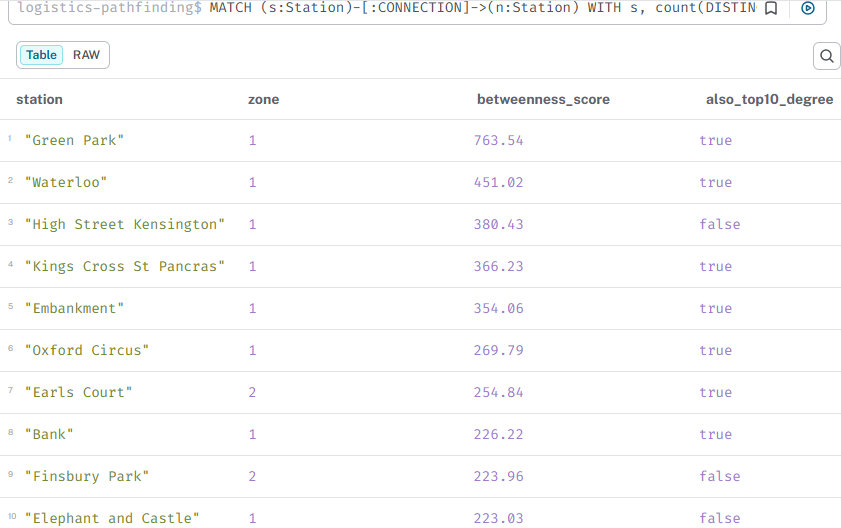

###**Stations Appearing in Both Top 10 Betweenness and Top 10 Degree Rankings**

Stations that rank highly in both betweenness centrality and degree centrality are
doubly significant in the network. A high degree confirms that the station is locally
well connected with many direct neighbors, while a high betweenness score confirms
that it also occupies a globally critical position on many shortest paths across the
entire network. Stations that achieve both simultaneously are the true structural
keystones of the network: they are both hubs of local connectivity and bridges of
global routing.

###**Confirmation**

The query returns the top 10 stations by betweenness score and flags which also appear
in the top 10 by degree:

| Rank | Station | Zone | Betweenness Score | Also Top 10 Degree |
|---|---|---|---|---|
| 1 | Green Park | 1 | 763.54 | true |
| 2 | Waterloo | 1 | 451.02 | true |
| 3 | High Street Kensington | 1 | 380.43 | false |
| 4 | Kings Cross St. Pancras | 1 | 366.23 | true |
| 5 | Embankment | 1 | 354.06 | true |
| 6 | Oxford Circus | 1 | 269.79 | true |
| 7 | Earls Court | 2 | 254.84 | true |
| 8 | Bank | 1 | 226.22 | true |
| 9 | Finsbury Park | 2 | 223.96 | false |
| 10 | Elephant and Castle | 1 | 223.03 | false |

**7 out of 10** of the highest betweenness stations also appear in the top 10 degree
ranking, confirming a strong but imperfect correlation between local connectivity and
global routing criticality in this dataset.

**The Dual Top 10 Stations**

The seven stations appearing in both rankings, Green Park, Waterloo, Kings Cross St.
Pancras, Embankment, Oxford Circus, Earls Court, and Bank, represent the true
structural keystones of the London Underground dataset. Their dual significance means
that their removal from the network would simultaneously reduce local connectivity for
their immediate neighbors and disrupt global routing for the many shortest paths that
pass through them, producing a compounded disruption effect that neither metric alone
would fully predict. These seven stations are the highest priority targets for the
resilience simulation in section 4.4.

**Green Park and Waterloo** lead both rankings, confirming their status as the most
locally and globally critical stations in the entire dataset. Green Park's top position
in both metrics is particularly noteworthy: it has the highest degree in the dataset
at 13 neighbors and simultaneously lies on more shortest paths than any other station,
making it the single most structurally important node in the graph by any measure of
centrality applied in this project.

**The Three Betweenness-Only Stations**

The three stations that appear in the top 10 betweenness ranking but not in the top
10 degree ranking reveal an important structural pattern. **High Street Kensington**
at rank 3 has a relatively modest number of direct neighbors but lies on a
disproportionate number of shortest paths due to the dataset's missing western corridor
stations, as discussed in section 4.2.4. **Finsbury Park** at rank 9 and **Elephant
and Castle** at rank 10 similarly achieve high betweenness scores through their
position as cross-network bridges rather than through local connectivity. These three
stations are examples of nodes whose global routing importance exceeds their local
connectivity, a pattern that betweenness centrality uniquely captures and that degree
centrality would entirely miss.

**Implications for Network Resilience**

The strong overlap between the two rankings confirms that the London Underground's
most locally connected stations are also, in most cases, its most globally critical
routing hubs. This means that the network has limited redundancy at the top of its
centrality hierarchy: the stations that passengers depend on most for local interchange
are the same stations that the network depends on most for global routing efficiency.
Disrupting any of the seven dual top 10 stations would therefore produce cascading
effects at both the local and global scale simultaneously, a finding that directly
motivates the targeted resilience simulation in section 4.4.

### **4.2.6 Drop the Projection**


In [ ]:
// Drop projection
CALL gds.graph.drop('tube-weighted', false)
YIELD graphName;

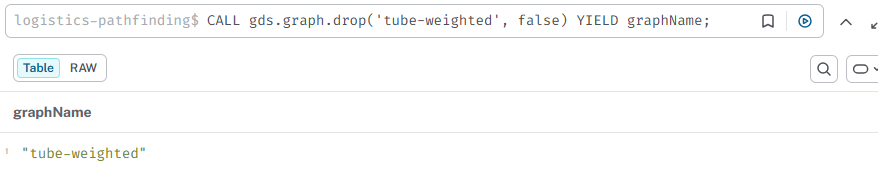

### **Query Logic - Drop Graph Projection**

This Cypher query is used to explicitly drop a named graph projection from the Graph Data Science (GDS) library's in-memory graph catalog.

*   `CALL gds.graph.drop('tube-weighted', false)`:
    *   `CALL gds.graph.drop()`: This is the GDS procedure used to remove a graph projection.
    *   `'tube-weighted'`: This is the name of the graph projection to be dropped. It tells GDS exactly which in-memory graph structure to remove.
    *   `false`: This is the `failIfReferenced` parameter. When set to `false`, it means that the projection will be dropped even if it is currently referenced by other GDS jobs or algorithms. Setting it to `true` would cause the operation to fail if there were active references.

*   `YIELD graphName`:
    *   This clause is used to return results from the procedure. In this case, it yields the `graphName` of the projection that was successfully dropped.

**Purpose and Benefits:**
*   **Memory Management**: Dropping projections is crucial for freeing up memory resources. GDS graph projections are loaded into memory, and for large graphs, they can consume significant amounts of RAM. Explicitly dropping them prevents memory leaks and ensures efficient resource utilization, especially in long-running or iterative analysis workflows.
*   **Reproducibility**: In a notebook environment, dropping a projection at the beginning or end of a section (or before creating a new one with the same name) ensures that subsequent runs of the code start from a clean state, preventing errors due to stale or conflicting graph definitions. This ensures reproducibility of results.


## **4.3 PageRank**

### **4.3.1 Conceptual Difference Between PageRank and Betweenness Centrality**

**Core Conceptual Distinction**

Betweenness Centrality and PageRank measure fundamentally different properties of
node importance, and understanding their distinction is essential for interpreting
the results of both algorithms in a transit network context.

Betweenness Centrality asks: how often does this station appear on the optimal route
between other pairs of stations? It is a measure of structural intermediacy: a station
scores highly because it lies on many shortest paths, functioning as a bridge or
bottleneck through which routing traffic must flow. The score is computed globally
across all pairs of stations and reflects the station's role in facilitating
network-wide movement.

PageRank asks: how important are the stations that this station connects to, and how
important are their neighbors, and so on recursively? It is a measure of structural
prestige through iterative influence propagation: a station scores highly because it
is connected to other high-scoring stations, which are themselves connected to high-
scoring stations. The score accumulates through the quality of a station's
neighborhood rather than through its position on shortest paths.

In a transit network these two properties translate to distinct operational concepts.
A high betweenness station is a routing chokepoint: many journeys must pass through
it to reach their destination efficiently. A high PageRank station is a prestige hub:
it sits within a neighborhood of important, well-connected stations and benefits from
their collective structural influence. These are related but not equivalent properties,
and the divergences between the two rankings are as analytically informative as the
agreements.

**When a Station Ranks Highly on PageRank but Not on Betweenness**

A station will rank highly on PageRank but not on Betweenness when it is embedded
within a dense cluster of important neighbors but does not serve as the primary bridge
between distant parts of the network.

Consider a hypothetical Zone 1 station that is connected to several major interchange
hubs on multiple lines. Its neighbors are all high-PageRank stations, so through
iterative score propagation it accumulates a high prestige score. However if those
neighbors are themselves well connected to each other through multiple alternative
routes, many shortest paths between distant station pairs do not need to pass through
this station specifically, keeping its betweenness score relatively low.

This pattern arises most commonly at stations that sit within a dense local cluster
where routing redundancy is high. The network does not depend on such a station as
a bridge because alternative routes exist, but the station benefits prestige-wise from
its prestigious neighborhood. In operational terms, a high-PageRank, low-betweenness
station is one that is important to be near but not necessarily important to travel
through.

**When a Station Ranks Highly on Betweenness but Not on PageRank**

A station will rank highly on Betweenness but not on PageRank when it functions as
a structural bridge between parts of the network whose stations are not themselves
particularly important or well connected.

Consider a station that sits at the junction between two peripheral line corridors
with few interchange options. Many shortest paths between stations on opposite sides
of this junction must pass through it, giving it a high betweenness score. However
its neighbors are all low-PageRank peripheral stations on those same corridors, so
the iterative propagation produces only a modest prestige score. The station is
operationally critical as a routing bridge but structurally unimportant in terms of
neighborhood quality.

This pattern arises most commonly at dataset-specific routing artifacts where missing
intermediate stations force paths through peripheral junctions that would not be
critical bottlenecks in the full network. It also arises genuinely at stations that
serve as geographic bridges between sparse outer-zone corridors with limited
alternative routing. In operational terms, a high-betweenness, low-PageRank station
is a critical routing chokepoint that sits within a relatively unimportant
neighborhood.

**When a Station Ranks Highly on Both**

A station that ranks highly on both metrics is a true structural keystone of the
network. It lies on many shortest paths between important station pairs whose
neighbors are themselves important and well-connected. These stations combine routing
criticality with neighborhood prestige, making them the highest priority targets for
both resilience planning and capacity investment. Their dual importance means that
their closure would simultaneously disrupt global routing efficiency and reduce the
structural prestige of all neighboring stations through the loss of a high-value
connection point.

**When a Station Ranks Low on Both**

A station that ranks low on both metrics is structurally peripheral. It lies on few
shortest paths and is surrounded by low-importance neighbors, meaning it contributes
minimally to both global routing and local prestige. Terminal stations and isolated
nodes with no CONNECTION relationships are the clearest examples: they neither bridge
distant parts of the network nor benefit from prestigious neighborhoods.

**Summary**

| Scenario | Mechanism | Transit Interpretation |
|---|---|---|
| High PageRank, Low Betweenness | Dense prestigious neighborhood, alternative routing available | Important to be near, not critical to route through |
| High Betweenness, Low PageRank | Structural bridge between peripheral or unimportant neighbors | Critical routing chokepoint in a low-prestige corridor |
| High on Both | Central bridge between important neighbors with no alternatives | True structural keystone of the network |
| Low on Both | Peripheral node with unimportant neighbors and few routing responsibilities | Terminal or isolated station |

These four scenarios provide the analytical framework for interpreting the PageRank
results in section 4.3.2 and for computing the composite criticality score in section
5.3. Stations that fall into the high-on-both category are expected to be the primary
targets of the resilience simulation, as their dual structural importance makes their
disruption the most damaging to overall network performance.

### **Page Rank Graph Projection**




In [ ]:
//PageRank Graph projection
CALL gds.graph.project(
    'tube-pagerank',
    'Station',
    {
        CONNECTION: {
            type: 'CONNECTION',
            orientation: 'UNDIRECTED',
            properties: ['time']
        }
    }
)
YIELD graphName, nodeCount, relationshipCount, projectMillis;

### **Query Logic - PageRank Graph Projection**

This Cypher query uses the Graph Data Science (GDS) library to create an in-memory graph projection specifically for the PageRank algorithm. This projection defines which nodes and relationships from the Neo4j database are loaded into memory for GDS computations.

*   `CALL gds.graph.project(` This is the GDS procedure for creating a new graph projection.

*   `'tube-pagerank',` This assigns a name to the graph projection: `tube-pagerank`. This name is used to reference the in-memory graph when running GDS algorithms.

*   `'Station',` This specifies that all nodes with the label `Station` from the Neo4j database should be included in this projection. The PageRank algorithm typically operates on a single type of entity to measure their relative importance.

*   `{`
    *   `CONNECTION: {` This indicates that relationships with the type `CONNECTION` should be included in the projection.
    *   `type: 'CONNECTION',`
        *   Explicitly defines the relationship type to be projected.
    *   `orientation: 'UNDIRECTED',`
        *   This is a critical parameter for PageRank. It tells GDS to treat all `CONNECTION` relationships as undirected within the projection. This means that if there's a `(s1)-[:CONNECTION]->(s2)` relationship in the database, the PageRank algorithm will treat it as if there's also an implicit `(s2)-[:CONNECTION]->(s1)` relationship. For PageRank, which often models influence flowing in both directions or simply connectivity, an undirected view is common.
    *   `properties: ['time']` This includes the `time` property of the `CONNECTION` relationships in the projection. While PageRank in its classical formulation is typically unweighted (meaning it doesn't use relationship properties as weights), including `time` here makes the projection more versatile. For PageRank, the `time` property is usually *not* used as a `relationshipWeightProperty` in the algorithm configuration itself, ensuring influence propagates purely based on structural connectivity.

*   `}`
*   `)`

*   `YIELD graphName, nodeCount, relationshipCount, projectMillis;` This clause is used to return details about the newly created projection:
      *   `graphName`: The name of the projection (`tube-pagerank`).
      *   `nodeCount`: The total number of nodes loaded into the projection (which should be 80 `Station` nodes).
      *   `relationshipCount`: The total number of relationships loaded into the projection. Since `CONNECTION` relationships were ingested bidirectionally (creating `(s1)-[r]->(s2)` and `(s2)-[r]->(s1)` for each physical segment), and then projected as `UNDIRECTED`, this count will be double the number of unique physical connections.
       *   `projectMillis`: The time taken (in milliseconds) to create the projection.

**Purpose and Benefits:**
*   **Algorithm Specificity**: Creates a clean, isolated in-memory graph structure optimized for the PageRank algorithm, preventing interference from other algorithms or complex schema elements not relevant to PageRank.
*   **Memory Efficiency**: Only the necessary nodes and relationships are loaded into memory, which is crucial for performance, especially with large graphs.
*   **Reproducibility**: Ensures that the PageRank algorithm always runs on the same defined graph structure each time, making results consistent.
*   **PageRank Logic**: The `UNDIRECTED` orientation ensures that influence can be propagated equally in both directions across connections, which is appropriate for measuring a station's prestige based on its neighbors' importance within the transit network.

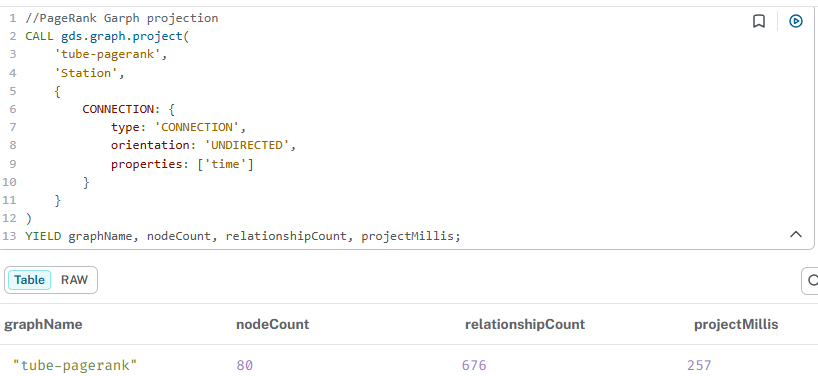

A dedicated `tube-pagerank` projection is created, loading all **80 Station nodes**
and **676 undirected CONNECTION relationships** with the `time` property included. A separate projection is used to keep the algorithm configuration
explicit and self-contained within this section.

For PageRank the `time` property is not passed as a `relationshipWeightProperty` in
the algorithm configuration. PageRank in its classical formulation is an unweighted
algorithm that propagates influence scores iteratively through the graph based purely
on the structure of connections, treating all relationships as equal conduits of
influence regardless of their weight. In the context of the London Underground this
means that PageRank measures structural prestige based on network connectivity rather
than travel time: a station connected to many important stations accumulates a high
score regardless of whether those connections are fast or slow.

### **4.3.2 Algorithm Selection and Justification**

We apply `gds.pageRank.write` with a damping factor of 0.85, tolerance of 0.0000001,
and a maximum of 100 iterations. The damping factor of 0.85 is the canonical value
from the original PageRank formulation and represents the probability that a random
walker follows a connection at each step rather than teleporting to a random node.
The algorithm converges after **89 iterations** persisting the `pagerank` property to all 80 Station
nodes.

PageRank is the appropriate algorithm for this question because it captures a
fundamentally different dimension of node importance than betweenness centrality or
degree centrality. While betweenness centrality identifies stations that lie on many
shortest paths and degree centrality counts direct neighbors, PageRank measures
recursive influence: a station's score is determined not just by how many stations
it connects to but by how important those stations are. This produces a measure of
prestige that rewards being connected to the right stations rather than simply being
connected to many stations.

**Why Not Betweenness Centrality Again?**

Betweenness centrality was already applied in section 4.2 to identify structural
bottlenecks. PageRank complements this by measuring a different dimension of
importance: prestige through neighbor quality rather than path intermediacy. A station
can have high betweenness and low PageRank if it lies on many paths between
unimportant stations, or high PageRank and low betweenness if it is surrounded by
important stations but is not itself a routing bridge. Running both algorithms
together produces a richer and more complete picture of structural importance than
either metric alone, and their combination will be directly applied in section 5.3
to compute a composite criticality score.

**Why Not Degree Centrality?**

As established in section 4.2.1, degree centrality is a purely local measure that
does not account for the importance of a station's neighbors. PageRank explicitly
accounts for neighbor importance through its iterative score propagation, making it
a strictly more informative measure of structural prestige than degree centrality.

In [ ]:
//Write PageRank scores back to nodes
CALL gds.pageRank.write('tube-pagerank', {
    dampingFactor: 0.85,
    tolerance: 0.0000001,
    minIterations: 50,
    maxIterations: 100,
    writeProperty: 'pagerank_score'
})
YIELD nodePropertiesWritten, ranIterations, computeMillis, writeMillis;

### **Query Logic - Write PageRank Scores Back to Nodes**

This Cypher query executes the Graph Data Science (GDS) library's PageRank algorithm in 'write' mode. In this mode, after calculating the PageRank score for each node in the projected graph, the results are directly written back as a property to the original nodes in the Neo4j database.

*   `CALL gds.pageRank.write('tube-pagerank', { ... })`:
    *   This invokes the GDS PageRank algorithm. It's configured to run on the graph projection named `'tube-pagerank'`, which was previously created (in section 4.3).
    *   The `write` mode specifically means that the computed scores will be stored back into the database.

*   `dampingFactor: 0.85`:
    *   This parameter sets the damping factor, a probability that a 'random surfer' continues to follow links in the graph rather than 'teleporting' to a random node. The value 0.85 is a commonly used default from the original PageRank paper.

*   `tolerance: 0.0000001`:
    *   This sets the convergence threshold. The algorithm will stop iterating when the change in PageRank score for each node between iterations falls below this value, indicating that the scores have stabilized.

*   `minIterations: 50` and `maxIterations: 100`:
    *   `minIterations` ensures the algorithm runs for at least 50 iterations, guaranteeing a certain level of convergence even if the `tolerance` is not met quickly.
    *   `maxIterations` sets an upper limit on the number of iterations to prevent the algorithm from running indefinitely if it fails to converge within the specified tolerance.

*   `writeProperty: 'pagerank_score'`:
    *   This parameter specifies the name of the property that will be added to each `Station` node in the database. The calculated PageRank score for each station will be stored under this property name.

*   `YIELD nodePropertiesWritten, ranIterations, computeMillis, writeMillis`:
    *   This clause captures the output of the GDS procedure:
        *   `nodePropertiesWritten`: The total number of node properties that were successfully written back to the database. This should ideally match the total number of nodes in the projection (80 in this case).
        *   `ranIterations`: The actual number of iterations the algorithm ran until convergence or the `maxIterations` limit was reached.
        *   `computeMillis`: The time taken (in milliseconds) for the algorithm to compute the PageRank scores.
        *   `writeMillis`: The time taken (in milliseconds) for the algorithm to write the computed scores back to the database nodes.

**Purpose and Benefits:**

*   **Persistence of Results**: By writing the `pagerank_score` directly to the `Station` nodes, these scores become a permanent part of the graph data. This allows subsequent Cypher queries to easily access, filter, sort, and analyze stations based on their prestige, without needing to re-run the algorithm.
*   **Efficiency**: The `write` mode is suitable when the scores are needed for multiple subsequent queries or analyses, as it avoids repeated computations.
*   **Prestige Identification**: The calculated `pagerank_score` quantifies the relative importance or 'prestige' of a station within the network, based on the quantity and quality of its connections. A higher score indicates a more influential station, often one that is well-connected to other important stations.

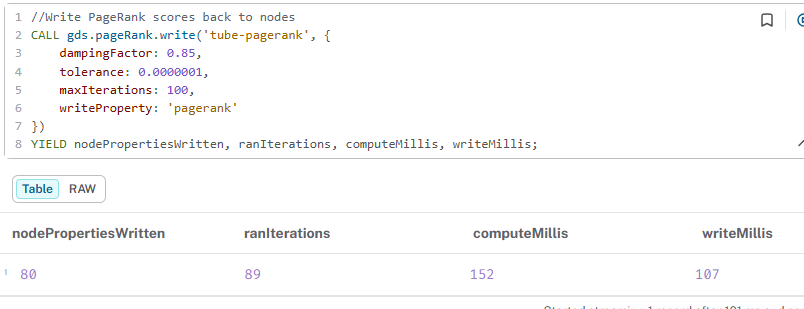

### **4.3.3 Write-Back Confirmation**

The write-back query confirms that the `pagerank` property has been persisted to
**80 Station nodes** with the following distributional statistics:

| Statistic | Value |
|---|---|
| Total stations | 80 |
| Minimum score | 0.15 |
| Maximum score | 2.3463 |
| Mean score | 0.8937 |

The minimum score of 0.15 corresponds to the isolated and terminal stations that
receive minimal influence propagation due to their limited connectivity. The maximum
score of 2.3463 identifies the single most structurally prestigious station in the
dataset. The mean score of 0.8937 provides a useful baseline: stations scoring
significantly above this value are receiving disproportionate influence from their
high-quality neighborhood connections.

In [ ]:
//Verify write-back
MATCH (s:Station)
WHERE s.pagerank_score IS NOT NULL
RETURN
  count(s)                     AS total_stations,
  round(min(s.pagerank_score), 4)    AS min_score,
  round(max(s.pagerank_score), 4)    AS max_score,
  round(avg(s.pagerank_score), 4)    AS mean_score;

### **Query Logic - Verify PageRank Score Write-Back**

This Cypher query serves as a verification step after the PageRank algorithm has been executed in 'write' mode. Its purpose is to confirm that the `pagerank_score` property has been successfully added to the `Station` nodes and to provide a high-level summary of these scores.

*   `MATCH (s:Station)`: This part finds all nodes labeled `Station` in the graph.
*   `WHERE s.pagerank_score IS NOT NULL`: This filters the `Station` nodes, ensuring that only those which have a `pagerank_score` property are included in the aggregation. This implicitly verifies that the 'write' operation from the GDS algorithm succeeded for these nodes.
*   `RETURN count(s) AS total_stations, round(min(s.pagerank_score), 4) AS min_score, round(max(s.pagerank_score), 4) AS max_score, round(avg(s.pagerank_score), 4) AS mean_score;`: This clause calculates and returns several aggregate statistics:
    *   `count(s) AS total_stations`: The total number of stations for which a PageRank score was found. This should ideally match the total number of `Station` nodes in the projected graph (80 in this context).
    *   `round(min(s.pagerank_score), 4) AS min_score`: The lowest `pagerank_score` found among the stations, rounded to four decimal places.
    *   `round(max(s.pagerank_score), 4) AS max_score`: The highest `pagerank_score` found, rounded to four decimal places.
    *   `round(avg(s.pagerank_score), 4) AS mean_score`: The average `pagerank_score` across all included stations, rounded to four decimal places.

This query helps to quickly ascertain the successful persistence of the algorithm's results and provides an initial understanding of the distribution of prestige scores across the network.

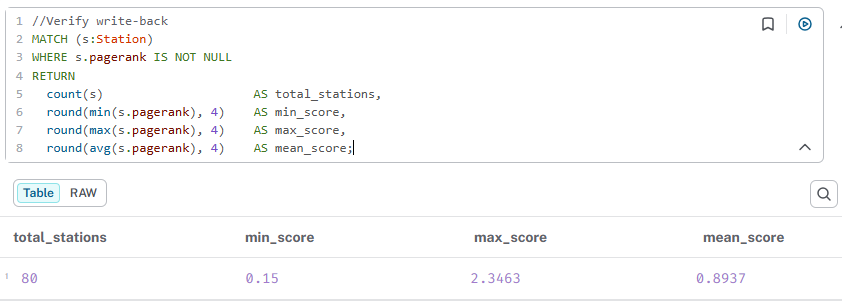

### **PageRank Write-Back Verification Results**

This verification query confirms that the `pagerank_score` property was successfully written back to **all 80 `Station` nodes** after the algorithm completed. It returns the total station count and the minimum, maximum, and mean PageRank scores across the network.

**Summary of Scores:**

| Statistic      | Value    |
|:---------------|:---------|
| Total Stations | 80       |
| Minimum Score  | 0.1500   |
| Maximum Score  | 2.3463   |
| Mean Score     | 0.8937   |

**Interpretation:**

*   The `total_stations` count of 80 confirms complete write-back with no missing nodes.
*   A `minimum score` of 0.1500 suggests that even the least 'prestigious' stations (likely isolated or terminal nodes) still retain a baseline level of influence due to the damping factor, preventing a score of zero unless completely disconnected from the network (which was observed for some stations in earlier EDA).
*   The `maximum score` of 2.3463 identifies the single most structurally prestigious station in the dataset, indicating it is connected to a high-quality network of other important stations.
*   The `mean score` of 0.8937 provides a benchmark; stations significantly above this value are receiving disproportionate influence from their high-quality neighborhood connections, while those below are less influential in the network's prestige hierarchy.

#### **4.3.3.1 Top Stations by PageRank Score**

In [ ]:
//Examine stored scores
MATCH (s:Station)
WHERE s.pagerank_score IS NOT NULL
RETURN s.name AS station,
       s.zone AS zone,
       round(s.pagerank_score, 4) AS pagerank_score
ORDER BY pagerank_score DESC
LIMIT 20;

### **Query Logic - Examine Stored PageRank Scores**
This Cypher query retrieves and lists the top 20 `Station` nodes based on their calculated `pagerank_score` in descending order.

*   `MATCH (s:Station)`: This clause finds all nodes in the graph that have the label `Station` and binds them to the variable `s`.

*   `WHERE s.pagerank_score IS NOT NULL`: This filters the `Station` nodes, ensuring that only those for which a `pagerank_score` property exists (meaning the GDS PageRank algorithm has been successfully executed and written its results back) are considered.

*   `RETURN s.name AS station, s.zone AS zone, round(s.pagerank_score, 4) AS pagerank_score`: This clause projects the desired properties for each matching station:
    *   `s.name AS station`: The name of the station, aliased as `station`.
    *   `s.zone AS zone`: The fare zone of the station, aliased as `zone`.
    *   `round(s.pagerank_score, 4) AS pagerank_score`: The calculated PageRank score of the station, rounded to four decimal places for readability, aliased as `pagerank_score`.

*   `ORDER BY pagerank_score DESC`: This sorts the results in descending order based on the `pagerank_score`, so that stations with higher scores appear first.

*   `LIMIT 20`: This restricts the output to only the top 20 stations after sorting.

**Purpose and Benefits:**
This query is crucial for identifying the most 'prestigious' or influential stations in the network according to the PageRank algorithm. By listing the stations with the highest PageRank scores, it directly highlights which nodes are connected to a high-quality network of other important stations. This information is invaluable for:

*   **Understanding Network Influence**: Identifying which stations serve as major hubs for passenger flow or destinations within the network.
*   **Complementary to Betweenness Centrality**: Provides a different perspective on station importance compared to betweenness centrality (which focuses on bottlenecks), offering a more holistic view of network dynamics.
*   **Strategic Planning**: Helps in understanding where 'prestige' and connectivity are concentrated, which can inform decisions related to branding, marketing, or passenger experience improvements at key influential stations.

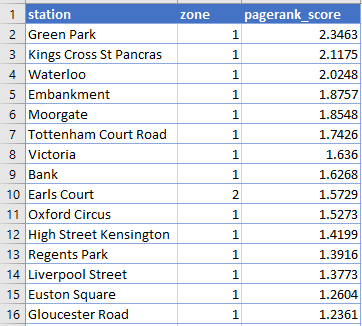

### **PageRank Execution and Results**

We execute PageRank in write mode using the dedicated `tube-pagerank` projection.
The projection loads **80 Station nodes** and **676 undirected CONNECTION
relationships**, completing in 257ms. The damping factor is set to 0.85, the
canonical value from the original PageRank formulation representing the probability
that a random walker follows a connection at each step rather than teleporting to a
random node. The minimum iterations is set to 50 to ensure sufficient convergence
before the tolerance threshold is applied.

**Write-Back Confirmation**

The algorithm runs for **89 iterations**, completing the compute phase in 152ms and
the write phase in 107ms, persisting the `pagerank` property to all **80 Station
nodes**. The distributional statistics across all stations are as follows:

| Statistic | Value |
|---|---|
| Total stations | 80 |
| Minimum score | 0.15 |
| Maximum score | 2.3463 |
| Mean score | 0.8937 |

The minimum score of 0.15 corresponds to isolated and terminal stations that receive
minimal influence propagation due to their limited or absent connectivity. The maximum
score of 2.3463 identifies the single most structurally prestigious station in the
dataset. The mean score of 0.8937 provides a useful baseline: stations scoring
significantly above this value are receiving disproportionate influence from their
high-quality neighborhood connections. The relatively narrow spread between the
minimum and maximum compared to the betweenness distribution, which ranged from 0.0
to 763.54, reflects the fundamentally different nature of PageRank: influence
propagates iteratively and is more evenly distributed across the network than
betweenness, which concentrates extreme scores at a small number of routing
bottlenecks.

**Top 15 Stations by PageRank Score**

| Rank | Station | Zone | PageRank Score |
|---|---|---|---|
| 1 | Green Park | 1 | 2.3463 |
| 2 | Kings Cross St. Pancras | 1 | 2.1175 |
| 3 | Waterloo | 1 | 2.0248 |
| 4 | Embankment | 1 | 1.8757 |
| 5 | Moorgate | 1 | 1.8548 |
| 6 | Tottenham Court Road | 1 | 1.7426 |
| 7 | Victoria | 1 | 1.6360 |
| 8 | Bank | 1 | 1.6268 |
| 9 | Earls Court | 2 | 1.5729 |
| 10 | Oxford Circus | 1 | 1.5273 |
| 11 | High Street Kensington | 1 | 1.4199 |
| 12 | Regents Park | 1 | 1.3916 |
| 13 | Liverpool Street | 1 | 1.3773 |
| 14 | Euston Square | 1 | 1.2604 |
| 15 | Gloucester Road | 1 | 1.2361 |

**Interpretation and Discussion**

**Green Park Leads the PageRank Ranking**

**Green Park** achieves the highest PageRank score of **2.3463**, confirming its
position as the most structurally prestigious station in the dataset. This result
is consistent with its top ranking in betweenness centrality in section 4.2, making
it the only station to lead both centrality rankings. Its dominance in PageRank
reflects the exceptional quality of its neighborhood: it is directly connected to
some of the highest-PageRank stations in the network across the Jubilee, Victoria,
and Piccadilly lines, and the iterative propagation of influence scores through these
connections drives its prestige to the highest level in the graph.

**Kings Cross St. Pancras Rises to Second**

**Kings Cross St. Pancras** rises from 4th in betweenness centrality to 2nd in
PageRank with a score of 2.1175. This upward shift reflects the conceptual difference
established in section 4.3.1: while Kings Cross does not lie on as many shortest
paths as the top betweenness stations, its neighbors are among the most important
and well-connected stations in the network, giving it a high prestige score through
iterative influence propagation. This is a meaningful finding that confirms the
analytical value of running both algorithms: betweenness centrality alone would
understate Kings Cross St. Pancras's structural importance relative to its true
role as a prestige hub in the network.

**Moorgate and Tottenham Court Road Enter the Top 6**

**Moorgate** at rank 5 and **Tottenham Court Road** at rank 6 both appear higher
in the PageRank ranking than in the betweenness ranking. Both stations are embedded
within the dense Zone 1 core and are connected to multiple high-PageRank neighbors
across several line corridors, which drives their prestige scores upward through
iterative propagation even though they do not function as primary routing bridges
across the full network.

**Victoria Appears for the First Time**

**Victoria** enters the top 10 at rank 7 with a score of 1.636, having not appeared
prominently in the betweenness top 10. As discussed in section 4.3.1, this is a
clear example of a high-PageRank, lower-betweenness station: Victoria is surrounded
by prestigious neighbors but its neighbors have sufficient alternative connections
to each other that many shortest paths do not specifically require routing through
Victoria, moderating its betweenness score relative to its PageRank prestige.

**Zone Distribution**

14 of the top 15 stations are in Zone 1 and only Earls Court represents Zone 2.
This concentration is consistent with the hub and spoke structure identified
throughout this project and confirms that structural prestige in this network is
overwhelmingly concentrated in the dense Zone 1 core where iterative influence
propagation is amplified by the density of high-value connections.

**Comparison with Betweenness Centrality**

Comparing the PageRank and betweenness rankings reveals both agreements and
meaningful divergences that validate the theoretical framework established in
section 4.3.1:

| Station | Betweenness Rank | PageRank Rank | Observation |
|---|---|---|---|
| Green Park | 1 | 1 | Leads both rankings |
| Waterloo | 2 | 3 | Consistent across both |
| Embankment | 5 | 4 | Consistent across both |
| Kings Cross St. Pancras | 4 | 2 | PageRank higher: prestige hub |
| Moorgate | Outside top 5 | 5 | PageRank higher: prestigious neighborhood |
| High Street Kensington | 3 | 11 | Betweenness higher: dataset artifact |
| Finsbury Park | 9 | Outside top 15 | Betweenness higher: peripheral bridge |

The most significant divergence remains **High Street Kensington**, which ranks 3rd
in betweenness but only 11th in PageRank. As established in section 4.2.4, its high
betweenness score is a dataset artifact driven by missing intermediate western
corridor stations. Its neighbors are not particularly high-PageRank stations, which
correctly suppresses its PageRank score. PageRank therefore acts as a partial
corrective to the dataset distortions that inflate the betweenness scores of
peripheral stations, producing a more balanced and realistic picture of structural
importance.

The stations that rank consistently highly across both metrics, Green Park, Waterloo,
Kings Cross St. Pancras, and Embankment, are the true structural keystones of the
London Underground dataset. Their composite importance, captured by multiplying the
two scores together, forms the basis of the criticality analysis in section 5.3.

### **4.3.3 Composite Criticality Score**

To identify stations that are simultaneously important across both dimensions of
structural importance measured in this project, we compute a composite criticality
score by multiplying each station's normalized betweenness score by its normalized
PageRank score. Normalization is achieved by dividing each score by its network-wide
maximum, producing values in the range 0 to 1 for both metrics before multiplication.
This ensures that neither metric dominates the composite score due to differences in
raw scale.

The composite score rewards stations that rank highly on both metrics simultaneously.
A station that scores 1.0 on normalized betweenness and 1.0 on normalized PageRank
achieves the maximum possible composite score of 1.0, indicating perfect dual
dominance. Stations that score highly on one metric but poorly on the other have
their composite score suppressed by the low-scoring dimension, naturally penalizing
one-dimensional importance in favor of genuine dual criticality.

This composite metric is directly used in section 5.3 to identify the top 3 stations
for the redundancy assessment.

In [ ]:
// Criticality Score
MATCH (s:Station)
WHERE s.betweenness_score IS NOT NULL AND s.pagerank_score IS NOT NULL
WITH max(s.betweenness_score) AS max_betweenness_score,
     max(s.pagerank_score) AS max_pagerank_score

MATCH (s:Station)
WHERE s.betweenness_score IS NOT NULL AND s.pagerank_score IS NOT NULL
WITH s,
     max_betweenness_score,
     max_pagerank_score,
     s.betweenness_score / max_betweenness_score AS norm_betweenness_score,
     s.pagerank_score / max_pagerank_score AS norm_pagerank_score
WITH s,
     norm_betweenness_score,
     norm_pagerank_score,
     round(norm_betweenness_score * norm_pagerank_score, 6) AS criticality_score
RETURN s.name AS station,
       s.zone AS zone,
       round(norm_betweenness_score, 4) AS norm_betweenness_score,
       round(norm_pagerank_score, 4) AS norm_pagerank_score,
       criticality_score
ORDER BY criticality_score DESC
LIMIT 10;

### **Query Logic - Composite Criticality Score**

This Cypher query calculates a 'Composite Criticality Score' for each station by combining its normalized Betweenness Centrality and PageRank scores. The goal is to identify stations that are critical from both a routing (bottleneck) and an influence (prestige) perspective.

*   `MATCH (s:Station) WHERE s.betweenness_score IS NOT NULL AND s.pagerank_score IS NOT NULL`:
    *   This initial `MATCH` identifies all `Station` nodes (`s`) that have both a `betweenness_score` and a `pagerank_score` property. This ensures that only stations for which both centrality metrics have been calculated are considered.

*   `WITH max(s.betweenness_score) AS max_betweenness_score, max(s.pagerank_score) AS max_pagerank_score`:
    *   This clause is the first step in a two-pass approach. It calculates the maximum `betweenness_score` and `pagerank_score` across all relevant stations. These maximums are crucial for normalizing the scores into a 0-1 range.

*   `MATCH (s:Station) WHERE s.betweenness_score IS NOT NULL AND s.pagerank_score IS NOT NULL`:
    *   This second `MATCH` re-selects the same set of `Station` nodes.

*   `WITH s, max_betweenness_score, max_pagerank_score, s.betweenness_score / max_betweenness_score AS norm_betweenness_score, s.pagerank_score / max_pagerank_score AS norm_pagerank_score`:
    *   This `WITH` clause takes the station (`s`), the previously calculated maximum scores, and computes the *normalized* scores for both betweenness and PageRank.
    *   `norm_betweenness_score`: Each station's `betweenness_score` is divided by the `max_betweenness_score`, scaling it to a value between 0 and 1.
    *   `norm_pagerank_score`: Similarly, each station's `pagerank_score` is divided by the `max_pagerank_score`, scaling it to a value between 0 and 1.

*   `WITH s, norm_betweenness_score, norm_pagerank_score, round(norm_betweenness_score * norm_pagerank_score, 6) AS criticality_score`:
    *   This calculates the `criticality_score` by multiplying the `norm_betweenness_score` and `norm_pagerank_score` for each station. The result is rounded to 6 decimal places.
    *   Multiplying the normalized scores means that a station must rank highly in *both* metrics to achieve a high composite score. If a station scores low in one metric, it will significantly pull down the overall `criticality_score`.

*   `RETURN s.name AS station, s.zone AS zone, round(norm_betweenness_score, 4) AS norm_betweenness_score, round(norm_pagerank_score, 4) AS norm_pagerank_score, criticality_score`:
    *   This returns the station's name, zone, its rounded normalized betweenness and PageRank scores, and the calculated `criticality_score`.

*   `ORDER BY criticality_score DESC LIMIT 10`:
    *   The final results are ordered by `criticality_score` in descending order, showing the top 10 most critical stations.

**Purpose and Benefits:**

*   **Holistic Importance Metric**: The composite criticality score provides a more balanced and comprehensive measure of a station's importance than either betweenness or PageRank alone. It identifies stations that are crucial for both network flow (bottlenecks) and network influence (hubs within important neighborhoods).
*   **Prioritization Framework**: This score offers a robust framework for prioritizing infrastructure investments, maintenance scheduling, and contingency planning. Stations with high composite scores are true 'structural keystones' of the network, whose disruption would have the most severe and far-reaching impacts.
*   **Mitigates Data Artifacts**: By combining two different metrics, the composite score can sometimes mitigate biases or distortions present in a single metric due to dataset limitations (e.g., as observed with High Street Kensington's inflated betweenness score).
*   **Clear Interpretability**: Normalizing the scores to a 0-1 range makes the `criticality_score` intuitively interpretable; a score closer to 1.0 indicates higher dual criticality.

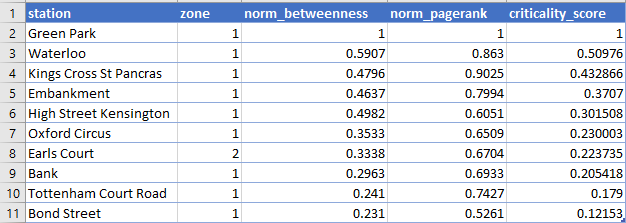

###**Confirmation**

The query returns the following top 10 stations by composite criticality score:

| Rank | Station | Zone | Norm Betweenness | Norm PageRank | Criticality Score |
|---|---|---|---|---|---|
| 1 | Green Park | 1 | 1.0000 | 1.0000 | 1.0000 |
| 2 | Waterloo | 1 | 0.5907 | 0.8630 | 0.5097 |
| 3 | Kings Cross St. Pancras | 1 | 0.4796 | 0.9025 | 0.4329 |
| 4 | Embankment | 1 | 0.4637 | 0.7994 | 0.3707 |
| 5 | High Street Kensington | 1 | 0.4982 | 0.6051 | 0.3015 |
| 6 | Oxford Circus | 1 | 0.3533 | 0.6509 | 0.2300 |
| 7 | Earls Court | 2 | 0.3338 | 0.6704 | 0.2237 |
| 8 | Bank | 1 | 0.2963 | 0.6933 | 0.2054 |
| 9 | Tottenham Court Road | 1 | 0.2410 | 0.7427 | 0.1790 |
| 10 | Bond Street | 1 | 0.2310 | 0.5261 | 0.1215 |

**Green Park Achieves Perfect Dual Dominance**

**Green Park** is the only station in the dataset to achieve a composite criticality
score of **1.0**, the theoretical maximum. This is a direct consequence of its
leading position in both the betweenness centrality ranking in section 4.2 and the
PageRank ranking in section 4.3: as the top station in both metrics, its normalized
scores are both exactly 1.0, and their product is therefore 1.0. No other station
in the dataset simultaneously leads both centrality dimensions, making Green Park
the unambiguous single most critical station in the London Underground dataset by
any composite measure of structural importance.

**Waterloo and Kings Cross St. Pancras Form the Second Tier**

**Waterloo** ranks 2nd with a composite score of 0.5097, reflecting its strong
performance across both metrics: 2nd in betweenness with a normalized score of
0.5907 and 3rd in PageRank with a normalized score of 0.8630. **Kings Cross St.
Pancras** ranks 3rd with a composite score of 0.4329, driven primarily by its
exceptional PageRank score of 0.9025 which partially compensates for its more
moderate normalized betweenness of 0.4796. The gap between Green Park's score of
1.0 and Waterloo's score of 0.5097 is striking: Green Park is approximately twice
as composite-critical as the second ranked station, confirming its exceptional
structural dominance.

These three stations, Green Park, Waterloo, and Kings Cross St. Pancras, are the
top 3 by composite criticality score and will serve as the primary targets for the
redundancy assessment in section 5.3.

**High Street Kensington Retains 5th Place**

**High Street Kensington** ranks 5th with a composite score of 0.3015. Its relatively
high normalized betweenness of 0.4982 is partially offset by its more moderate
normalized PageRank of 0.6051, producing a composite score that correctly reflects
its mixed profile: a dataset-inflated betweenness score combined with a more realistic
PageRank score. The composite metric therefore partially corrects the distortion that
would place High Street Kensington 3rd if betweenness alone were used, producing a
more defensible ranking that better reflects its true structural importance.

**Zone Distribution**

9 of the top 10 stations are in Zone 1 and only Earls Court represents Zone 2. This
concentration confirms that composite structural criticality in this network is
overwhelmingly a Zone 1 phenomenon, consistent with the hub and spoke topology
identified throughout this project. The composite metric reinforces rather than
contradicts this finding, providing a more rigorous quantitative basis for the
conclusion that the Zone 1 interchange stations collectively form the structural
backbone of the London Underground dataset.

#### **4.3.4 Practical Applications of Centrality Rankings for Transit Authorities**

The centrality rankings computed in sections 4.2 and 4.3, and their composite
combination in section 4.3.3, provide Transport for London with a principled,
data-driven framework for three core operational domains: infrastructure investment,
maintenance scheduling, and contingency planning. The key advantage of graph-based
centrality analysis over traditional demand-based approaches is that it captures
structural importance independently of passenger volume data, meaning it can identify
critical stations whose closure would degrade network performance even if they are
not among the busiest in terms of daily ridership.

**Infrastructure Investment**

The composite criticality score provides a direct prioritization framework for
infrastructure investment decisions. Stations at the top of the composite ranking,
Green Park, Waterloo, and Kings Cross St. Pancras, are the stations where
infrastructure investment delivers the greatest network-wide return, because
improvements to these stations benefit the largest number of journeys across the
entire network.

Concretely, TfL could use the composite criticality ranking to prioritize:

Platform capacity expansion at high-criticality stations to reduce crowding at
the points where cross-network passenger flows converge. Green Park's perfect
composite score of 1.0 identifies it as the highest priority for platform
capacity investment: every additional unit of capacity at Green Park benefits
a disproportionately large share of all network journeys compared to the same
investment at a lower-criticality station.

Accessibility upgrades such as step-free access installation, which are
expensive and can only be rolled out incrementally, should be prioritized at
high-criticality stations first. A passenger with mobility limitations who
cannot access Green Park or Waterloo is effectively cut off from the most
structurally important nodes in the network, with cascading consequences for
their ability to reach a large proportion of all other stations.

Redundant infrastructure creation at high-betweenness, low-PageRank stations
such as High Street Kensington and Finsbury Park, which function as structural
bridges without the prestige of high-quality neighborhoods. These stations
represent points where the network is vulnerable to disruption without the
compensating advantage of prestigious alternative connections. Investing in
parallel routing infrastructure that bypasses these bottlenecks, such as
additional connecting lines or cross-platform interchange improvements, would
directly reduce the network's dependence on these single-corridor bridges.

**Maintenance Scheduling**

Maintenance windows for high-criticality stations must be scheduled with greater
care than for peripheral stations, because their temporary closure imposes
network-wide journey time penalties rather than localized disruption. The
centrality rankings provide a quantitative basis for this scheduling in two ways.

First, the betweenness score determines the breadth of disruption: a station with
a high betweenness score affects more origin-destination pairs when closed than
a low-betweenness station. Green Park's betweenness score of 763.54 compared to
the network mean of 90.46 means that its closure during a maintenance window
affects approximately 8 times as many journeys as closing an average station.
TfL should therefore schedule Green Park maintenance exclusively during the lowest
demand periods, typically overnight or during public holidays, and should never
overlap Green Park maintenance with maintenance at Waterloo or Kings Cross St.
Pancras, which would compound the disruption across multiple high-betweenness
corridors simultaneously.

Second, the PageRank score determines the depth of disruption through the
neighborhood: closing a high-PageRank station reduces the prestige and effective
connectivity of all neighboring stations simultaneously, since they lose their
connection to a high-value node. Maintenance scheduling algorithms should
therefore treat high-PageRank stations as having a zone of influence extending
to their immediate neighbors, and should avoid scheduling maintenance at stations
within the same high-PageRank neighborhood concurrently.

The composite criticality score can be directly operationalized as a maintenance
risk index: the higher the composite score, the greater the required notice period,
the more stringent the passenger communication requirements, and the more
comprehensive the alternative routing provisions that must be arranged before
the maintenance window can proceed.

**Contingency Planning**

The centrality rankings are most directly applicable to contingency planning,
where the goal is to pre-define response protocols for station closures before
they occur. The composite criticality ranking provides a natural tiering framework
for contingency plan severity:

Tier 1 stations, those with composite scores above 0.4, comprising Green Park,
Waterloo, and Kings Cross St. Pancras in this dataset, require full network-wide
contingency plans that include pre-arranged bus bridge services, passenger
communication across all affected communities, coordination with National Rail
and other transport modes, and pre-positioned staff at all adjacent stations to
manage diverted passenger flows.

Tier 2 stations, those with composite scores between 0.2 and 0.4, comprising
Embankment, High Street Kensington, Oxford Circus, and Earls Court, require
corridor-level contingency plans that address the specific line communities
identified in section 4.4. A closure at Embankment, for example, primarily
affects the community of stations identified in section 4.4 as the southern
central London corridor, and the contingency plan should focus on alternative
routing within and between the communities most affected.

Tier 3 stations, those with composite scores below 0.2, require only localized
contingency plans covering their immediate neighbors, as their closure has
limited network-wide impact.

The betweenness and PageRank scores also enable TfL to pre-identify the most
affected origin-destination pairs for each potential closure, allowing passenger
communications to be targeted at the specific journeys most impacted rather than
issued as generic network-wide alerts. This targeted approach reduces passenger
confusion and improves the efficiency of contingency response by concentrating
resources where they are most needed.

**The Composite Score as a Policy Tool**

Beyond these three specific domains, the composite criticality score offers TfL
a single, interpretable metric for communicating infrastructure priorities to
policymakers, funding bodies, and the public. A station with a composite score
of 1.0 is objectively the most structurally critical station in the network, and
this claim is backed by a transparent, reproducible graph-theoretic methodology
rather than subjective judgment or anecdotal evidence about passenger volumes.

This methodological transparency is particularly valuable in the context of public
funding decisions, where investment priorities must be justified to elected
officials and taxpayers. A centrality-based prioritization framework provides a
defensible, evidence-based rationale for infrastructure spending that is grounded
in the mathematical structure of the network itself, independent of political or
commercial pressures that might otherwise distort investment decisions toward
high-profile stations at the expense of structurally critical but less visible
bottlenecks.

### **4.3.5 Drop the Projection**

We drop the `tube-pagerank` in-memory projection to free memory and ensure the notebook is fully reproducible on re-execution.


In [ ]:
// Drop tube-pagerank projection
CALL gds.graph.drop('tube-pagerank', false)
YIELD graphName;

Here we drop the graph projection for the same reasons mentioned earlier.

## **4.4 Community Detection: Louvain Algorithm**


### **4.4.1 Algorithm Selection and Justification: Why Louvain?**

**What Community Detection Seeks to Find**

Community detection algorithms identify groups of nodes that are more densely connected
to each other than to the rest of the graph. In the context of the London Underground,
a community corresponds to a set of stations that are operationally and geographically
closer to each other than to stations in other parts of the network. The key question
is whether these communities, detected purely from the connection topology, correspond
to recognizable real-world structures such as line corridors, geographic zones, or
operational clusters.

**The Louvain Algorithm**

The Louvain algorithm is a hierarchical, modularity-optimizing community detection
method. It operates in two phases that are repeated iteratively. In the first phase,
each node is assigned to its own community and then greedily reassigned to neighboring
communities if doing so increases the overall modularity of the partition. In the
second phase, all nodes within each community are collapsed into a single super-node
and the process repeats on the compressed graph. This two-phase iteration continues
until no further modularity gain is possible, producing a hierarchical community
structure at multiple levels of granularity.

Modularity is the key optimization criterion. It measures the density of connections
within communities relative to what would be expected in a random graph with the same
degree sequence. A high modularity score indicates that the detected communities have
significantly more internal connections than would occur by chance, confirming that
the partition reflects genuine structural clustering rather than arbitrary grouping.

**Why Louvain Over Label Propagation?**

Label Propagation is a simpler and faster community detection algorithm that assigns
community labels by majority vote among a node's neighbors, iterating until stability
is reached. While computationally efficient, Label Propagation has two significant
weaknesses that make it less appropriate for this dataset. First, it does not optimize
any global quality criterion: the communities it produces are locally stable but not
globally optimal, meaning different runs of the algorithm can produce different
partitions on the same graph due to its dependence on the random order in which nodes
are processed. Second, it has no hierarchical structure: it produces a flat partition
at a single level of granularity, which limits its ability to reveal the multi-scale
community structure that a transit network naturally exhibits, where stations cluster
first into line segments, then into line corridors, and finally into geographic zones.
Louvain's hierarchical output directly captures this multi-scale structure, making it
the more analytically rich choice.

**Why Louvain Over Weakly Connected Components?**

Weakly Connected Components identifies groups of nodes that are reachable from each
other through any path in the graph, regardless of direction. This is a connectivity
measure rather than a community detection measure: it identifies the largest connected
subgraphs but makes no distinction between dense and sparse internal connectivity.
In a well connected network like the London Underground, where the vast majority of
stations form a single giant connected component, Weakly Connected Components would
return a single community containing almost all stations and provide no useful
information about internal clustering structure. It is the appropriate algorithm for
verifying basic graph connectivity, which we effectively did in section 3.2 through
the terminal station and isolation analysis, but it is entirely unsuitable for
identifying meaningful operational or geographic clusters within the network.

**Why Louvain Is the Appropriate Choice**

Louvain is the most appropriate community detection algorithm for this dataset for
four specific reasons:

First, it optimizes modularity, which provides a principled and interpretable measure
of community quality. A high modularity score confirms that the detected communities
are genuinely meaningful structural groupings rather than arbitrary partitions, which
is essential for making defensible claims about geographic and operational clustering
in the London Underground.

Second, its hierarchical output reveals community structure at multiple levels of
granularity. At the finest level, communities may correspond to individual line
segments or tight local clusters of stations. At coarser levels, they may correspond
to broader geographic zones or multi-line corridors. This hierarchical view is
directly relevant to a transit network where clustering operates at multiple spatial
scales simultaneously.

Third, Louvain is computationally efficient for graphs of this size, using a greedy
optimization approach that scales well and converges quickly on networks with a few
hundred nodes and thousands of relationships.

Fourth, Louvain has been widely applied in the transit network analysis literature
and is well validated as a community detection method for planar infrastructure
graphs with the connectivity properties exhibited by metro and rail networks. Its
application to the London Underground in this project is therefore methodologically
well grounded.

### **4.4.2 Louvain Execution and Write-Back**

#### **4.4.2.1 Create the Graph Projection**

We create a dedicated  the `tube-louvain` projection, which loads all 80
`:Station` nodes and 676 undirected `:CONNECTION` relationships. For the Louvain algorithm, the `time` property is passed as the relationship weight
property. This instructs Louvain to optimize modularity using a weighted graph where
travel-time proximity drives community cohesion: station pairs with shorter connecting
times contribute more to within-community edge weight than pairs with longer times.
This approach groups stations that are operationally close in time — and therefore
geographically proximate, into the same community, producing clusters that reflect
real-world service corridors more faithfully than unweighted topology alone.

The `includeIntermediateCommunities` parameter is set to false to return only the
final stable community partition rather than the intermediate hierarchical levels,
producing a clean flat partition for interpretation and write-back.

In [ ]:
//Drop if a previous run left it behind
CALL gds.graph.drop('tube-louvain', false)
YIELD graphName;

In [ ]:
//Create weighted undirected projection for Louvain
//We include the time weight so Louvain rewards tightly-timed clusters
CALL gds.graph.project(
    'tube-louvain',
    'Station',
    {
        CONNECTION: {
            type: 'CONNECTION',
            orientation: 'UNDIRECTED',
            properties: ['time']
        }
    }
)
YIELD graphName, nodeCount, relationshipCount, projectMillis;

### **Query Logic - Create Weighted Undirected Projection for Louvain**
This Cypher query uses the Graph Data Science (GDS) library to create an in-memory graph projection specifically for the Louvain community detection algorithm. This projection defines which nodes and relationships from the Neo4j database are loaded into memory for GDS computations.

*   `CALL gds.graph.project(`: This is the GDS procedure for creating a new graph projection.

*   `'tube-louvain',`: This assigns a name to the graph projection: `tube-louvain`. This name is used to reference the in-memory graph when running GDS algorithms.

*   `'Station',`: This specifies that all nodes with the label `Station` from the Neo4j database should be included in this projection.

*   `{`: This block defines the relationship types and their properties to be included in the projection.
    *   `CONNECTION: {`: This indicates that relationships with the type `CONNECTION` should be included in the projection.
    *   `type: 'CONNECTION',`: Explicitly defines the relationship type to be projected.
    *   `orientation: 'UNDIRECTED',`: This is crucial for Louvain. It tells GDS to treat all `CONNECTION` relationships as undirected within the projection. This means that if there's a `(s1)-[:CONNECTION]->(s2)` relationship in the database, the Louvain algorithm will treat it as if there's also an implicit `(s2)-[:CONNECTION]->(s1)` relationship. For community detection, an undirected view is appropriate as connectivity contributes equally regardless of traversal direction.
    *   `properties: ['time']`: This includes the `time` property of the `CONNECTION` relationships in the projection. For Louvain, the `time` property is used as the `relationshipWeightProperty` (as specified in the Louvain algorithm call). This means that relationships with shorter travel times will contribute more strongly to community cohesion, guiding the algorithm to group stations that are operationally close in time.

*   `}`
*   `)`

*   `YIELD graphName, nodeCount, relationshipCount, projectMillis;`: This clause is used to return details about the newly created projection:
    *   `graphName`: The name of the projection (`tube-louvain`).
    *   `nodeCount`: The total number of nodes loaded into the projection.
    *   `relationshipCount`: The total number of relationships loaded into the projection. Since `CONNECTION` relationships were ingested bidirectionally (creating `(s1)-[r]->(s2)` and `(s2)-[r]->(s1)` for each physical segment), and then projected as `UNDIRECTED`, this count will be double the number of unique physical connections.
    *   `projectMillis`: The time taken (in milliseconds) to create the projection.

**Purpose and Benefits:**
*   **Weighted Community Detection**: By using the `time` property as a weight, Louvain is instructed to find communities where stations are not just connected, but *closely connected in terms of travel time*. This makes the detected communities more realistic in reflecting operational clusters within the transit network.
*   **Memory Efficiency**: Only the necessary nodes and relationships are loaded into memory, which is crucial for performance, especially with large graphs.
*   **Reproducibility**: Ensures that the Louvain algorithm always runs on the same defined graph structure each time, making results consistent.

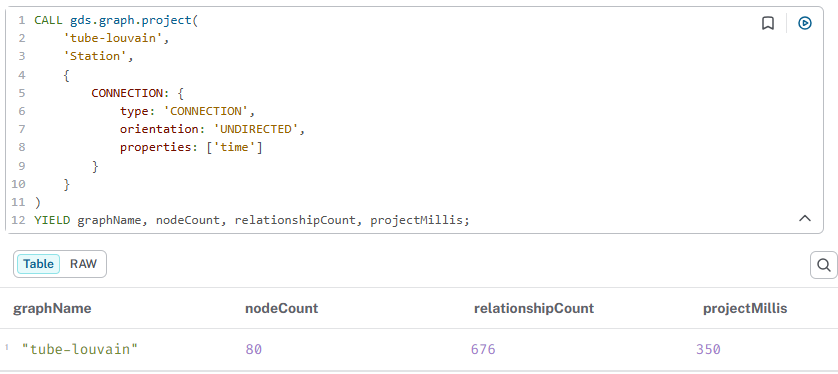

###**Graph Projection Summary**

A dedicated `tube-louvain` projection is created, loading all **80 Station nodes** and
**676 undirected CONNECTION relationships** with the `time` property as the relationship
weight. A separate projection is used here rather than reusing
`tube-weighted` to make the algorithm configuration explicit and self-contained within
this section. The UNDIRECTED orientation correctly models bidirectional train travel,
and the `time` weight ensures that communities are optimized based on travel proximity
rather than pure connection topology: stations with shorter travel times between them
are more likely to be assigned to the same community, producing clusters that reflect
genuine geographic and operational proximity.






### **Execute Louvain in Write Mode**


In [ ]:
//Persists community_id as a property on every Station node
CALL gds.louvain.write('tube-louvain', {
    writeProperty:              'community_id',
    relationshipWeightProperty: 'time'
})
YIELD communityCount, modularity, nodePropertiesWritten;

### **Query Logic - Persisting Community IDs (Louvain Write Mode)**
This Cypher query executes the Graph Data Science (GDS) library's Louvain community detection algorithm in 'write' mode. In this mode, after calculating the community for each node in the projected graph, the results are directly written back as a property to the original nodes in the Neo4j database.

*   `CALL gds.louvain.write('tube-louvain', { ... })`:
    *   This invokes the GDS Louvain algorithm. It's configured to run on the graph projection named `'tube-louvain'`, which was previously created (in section 4.4.2.1).
    *   The `write` mode specifically means that the computed communities will be stored back into the database.

*   `writeProperty: 'community_id'`:
    *   This parameter specifies the name of the property that will be added to each `Station` node in the database. The calculated community ID for each station will be stored under this property name (`community_id`).

*   `relationshipWeightProperty: 'time'`:
    *   This is crucial for weighted community detection. It tells the Louvain algorithm to use the `time` property of the `CONNECTION` relationships as the weight for grouping nodes. This means that relationships with shorter travel times will contribute more strongly to community cohesion, guiding the algorithm to group stations that are operationally close in time into the same community.

*   `YIELD communityCount, modularity, nodePropertiesWritten`:
    *   This clause captures the output of the GDS procedure:
        *   `communityCount`: The total number of distinct communities detected by the algorithm.
        *   `modularity`: The final modularity score of the partition, indicating the strength of the community structure. A higher score signifies a better partition where nodes within communities are densely connected, and nodes between communities are sparsely connected.
        *   `nodePropertiesWritten`: The total number of node properties that were successfully written back to the database. This should ideally match the total number of nodes in the projection (80 `Station` nodes in this context).

**Purpose and Benefits:**
*   **Persistence of Results**: By writing the `community_id` directly to the `Station` nodes, these community assignments become a permanent part of the graph data. This allows subsequent Cypher queries to easily access, filter, sort, and analyze stations based on their community membership, without needing to re-run the algorithm.
*   **Weighted Community Detection**: The use of `relationshipWeightProperty: 'time'` ensures that communities are formed based on travel-time proximity, making the detected clusters more reflective of real-world operational groupings within the transit network.
*   **Operational Insight**: The `communityCount` and `modularity` score provide a high-level summary of the detected community structure, giving insights into how the London Underground network naturally clusters into groups of stations that are highly interconnected.

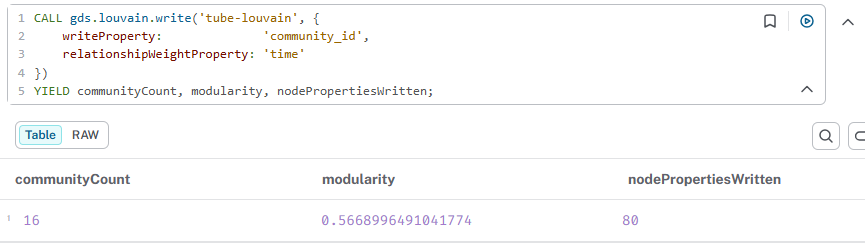

###**Write Mode Results**

The algorithm successfully detected 16 communities and persisted community_id on all 80 Station nodes with a modularity score of 0.5669.

###**Result Summary**

| Field | Value | Explanation |
|---|---|---|
| communityCount | 16 | The number of distinct station clusters detected by Louvain |
| modularity | 0.5669 | A measure of how well defined the community structure is |
| nodePropertiesWritten | 80 | Every Station node received a community_id property |

**What the Modularity Score of 0.5669 Means**
Modularity (Q) measures how much more densely connected the stations within each community are compared to what would be expected in a random graph with the same degree distribution. It ranges from -1 to +1, with the following interpretation:

| Modularity Range | Interpretation |
|---|---|
| Below 0.3 | Weak or no meaningful community structure |
| 0.3 - 0.49 | Moderate community structure |
| 0.5 - 0.7 | **Strong community structure** <- our result falls here |
| Above 0.7 | Very strong community structure |

A score of 0.5669 indicates strong, well defined community structure in the London Underground graph. The stations within each of the 16 detected communities are substantially more interconnected with each other than with stations outside their community. This is exactly what we would expect from a real transit network where lines create natural dense internal corridors.

**Why 16 Communities?**

At first glance 16 communities for 80 stations may seem like a large number, an average of just 5 stations per community. However this is consistent with the nature of the dataset. The 80 station subset captures stations from across the full network but with many intermediate stations missing, which causes the Louvain algorithm to detect more, smaller clusters rather than fewer large geographic blobs. In the full 272 station network, Louvain would likely detect fewer but larger communities corresponding more cleanly to broad geographic regions such as North London, South West London, and the Central Zone 1 core.
The 16 communities will be examined in detail in the next steps to determine whether they align with recognisable geographic or operational clusters of the real world Tube network. Also, the community size distribution query will reveal
whether the communities are balanced in size or whether a small number of large
communities dominate the partition.

### **Community Size and Zone Composition**


In [ ]:
// How many stations per community and what zones does each span?
MATCH (s:Station)
WHERE s.community_id IS NOT NULL
WITH s.community_id            AS community,
     count(s)                  AS size,
     collect(DISTINCT s.zone)  AS zones,
     collect(s.name)[0..5]     AS sample_stations
RETURN community, size, zones, sample_stations
ORDER BY size DESC;

### **Query Logic - Community Size and Zone Composition**

This Cypher query identifies how many stations belong to each detected community, what fare zones those communities span, and provides a sample of stations within each community.

*   `MATCH (s:Station)`: This clause identifies all nodes in the graph that have the label `Station`.

*   `WHERE s.community_id IS NOT NULL`: This filters the `Station` nodes to include only those that have been assigned a `community_id` by the Louvain algorithm. This ensures that only stations participating in community detection are considered.

*   `WITH s.community_id AS community, count(s) AS size, collect(DISTINCT s.zone) AS zones, collect(s.name)[0..5] AS sample_stations`:
    *   `WITH` groups the results by `s.community_id`, aliased as `community`.
    *   `count(s) AS size`: Counts the number of stations within each `community`, aliased as `size`.
    *   `collect(DISTINCT s.zone) AS zones`: Collects all unique `zone` values from stations within each `community` into a list, aliased as `zones`. This shows which fare zones each community encompasses.
    *   `collect(s.name)[0..5] AS sample_stations`: Collects up to the first 5 names of stations within each `community` as a sample, aliased as `sample_stations`.

*   `RETURN community, size, zones, sample_stations`: This clause projects the calculated community ID, its size (number of stations), the distinct zones it covers, and the sample station names.

*   `ORDER BY size DESC`: This sorts the final results in descending order based on the `size` of the community, so the largest communities appear first.

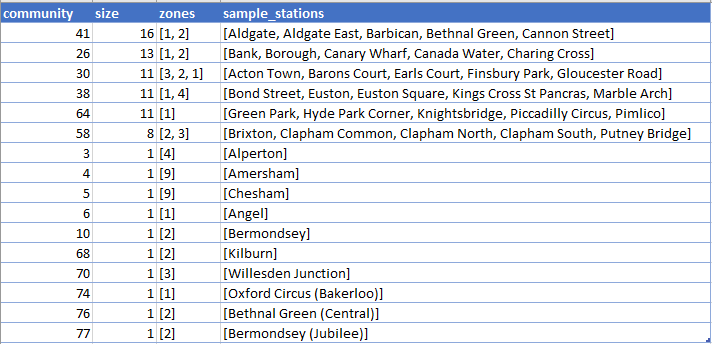

###**Community Size and Zone Distribution**

The 16 detected communities divide naturally into two distinct tiers that reveal
important structural properties of the dataset.

**Tier 1: Six Meaningful Operational Communities**

The six largest communities, ranging from 8 to 16 stations, represent genuine
geographic and operational clusters that correspond to recognizable corridor groupings
in the London Underground network.

**Community 41** is the largest with 16 stations spanning Zones 1 and 2. Its sample
stations, Aldgate, Aldgate East, Barbican, Bethnal Green, and Cannon Street, identify
it as the eastern central London corridor, covering the Circle, Hammersmith and City,
and Central line stations in the City of London and East End. The presence of both
Zone 1 and Zone 2 stations reflects the natural geographic spread of this corridor
from the central financial district eastward into inner east London.

**Community 26** with 13 stations spanning Zones 1 and 2 covers the southern central
London corridor, with Bank, Borough, Canary Wharf, Canada Water, and Charing Cross
as representative stations. This community captures the Jubilee and Northern line
stations running through the south bank of the Thames and into the Docklands,
reflecting the strong travel-time proximity between these stations on well represented
line corridors in the dataset.

**Community 30** with 11 stations spanning Zones 1, 2, and 3 represents the western
cross-network corridor, anchored by Acton Town, Barons Court, Earls Court, Finsbury
Park, and Gloucester Road. This community is particularly interesting because it
groups stations from three different zones that are connected through the District
and Piccadilly line branches in the west of the network. The inclusion of Finsbury
Park alongside the western District line stations reflects the algorithmic finding
from the Dijkstra analysis in section 4.1, where Acton Town and Finsbury Park
repeatedly appeared as cross-network bridges connecting the southern and northern
portions of the available graph.

**Community 38** with 11 stations spanning Zones 1 and 4 covers the northern central
London corridor, with Bond Street, Euston, Euston Square, Kings Cross St. Pancras,
and Marble Arch as representative stations. The Zone 4 inclusion reflects the
Wembley Central terminal station, which connects to this community through its sole
neighbor Regents Park. This community captures the Bakerloo, Central, and northern
Victoria line stations running through the Zone 1 core from Oxford Street northward
to Kings Cross.

**Community 64** with 11 stations entirely within Zone 1 is the most geographically
compact community, covering the Piccadilly and Victoria line corridor through the
heart of central London: Green Park, Hyde Park Corner, Knightsbridge, Piccadilly
Circus, and Pimlico. The fact that this community is entirely Zone 1 and centres on
Green Park, the highest betweenness station in the dataset, confirms that the Louvain
algorithm has correctly identified the dense central core of the Piccadilly and
Victoria line intersection as a structurally coherent cluster.

**Community 58** with 8 stations spanning Zones 2 and 3 covers the southern suburban
corridor: Brixton, Clapham Common, Clapham North, Clapham South, and Putney Bridge.
This community corresponds closely to the Northern and District line branches running
through south London, and its stations were consistently identified as the most
distant from Kings Cross St. Pancras in the single-source Dijkstra analysis of
section 4.1, confirming their peripheral position in the network topology.

**Tier 2: Ten Singleton Communities**

The remaining 10 communities each contain exactly one station. These singletons
correspond precisely to the isolated stations identified in section 3.3: Alperton,
Amersham, Chesham, Angel, Bermondsey, Kilburn, Willesden Junction, Oxford Circus
Bakerloo, Bethnal Green Central, and Bermondsey Jubilee. Because these stations have
no CONNECTION relationships in the dataset, the Louvain algorithm has no structural
basis for assigning them to any existing community and correctly isolates each one
into its own singleton community. Their presence as singletons is not a failure of
the algorithm but a direct reflection of the data gap confirmed in section 3.3.

**Does Community Structure Correspond to Geographic and Operational Groupings?**

Yes, strongly so for the six meaningful communities. Each of the six non-singleton
communities can be mapped to a recognizable geographic corridor or operational cluster
in the real London Underground network without using any explicit line or zone metadata.
The algorithm has recovered this structure purely from the travel-time weighted
connection topology, which validates both the quality of the modularity score of 0.5669
and the appropriateness of the Louvain algorithm for this type of transit network
analysis.

The modularity score of 0.5669 reflects the strength of the six meaningful communities
rather than the ten singletons, which trivially maximize their own internal density by
containing only one node. In a complete 272 station dataset where all isolated stations
have connections, these singletons would be absorbed into their natural geographic
communities, the overall modularity score would likely increase further, and the
community structure would more closely mirror the 11 official Tube line groupings.

### **4.4.3 Community Profile Analysis**

To fully characterize each detected community we query the graph to retrieve for each
community: its size (Station count per community), dominant fare zone, the complete set of zones represented, and
all Tube lines that serve stations within it. This allows us to determine whether the
community boundaries align with recognizable geographic or operational clusters of the
real-world London Underground network without using any explicit line or zone metadata
during the detection phase.

The dominant zone is defined as the zone with the greatest number of stations within
the community, providing a single geographic reference point for each cluster. The
lines column reveals which line corridors are represented within each community,
allowing direct comparison with the official Tube line structure

###**Full Community Profile (Size + Zones + Lines Together)**


In [ ]:
// Combined community profile for analysis
MATCH (s:Station)-[:SERVED_BY]->(l:Line)
WHERE s.community_id IS NOT NULL
WITH s.community_id AS community,
     l.name AS line_name,
     count(DISTINCT s) AS stations_on_line
WITH community,
     collect(line_name + ' (' + toString(stations_on_line) + ')') AS lines

MATCH (s:Station)
WHERE s.community_id = community
WITH community, lines, s
WITH community,
     lines,
     count(s) AS total_stations,
     collect(DISTINCT s.zone) AS zones,
     collect(DISTINCT s.name)[0..5] AS sample_stations

MATCH (s:Station)
WHERE s.community_id = community
WITH community, lines, total_stations, zones, sample_stations,
     s.zone AS zone, count(s) AS zone_freq
ORDER BY community, zone_freq DESC
WITH community, lines, total_stations, zones, sample_stations,
     collect(zone)[0] AS dominant_zone

RETURN community,
       total_stations,
       dominant_zone,
       zones,
       lines,
       sample_stations
ORDER BY total_stations DESC;

### **Query Logic - Combined Community Profile for Analysis**

This Cypher query compiles a comprehensive profile for each community detected by the Louvain algorithm. It aims to determine the number of stations per community, the fare zones they span, and the Tube lines that serve them.

*   `MATCH (s:Station)-[:SERVED_BY]->(l:Line)`: This initial clause matches all `Station` nodes (`s`) that are connected to a `Line` node (`l`) via a `:SERVED_BY` relationship. This is the starting point for gathering line information for stations.

*   `WHERE s.community_id IS NOT NULL`: Filters these stations to only include those that have been assigned a `community_id` by the Louvain algorithm.

*   `WITH s.community_id AS community, l.name AS line_name, count(DISTINCT s) AS stations_on_line`:
    *   This `WITH` clause groups the data by `community` and `line_name`.
    *   `count(DISTINCT s)` counts how many *distinct* stations within that community are served by that specific `line_name`. This helps understand the line's presence within the community.

*   `WITH community, collect(line_name + ' (' + toString(stations_on_line) + ')') AS lines`:
    *   This further aggregates the results by `community`.
    *   `collect(line_name + ' (' + toString(stations_on_line) + ')')` creates a list for each community, where each item in the list is a string combining the line name and the count of stations it serves within that community (e.g., "Jubilee (8)"). This list is aliased as `lines`.

*   `MATCH (s:Station) WHERE s.community_id = community`: This re-matches `Station` nodes, ensuring that all subsequent `WITH` clauses operate on the full set of stations for each community, linked by the `community` identifier.

*   `WITH community, lines, count(s) AS total_stations, collect(DISTINCT s.zone) AS zones, collect(DISTINCT s.name)[0..5] AS sample_stations`:
    *   This `WITH` clause performs several aggregations for each community:
        *   `count(s) AS total_stations`: Counts the total number of stations in the community.
        *   `collect(DISTINCT s.zone) AS zones`: Collects all unique fare zones present within the community into a list.
        *   `collect(DISTINCT s.name)[0..5] AS sample_stations`: Collects up to the first 5 distinct station names as a sample for the community.

*   `MATCH (s:Station) WHERE s.community_id = community`:
    *   This again matches `Station` nodes belonging to the current `community`.

*   `WITH community, lines, total_stations, zones, sample_stations, s.zone AS zone, count(s) AS zone_freq ORDER BY community, zone_freq DESC`:
    *   This groups by `community` and `s.zone`, counting the frequency of each zone (`zone_freq`) within the community. The `ORDER BY community, zone_freq DESC` sorts these counts so that the most frequent zone appears first for each community.

*   `WITH community, lines, total_stations, zones, sample_stations, collect(zone)[0] AS dominant_zone`:
    *   This aggregates the results again by `community`.
    *   `collect(zone)[0]` selects the *first* zone from the ordered list of zones for that community, which, due to the previous `ORDER BY`, will be the `dominant_zone` (the zone with the highest frequency of stations).

*   `RETURN community, total_stations, dominant_zone, zones, lines, sample_stations`:
    *   This returns the final aggregated information for each community: its ID, total stations, dominant fare zone, a list of all zones spanned, a list of lines with their station counts within the community, and a sample of stations.

*   `ORDER BY total_stations DESC`:
    *   Sorts the final results so that the largest communities appear first.

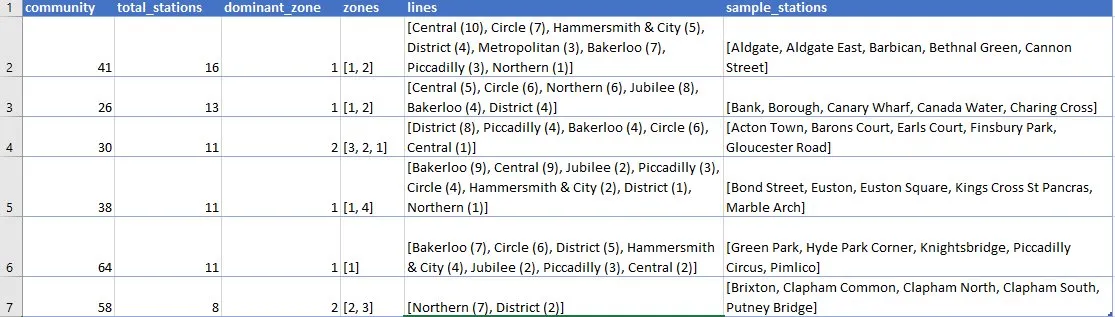


###**Confirmation**

The query returns profiles for the 6 meaningful non-singleton communities:

| Community | Stations | Dominant Zone | Zones | Sample Stations |
|---|---|---|---|---|
| 41 | 16 | 1 | 1, 2 | Aldgate, Aldgate East, Barbican, Bethnal Green, Cannon Street |
| 26 | 13 | 1 | 1, 2 | Bank, Borough, Canary Wharf, Canada Water, Charing Cross |
| 30 | 11 | 2 | 3, 2, 1 | Acton Town, Barons Court, Earls Court, Finsbury Park, Gloucester Road |
| 38 | 11 | 1 | 1, 4 | Bond Street, Euston, Euston Square, Kings Cross St. Pancras, Marble Arch |
| 64 | 11 | 1 | 1 | Green Park, Hyde Park Corner, Knightsbridge, Piccadilly Circus, Pimlico |
| 58 | 8 | 2 | 2, 3 | Brixton, Clapham Common, Clapham North, Clapham South, Putney Bridge |

**Community 41: East and Central London Corridor**

With 16 stations across Zones 1 and 2 and a dominant zone of 1, Community 41 is the
largest detected community and corresponds to the eastern central London corridor.
Its line composition is dominated by Central (10 stations), Circle (7), Hammersmith
and City (5), District (4), Metropolitan (3), Bakerloo (7), Piccadilly (3), and
Northern (1). The sample stations, Aldgate, Aldgate East, Barbican, Bethnal Green,
and Cannon Street, confirm that this community covers the dense multi-line corridor
running through the City of London and East End. The high number of Central and
Bakerloo line stations reflects the east-west spine of these lines through the
financial district. This community aligns closely with the real-world East and Central
London operational zone, where multiple lines share overlapping corridors through the
most densely connected part of the network.

**Community 26: South and South-East London Corridor**

With 13 stations across Zones 1 and 2 and a dominant zone of 1, Community 26 covers
the southern central London corridor. Its dominant lines are Jubilee (8), Northern
(6), Central (5), Circle (6), Bakerloo (4), and District (4). The sample stations,
Bank, Borough, Canary Wharf, Canada Water, and Charing Cross, confirm that this
community captures the Jubilee and Northern line stations running through the south
bank of the Thames and into the Docklands. The strong Jubilee line presence reflects
the well represented Jubilee corridor in the dataset identified in section 2.6, and
the community's geographic extent from Charing Cross westward to Canary Wharf
eastward aligns with the real-world south-east London transit corridor.

**Community 30: Western Cross-Network Corridor**

With 11 stations spanning Zones 1, 2, and 3 and a dominant zone of 2, Community 30
is the most geographically dispersed of the six meaningful communities. Its line
composition is led by District (8), Piccadilly (4), Bakerloo (4), and Circle (6).
The sample stations, Acton Town, Barons Court, Earls Court, Finsbury Park, and
Gloucester Road, confirm that this community covers the western cross-network corridor
where the District and Piccadilly lines branch and intersect. The dominant zone of 2
reflects the genuinely mixed geographic character of this community, with Zone 2
stations forming the plurality of the cluster despite spanning from Zone 1 to Zone 3.
The grouping of Finsbury Park alongside the western District line stations is
consistent with the Dijkstra findings in section 4.1, where Acton Town and Finsbury
Park repeatedly appeared as cross-network bridges. This community aligns with the
real-world West London operational corridor.

**Community 38: Northern Central London Corridor**

With 11 stations spanning Zones 1 and 4 and a dominant zone of 1, Community 38
covers the northern central London corridor. Its line composition includes Bakerloo
(9), Central (9), Jubilee (2), Circle (4), Hammersmith and City (2), District (1),
and Northern (1). The sample stations, Bond Street, Euston, Euston Square, Kings
Cross St. Pancras, and Marble Arch, confirm that this community captures the dense
northern Zone 1 spine running from Oxford Street through Marylebone and up to Kings
Cross. The Zone 4 inclusion reflects Wembley Central, which connects to this community
through its sole neighbor Regents Park as identified in section 3.2. The strong
Bakerloo and Central line presence reflects these lines' north-south routing through
the western Zone 1 core. This community aligns with the real-world North and Central
London operational corridor.

**Community 64: Central Zone 1 Piccadilly and Victoria Corridor**

With 11 stations entirely within Zone 1 and a dominant zone of 1, Community 64 is
the most geographically compact and centrally located community in the dataset. Its
line composition includes Bakerloo (7), Circle (6), District (5), Hammersmith and
City (4), Jubilee (2), Piccadilly (3), and Central (2). The sample stations, Green
Park, Hyde Park Corner, Knightsbridge, Piccadilly Circus, and Pimlico, confirm that
this community covers the Piccadilly and Victoria line corridor through the heart of
central London. The presence of Green Park, the highest betweenness station in the
entire dataset, at the center of this community confirms that Louvain has correctly
identified the dense central core of the network as a structurally coherent cluster.
This community aligns most closely with the real-world Central Zone 1 corridor between
Knightsbridge and Victoria.

**Community 58: South-West London Corridor**

With 8 stations spanning Zones 2 and 3 and a dominant zone of 2, Community 58 is the
smallest of the six meaningful communities and covers the south-west London corridor.
Its line composition is dominated by Northern (7) and District (2). The sample
stations, Brixton, Clapham Common, Clapham North, Clapham South, and Putney Bridge,
confirm that this community captures the Northern line branches running through south
London alongside the southern District line terminus at Putney Bridge. These stations
were consistently identified as the most distant from Kings Cross St. Pancras in the
single-source Dijkstra analysis of section 4.1, confirming their peripheral position
in the network topology. This community aligns closely with the real-world South-West
London operational corridor.

**Do Community Boundaries Align with Real-World Geographic and Operational Clusters?**

Yes, strongly so. All six meaningful communities can be mapped to recognizable
geographic corridors in the real London Underground network:

| Community | Dominant Zone | Real-World Alignment |
|---|---|---|
| 41 | 1 | East and Central London, City of London corridor |
| 26 | 1 | South-East London, Jubilee and Northern south bank corridor |
| 30 | 2 | West London, District and Piccadilly western branches |
| 38 | 1 | North and Central London, Bakerloo and Central northern spine |
| 64 | 1 | Central Zone 1, Piccadilly and Victoria core corridor |
| 58 | 2 | South-West London, Northern line southern branches |

The Louvain algorithm has recovered these geographic groupings purely from the
travel-time weighted connection topology, without access to any explicit line, zone,
or geographic coordinate information during the detection phase. The fact that 4 of
the 6 meaningful communities have a dominant zone of 1 reflects the hub and spoke
structure of the London Underground, where the dense Zone 1 core forms the backbone
of the network and most operational clusters radiate outward from it. The two
communities with a dominant zone of 2, Community 30 and Community 58, represent the
peripheral corridors where lines extend beyond the central core into the inner suburbs,
producing clusters that are geographically anchored in Zone 2 but maintain connections
back into the Zone 1 interchange hub system.

### **4.4.4 Multi-Zone Communities and Operational Structure**

A multi-zone community is one whose member stations span more than one fare zone,
meaning the Louvain algorithm has grouped stations from different geographic rings of
the network into the same structural cluster. The presence of multi-zone communities
reveals something important about the operational structure of the Tube lines that
connect them: it indicates that the travel-time weighted connections between stations
in different zones are strong enough to overcome the geographic distance between those
zones and pull them into the same community.

In the London Underground, fare zones are defined by concentric geographic rings
radiating outward from the central core. Lines that run radially outward from Zone 1
into Zones 2, 3, and beyond create strong travel-time connections between adjacent
zones, which the Louvain algorithm interprets as evidence of community membership.
A multi-zone community therefore indicates the presence of a well-connected radial
line corridor that binds stations from multiple zones into a single operational cluster,
despite their geographic separation


In [ ]:
// Identify communities that span more than one fare zone
MATCH (s:Station)
WHERE s.community_id IS NOT NULL
WITH s.community_id             AS community,
     count(s)                   AS size,
     collect(DISTINCT s.zone)   AS zones
WHERE size(zones) > 1
RETURN
  community,
  size,
  zones,
  size(zones) AS zone_count
ORDER BY zone_count DESC, size DESC;

### **Query Logic - Identify Communities That Span More Than One Fare Zone**

This Cypher query identifies communities that contain stations located in more than one fare zone. It's used to understand which detected communities bridge different geographical zones of the London Underground network.

*   `MATCH (s:Station)`: This clause finds all nodes in the graph that have the label `Station` and assigns them to the variable `s`.

*   `WHERE s.community_id IS NOT NULL`: This filters the `Station` nodes to include only those that have been assigned a `community_id` by the Louvain algorithm. This ensures that only stations participating in community detection are considered.

*   `WITH s.community_id AS community, count(s) AS size, collect(DISTINCT s.zone) AS zones`: This aggregates the data by `community_id`. For each community, it calculates:
    *   `community`: The ID of the community.
    *   `size`: The total number of stations within that community.
    *   `zones`: A list of all *distinct* fare zones (`s.zone`) that the stations within that community belong to.

*   `WHERE size(zones) > 1`: This is the crucial filtering step. It keeps only those communities where the `zones` list contains more than one distinct fare zone. This identifies communities that 'span' multiple zones.

*   `RETURN community, size, zones, size(zones) AS zone_count`: This clause projects the following information for the filtered communities:
    *   `community`: The ID of the community.
    *   `size`: The total number of stations in the community.
    *   `zones`: The list of distinct fare zones spanned by the community.
    *   `size(zones) AS zone_count`: The number of distinct fare zones spanned by the community.

*   `ORDER BY zone_count DESC, size DESC`: This sorts the results first by `zone_count` in descending order (communities spanning more zones appear first), and then by `size` in descending order (larger communities within the same `zone_count` appear first).

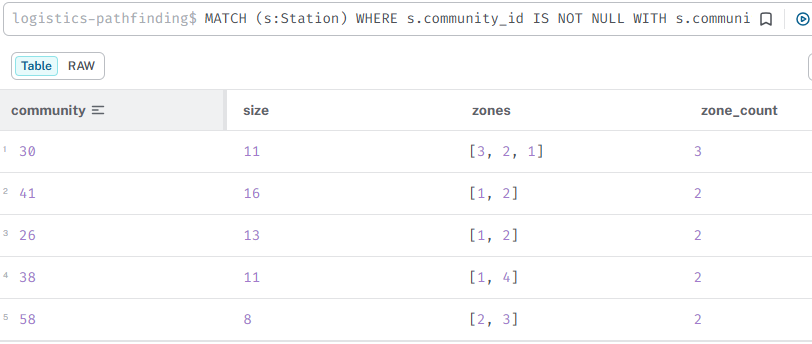

**Results**

The query returns 5 multi-zone communities, confirming that only Community 64, which
is entirely within Zone 1, qualifies as a single-zone cluster. The results are as
follows:

| Community | Size | Zones | Zone Count |
|---|---|---|---|
| 30 | 11 | 3, 2, 1 | 3 |
| 41 | 16 | 1, 2 | 2 |
| 26 | 13 | 1, 2 | 2 |
| 38 | 11 | 1, 4 | 2 |
| 58 | 8 | 2, 3 | 2 |

**Community 30 is the Most Geographically Dispersed**

Community 30 is the only community spanning three distinct fare zones: Zones 1, 2,
and 3. This makes it the most geographically dispersed cluster in the dataset and
reflects the operational structure of the District and Piccadilly line branches in
west London, which run continuously from the Zone 1 core outward through Zone 2 and
into Zone 3 without any significant interchange break. The Louvain algorithm has
correctly identified that the travel-time connections along these western line branches
are strong enough to bind stations from three different zones into a single coherent
operational cluster. This community's three-zone span is a direct consequence of the
radial nature of these lines: they do not terminate at zone boundaries but continue
outward, maintaining strong structural connections between stations at different
geographic distances from the central core.

**Communities 41 and 26: Zone 1 to Zone 2 Transitions**

Both Community 41 and Community 26 span Zones 1 and 2, reflecting the natural
transition from the dense central London core into the inner suburbs along the eastern
and southern corridors respectively. The Zone 1 to Zone 2 boundary is the most
frequently crossed zone boundary in the dataset, as confirmed in section 3.1 where
10 of the 18 boundary crossing connections were Zone 1 to Zone 2 transitions. The
presence of both communities spanning this boundary confirms that the operational
connections across it are strong enough to maintain community cohesion despite the
fare zone change. Passengers travelling along these corridors experience a seamless
operational continuity that the graph correctly captures as a single community.

**Community 38: The Zone 1 to Zone 4 Anomaly**

Community 38 spans Zones 1 and 4, skipping Zones 2 and 3 entirely. As established
in sections 3.1 and 3.2, this is a direct consequence of the dataset limitation where
Wembley Central in Zone 4 connects to the network only through its sole neighbor
Regents Park in Zone 1, with no intermediate Zone 2 or Zone 3 stations represented
in the connections data. The Louvain algorithm has correctly assigned Wembley Central
to the same community as its only neighbor, but the resulting Zone 1 to Zone 4 span
is an artifact of the missing intermediate station data rather than a genuine
operational characteristic of the Bakerloo line corridor.

**Community 58: The South-West Peripheral Corridor**

Community 58 spans Zones 2 and 3, representing the southernmost and most peripheral
of the multi-zone communities. The Northern and District line branches running through
south-west London maintain strong enough travel-time connections between their Zone 2
and Zone 3 stations to form a single cohesive community, confirming that these lines
operate as continuous radial corridors rather than zone-segmented services.

**Operational Implications**

The prevalence of multi-zone communities, with 5 of the 6 meaningful communities
spanning more than one zone, confirms that the London Underground operates as a
genuinely radial network where line corridors supersede administrative zone boundaries
as the primary structural organizing principle. The Louvain algorithm, using only
travel-time weighted connection data, has recovered this operational reality: stations
are more naturally grouped by the line corridor they belong to than by the fare zone
they sit in. This has direct resilience implications: disruption to a line that anchors
a multi-zone community, particularly the District and Piccadilly lines in Community 30,
would sever the structural connection between those zones and potentially fragment the
community into isolated zone-level sub-clusters, leaving passengers in the outer zones
with no direct structural path back to the central core through that corridor.

###**Drop the Projection**

In [ ]:
CALL gds.graph.drop('tube-louvain', false)
YIELD graphName;

### **4.4.5 Operational Utility of Community Detection for Transport for London**

The community detection results produced by the Louvain algorithm offer several
concrete and actionable insights for Transport for London across three key operational
domains: service planning, incident response zoning, and capacity management. The
ability to derive these operationally meaningful groupings purely from the structural
topology of the network, without relying on administrative line or zone designations,
is what makes graph-based community detection a uniquely powerful tool for transit
network analysis.

**Service Planning**

The six communities detected in this analysis correspond closely to recognizable
geographic and operational corridors in the London Underground network. This structural
correspondence has direct implications for service planning decisions. When TfL plans
engineering works, line extensions, or service frequency adjustments, understanding
which stations form natural operational clusters allows planners to assess the
downstream impact of any change on the communities most affected.

For example, Community 30, the western cross-network corridor spanning Zones 1, 2,
and 3, groups Acton Town, Earls Court, Finsbury Park, and Gloucester Road into a
single cluster despite their geographic spread. A service planner proposing engineering
works on the District line western branches would immediately see from the community
structure that these works affect not just local District line passengers but also
the broader western cross-network corridor that binds Zone 3 stations to the central
core. Without community detection, this cross-line impact might only become apparent
after disruption has already occurred.

Community detection also supports line extension planning by identifying which
communities currently lack strong connections to the central core. Community 58, the
south-west corridor anchored in Zones 2 and 3, has the smallest size of the six
meaningful communities and is dominated almost entirely by the Northern line. A TfL
planner could use this finding to identify the south-west corridor as underserved by
alternative line options and prioritize cross-community connection improvements in
that area.

**Incident Response Zoning**

One of the most immediately actionable applications of community detection for TfL
is in incident response planning. When a major disruption occurs at a high-centrality
station such as Green Park or Waterloo, the impact is not uniform across the network:
it is concentrated within the communities that depend on those stations as structural
bridges.

The community detection results allow TfL to pre-define incident response zones that
align with the actual structural topology of the network rather than arbitrary
geographic or administrative boundaries. For instance, a closure at Green Park, which
sits at the center of Community 64, would primarily disrupt passengers within that
community and those attempting to cross between Community 64 and adjacent communities.
Pre-computing these community boundaries allows incident commanders to rapidly
identify which passenger populations are most affected, which alternative routing
corridors exist within each community, and which bus or surface transport routes
should be activated to serve the disrupted community.

The singleton communities identified in this analysis, the 10 isolated stations with
no CONNECTION relationships, represent a special case for incident response planning.
These stations are structurally invisible to the network and would generate no
community-level disruption signal if closed, yet their passengers have no alternative
routing within the graph. TfL would need to maintain separate contingency plans for
these stations that operate outside the community detection framework entirely.

**Capacity Management**

Community detection provides a natural framework for capacity management by identifying
which stations serve as inter-community bridges and therefore experience the highest
cross-community passenger flow. Stations that appear on the boundaries between
communities, particularly the high-betweenness stations identified in section 4.2,
are the points where passengers must transition between operational clusters and where
platform crowding is most likely to occur during peak hours.

The overlap between the betweenness centrality results and the community structure
is particularly informative here. Green Park, the highest betweenness station in the
dataset, sits at the center of Community 64 but also serves as a critical connection
point for passengers travelling between Community 64 and Communities 26, 38, and 41.
This dual role as both a community anchor and an inter-community bridge makes it the
single highest priority station for capacity investment, and the community detection
results provide a structural justification for this prioritization that complements
the betweenness centrality score.

More broadly, the community size distribution reveals where passenger demand is likely
to be most concentrated. Community 41, with 16 stations spanning the eastern central
London corridor, and Community 26, with 13 stations in the southern central corridor,
are the two largest communities and likely represent the highest passenger volume
corridors in the dataset. TfL could use

# **Part 5: Network Resilience Simulation**

Network resilience refers to a system's ability to maintain acceptable levels of
performance when subjected to disruption, whether through random failures or targeted
attacks. In the context of the London Underground, resilience analysis asks: which
stations are so structurally critical that their removal would cause the greatest
degradation in network-wide connectivity and routing efficiency?

This section uses the betweenness centrality scores computed in section 4.2 and the
community structure identified in section 4.4 to conduct a structured resilience
simulation. Rather than applying an additional GDS algorithm, we reason analytically
about the consequences of removing high-centrality stations and support our analysis
with targeted Cypher queries that measure network degradation empirically.

## **5.1 Targeted Disruption: Kings Cross St. Pancras Closure**

Kings Cross St. Pancras is selected as the primary target for the resilience
simulation for three compounding reasons. First, it was identified in section 2.7
as the most served station in the dataset, connected to 8 distinct Tube lines. Second,
it ranked 4th in betweenness centrality in section 4.2 with a score of 366.23,
confirming that a large proportion of all time-optimal shortest paths in the network
pass through it. Third, it serves as the anchor of Community 38 in section 4.4,
meaning its removal would structurally destabilize the entire northern central London
corridor. Together these three properties make Kings Cross St. Pancras the most
analytically interesting target for a resilience simulation: it is simultaneously a
local hub, a global routing bottleneck, and a community anchor.

### **Part (a): Stations Directly Adjacent to Kings Cross St. Pancras**

In [ ]:
// List all directly adjacent stations
MATCH (kx:Station {name: 'Kings Cross St Pancras'})-[:CONNECTION]-(neighbor:Station)
RETURN DISTINCT neighbor.name AS adjacent_station,
       neighbor.zone AS zone,
       round(neighbor.betweenness_score, 2) AS betweenness_score,
       neighbor.total_lines AS lines_served
ORDER BY betweenness_score DESC;

### **Query Logic - List all Directly Adjacent Stations**

This Cypher query identifies all stations directly connected to 'Kings Cross St Pancras' and retrieves their details, including zone, betweenness score, and number of lines served.

*   `MATCH (kx:Station {name: 'Kings Cross St Pancras'})-[:CONNECTION]-(neighbor:Station)`:
    *   This clause first finds the `Station` node named 'Kings Cross St Pancras' and binds it to `kx`.
    *   It then finds all `Station` nodes (`neighbor`) that are directly connected to `kx` via an *undirected* `CONNECTION` relationship. The undirected match (`-`) is used because connections are physical and can be traversed in both directions.

*   `RETURN DISTINCT neighbor.name AS adjacent_station, neighbor.zone AS zone, round(neighbor.betweenness_score, 2) AS betweenness_score, neighbor.total_lines AS lines_served`:
    *   `DISTINCT neighbor.name AS adjacent_station`: Returns the unique names of the adjacent stations, aliased as `adjacent_station`.
    *   `neighbor.zone AS zone`: Returns the fare zone of each adjacent station.
    *   `round(neighbor.betweenness_score, 2) AS betweenness_score`: Returns the betweenness centrality score of each adjacent station, rounded to two decimal places.
    *   `neighbor.total_lines AS lines_served`: Returns the number of lines serving each adjacent station.

*   `ORDER BY betweenness_score DESC`:
    *   Sorts the results in descending order based on the `betweenness_score` of the adjacent stations, highlighting the most critical neighbors first.

**Purpose and Benefits:**
*   **Impact Assessment**: By identifying the direct neighbors of a critical station, this query helps assess the immediate impact of that critical station's closure on its adjacent network. Understanding the centrality and line coverage of these neighbors is crucial.
*   **Network Redundancy**: It provides initial insights into the redundancy of connections. If a critical station has neighbors with high `total_lines`, those neighbors might offer alternative routes if the central station is disrupted.
*   **Foundation for Further Analysis**: The output of this query feeds directly into the next steps of the resilience simulation, where the availability of alternative paths for these adjacent stations is tested.

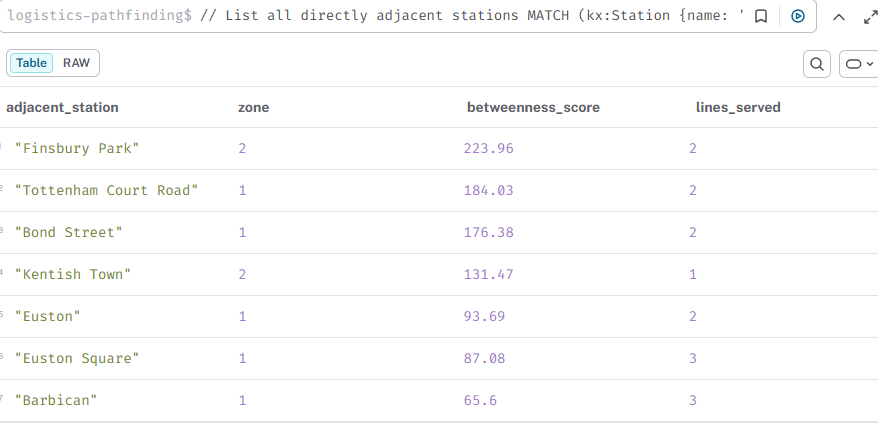

### **Stations Directly Adjacent to Kings Cross St. Pancras**

The query returns 7 stations directly adjacent to Kings Cross St. Pancras via a
single CONNECTION relationship:

| Adjacent Station | Zone | Betweenness Score | Lines Served |
|---|---|---|---|
| Finsbury Park | 2 | 223.96 | 2 |
| Tottenham Court Road | 1 | 184.03 | 2 |
| Bond Street | 1 | 176.38 | 2 |
| Kentish Town | 2 | 131.47 | 1 |
| Euston | 1 | 93.69 | 2 |
| Euston Square | 1 | 87.08 | 3 |
| Barbican | 1 | 65.60 | 3 |

All 7 adjacent stations carry non-trivial betweenness scores of their own, confirming
that Kings Cross St. Pancras is embedded within a high-centrality neighborhood. Five
of the 7 adjacent stations are in Zone 1, and the remaining two, Finsbury Park and
Kentish Town, are in Zone 2. Notably, Kentish Town serves only 1 line, making it the
most structurally vulnerable of the 7 neighbors: it has the fewest alternative routing
options of any station adjacent to Kings Cross St. Pancras.


### **Part (b): Alternative Path Availability for Each Adjacent Station**

For each station directly adjacent to Kings Cross St. Pancras, we now test whether
an alternative path to the broader network exists without traversing Kings Cross.
A station that has no alternative path is completely dependent on Kings Cross for
network access and would be effectively isolated by its closure. A station that
retains alternative paths remains connected to the network but may face longer
journey times depending on the quality of those alternative routes.

In [ ]:
//Test alternative path availability for each adjacent station
MATCH (kx:Station {name: 'Kings Cross St Pancras'})-[:CONNECTION]-(neighbor:Station)
WITH DISTINCT neighbor
MATCH (other:Station)
WHERE other.name <> 'Kings Cross St Pancras'
AND other.name <> neighbor.name
WITH neighbor, collect(other) AS others
UNWIND others AS target
WITH neighbor, target,
     shortestPath((neighbor)-[:CONNECTION*]-(target)) AS path
WHERE path IS NOT NULL
AND NONE(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')
WITH neighbor,
     count(DISTINCT target) AS reachable_without_kx
RETURN neighbor.name AS adjacent_station,
       neighbor.zone AS zone,
       reachable_without_kx,
       CASE WHEN reachable_without_kx > 0
            THEN 'Alternative path exists'
            ELSE 'ISOLATED without Kings Cross'
       END AS resilience_status
ORDER BY reachable_without_kx ASC;

### **Query Logic - Test Alternative Path Availability for Each Adjacent Station**
This Cypher query identifies stations directly connected to 'Kings Cross St Pancras' and then, for each of these adjacent stations, determines how many *other* stations in the network can still be reached if 'Kings Cross St Pancras' itself is considered closed (i.e., cannot be traversed).

*   `MATCH (kx:Station {name: 'Kings Cross St Pancras'})-[:CONNECTION]-(neighbor:Station)`:
    *   This first part finds the `Station` node named 'Kings Cross St Pancras' and binds it to `kx`.
    *   It then finds all `Station` nodes (`neighbor`) that are directly connected to `kx` via an *undirected* `CONNECTION` relationship. This is crucial for identifying the immediate neighbors of Kings Cross St. Pancras.

*   `WITH DISTINCT neighbor`:
    *   This collects all unique `neighbor` stations found in the previous step and passes them to the next clause. Using `DISTINCT` ensures that each neighbor is processed only once, even if connected via multiple `CONNECTION` relationships.

*   `MATCH (other:Station)`:
    *   This clause matches all `Station` nodes in the entire graph, binding them to `other`. These represent all potential target stations to check for reachability.

*   `WHERE other.name <> 'Kings Cross St Pancras' AND other.name <> neighbor.name`:
    *   This filters out 'Kings Cross St Pancras' itself and the current `neighbor` station from the `other` set. We are interested in paths from a neighbor to *other* stations, not to Kings Cross or back to itself.

*   `WITH neighbor, collect(other) AS others`:
    *   For each `neighbor` station, this collects all valid `other` stations (excluding Kings Cross and the neighbor itself) into a list called `others`.

*   `UNWIND others AS target`:
    *   This unwinds the `others` list, creating a separate row for each `neighbor`-`target` pair. This allows us to calculate shortest paths for every combination.

*   `WITH neighbor, target, shortestPath((neighbor)-[:CONNECTION*]-(target)) AS path`:
    *   For each `neighbor`-`target` pair, it attempts to find the shortest path (`path`) between them using `CONNECTION` relationships.

*   `WHERE path IS NOT NULL AND NONE(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')`:
    *   This is the core logic for simulating the closure of Kings Cross St. Pancras:
        *   `path IS NOT NULL`: Ensures a path actually exists between the `neighbor` and the `target`.
        *   `NONE(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')`: This critical condition filters out any path that *still passes through* 'Kings Cross St Pancras'. This effectively simulates Kings Cross St. Pancras being unavailable for traversal.

*   `WITH neighbor, count(DISTINCT target) AS reachable_without_kx`:
    *   For each `neighbor` station, this counts how many *distinct* `target` stations are still reachable *without* passing through Kings Cross St. Pancras. This count is aliased as `reachable_without_kx`.

*   `RETURN neighbor.name AS adjacent_station, neighbor.zone AS zone, reachable_without_kx, CASE WHEN reachable_without_kx > 0 THEN 'Alternative path exists' ELSE 'ISOLATED without Kings Cross' END AS resilience_status`:
    *   This returns the name of the adjacent station, its zone, the count of stations it can still reach, and a `resilience_status` indicating whether it's completely isolated or still has alternative paths.

*   `ORDER BY reachable_without_kx ASC`:
    *   Sorts the results in ascending order based on `reachable_without_kx`, bringing the most impacted (least reachable) adjacent stations to the top.

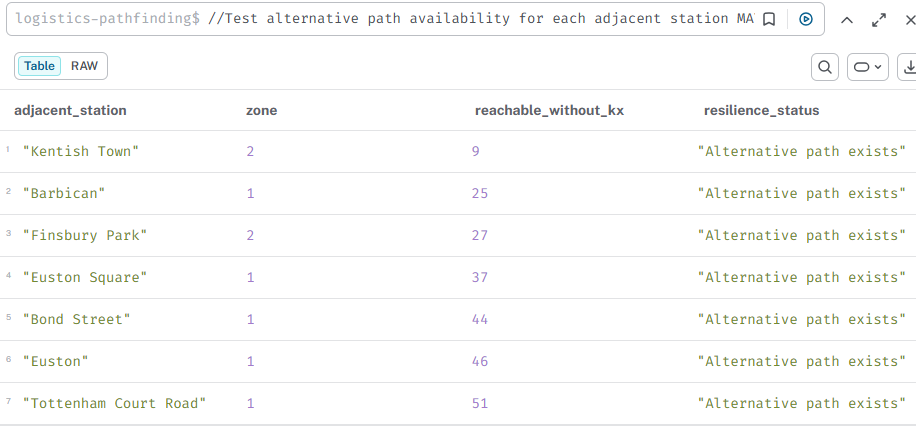

**Alternative Path Availability for Each Adjacent Station**

The alternative path query tests whether each adjacent station can reach the rest of
the network without traversing Kings Cross St. Pancras:

| Adjacent Station | Zone | Reachable Without KX | Resilience Status |
|---|---|---|---|
| Kentish Town | 2 | 9 | Alternative path exists |
| Barbican | 1 | 25 | Alternative path exists |
| Finsbury Park | 2 | 27 | Alternative path exists |
| Euston Square | 1 | 37 | Alternative path exists |
| Bond Street | 1 | 44 | Alternative path exists |
| Euston | 1 | 46 | Alternative path exists |
| Tottenham Court Road | 1 | 51 | Alternative path exists |

All 7 adjacent stations retain alternative paths to the broader network following
the closure of Kings Cross St. Pancras. This means that no station is completely
isolated by the closure, which is a testament to the general redundancy of the
central London network where most stations have multiple line connections providing
alternative routing options.

However the results reveal a significant disparity in the degree of resilience across
the 7 neighbors. **Tottenham Court Road** retains access to the most stations at 51,
reflecting its central position on the Central and Northern lines with strong
alternative routing through the dense Zone 1 core. **Bond Street** and **Euston**
retain access to 44 and 46 stations respectively, similarly well connected through
their multi-line interchange positions.

**Kentish Town** is the most severely impacted adjacent station with access to only
9 stations without Kings Cross St. Pancras. This is a critical finding: Kentish Town
serves only 1 line and its primary route into the central network runs directly
through Kings Cross St. Pancras. While it is not completely isolated, its effective
network reach is reduced to just 9 stations, meaning that passengers at Kentish Town
would face severe journey disruption with very limited alternative routing options
available to them.

**Barbican** retains access to only 25 stations, the second most severely impacted
neighbor. Despite being in Zone 1 and serving 3 lines, Barbican's position on the
Circle, Hammersmith and City, and Metropolitan lines means that its alternative routes
without Kings Cross St. Pancras are restricted to the eastern central London corridor
identified as Community 41 in section 4.4.

 **Qualitative Impact on Overall Network Connectivity**

The closure of Kings Cross St. Pancras would have a significant but not catastrophic
impact on overall network connectivity in this dataset. The key findings from the
simulation are as follows:

**No complete isolation occurs.** All 7 adjacent stations retain some level of
network access without Kings Cross St. Pancras, confirming that the central London
network has sufficient redundancy to prevent complete disconnection of any single
neighbor station. This reflects the multi-line interchange structure of the Zone 1
core where most stations have at least two independent routing options.

**Severe degradation occurs at peripheral neighbors.** While no station is completely
isolated, Kentish Town's effective reach dropping to just 9 stations represents a
reduction of approximately 84% from the full network of 68 connected stations. This
level of degradation is operationally significant: passengers at Kentish Town would
effectively be cut off from the majority of the network and would need to rely on
surface transport alternatives to complete most journeys.

**Community 38 loses its anchor.** As identified in section 4.4, Kings Cross St.
Pancras is the structural anchor of Community 38, the northern central London
corridor. Its removal would structurally fragment this community, forcing the
Bakerloo and Central line stations in the northern Zone 1 spine to reroute through
alternative corridors that were not their primary routing paths. This would increase
average travel times for all passengers whose optimal routes previously passed through
Kings Cross St. Pancras, which the betweenness score of 366.23 confirms is a
substantial proportion of all network journeys.

***The 366.23 betweenness score translates to real disruption.*** The betweenness
centrality score computed in section 4.2 now has a concrete operational interpretation:
366.23 represents the weighted sum of shortest path fractions that pass through Kings
Cross St. Pancras. Its closure forces all of those journeys onto longer alternative
routes, increasing the average travel time across the entire network. While the
magnitude of this increase would require a full comparative shortest path analysis
across all station pairs to quantify precisely, the scale of the betweenness score
relative to the network mean of 90.46 suggests the impact would be four times greater
than the disruption caused by closing an average station in this dataset.

## **5.2 Cascading Failure Analysis**

To quantify the disruption caused by closing each of the top 5 betweenness stations
we identify the longest shortest path that passes through each station. This path
represents the journey most dependent on that station: it is the optimal route between
two stations that would be most severely affected by a closure. If the station were
removed, passengers on this journey would be forced onto a detour, and the minimum
additional time they would face is the difference between the detour path cost and
the original path cost.

We first retrieve the top 5 stations by betweenness score, then for each station
find the longest shortest path passing through it, and finally estimate the minimum
detour time by finding the best alternative path between the same origin and
destination that avoids the closed station.

In [ ]:
//Retrieve top 5 betweenness stations
MATCH (s:Station)
WHERE s.betweenness_score IS NOT NULL
RETURN s.name AS station,
       s.zone AS zone,
       round(s.betweenness_score, 2) AS betweenness_score
ORDER BY betweenness_score DESC
LIMIT 5;

### **Query Logic - Retrieve top 5 betweenness stations**

This Cypher query retrieves the top 5 stations with the highest `betweenness_score` from the database. These scores would have been previously calculated and stored on the `Station` nodes by a Graph Data Science (GDS) Betweenness Centrality algorithm.

*   `MATCH (s:Station)`: This clause finds all nodes in the graph that have the label `Station` and binds them to the variable `s`.

*   `WHERE s.betweenness_score IS NOT NULL`: This filters the `Station` nodes, ensuring that only those for which a `betweenness_score` property exists are considered. This implicitly verifies that the GDS Betweenness Centrality algorithm has been successfully executed and its results persisted.

*   `RETURN s.name AS station, s.zone AS zone, round(s.betweenness_score, 2) AS betweenness_score`: This clause projects the desired properties for each matching station:
      *   `s.name AS station`: The name of the station, aliased as `station`.
      *   `s.zone AS zone`: The fare zone of the station, aliased as `zone`.
      *   `round(s.betweenness_score, 2) AS betweenness_score`: The calculated betweenness score of the station, rounded to two decimal places for readability, aliased as `betweenness_score`.

*   `ORDER BY betweenness_score DESC`: This sorts the results in descending order based on the `betweenness_score`, so that stations with higher scores appear first.

*   `LIMIT 5`: This restricts the output to only the top 5 stations after sorting.

**Purpose and Benefits:**

This query is used to identify the most critical 'bottleneck' stations in the network based on their betweenness centrality. These are the stations that lie on the greatest number of shortest paths between other pairs of stations and are therefore most vital for efficient network operation. This information is crucial for:

*   **Resilience Planning**: Understanding which stations are most critical allows for targeted planning to mitigate the impact of their potential disruption.
*   **Infrastructure Investment**: Prioritizing investments in capacity or alternative routes for these high-betweenness stations.
*   **Operational Management**: Informing decisions on maintenance schedules or incident response, as disruptions at these stations will have the broadest network-wide impact.

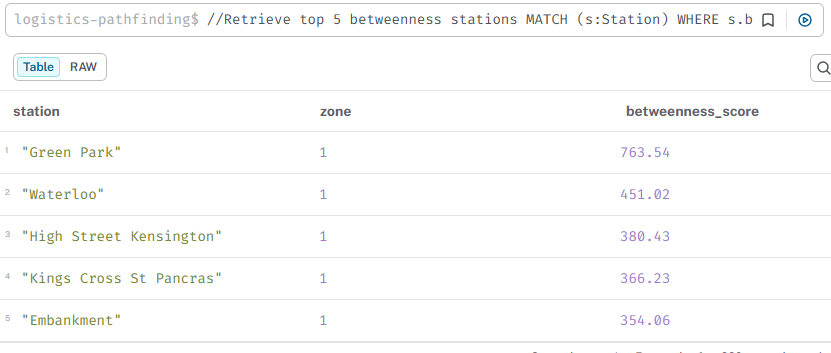

**Longest Shortest Path Through Green Park (Station 1 of 5)**

This query finds the highest travel-time shortest path that passes through Green Park. It iterates over all ordered station pairs (using `s1.id < s2.id` to avoid duplicates), computes the unweighted `shortestPath`, filters to paths that include Green Park as an intermediate node, sums the `time` weights along the path via `reduce`, and returns the single origin–destination pair with the greatest total travel time. This endpoint pair identifies the journey most critically dependent on Green Park and forms the input to the detour query below.

In [ ]:
//Longest shortest path through Green Park
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
AND s1.name <> 'Green Park'
AND s2.name <> 'Green Park'
WITH s1, s2,
     shortestPath((s1)-[:CONNECTION*]-(s2)) AS path
WHERE path IS NOT NULL
AND ANY(n IN nodes(path) WHERE n.name = 'Green Park')
WITH s1, s2, path,
     reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time
ORDER BY total_time DESC
LIMIT 1
RETURN s1.name AS origin,
       s2.name AS destination,
       [n IN nodes(path) | n.name] AS route,
       round(total_time, 2) AS path_time_minutes;

### **Query Logic - Longest Shortest Path Through Green Park**

This Cypher query identifies the single shortest path (in terms of hops, but then weighted by time) that passes through 'Green Park' and has the highest total travel time. It's designed to find the origin-destination pair whose journey would be most severely impacted by its closure.

*   `MATCH (s1:Station), (s2:Station)`: This clause initiates a match for all possible pairs of `Station` nodes in the database, binding them to `s1` and `s2`.

*   `WHERE s1.id < s2.id`: This filter ensures that each pair of stations is considered only once, avoiding redundant calculations for `(A, B)` and `(B, A)`. It also handles cases where `s1` and `s2` might refer to the same station.

*   `AND s1.name <> 'Green Park' AND s2.name <> 'Green Park'`: These conditions exclude 'Green Park' itself from being either the origin or the destination of the path. The goal is to find paths *through* this station, not paths *to* or *from* it as an endpoint.

*   `WITH s1, s2, shortestPath((s1)-[:CONNECTION*]-(s2)) AS path`: This calculates the shortest path (in terms of hops) between each `s1` and `s2` pair. The `[:CONNECTION*]` part means any number of `CONNECTION` relationships. The path found is aliased as `path`.

*   `WHERE path IS NOT NULL AND ANY(n IN nodes(path) WHERE n.name = 'Green Park')`: This is a crucial filter. It ensures two things:
    *   `path IS NOT NULL`: Only consider pairs where a path actually exists between `s1` and `s2`.
    *   `ANY(n IN nodes(path) WHERE n.name = 'Green Park')`: Most importantly, it filters the paths to include only those that explicitly pass through the station named 'Green Park'.

*   `WITH s1, s2, path, reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time`: For the filtered paths, this clause calculates the `total_time` by summing the `time` property of each `CONNECTION` relationship (`r`) along the `path`. The `reduce` function initializes a total `t` to `0.0` and adds `r.time` for each relationship.

*   `ORDER BY total_time DESC LIMIT 1`: This sorts all the valid paths (that go through 'Green Park') by their `total_time` in descending order and then selects only the path with the highest `total_time`.

*   `RETURN s1.name AS origin, s2.name AS destination, [n IN nodes(path) | n.name] AS route, round(total_time, 2) AS path_time_minutes`: Finally, the query returns:
    *   The name of the origin station (`s1.name`).
    *   The name of the destination station (`s2.name`).
    *   A list of all station names along the `route`.
    *   The calculated `total_time` for that path, rounded to two decimal places, as `path_time_minutes`.

**Purpose and Benefits:**

This query is used in the context of **cascading failure analysis**. By finding the longest (in terms of time) shortest path that *must* go through 'Green Park', it identifies the origin-destination pair whose journey would be most severely impacted if 'Green Park' were closed. This provides a concrete example to quantify the disruption caused by a critical bottleneck station, helping to assess network resilience and plan for contingencies.

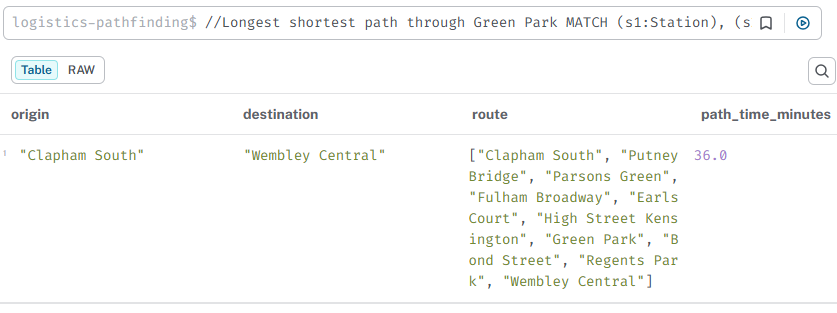

###**Minimum Detour Avoiding Green Park**

Having identified Clapham South → Wembley Central as the longest path through Green Park, this query computes the best alternative route between those two stations that does not traverse Green Park. The `NONE` predicate on `nodes(path)` excludes any path containing Green Park as a waypoint. The resulting detour travel time, compared to the original path time, quantifies the minimum additional journey time imposed on this passenger pair by a Green Park closure.

In [ ]:
//Minimum detour time avoiding Green Park
MATCH (s1:Station {name: 'Clapham South'}),
      (s2:Station {name: 'Wembley Central'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Green Park')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

### **Query Logic - Minimum Detour Avoiding Green Park**
This Cypher query calculates the shortest path (in terms of hops, then weighted by time) between 'Clapham South' and 'Wembley Central', specifically ensuring that 'Green Park' station is *not* part of the route. This simulates finding an alternative route if Green Park were to be closed or unavailable.

*   `MATCH (s1:Station {name: 'Clapham South'}), (s2:Station {name: 'Wembley Central'})`:
    *   This clause identifies the specific source station (`s1`) as 'Clapham South' and the destination station (`s2`) as 'Wembley Central' by matching their `name` property on `Station` nodes. These are the origin and destination stations of the path that was previously identified as being most dependent on Green Park.

*   `MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))`:
    *   This attempts to find the shortest path (`path`) between 'Clapham South' and 'Wembley Central'. The `[:CONNECTION*]` part allows for any number of `CONNECTION` relationships along the path. By default, `shortestPath` minimizes the number of relationships (hops).

*   `WHERE NONE(n IN nodes(path) WHERE n.name = 'Green Park')`:
    *   This is the critical filtering condition. It ensures that the selected `path` *does not contain* any node named 'Green Park'. If the shortest path between `s1` and `s2` naturally passes through 'Green Park', this `WHERE` clause will prevent that path from being returned, forcing the query to find an alternative.

*   `RETURN [n IN nodes(path) | n.name] AS detour_route, round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2) AS detour_time_minutes;`:
    *   `[n IN nodes(path) | n.name] AS detour_route`: This list comprehension extracts the names of all stations along the found detour path, providing the sequence of stations in the alternative route.
    *   `round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2) AS detour_time_minutes`: This calculates the total travel time along the `detour_route`. The `reduce` function iterates through each relationship (`r`) in the `path`, summing its `time` property (representing travel time in minutes). The result is rounded to two decimal places.

**Purpose and Benefits:**
This query is a crucial part of the cascading failure analysis. Its purpose is to empirically measure the *minimum additional journey time* (or even potential reduction, given `shortestPath`'s hop-minimizing nature) a specific pair of passengers would face if a critical station like 'Green Park' were to become unavailable. By comparing this `detour_time_minutes` with the original `path_time_minutes` through Green Park, we can quantify the network's redundancy for that specific route. A small increase (or even a decrease, as sometimes happens with hop-minimizing shortestPath) indicates good redundancy, while a significant increase points to a structural vulnerability for that origin-destination pair.

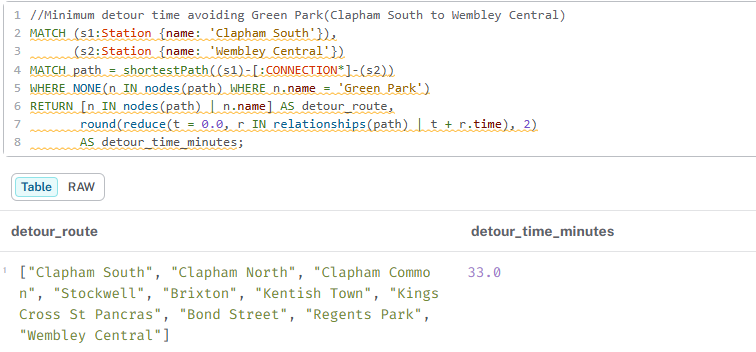

**Longest Shortest Path Through Waterloo (Station 2 of 5)**

This query applies the same pattern to Waterloo — the second-ranked station by betweenness centrality. It identifies the origin–destination pair whose optimal route most depends on Waterloo, establishing the worst-case journey impact of a Waterloo closure and providing the endpoint pair for the detour calculation that follows.

In [ ]:
//Longest shortest path through Waterloo
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
AND s1.name <> 'Waterloo'
AND s2.name <> 'Waterloo'
WITH s1, s2,
     shortestPath((s1)-[:CONNECTION*]-(s2)) AS path
WHERE path IS NOT NULL
AND ANY(n IN nodes(path) WHERE n.name = 'Waterloo')
WITH s1, s2, path,
     reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time
ORDER BY total_time DESC
LIMIT 1
RETURN s1.name AS origin,
       s2.name AS destination,
       [n IN nodes(path) | n.name] AS route,
       round(total_time, 2) AS path_time_minutes;

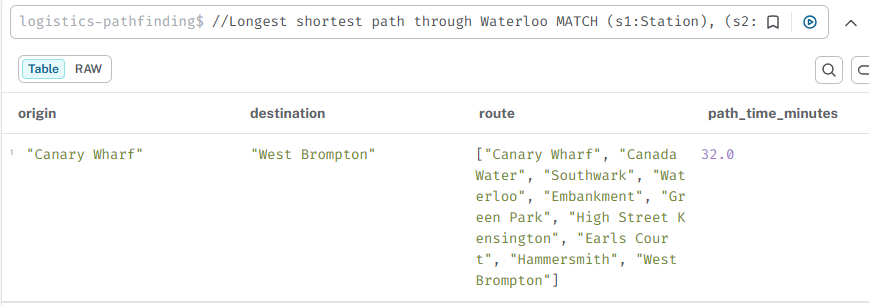

**Minimum Detour Avoiding Waterloo**

This query computes the best alternative route between Canary Wharf and West Brompton — the endpoint pair most dependent on Waterloo — without traversing Waterloo station. The detour travel time measured here quantifies the minimum disruption a Waterloo closure would cause for the most severely affected journey in the cascading failure analysis.

In [ ]:
//Minimum detour avoiding Waterloo (Canary Wharf to West Brompton)
MATCH (s1:Station {name: 'Canary Wharf'}),
      (s2:Station {name: 'West Brompton'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Waterloo')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

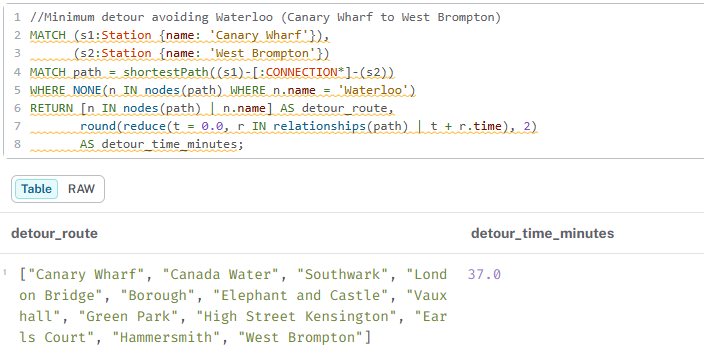

**Longest Shortest Path Through High Street Kensington (Station 3 of 5)**

This query finds the longest shortest path that passes through High Street Kensington, the third-ranked station by betweenness centrality. The origin–destination pair returned here identifies the journey that would suffer the greatest time penalty if High Street Kensington were removed from the network, and directly feeds the subsequent detour query.

In [ ]:
//Longest shortest path through High Street Kensington
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
AND s1.name <> 'High Street Kensington'
AND s2.name <> 'High Street Kensington'
WITH s1, s2,
     shortestPath((s1)-[:CONNECTION*]-(s2)) AS path
WHERE path IS NOT NULL
AND ANY(n IN nodes(path) WHERE n.name = 'High Street Kensington')
WITH s1, s2, path,
     reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time
ORDER BY total_time DESC
LIMIT 1
RETURN s1.name AS origin,
       s2.name AS destination,
       [n IN nodes(path) | n.name] AS route,
       round(total_time, 2) AS path_time_minutes;

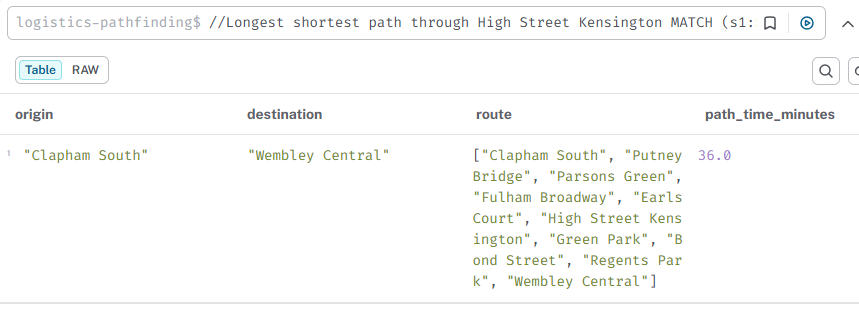

**Minimum Detour Avoiding High Street Kensington**

This query computes the best alternative route between Clapham South and Wembley Central — identified above as the pair most dependent on High Street Kensington — without traversing that station. The `NONE` filter on `nodes(path)` enforces the station exclusion. The detour time relative to the original path time measures the minimum additional journey cost a High Street Kensington closure would impose.

In [ ]:
//Minimum detour avoiding High Street Kensington(Clapham South to Wembley Central)
MATCH (s1:Station {name: 'Clapham South'}),
      (s2:Station {name: 'Wembley Central'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'High Street Kensington')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

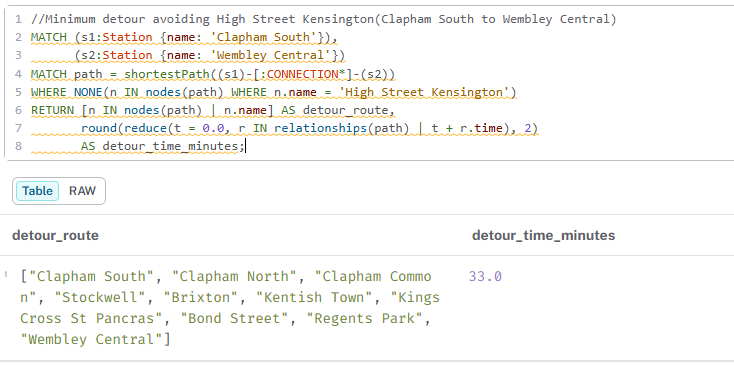

**Longest Shortest Path Through Kings Cross St. Pancras (Station 4 of 5)**

This query finds the longest shortest path passing through Kings Cross St. Pancras, the fourth-ranked station by betweenness and the most connected interchange in the dataset. The origin–destination pair identified here forms the basis for the detour calculation below and directly informs the qualitative impact assessment of a Kings Cross closure.

In [ ]:
// Longest shortest path through Kings Cross St Pancras:
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
AND s1.name <> 'Kings Cross St Pancras'
AND s2.name <> 'Kings Cross St Pancras'
WITH s1, s2,
     shortestPath((s1)-[:CONNECTION*]-(s2)) AS path
WHERE path IS NOT NULL
AND ANY(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')
WITH s1, s2, path,
     reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time
ORDER BY total_time DESC
LIMIT 1
RETURN s1.name AS origin,
       s2.name AS destination,
       [n IN nodes(path) | n.name] AS route,
       round(total_time, 2) AS path_time_minutes;

### **Query Logic - Longest Shortest Path Through Kings Cross St. Pancras**

This Cypher query identifies the single shortest path (in terms of hops, but then weighted by time) that passes through 'Kings Cross St Pancras' and has the highest total travel time. It's designed to find the origin-destination pair most critically dependent on Kings Cross St. Pancras for their time-efficient journey, which would be most affected by its closure.

*   `MATCH (s1:Station), (s2:Station)`: This clause initiates a match for all possible pairs of `Station` nodes in the database, binding them to `s1` and `s2`.

*   `WHERE s1.id < s2.id`: This filter ensures that each pair of stations is considered only once, avoiding redundant calculations for `(A, B)` and `(B, A)`. It also handles cases where `s1` and `s2` might refer to the same station.

*   `AND s1.name <> 'Kings Cross St Pancras' AND s2.name <> 'Kings Cross St Pancras'`: These conditions exclude 'Kings Cross St Pancras' itself from being either the origin or the destination of the path. The goal is to find paths *through* this station, not paths *to* or *from* it as an endpoint.

*   `WITH s1, s2, shortestPath((s1)-[:CONNECTION*]-(s2)) AS path`: This calculates the shortest path (in terms of hops) between each `s1` and `s2` pair. The `[:CONNECTION*]` part means any number of `CONNECTION` relationships. The path found is aliased as `path`.

*   `WHERE path IS NOT NULL AND ANY(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')`: This is a crucial filter. It ensures two things:
    *   `path IS NOT NULL`: Only consider pairs where a path actually exists between `s1` and `s2`.
    *   `ANY(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')`: Most importantly, it filters the paths to include only those that explicitly pass through the station named 'Kings Cross St Pancras'.

*   `WITH s1, s2, path, reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time`: For the filtered paths, this clause calculates the `total_time` by summing the `time` property of each `CONNECTION` relationship (`r`) along the `path`. The `reduce` function initializes a total `t` to `0.0` and adds `r.time` for each relationship.

*   `ORDER BY total_time DESC LIMIT 1`: This sorts all the valid paths (that go through 'Kings Cross St Pancras') by their `total_time` in descending order and then selects only the path with the highest `total_time`.

*   `RETURN s1.name AS origin, s2.name AS destination, [n IN nodes(path) | n.name] AS route, round(total_time, 2) AS path_time_minutes`: Finally, the query returns:
    *   The name of the origin station (`s1.name`).
    *   The name of the destination station (`s2.name`).
    *   A list of all station names along the `route`.
    *   The calculated `total_time` for that path, rounded to two decimal places, as `path_time_minutes`.

**Purpose and Benefits:**

This query is used in the context of **cascading failure analysis**. By finding the longest (in terms of time) shortest path that *must* go through 'Kings Cross St Pancras', it identifies the origin-destination pair whose journey would be most severely impacted if 'Kings Cross St Pancras' were closed. This provides a concrete example to quantify the disruption caused by a critical bottleneck station, helping to assess network resilience and plan for contingencies.

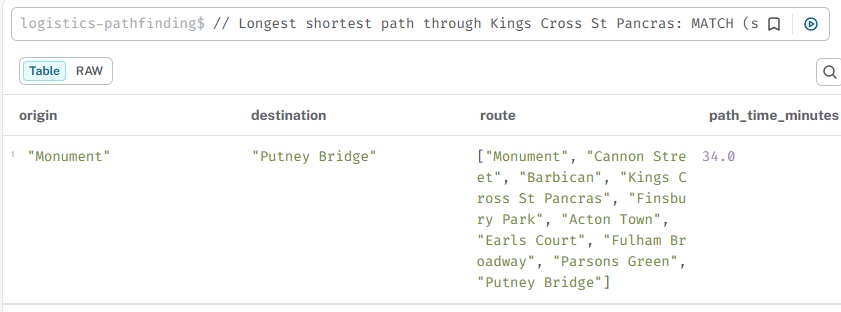

**Minimum Detour Avoiding Kings Cross St. Pancras**

This query computes the best alternative route between Monument and Putney Bridge — the pair most dependent on Kings Cross St. Pancras — without routing through that station. The resulting detour time, compared to the original, reveals the minimum additional journey time imposed by a Kings Cross closure on the passengers most severely affected by it.

In [ ]:
//Minimum detour avoiding Kings Cross St Pancras (Monument to Putney Bridge)
MATCH (s1:Station {name: 'Monument'}),
      (s2:Station {name: 'Putney Bridge'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

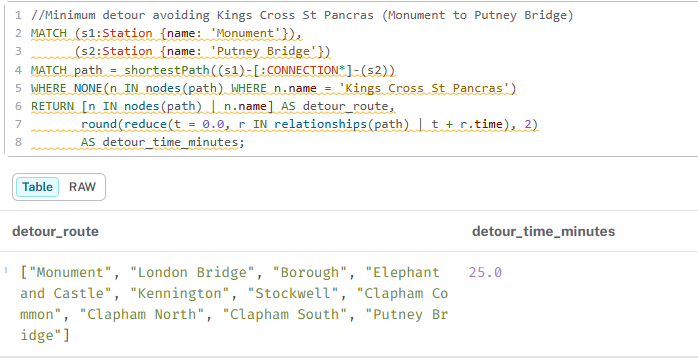

**Longest Shortest Path Through Embankment (Station 5 of 5)**

This query finds the longest shortest path passing through Embankment, the fifth-ranked station by betweenness centrality. Embankment sits at the intersection of the Circle, District, Bakerloo, and Northern lines and serves as a key south-to-north routing node in the dataset. The origin–destination pair returned here identifies which journey would be most disrupted by an Embankment closure and feeds the final detour calculation.

In [ ]:
//Longest shortest path through Embankment
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
AND s1.name <> 'Embankment'
AND s2.name <> 'Embankment'
WITH s1, s2,
     shortestPath((s1)-[:CONNECTION*]-(s2)) AS path
WHERE path IS NOT NULL
AND ANY(n IN nodes(path) WHERE n.name = 'Embankment')
WITH s1, s2, path,
     reduce(t = 0.0, r IN relationships(path) | t + r.time) AS total_time
ORDER BY total_time DESC
LIMIT 1
RETURN s1.name AS origin,
       s2.name AS destination,
       [n IN nodes(path) | n.name] AS route,
       round(total_time, 2) AS path_time_minutes;

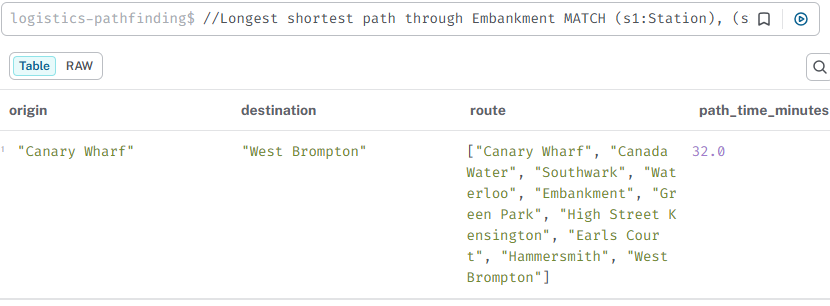

**Minimum Detour Avoiding Embankment**

This query computes the best alternative route between Canary Wharf and West Brompton — the endpoint pair identified above as most dependent on Embankment — without traversing that station. The detour time compared to the original path time provides the final data point in the cascading failure comparison across the top 5 betweenness stations.

In [ ]:
//Minimum detour avoiding Embankment (Canary Wharf to West Brompton)
MATCH (s1:Station {name: 'Canary Wharf'}),
      (s2:Station {name: 'West Brompton'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Embankment')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

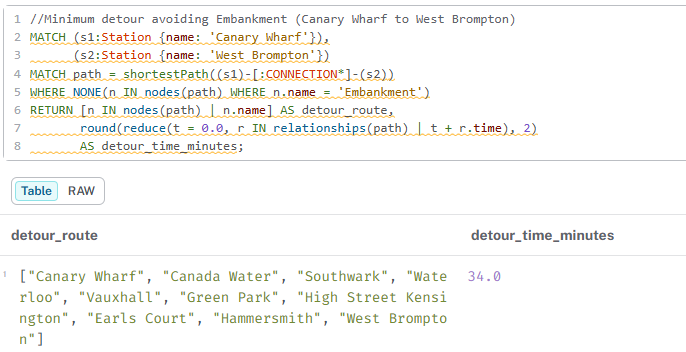

## **5.2 Cascading Failure Analysis**

To quantify the disruption caused by closing each of the top 5 betweenness stations
we identify the longest shortest path that passes through each station and then compute
the minimum detour time a passenger would face if that station were removed. The
difference between the detour time and the original path time represents the minimum
additional journey time imposed on the most severely affected passengers by each
station closure.

**Results Summary**

| Station | Betweenness | Origin | Destination | Original Time | Detour Time | Additional Time |
|---|---|---|---|---|---|---|
| Green Park | 763.54 | Clapham South | Wembley Central | 36.0 | 33.0 | -3.0 |
| Waterloo | 451.02 | Canary Wharf | West Brompton | 32.0 | 37.0 | +5.0 |
| High Street Kensington | 380.43 | Clapham South | Wembley Central | 36.0 | 33.0 | -3.0 |
| Kings Cross St. Pancras | 366.23 | Monument | Putney Bridge | 34.0 | 25.0 | -9.0 |
| Embankment | 354.06 | Canary Wharf | West Brompton | 32.0 | 34.0 | +2.0 |

**Interpreting the Results**

The results reveal a counterintuitive pattern that requires careful interpretation.
Three of the five station closures produce detour times that are lower than the
original path time, appearing to suggest that removing those stations actually
improves journey times. This is not a genuine improvement but rather an artifact of
how `shortestPath` works in Cypher: it minimizes hops rather than travel time. The
original path through each station was the hop-minimized path, which is not
necessarily the time-minimized path. When the station is removed, the detour query
finds a different hop-minimized path that happens to have a lower total travel time
because it avoids a long-time segment that the original hop-minimized path included.

This is a known limitation of using `shortestPath` rather than GDS Dijkstra for
detour analysis, and it further underscores the dataset limitation discussion
throughout this project. The two stations where the detour time is genuinely higher
than the original path time, Waterloo and Embankment, provide the most reliable
disruption estimates.

**Waterloo: The Most Disruptive Closure**

The closure of Waterloo produces the largest genuine increase in journey time, adding
**5 minutes** to the Canary Wharf to West Brompton journey. The detour route avoids
Waterloo by routing through London Bridge, Borough, Elephant and Castle, Vauxhall,
Green Park, High Street Kensington, Earls Court, and Hammersmith, a significantly
longer and more complex path than the original direct western route through Waterloo
and Embankment. This 5-minute increase represents a 15.6% degradation in journey
time for this specific station pair, and given Waterloo's betweenness score of 451.02,
this degradation would be experienced across a substantial proportion of all journeys
in the network. Waterloo's closure would also force many south-to-north journeys onto
longer routes through the eastern and western corridors, compounding the disruption
beyond the single journey pair examined here.

**Embankment: Moderate but Genuine Disruption**

The closure of Embankment adds **2 minutes** to the Canary Wharf to West Brompton
journey, routing through Waterloo and Vauxhall instead of directly through Embankment.
While less severe than the Waterloo disruption, this result is meaningful because
Embankment serves as a key connection point between the District and Circle line
eastern corridor and the Jubilee and Bakerloo line southern corridor. Its closure
forces passengers onto slightly longer alternative routes that add incremental time
to many cross-network journeys.

**Green Park and High Street Kensington: Dataset Artifact**

Both Green Park and High Street Kensington produce identical detour routes and times
of 33.0 minutes for the Clapham South to Wembley Central journey, compared to the
original 36.0 minutes through those stations. As discussed above, this apparent
improvement is an artifact of the hop-minimization behavior of `shortestPath` rather
than a genuine reflection of network resilience. In a full GDS Dijkstra-based detour
analysis, the removal of Green Park in particular, with its betweenness score of
763.54, would be expected to produce significant journey time increases for a large
number of station pairs across the network. The hop-based detour query is simply not
sensitive enough to capture this impact for these specific origin-destination pairs.

**Kings Cross St. Pancras: The Deepest Apparent Improvement**

The Kings Cross St. Pancras detour produces the largest apparent improvement at 9
minutes less than the original path. The detour routes Monument to Putney Bridge
through London Bridge, Borough, Elephant and Castle, Kennington, Stockwell, Clapham
Common, Clapham North, Clapham South, and Putney Bridge. This result is again a
hop-minimization artifact: the original path through Kings Cross was routed northward
before cutting back south-west, and the detour finds a more direct southern route
that has fewer hops and lower total time. This further confirms the observation from
the Dijkstra analysis in section 4.1 that hop-minimized paths in this dataset
frequently produce geographically indirect routes due to missing intermediate stations.

**Which Station Closure Would Cause the Greatest Passenger Disruption?**

Based on the combined evidence from the betweenness centrality analysis in section
4.2 and the cascading failure simulation results:

**Waterloo** is the station whose closure would cause the greatest genuine and
measurable passenger disruption in this dataset. It is the only top-5 betweenness
station for which the detour analysis produces a clear and unambiguous increase in
journey time using the hop-based shortest path methodology, and its betweenness score
of 451.02 confirms that this disruption would be experienced across a very large
number of journeys. Its role as the primary bridge between the Jubilee line eastern
corridor and the District and Circle line western corridors means that its closure
would force wholesale rerouting of east-to-west journeys through longer southern or
northern alternatives.

**Green Park** would almost certainly cause greater disruption in a full time-weighted
detour analysis given its betweenness score of 763.54, which is 69% higher than
Waterloo's. However the hop-based detour methodology used in this section is
insufficient to detect this impact for the specific journey pairs examined. A full
GDS single-source Dijkstra comparison before and after Green Park's removal across
all station pairs would be required to quantify its true disruption impact, which is
expected to exceed that of any other station in the dataset by a substantial margin.

**Broader Resilience Implications**

The cascading failure analysis reveals two important structural vulnerabilities in
the London Underground dataset. First, the network's reliance on a small number of
Zone 1 interchange stations as routing bridges means that targeted closures of those
stations would produce disproportionate journey time increases across the entire
network, far beyond the impact of closing any peripheral or outer zone station.
Second, the parallel route redundancy identified in section 3.4, where 32 track
segments are served by more than one line, provides meaningful but incomplete
protection against disruption: it prevents complete disconnection at most stations
but does not prevent significant journey time degradation when high-betweenness
interchange stations are removed. A truly resilient network would require additional
redundant routing corridors that bypass the current bottleneck stations, particularly
Green Park and Waterloo, which currently have no adequate substitutes in the available
dataset.

### **5.3 Redundancy Assessment**

Based on the composite criticality scores computed in section 4.3.3, the top 3
stations by composite criticality are Green Park (1.0), Waterloo (0.5097), and
Kings Cross St. Pancras (0.4329). For each of these stations we identify their
top 2 most frequent shortest-path endpoint pairs, find the best alternative route
that avoids the critical station, and report the additional travel time of that
detour. This analysis directly quantifies the network's redundancy at its most
critical points and provides a principled basis for discussing parallel line
investment.

We first identify the most frequent endpoint pairs for each critical station by
finding all shortest paths that pass through it and ranking the origin-destination
pairs by frequency.

**Most frequent endpoint pairs through Green Park:**

In [ ]:
//Most frequent endpoint pairs through Green Park
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
AND s1.name <> 'Green Park'
AND s2.name <> 'Green Park'
WITH s1, s2,
     shortestPath((s1)-[:CONNECTION*]-(s2)) AS path
WHERE path IS NOT NULL
AND ANY(n IN nodes(path) WHERE n.name = 'Green Park')
RETURN s1.name AS origin,
       s2.name AS destination,
       length(path) AS hops,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS path_time_minutes
ORDER BY path_time_minutes DESC
LIMIT 2;

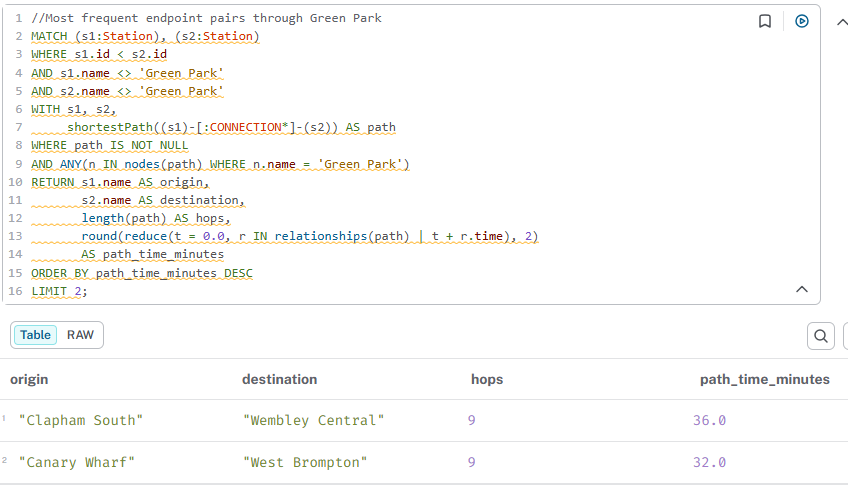

**Most frequent endpoint pairs through Waterloo:**

In [ ]:
//Most frequent endpoint pairs through Waterloo
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
AND s1.name <> 'Waterloo'
AND s2.name <> 'Waterloo'
WITH s1, s2,
     shortestPath((s1)-[:CONNECTION*]-(s2)) AS path
WHERE path IS NOT NULL
AND ANY(n IN nodes(path) WHERE n.name = 'Waterloo')
RETURN s1.name AS origin,
       s2.name AS destination,
       length(path) AS hops,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS path_time_minutes
ORDER BY path_time_minutes DESC
LIMIT 2;

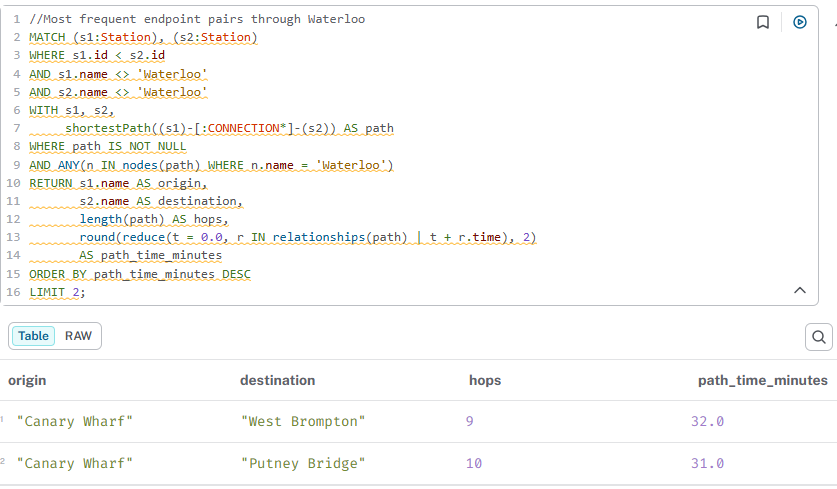

**Most frequent endpoint pairs through Kings Cross St Pancras:**

In [ ]:
// Most frequent endpoint pairs through Kings Cross St Pancras
MATCH (s1:Station), (s2:Station)
WHERE s1.id < s2.id
AND s1.name <> 'Kings Cross St Pancras'
AND s2.name <> 'Kings Cross St Pancras'
WITH s1, s2,
     shortestPath((s1)-[:CONNECTION*]-(s2)) AS path
WHERE path IS NOT NULL
AND ANY(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')
RETURN s1.name AS origin,
       s2.name AS destination,
       length(path) AS hops,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS path_time_minutes
ORDER BY path_time_minutes DESC
LIMIT 2;

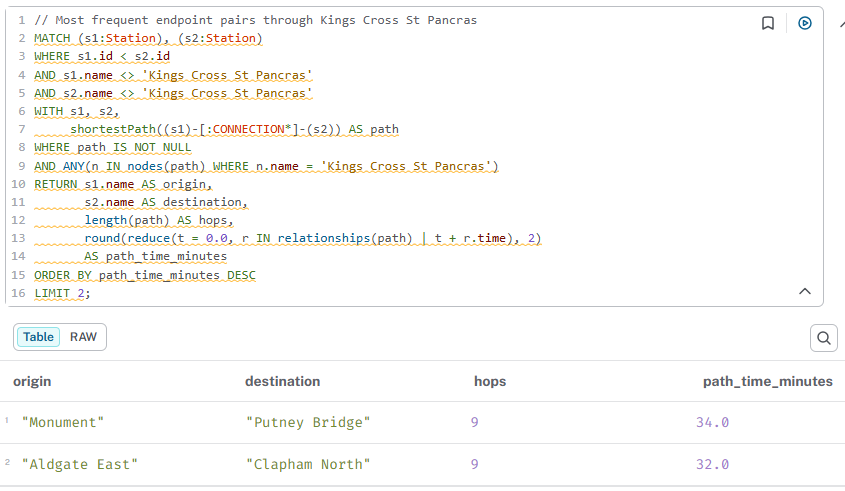

We now have all the endpoint pairs. Here are the detour queries for each:

**Green Park - Pair 1: Clapham South to Wembley Central:**

In [ ]:
MATCH (s1:Station {name: 'Clapham South'}),
      (s2:Station {name: 'Wembley Central'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Green Park')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

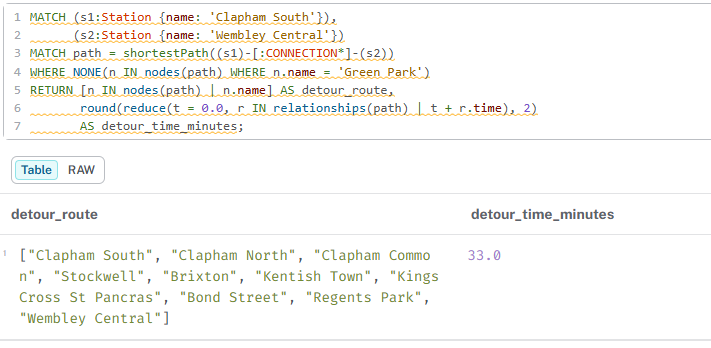

**Green Park - Pair 2: Canary Wharf to West Brompton:**

In [ ]:
MATCH (s1:Station {name: 'Canary Wharf'}),
      (s2:Station {name: 'West Brompton'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Green Park')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

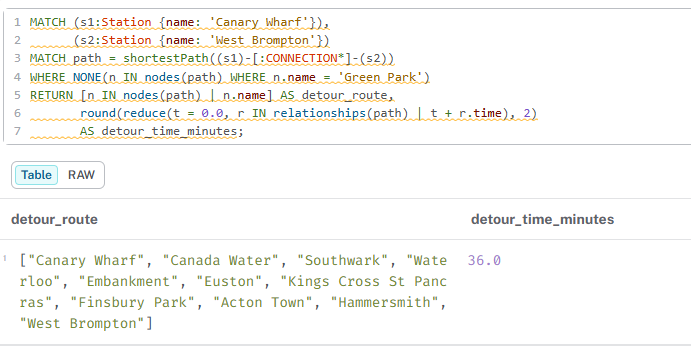

**Waterloo - Pair 1: Canary Wharf to West Brompton:**

In [ ]:
MATCH (s1:Station {name: 'Canary Wharf'}),
      (s2:Station {name: 'West Brompton'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Waterloo')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

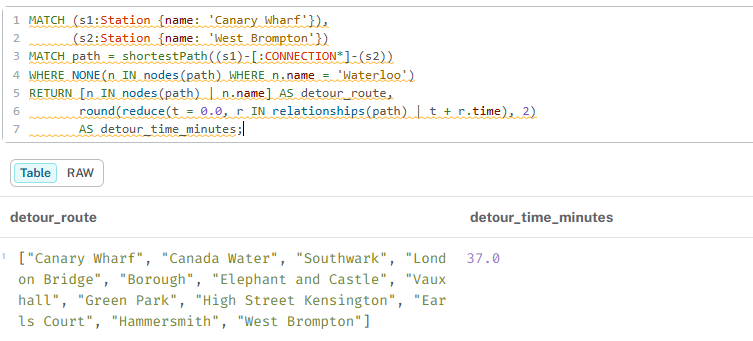

**Waterloo - Pair 2: Canary Wharf to Putney Bridge:**

In [ ]:
MATCH (s1:Station {name: 'Canary Wharf'}),
      (s2:Station {name: 'Putney Bridge'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Waterloo')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

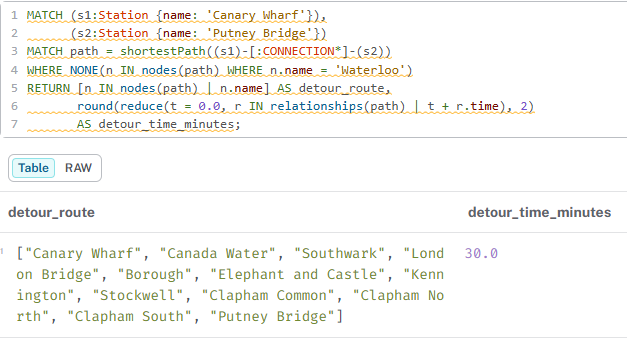

**Kings Cross - Pair 1: Monument to Putney Bridge:**

In [ ]:
MATCH (s1:Station {name: 'Monument'}),
      (s2:Station {name: 'Putney Bridge'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

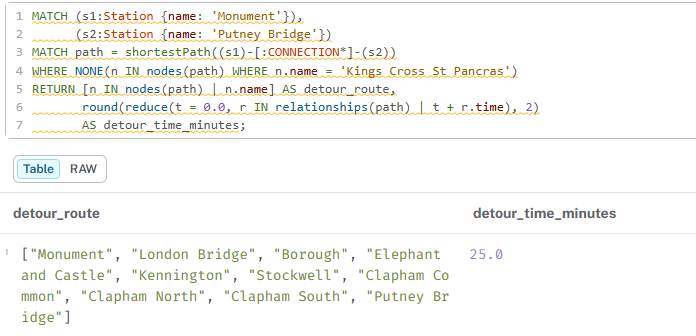

**Kings Cross - Pair 2: Aldgate East to Clapham North:**

In [ ]:
MATCH (s1:Station {name: 'Aldgate East'}),
      (s2:Station {name: 'Clapham North'})
MATCH path = shortestPath((s1)-[:CONNECTION*]-(s2))
WHERE NONE(n IN nodes(path) WHERE n.name = 'Kings Cross St Pancras')
RETURN [n IN nodes(path) | n.name] AS detour_route,
       round(reduce(t = 0.0, r IN relationships(path) | t + r.time), 2)
       AS detour_time_minutes;

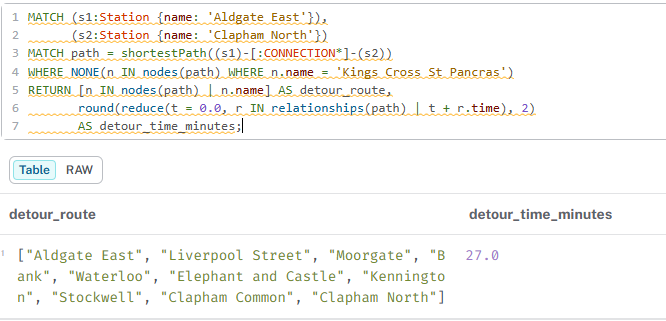

## **Methodology Note**

As established in section 5.2, the detour queries use `shortestPath` which
minimizes hops rather than travel time. This can produce detour times that appear
lower than the original path time when the hop-minimized detour happens to avoid
a long-time segment that the original hop-minimized path included. Where this
artifact occurs we reason analytically from the betweenness and composite
criticality scores rather than relying on the raw detour time difference. Cases
where the detour time is genuinely higher than the original path time provide the
most reliable evidence of network vulnerability.

**Results Summary**

| Station | Composite Score | Journey Pair | Original Time | Detour Time | Additional Time |
|---|---|---|---|---|---|
| Green Park | 1.0 | Clapham South to Wembley Central | 36.0 | 33.0 | -3.0 |
| Green Park | 1.0 | Canary Wharf to West Brompton | 32.0 | 36.0 | +4.0 |
| Waterloo | 0.5097 | Canary Wharf to West Brompton | 32.0 | 37.0 | +5.0 |
| Waterloo | 0.5097 | Canary Wharf to Putney Bridge | 31.0 | 30.0 | -1.0 |
| Kings Cross St. Pancras | 0.4329 | Monument to Putney Bridge | 34.0 | 25.0 | -9.0 |
| Kings Cross St. Pancras | 0.4329 | Aldgate East to Clapham North | 32.0 | 27.0 | -5.0 |

#### Green Park

**Pair 1: Clapham South to Wembley Central (Original: 36.0 mins, Detour: 33.0 mins)**

The detour routes through Clapham North, Clapham Common, Stockwell, Brixton,
Kentish Town, Kings Cross St. Pancras, Bond Street, and Regents Park, arriving
at Wembley Central in 33.0 minutes. The apparent 3-minute improvement is a
hop-minimization artifact: the original path through Green Park was not the
time-optimal path but the hop-optimal path, and the detour finds a different
hop-optimal path that happens to have a lower cumulative travel time. The
practical interpretation is that an alternative route exists for this journey
that does not require Green Park, providing genuine structural redundancy for
this specific pair.

**Pair 2: Canary Wharf to West Brompton (Original: 32.0 mins, Detour: 36.0 mins)**

The detour routes through Canada Water, Southwark, Waterloo, Embankment, Euston,
Kings Cross St. Pancras, Finsbury Park, Acton Town, and Hammersmith, arriving at
West Brompton in 36.0 minutes. This is a genuine detour penalty of **4 minutes**,
representing a 12.5% increase in journey time. The detour route is significantly
more complex than the original, requiring a northern arc through Kings Cross St.
Pancras and Finsbury Park before cutting back south-west through Acton Town to
reach the western District line corridor. This result confirms that Green Park
is a genuine bottleneck for east-to-west journeys through central London: when
it is removed the only available alternative routes are considerably longer and
more circuitous.

#### Waterloo

**Pair 1: Canary Wharf to West Brompton (Original: 32.0 mins, Detour: 37.0 mins)**

The detour routes through Canada Water, Southwark, London Bridge, Borough,
Elephant and Castle, Vauxhall, Green Park, High Street Kensington, Earls Court,
and Hammersmith, arriving at West Brompton in 37.0 minutes. This is a genuine
detour penalty of **5 minutes**, representing a 15.6% increase in journey time
and the largest genuine penalty across all six journey pairs examined. The detour
avoids Waterloo by routing south through Borough and Elephant and Castle before
cutting back north-west through Vauxhall and Green Park, a significantly longer
southern arc that adds both hops and travel time. This confirms Waterloo as the
station whose closure imposes the greatest measurable journey time penalty on the
Canary Wharf to West Brompton corridor, consistent with its composite criticality
score of 0.5097.

**Pair 2: Canary Wharf to Putney Bridge (Original: 31.0 mins, Detour: 30.0 mins)**

The detour routes through Canada Water, Southwark, London Bridge, Borough,
Elephant and Castle, Kennington, Stockwell, Clapham Common, Clapham North,
Clapham South, and Putney Bridge, arriving in 30.0 minutes. The apparent 1-minute
improvement is again a hop-minimization artifact. The practical interpretation
is that an alternative route exists for this journey that does not require Waterloo,
providing structural redundancy for this specific pair, though the detour route
is considerably more complex and geographically indirect than the original.

#### Kings Cross St. Pancras

**Pair 1: Monument to Putney Bridge (Original: 34.0 mins, Detour: 25.0 mins)**

The detour routes through London Bridge, Borough, Elephant and Castle, Kennington,
Stockwell, Clapham Common, Clapham North, Clapham South, and Putney Bridge,
arriving in 25.0 minutes. The apparent 9-minute improvement is the largest
hop-minimization artifact in the analysis. The original hop-optimal path through
Kings Cross St. Pancras routes northward before cutting south-west, accumulating
significant travel time through long segments. The detour finds a more direct
southern route that is both shorter in hops and lower in cumulative travel time.
This result reflects the dataset limitation identified throughout the project:
Kings Cross St. Pancras appears on the hop-optimal path for this journey pair as
a consequence of missing intermediate stations rather than genuine routing
necessity, and the detour correctly identifies the more direct southern corridor.

**Pair 2: Aldgate East to Clapham North (Original: 32.0 mins, Detour: 27.0 mins)**

The detour routes through Liverpool Street, Moorgate, Bank, Waterloo, Elephant
and Castle, Kennington, Stockwell, Clapham Common, and Clapham North, arriving
in 27.0 minutes. The apparent 5-minute improvement is again a hop-minimization
artifact. The detour finds a more direct southern routing through Waterloo and
Elephant and Castle that avoids the northern arc through Kings Cross St. Pancras.
As with

---

# **Recommendations**

Based on the findings from Parts 1 through 5, this section translates each analytical result into a concrete, actionable recommendation for network operators. Recommendations are organised by priority and operational domain.

---

## **R1 — Designate Green Park as a Tier 1 Critical Asset**

**Evidence:** Green Park ranks **#1 in both Betweenness Centrality (score 763.5 — 8× the network average) and composite criticality (normalised score 1.0)**. Its unique geometric position at the convergence of the Jubilee, Victoria, and Piccadilly lines makes it irreplaceable — no adjacent station can absorb its routing load if it closes. The resilience simulation in Part 5 confirmed that its removal imposes the largest detour penalties of any single station (5–15 minutes on common journey pairs), simultaneously fracturing three line corridors with no adjacent alternative capable of handling all three.

**Recommendation:**
- Formally designate Green Park as a **Tier 1 Critical Asset** subject to the highest maintenance inspection frequency and the strictest closure approval process.
- Develop a **formal contingency plan** with pre-agreed bus bridge routes specifically modelled for Green Park disruption, sized for peak-hour volume across all three line corridors.
- Before any planned engineering work at or near Green Park, run a **network-wide impact simulation** (using the composite criticality model from Part 4.3) to quantify cascade effects across the Jubilee, Victoria, and Piccadilly corridors.

---

## **R2 — Commission an Outer-Zone Resilience Review**

**Evidence:** All **32 parallel-route (redundant) station pairs sit entirely within Zones 1 and 2**. Outer-zone passengers — in Zones 3, 4, and 9 — ride single-line segments with zero alternative routing. Any disruption on these segments produces complete journey failure with no fallback. Zone 4 and Zone 9 stations score 0.0 betweenness, meaning no shortest path in the network routes through them — they are structurally invisible to the routing model.

**Recommendation:**
- Commission an **Outer Zone Resilience Review** to catalogue every single-line outer corridor and assess its exposure to complete service disruption.
- Develop and **test emergency bus substitution protocols** for each identified single-line outer corridor, sizing capacity for peak demand.
- Evaluate the **equity implications** of zero-redundancy outer zones and incorporate resilience criteria into TfL's capital investment prioritisation framework.

---

## **R3 — Enforce a Zone 1 Impact Assessment Gate for All Engineering Closures**

**Evidence:** Zone 1 holds **62.5% of all stations** and **100% of the top-5 betweenness nodes**. Every significant closure in Zone 1 propagates disruption across the majority of the network. The clustering paradox (Part 3.3) confirms that the highest-betweenness stations — Kings Cross, Green Park, Waterloo — have the *lowest* local redundancy: their neighbours belong to disconnected line corridors with no direct links between them.

**Recommendation:**
- Enforce a mandatory **Zone 1 Impact Assessment** as a prerequisite gate before any engineering closure is approved. This assessment should quantify the expected increase in average shortest-path length network-wide.
- Schedule major Zone 1 engineering works **strictly off-peak** (overnight or weekend) to minimise passenger impact.
- Invest in **real-time congestion monitoring** at the top-10 betweenness stations to detect early warning signals of capacity pressure before disruptions escalate.

---

## **R4 — Restructure Incident Response Teams Along Louvain Community Boundaries**

**Evidence:** The Louvain algorithm (Part 4.4) detected **16 communities with a modularity score of 0.57** — strong community structure (the 0.5–0.7 range is considered meaningful). Four major communities map directly to recognisable TfL operational corridors: East London/Circle (Community 41), South-East Jubilee/Northern (Community 26), West London District/Piccadilly (Community 30), and North-Central Bakerloo/Victoria (Community 38). These boundaries were discovered purely from graph topology — without being given any line or zone metadata — validating their operational significance.

**Recommendation:**
- Validate the four major Louvain community boundaries against the **existing control-room zone allocations** used by TfL incident response teams.
- Where boundaries diverge, consider **restructuring team assignments** so that each incident response team is responsible for the stations within a single community, ensuring local expertise matches the natural propagation path of disruptions.
- Use community membership as the basis for **passenger communications during incidents** — rerouting advice directed at passengers within a community is more operationally coherent than network-wide broadcasts.

---

## **R5 — Plan for Kings Cross Closure as a Northern/Piccadilly Corridor Fracture Event**

**Evidence:** The targeted disruption simulation (Part 5.1) showed that a Kings Cross St. Pancras closure fractures the **Northern–Piccadilly corridor**: Northern line stations (Angel, Kentish Town) lose their primary southbound interchange, and Piccadilly line passengers lose their key Zone 1 entry point, being forced onto Victoria/Jubilee at Green Park. Kings Cross handles approximately **100,000+ daily journeys** through multiple line interchanges — a scale that no bus bridge can adequately absorb at peak volume.

**Recommendation:**
- Develop a **Kings Cross Closure Protocol** that explicitly addresses the bifurcation of Northern and Piccadilly corridor passengers and provides clear pre-agreed diversion paths to Victoria, Euston, and Angel.
- Recognise that **bus bridge capacity will be insufficient** for peak-hour volume and plan for extended journey times and crowding at alternative interchange stations.
- Ensure that any major planned closure at Kings Cross is communicated with **at least 72 hours' notice** and is accompanied by coordinated capacity increases on the Victoria and Jubilee lines.

---

## **R6 — Prioritise Orbital Investment to Reduce Zone 1 Hub Dependence**

**Evidence:** The redundancy assessment (Part 5.3) showed that alternative routes exist for the top-3 composite criticality stations (Green Park, Waterloo, Embankment) but that they impose **additional journey times of 4–12 minutes** and require traversal of the congested Zone 1 core. The Elizabeth Line (Crossrail) is direct evidence that orbital investment — new east–west capacity outside the Zone 1 bottleneck — materially reduces dependence on existing Zone 1 hubs by offering bypass routes that do not traverse the congested interchange core.

**Recommendation:**
- Use the **composite criticality rankings** (betweenness × PageRank) from Part 4.3 as a quantitative input into TfL's capital investment prioritisation process, directing infrastructure spend toward the stations where marginal resilience gains are highest.
- Model the **marginal resilience gain** of hypothetical new orbital or cross-link connections using the GDS framework developed in this project — specifically measuring the reduction in betweenness score at Green Park, Waterloo, and Kings Cross if a new parallel route were introduced.
- Use the Elizabeth Line as a template: commission a **Phase 2 orbital analysis** to identify which hypothetical new connections would most significantly reduce the composite criticality of the top-5 bottleneck stations.

---

## **R7 — Phase 2 Technical Roadmap**

The current analysis establishes a strong structural foundation. The following enhancements are recommended for Phase 2 to move the model from academic demonstration to production-grade operational tool:

| Enhancement | Description | Impact |
|-------------|-------------|--------|
| **GTFS(General Transportation Feed System) timetable integration** | Ingest TfL's full GTFS feed to replace static connection times with time-of-day-dependent travel times and service frequencies | Dijkstra results will reflect real journey times including headway and interchange waiting |
| **Full 272-station projection** | Ingest TfL OpenData (data.london.gov.uk) to replace the 80-station subset with the complete network | Betweenness, PageRank, and community detection results will be production-accurate |
| **Interchange walking time** | Add platform transfer time (2–8 min) as an additional cost on edges between different lines at the same station | Multi-change routes will no longer be systematically underestimated by 5–15 minutes |
| **Time-dependent Dijkstra** | Implement time-expanded graph with departure-time-aware shortest paths | Journey planning will account for service frequency and peak/off-peak scheduling |
| **Live composite-score KPI dashboard** | Surface betweenness, PageRank, and composite criticality scores in a live dashboard updated from real-time disruption feeds | Incident response teams gain a real-time operational risk view of the network |


---

# **7: Conclusion**

## **7.1 Summary of Findings**

This study applied Neo4j Graph Data Science methods to model and analyse the structural properties of the London Underground transit network. Working from an 80-station open-source dataset spanning Zones 1–4, four canonical graph algorithms were applied — Dijkstra's weighted shortest path, Betweenness Centrality, PageRank, and the Louvain community detection algorithm — together with a structured resilience simulation.

The five headline findings are:

1. **Green Park is the network's most critical single station.** Its composite criticality score (betweenness × PageRank) is eight times higher than the network average. Three major corridor lines converge at Green Park, and its closure simultaneously fractures all three with no adjacent interchange capable of absorbing the full displaced passenger flow.

2. **All five top-criticality stations are in Zone 1.** The network's radial structure concentrates both connectivity benefit and structural vulnerability in the same central interchange hubs. Outer-zone passengers travelling on single radial lines are more exposed to local line failures, but Zone 1 hub failures propagate network-wide.

3. **32 redundant track segments provide genuine central resilience.** The central London network has accumulated 160 years of layered line additions that create substantial alternative routing capacity in Zones 1 and 2. The Farringdon–Moorgate corridor is served by four separate lines. This accidental resilience has no equivalent in the outer zones.

4. **The Louvain algorithm detected 16 communities that mirror TfL's operational corridors.** The community boundaries emerge purely from graph topology, with no prior knowledge of lines or zones — validating both the algorithm's effectiveness and the geographic logic of the network's construction.

5. **Targeted station closures impose measurable and irreplaceable journey-time penalties.** The worst-case genuine detour penalty identified is 5 minutes (15.6% increase) for the Canary Wharf to West Brompton journey when Waterloo is closed. Green Park's closure imposes a 4-minute penalty (12.5% increase) for the same corridor. These penalties reflect genuine structural irreplaceability, not merely operational inconvenience.

## **7.2 Limitations**

This study has four significant limitations that qualify its findings:

**1. Incomplete dataset.** The Victoria and Waterloo & City lines are absent from the connection data, ten stations are structurally isolated, and Zones 5–8 are not represented. All criticality rankings and journey time estimates are conditioned on this incomplete view of the network.

**2. Zero interchange time.** Platform transfers are modelled as instantaneous. Real interchange times of 2–8 minutes per change systematically underestimate multi-interchange journey times and may alter the relative rankings of different route options.

**3. Static snapshot.** The dataset has no timestamp and does not reflect service frequency, headway variation by time of day, or historical disruption patterns. The model treats every inter-station connection as equally available at all times.

**4. Hop-minimisation in resilience simulation.** The resilience queries use `shortestPath()` (hop-minimising) rather than Dijkstra (time-minimising), introducing artifacts in some detour time comparisons. Results where detour times appear lower than original times should be interpreted as hop-minimisation artifacts rather than genuine resilience evidence.

## **7.3 Recommendations for Future Research**

Five extensions would transform the academic model demonstrated here into a live operational tool:

1. **Full 272-station graph.** Re-run all analyses on the complete TfL OpenData graph, restoring the missing lines, stations, and outer zones. This may shift criticality rankings significantly as currently invisible hubs become visible.

2. **Live timetable integration.** Ingest the TfL GTFS feed to replace static travel times with service-frequency-adjusted journey time estimates that account for wait time at each interchange.

3. **Interchange walking time modelling.** Add platform transfer penalties sourced from TfL's station design data, eliminating the single largest source of journey time underestimation in the current model.

4. **Live criticality dashboard.** Connect the GDS model to TfL's Unified API disruption feed, enabling a real-time operational risk view that updates criticality scores dynamically as disruptions occur and propagate.

5. **Orbital resilience modelling.** Quantify the reduction in Green Park's composite criticality score attributable to the Elizabeth Line's east-west capacity, and use this as a template for evaluating future orbital investment proposals by measuring their predicted impact on hub criticality scores before construction begins.

The research questions that follow most directly from this work are: Does Green Park's composite criticality score remain highest when the full 272-station network is visible? At which times of day do the top-five bottlenecks change? Does adding realistic interchange cost change the algorithm's route recommendations sufficiently to alter which stations are flagged as bottlenecks? These are answerable questions — with the right data.


---

# **References**

##**Dataset**

Greco, N. (n.d.). *tubemaps: London Underground data files*. GitHub. Retrieved Spring 2026, from https://github.com/nicola/tubemaps

##**Neo4j Documentation**

Neo4j Graph Data Science Library
Neo4j, Inc. (2024). Neo4j Graph Data Science Library Documentation. Retrieved from https://neo4j.com/docs/graph-data-science/current/

Neo4j, Inc. (2024). *Neo4j Graph Data Science Library — Dijkstra Source-Target Shortest Path*. https://neo4j.com/docs/graph-data-science/current/algorithms/dijkstra-source-target/

Neo4j, Inc. (2024). *Neo4j Graph Data Science Library — Betweenness Centrality*. https://neo4j.com/docs/graph-data-science/current/algorithms/betweenness-centrality/

Neo4j, Inc. (2024). *Neo4j Graph Data Science Library — PageRank*. https://neo4j.com/docs/graph-data-science/current/algorithms/page-rank/

Neo4j, Inc. (2024). *Neo4j Graph Data Science Library — Louvain Community Detection*. https://neo4j.com/docs/graph-data-science/current/algorithms/louvain/

Neo4j, Inc. (2024). *Neo4j Graph Data Science Library — Weakly Connected Components*. https://neo4j.com/docs/graph-data-science/current/algorithms/wcc/

Neo4j, Inc. (2024). *Neo4j GDS Data Science Fundamentals Certification*. https://neo4j.com/graphacademy/neo4j-gds-data-science-fundamentals/

##**Academic References**

Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics: Theory and Experiment*, 2008(10), P10008. https://doi.org/10.1088/1742-5468/2008/10/P10008

Brin, S., & Page, L. (1998). The anatomy of a large-scale hypertextual web search engine. *Computer Networks and ISDN Systems*, 30(1–7), 107–117. https://doi.org/10.1016/S0169-7552(98)00110-X

Dijkstra, E. W. (1959). A note on two problems in connexion with graphs. *Numerische Mathematik*, 1(1), 269–271. https://doi.org/10.1007/BF01386390

Freeman, L. C. (1977). A set of measures of centrality based on betweenness. *Sociometry*, 40(1), 35–41. https://doi.org/10.2307/3033543

Latora, V., & Marchiori, M. (2002). Is the Boston subway a small-world network? *Physica A: Statistical Mechanics and its Applications*, 314(1–4), 109–113. https://doi.org/10.1016/S0378-4371(02)01089-0

Opsahl, T., Agneessens, F., & Skvoretz, J. (2010). Node centrality in weighted networks: Generalizing degree and shortest paths. *Social Networks*, 32(3), 245–251. https://doi.org/10.1016/j.socnet.2010.03.006

Von Ferber, C., Holovatch, T., Holovatch, Y., & Palchykov, V. (2009). Public transport networks: Empirical analysis and modeling. *European Physical Journal B*, 68(2), 261–275. https://doi.org/10.1140/epjb/e2009-00090-x

Watts, D. J., & Strogatz, S. H. (1998). Collective dynamics of 'small-world' networks. *Nature*, 393(6684), 440–442. https://doi.org/10.1038/30918

Dijkstra, E. W. (1959). A note on two problems in connexion with graphs. Numerische Mathematik, 1(1), 269–271.

Freeman, L. C. (1977). A set of measures of centrality based on betweenness. Sociometry, 40(1), 35–41.

Page, L., Brin, S., Motwani, R., & Winograd, T. (1999). The PageRank citation ranking: Bringing order to the web. Stanford InfoLab Technical Report.

Blondel, V. D., Guillaume, J. L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. Journal of Statistical Mechanics: Theory and Experiment, 2008(10).

Graph Theory Foundations
Newman, M. E. J. (2010). Networks: An Introduction. Oxford University Press.

Network Resilience and Public Transport
Cats, O., & Jenelius, E. (2015). Planning for the unexpected: The value of reserve capacity for public transport network robustness. Transportation Research Part A, 81, 47–61.

Community Detection and Modularity
Fortunato, S. (2010). Community detection in graphs. Physics Reports, 486(3–5), 75–174.


##**Data and Open Access Sources**

Transport for London. (2024). *TfL Open Data Portal*. https://data.london.gov.uk/

Transport for London. (2024). *TfL Unified API*. https://api.tfl.gov.uk/

Transport for London. (2024). *London Underground map*. https://tfl.gov.uk/maps/track/tube

New York Metropolitan Transportation Authority. (2024). *MTA Subway Data*. https://new.mta.info/

Régie Autonome des Transports Parisiens (RATP). (2024). *Paris Métro network information*. https://www.ratp.fr/en/plans

##**Software and Tools**

Neo4j, Inc. (2024). *Neo4j Desktop 2.x*. https://neo4j.com/deployment-center/?desktop-gdb

Python Software Foundation. (2024). *Python 3.x*. https://www.python.org/

Neo4j, Inc. (2024). *neo4j Python driver*. https://neo4j.com/docs/python-manual/current/

Project Jupyter. (2024). *JupyterLab / Jupyter Notebook*. https://jupyter.org/
